# **Data Mining I | <span style="color: steelblue;">Segmentation</span>**

## A Clustering-Based Exploration of WorkplaceAbsence Patterns

*Group 07*

*Group members* : Francisco Gomes (20221810), Margarida Marchão (20221901), Pedro Coimbras (20211573) and Marta Alves (20221890).

In [104]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors
import seaborn as sns
import plotly.express as px
from pylab import rcParams
rcParams['figure.figsize'] = 30, 15
import umap

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import confusion_matrix
from scipy.cluster.hierarchy import dendrogram, linkage
from tqdm.notebook import tqdm

import warnings
from modeling_pipeline import(
    compare_cluster_solutions,
    calculate_group_means,
    create_dendrogram,
    visualize_inertia_silhouette,
    plot_dimensionality_reduction_results,
    plot_cluster_by_coordinates,
    plot_r2_hc
)
warnings.filterwarnings('ignore', category = FutureWarning)
pd.set_option('display.max_columns', None)

In [105]:
worker = pd.read_csv('Processed Absenteeism Dataset.csv')
display(worker.head())

,Age,Transportation expense,Distance from Residence to Work,Service time,Years until retirement,Disciplinary failure,Number of children,Social drinker,Social smoker,Number of pets,Weight,Height,Absenteeism time in hours,Reason for absence,Month of absence,Day of the week,Seasons,Education,bmi_category
0,33,289,36,13.0,32.0,0,2,1,0,1,90.0,172,4,Unjustified absence,July,Tuesday,Summer,High School,Obesity Class I
1,50,118,13,18.0,15.0,1,1,1,0,0,98.0,178,0,Unspecified,July,Tuesday,Spring,High School,Obesity Class I
2,38,179,51,18.0,27.0,0,0,1,0,0,89.0,170,2,Medical consultation,July,Wednesday,Summer,High School,Obesity Class I
3,39,279,5,14.0,26.0,0,2,1,1,0,68.0,168,4,Diseases of the eye and adnexa,July,Thursday,Spring,High School,Healthy Weight
4,33,289,36,13.0,32.0,0,2,1,0,1,90.0,172,2,Medical consultation,July,Thursday,Summer,High School,Obesity Class I


In [106]:
# columns that are still categorical (object dtype)
cat_cols = ['Day of the week', 'Seasons','Education','bmi_category']
# create dummy variables for *only* these columns
worker = pd.get_dummies(worker, columns=cat_cols, drop_first=True)


In [107]:
# Convert month names to numbers (1–12)
month_map = {
    'January':1, 'February':2, 'March':3, 'April':4, 'May':5, 'June':6,
    'July':7, 'August':8, 'September':9, 'October':10, 'November':11, 'December':12
}

worker['Month_num'] = worker['Month of absence'].map(month_map)

# Cyclical encoding
worker['Month_sin'] = np.sin(2 * np.pi * worker['Month_num'] / 12)
worker['Month_cos'] = np.cos(2 * np.pi * worker['Month_num'] / 12)

# Drop Month_num
worker = worker.drop(columns=['Month_num'])

# Then drop the original column
worker = worker.drop(columns=['Month of absence'])

In [108]:
freq_map = worker['Reason for absence'].value_counts(normalize=True)
worker['Reason_for_abs_freq'] = worker['Reason for absence'].map(freq_map)

# Then drop the original column
worker = worker.drop(columns=['Reason for absence'])

In [109]:
worker.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 30 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Age                              800 non-null    int64  
 1   Transportation expense           800 non-null    int64  
 2   Distance from Residence to Work  800 non-null    int64  
 3   Service time                     800 non-null    float64
 4   Years until retirement           800 non-null    float64
 5   Disciplinary failure             800 non-null    int64  
 6   Number of children               800 non-null    int64  
 7   Social drinker                   800 non-null    int64  
 8   Social smoker                    800 non-null    int64  
 9   Number of pets                   800 non-null    int64  
 10  Weight                           800 non-null    float64
 11  Height                           800 non-null    int64  
 12  Absenteeism time in ho

# **Scaling**

In [110]:
# No scaling
worker_no_scl = worker.copy()
# StandardScaler
worker_st_scl = pd.DataFrame(StandardScaler().fit_transform(worker),columns=worker.columns,index=worker.index,)
# MinMaxScaler
worker_mm_scl = pd.DataFrame(MinMaxScaler().fit_transform(worker),columns=worker.columns,index=worker.index,)
# RobustScaler
worker_rb_scl = pd.DataFrame(RobustScaler().fit_transform(worker),columns=worker.columns,index=worker.index,)

# **Clustering**

In the notebook, the cluster analysis is grouped by data inputs: no scaling,standard scaler, minmax scaler, and robust scaler. In each group, the following methods of clustering were used and are presented in this order:

1. KMeans
2. Ward (Hierarchical)

Given that the Ward method consistently outperforms the other methods in terms of the R2 metric across all cluster numbers, it is justifiable to focus on analyzing the Ward method for hierarchical clustering in this context. The Ward method provides a superior explanation of the variance within the data, making it the most reliable choice for this analysis.

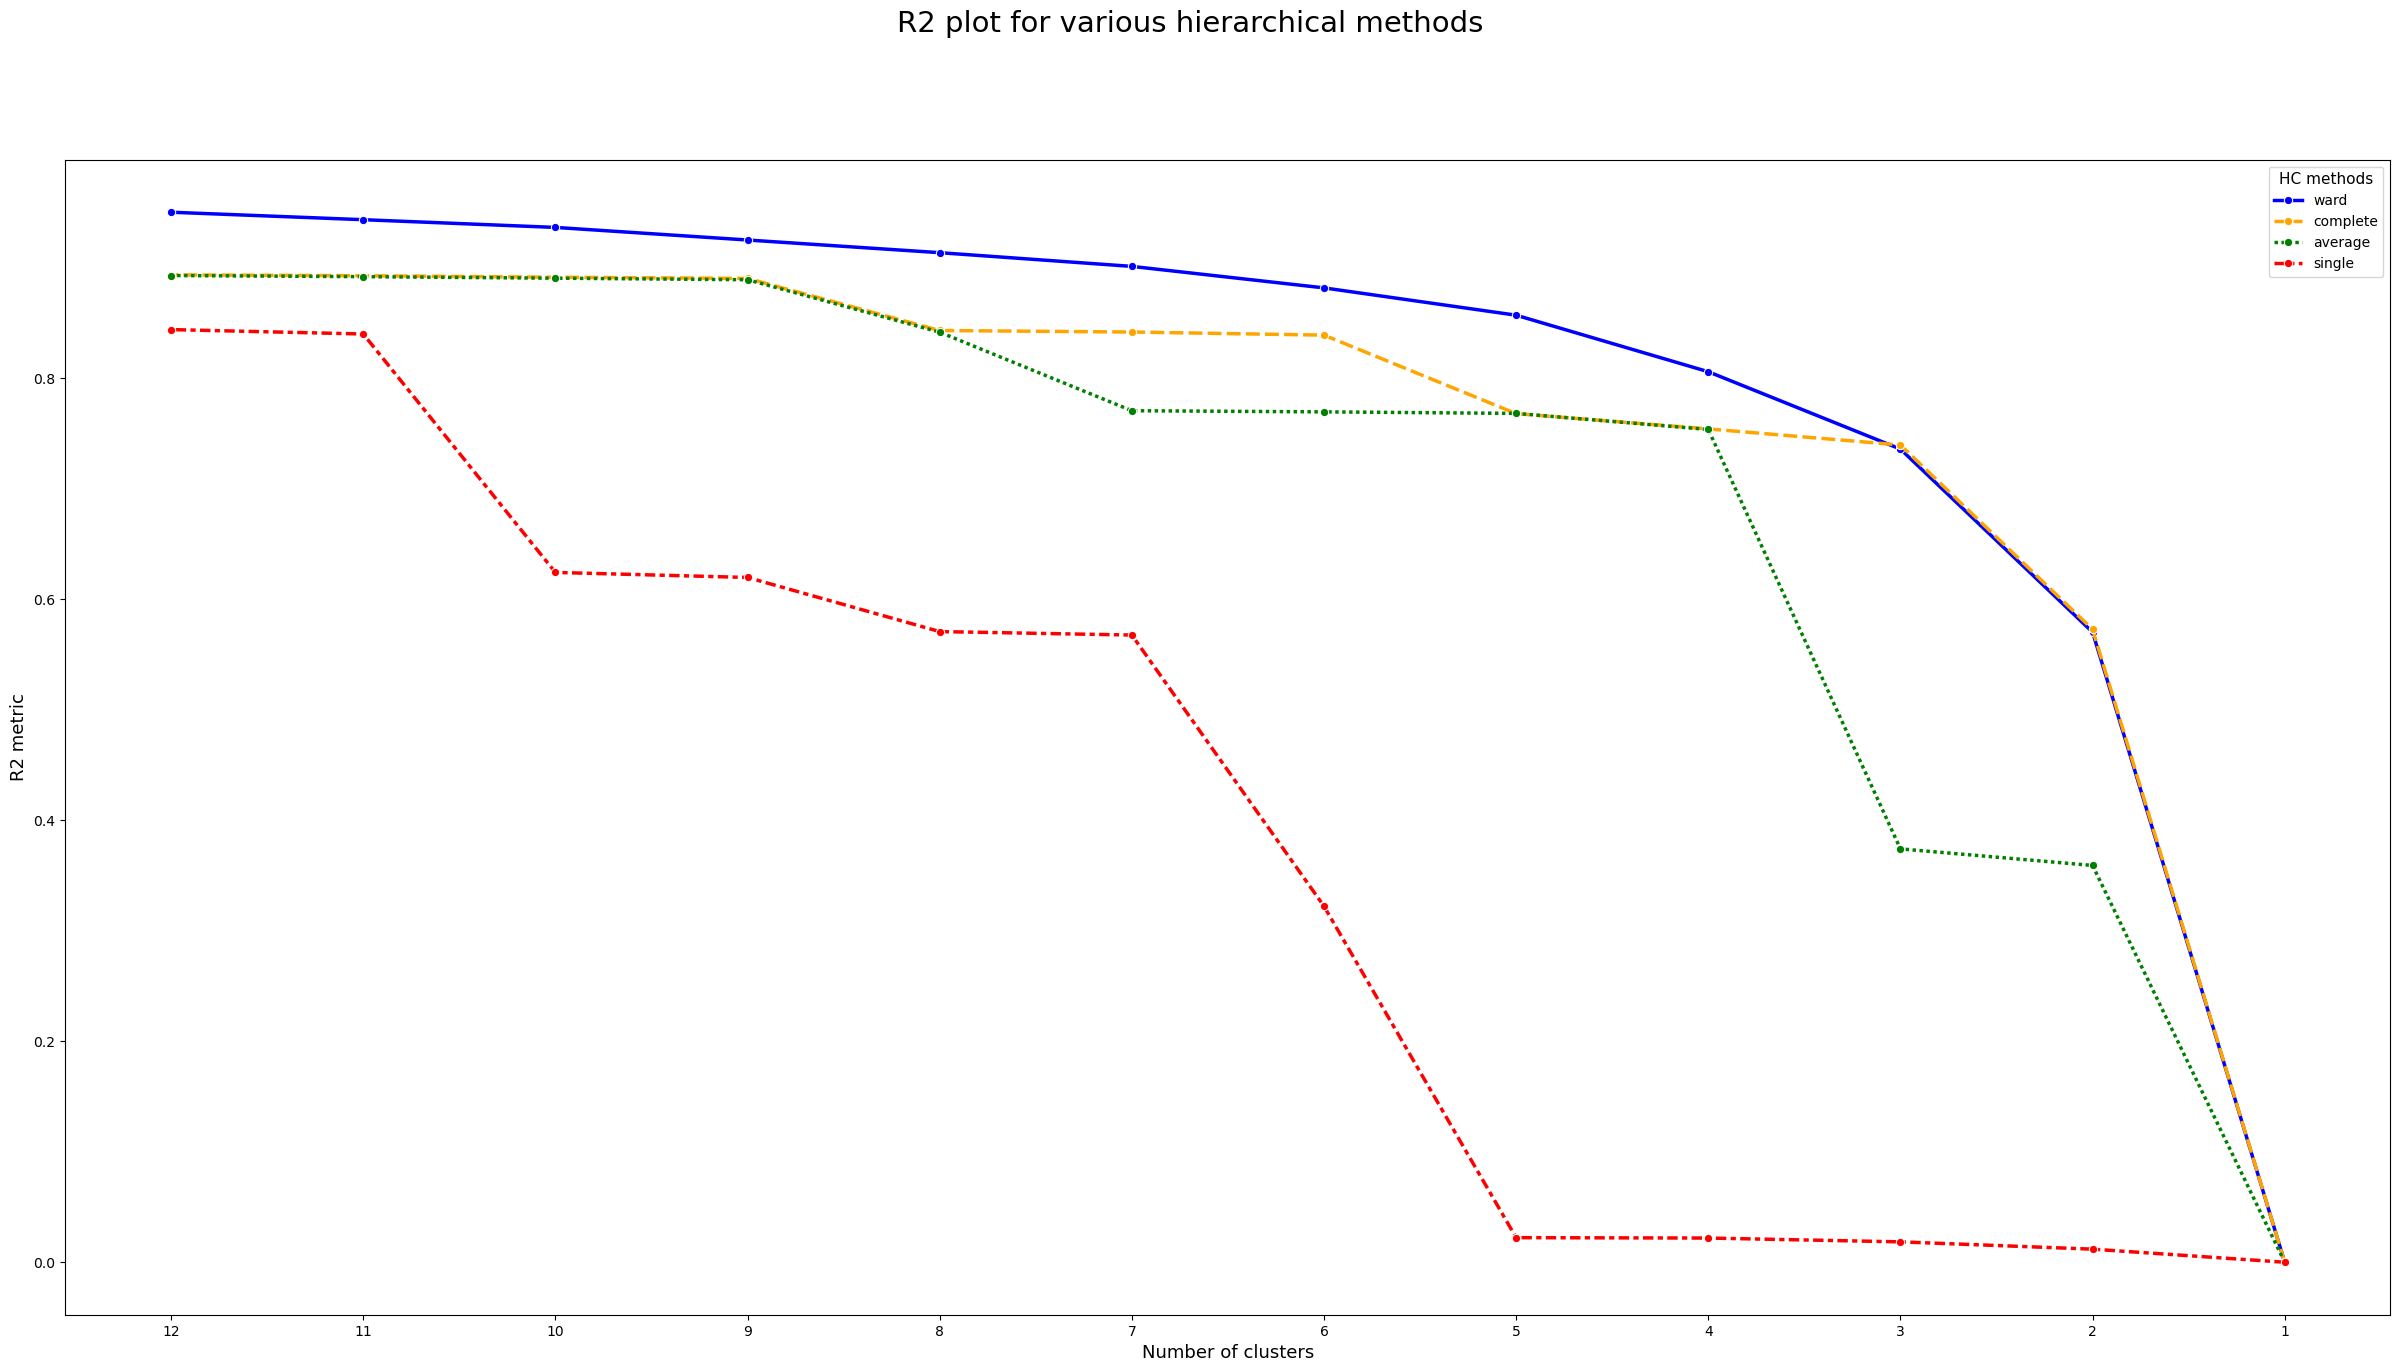

In [111]:
plot_r2_hc(worker_no_scl, max_nclus=12)

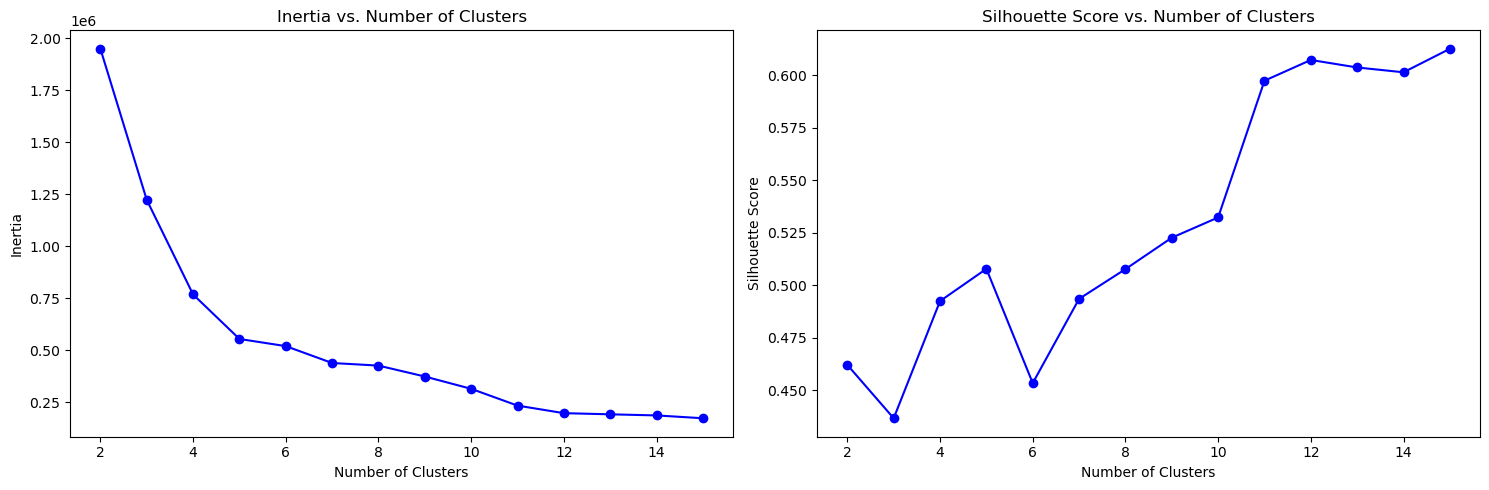

In [112]:
visualize_inertia_silhouette(worker_no_scl)

In [113]:
kmeans = KMeans(n_clusters = 6, random_state = 0).fit(worker_no_scl)
worker['no_kmeans6'] = kmeans.predict(worker_no_scl)

kmeans = KMeans(n_clusters = 8, random_state = 0).fit(worker_no_scl)
worker['no_kmeans8'] = kmeans.predict(worker_no_scl)

In [114]:
compare_cluster_solutions(worker, 'no_kmeans6', 'no_kmeans8')

,no_kmeans8 Cluster 0,no_kmeans8 Cluster 1,no_kmeans8 Cluster 2,no_kmeans8 Cluster 3,no_kmeans8 Cluster 4,no_kmeans8 Cluster 5,no_kmeans8 Cluster 6,no_kmeans8 Cluster 7
no_kmeans6 Cluster 0,53,0,0,0,101,0,1,0
no_kmeans6 Cluster 1,0,96,0,0,0,0,1,0
no_kmeans6 Cluster 2,0,0,72,0,0,0,0,0
no_kmeans6 Cluster 3,0,0,0,209,0,0,0,0
no_kmeans6 Cluster 4,0,0,0,0,0,0,1,38
no_kmeans6 Cluster 5,119,0,0,0,0,105,4,0


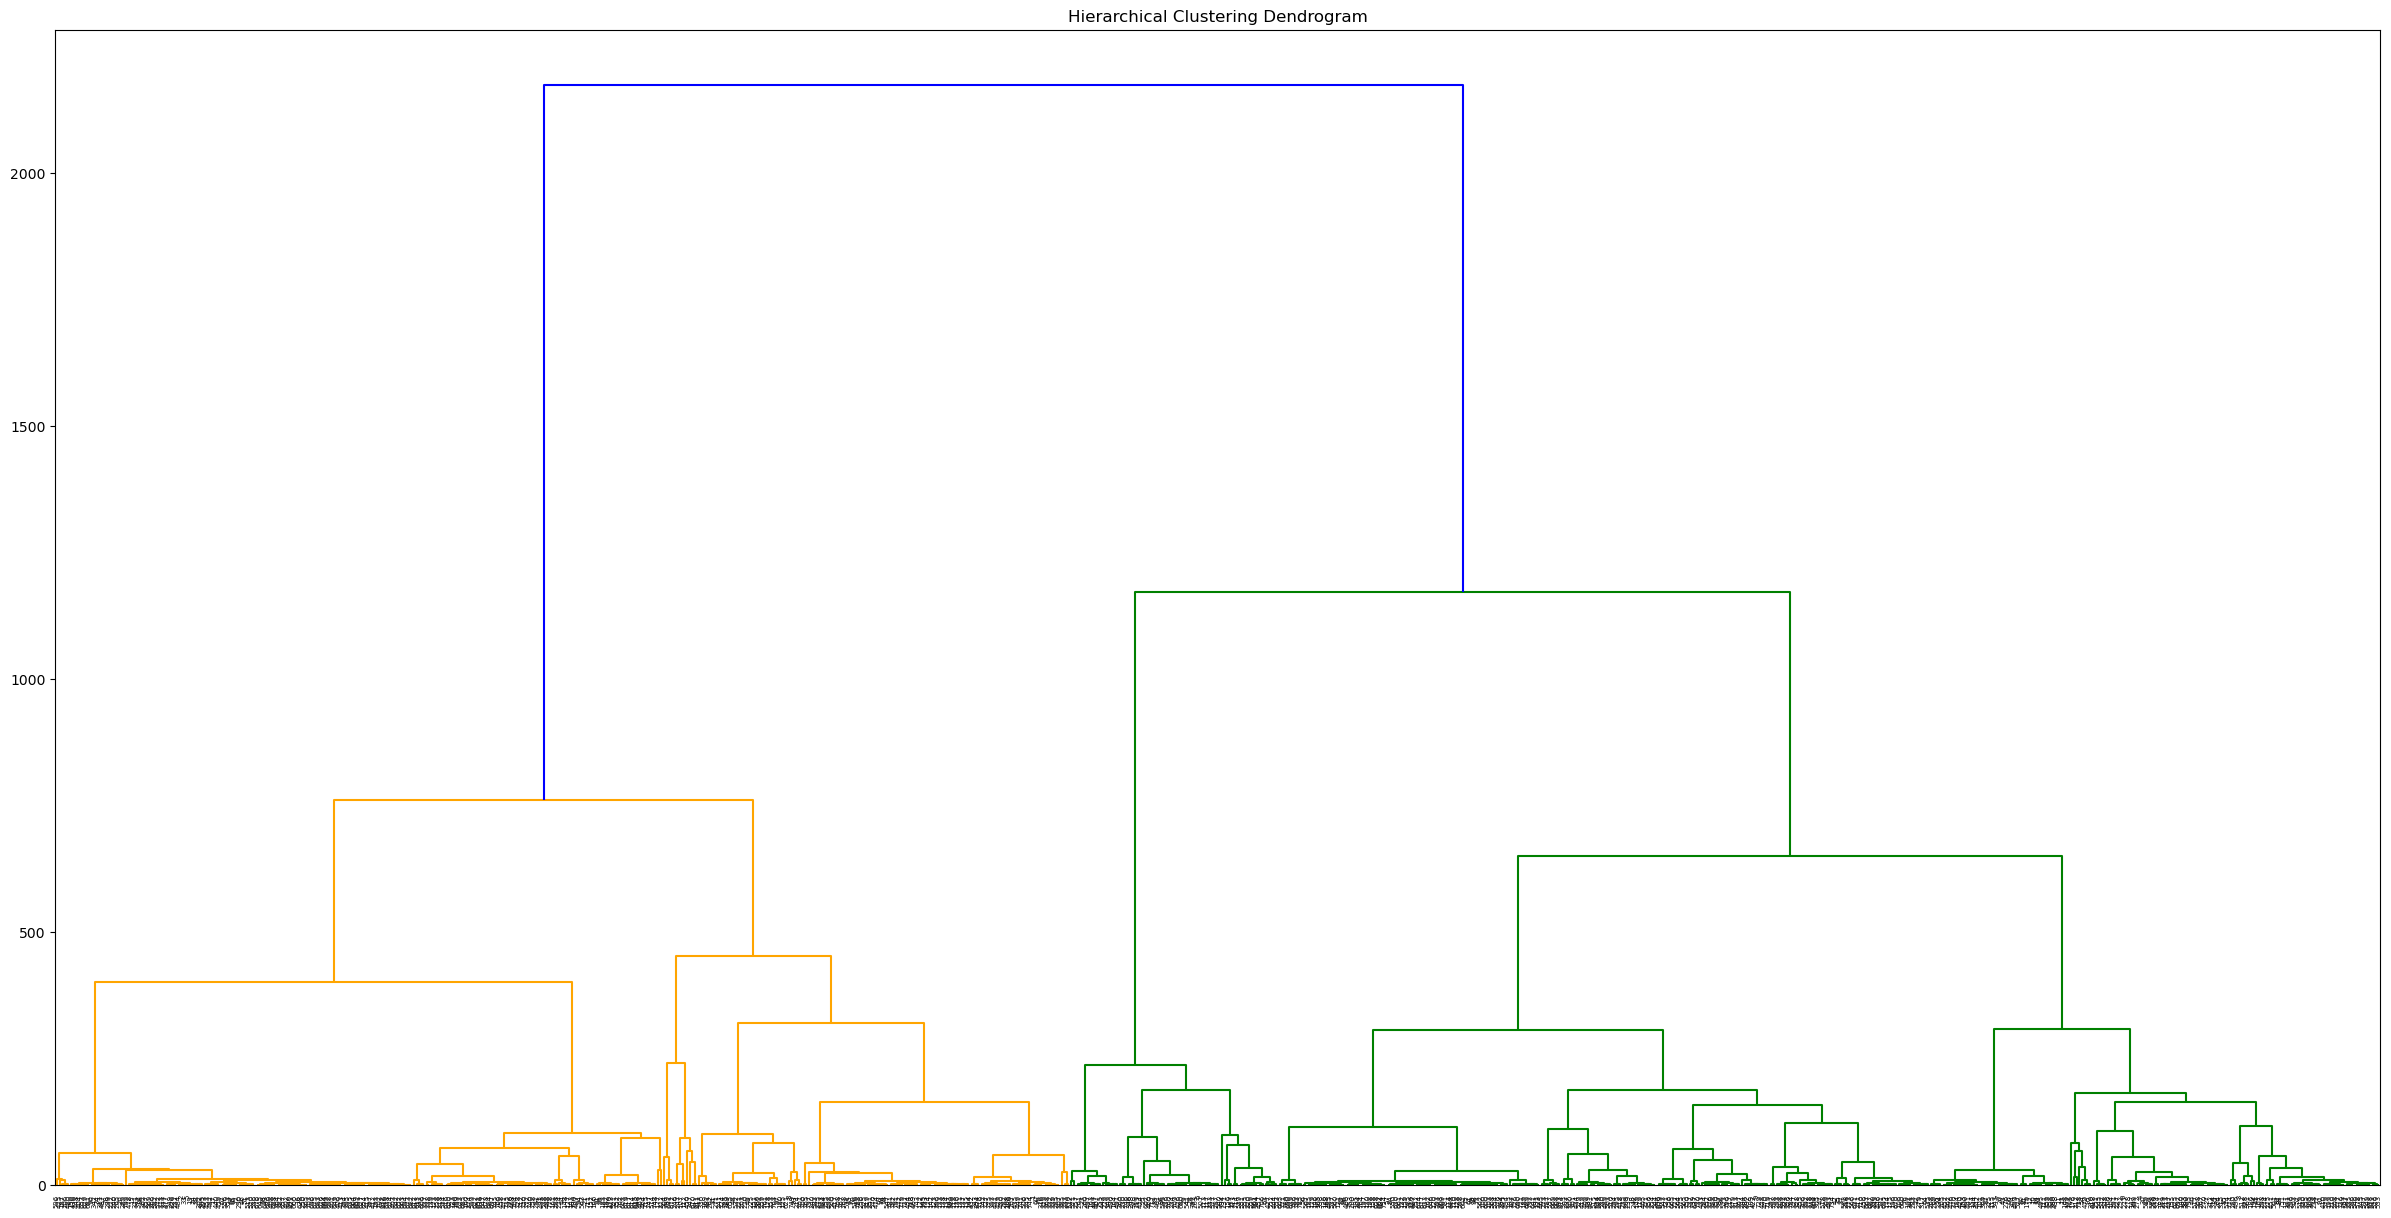

In [115]:
create_dendrogram(worker_no_scl, 'ward')

In [116]:
worker['no_ward5'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 5
    ).fit_predict(worker_no_scl)

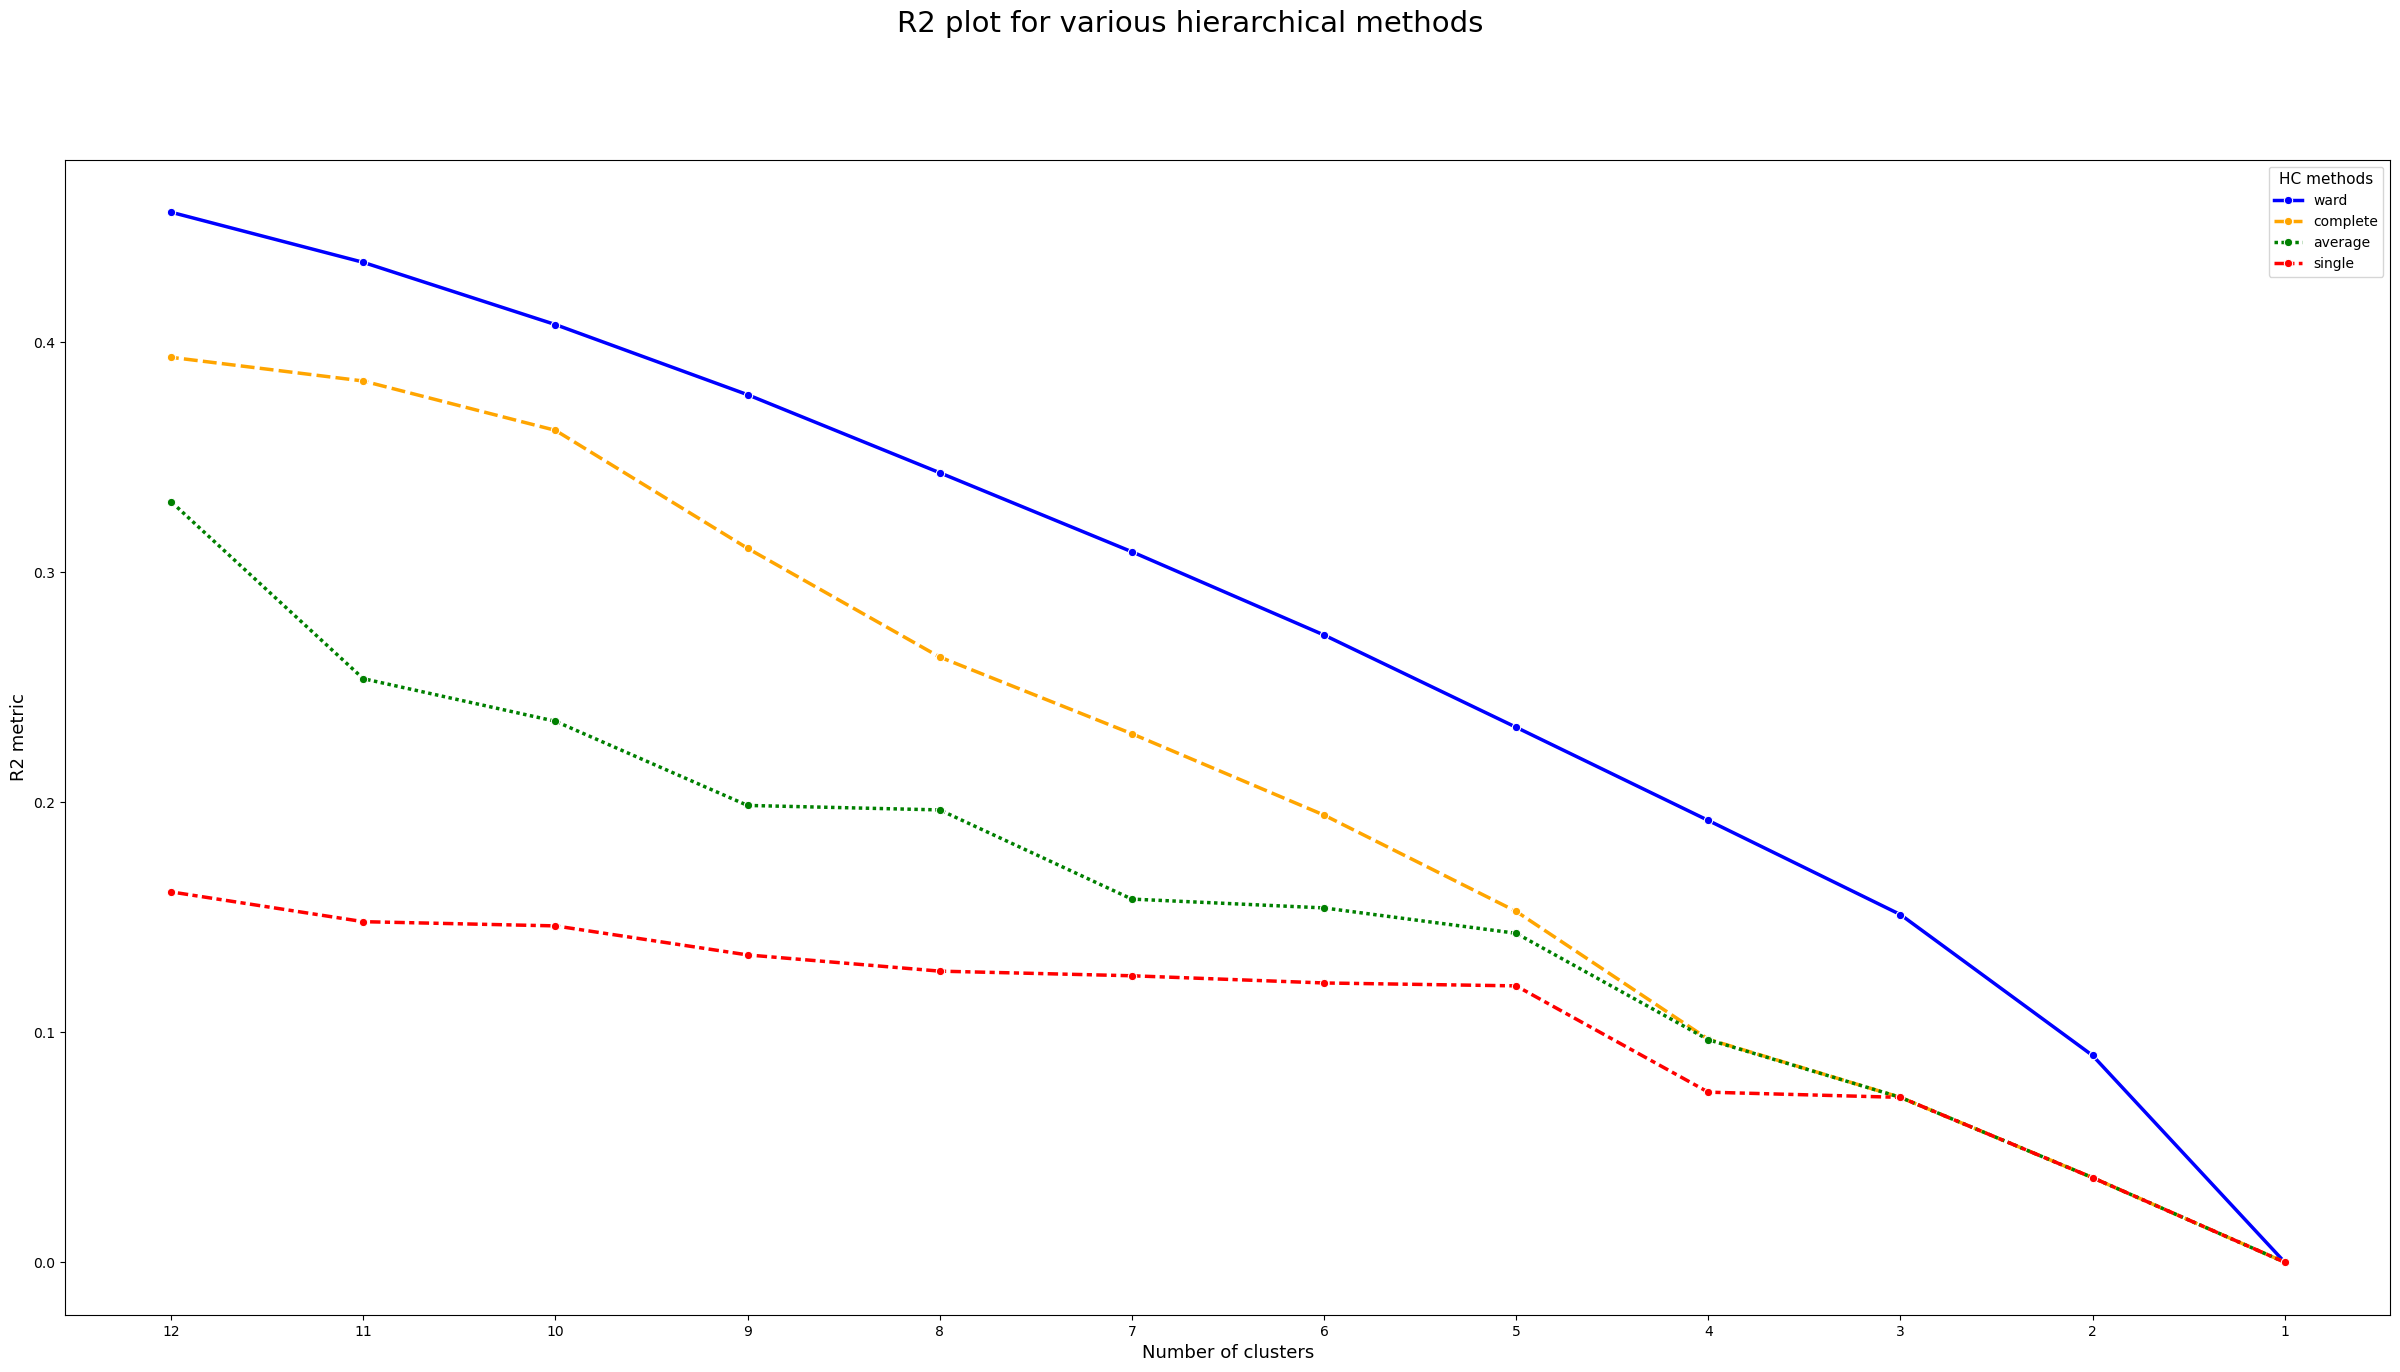

In [117]:
plot_r2_hc(worker_st_scl, max_nclus=12)

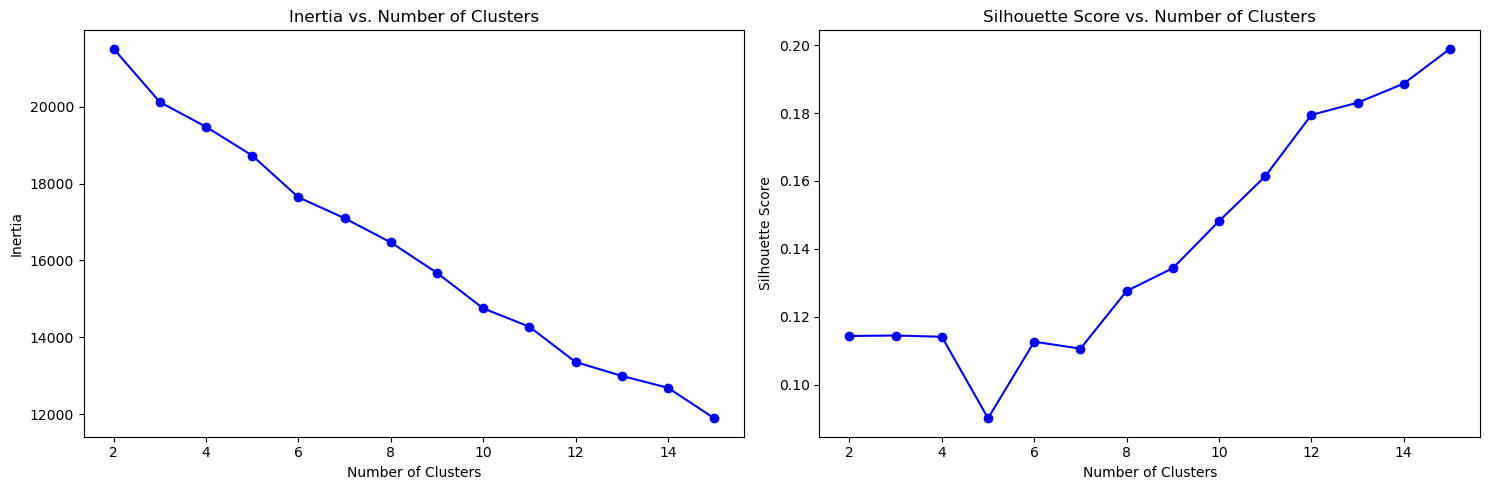

In [118]:
visualize_inertia_silhouette(worker_st_scl)

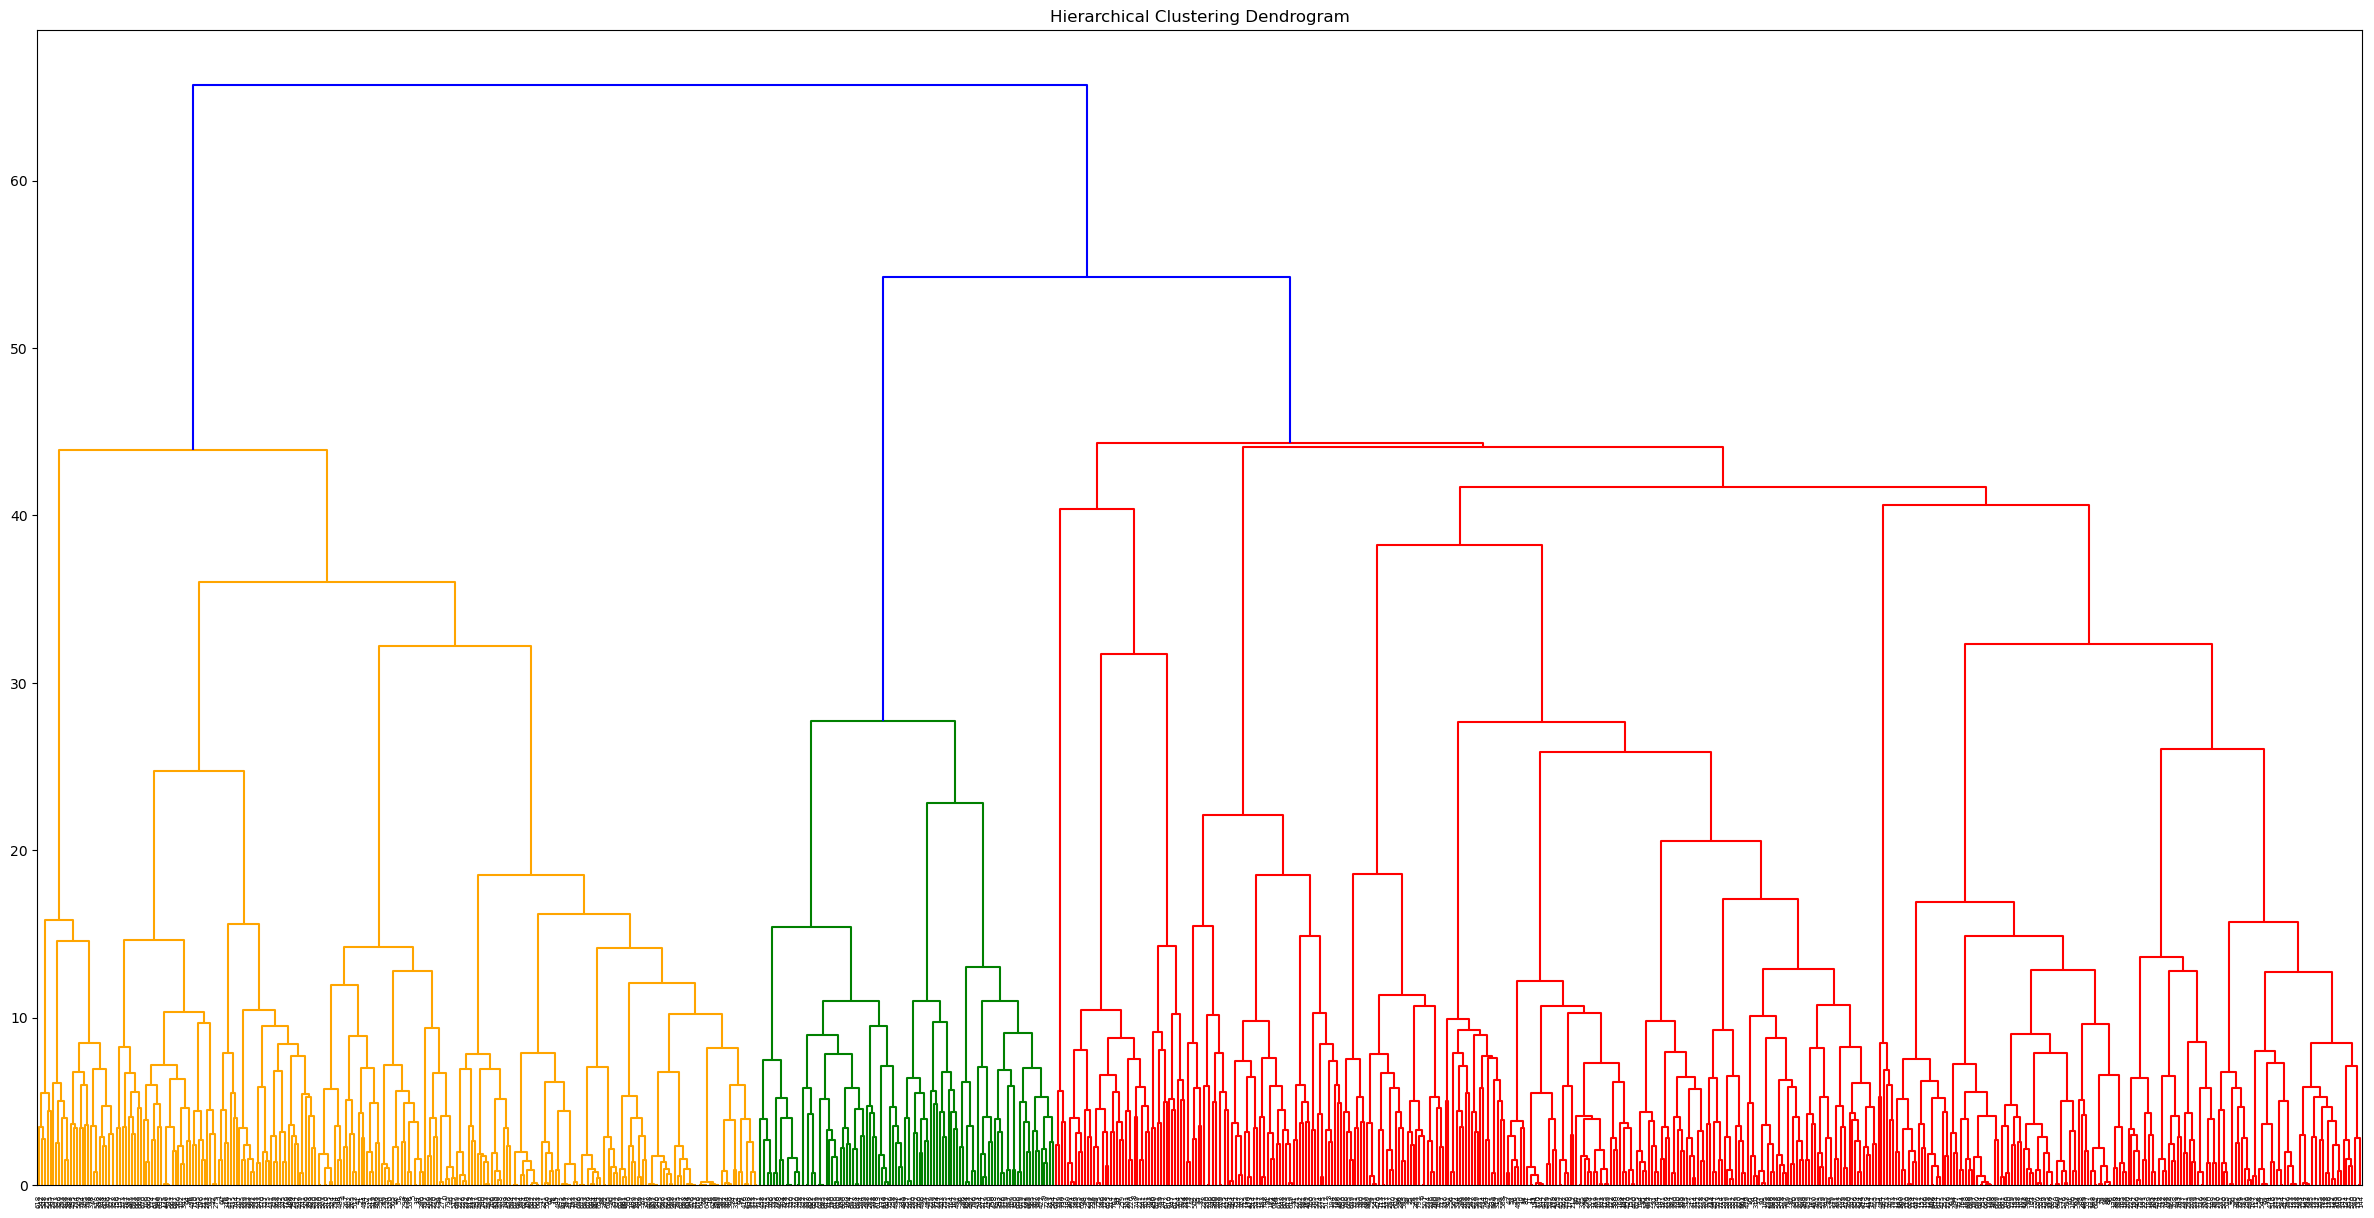

In [119]:
create_dendrogram(worker_st_scl, 'ward')

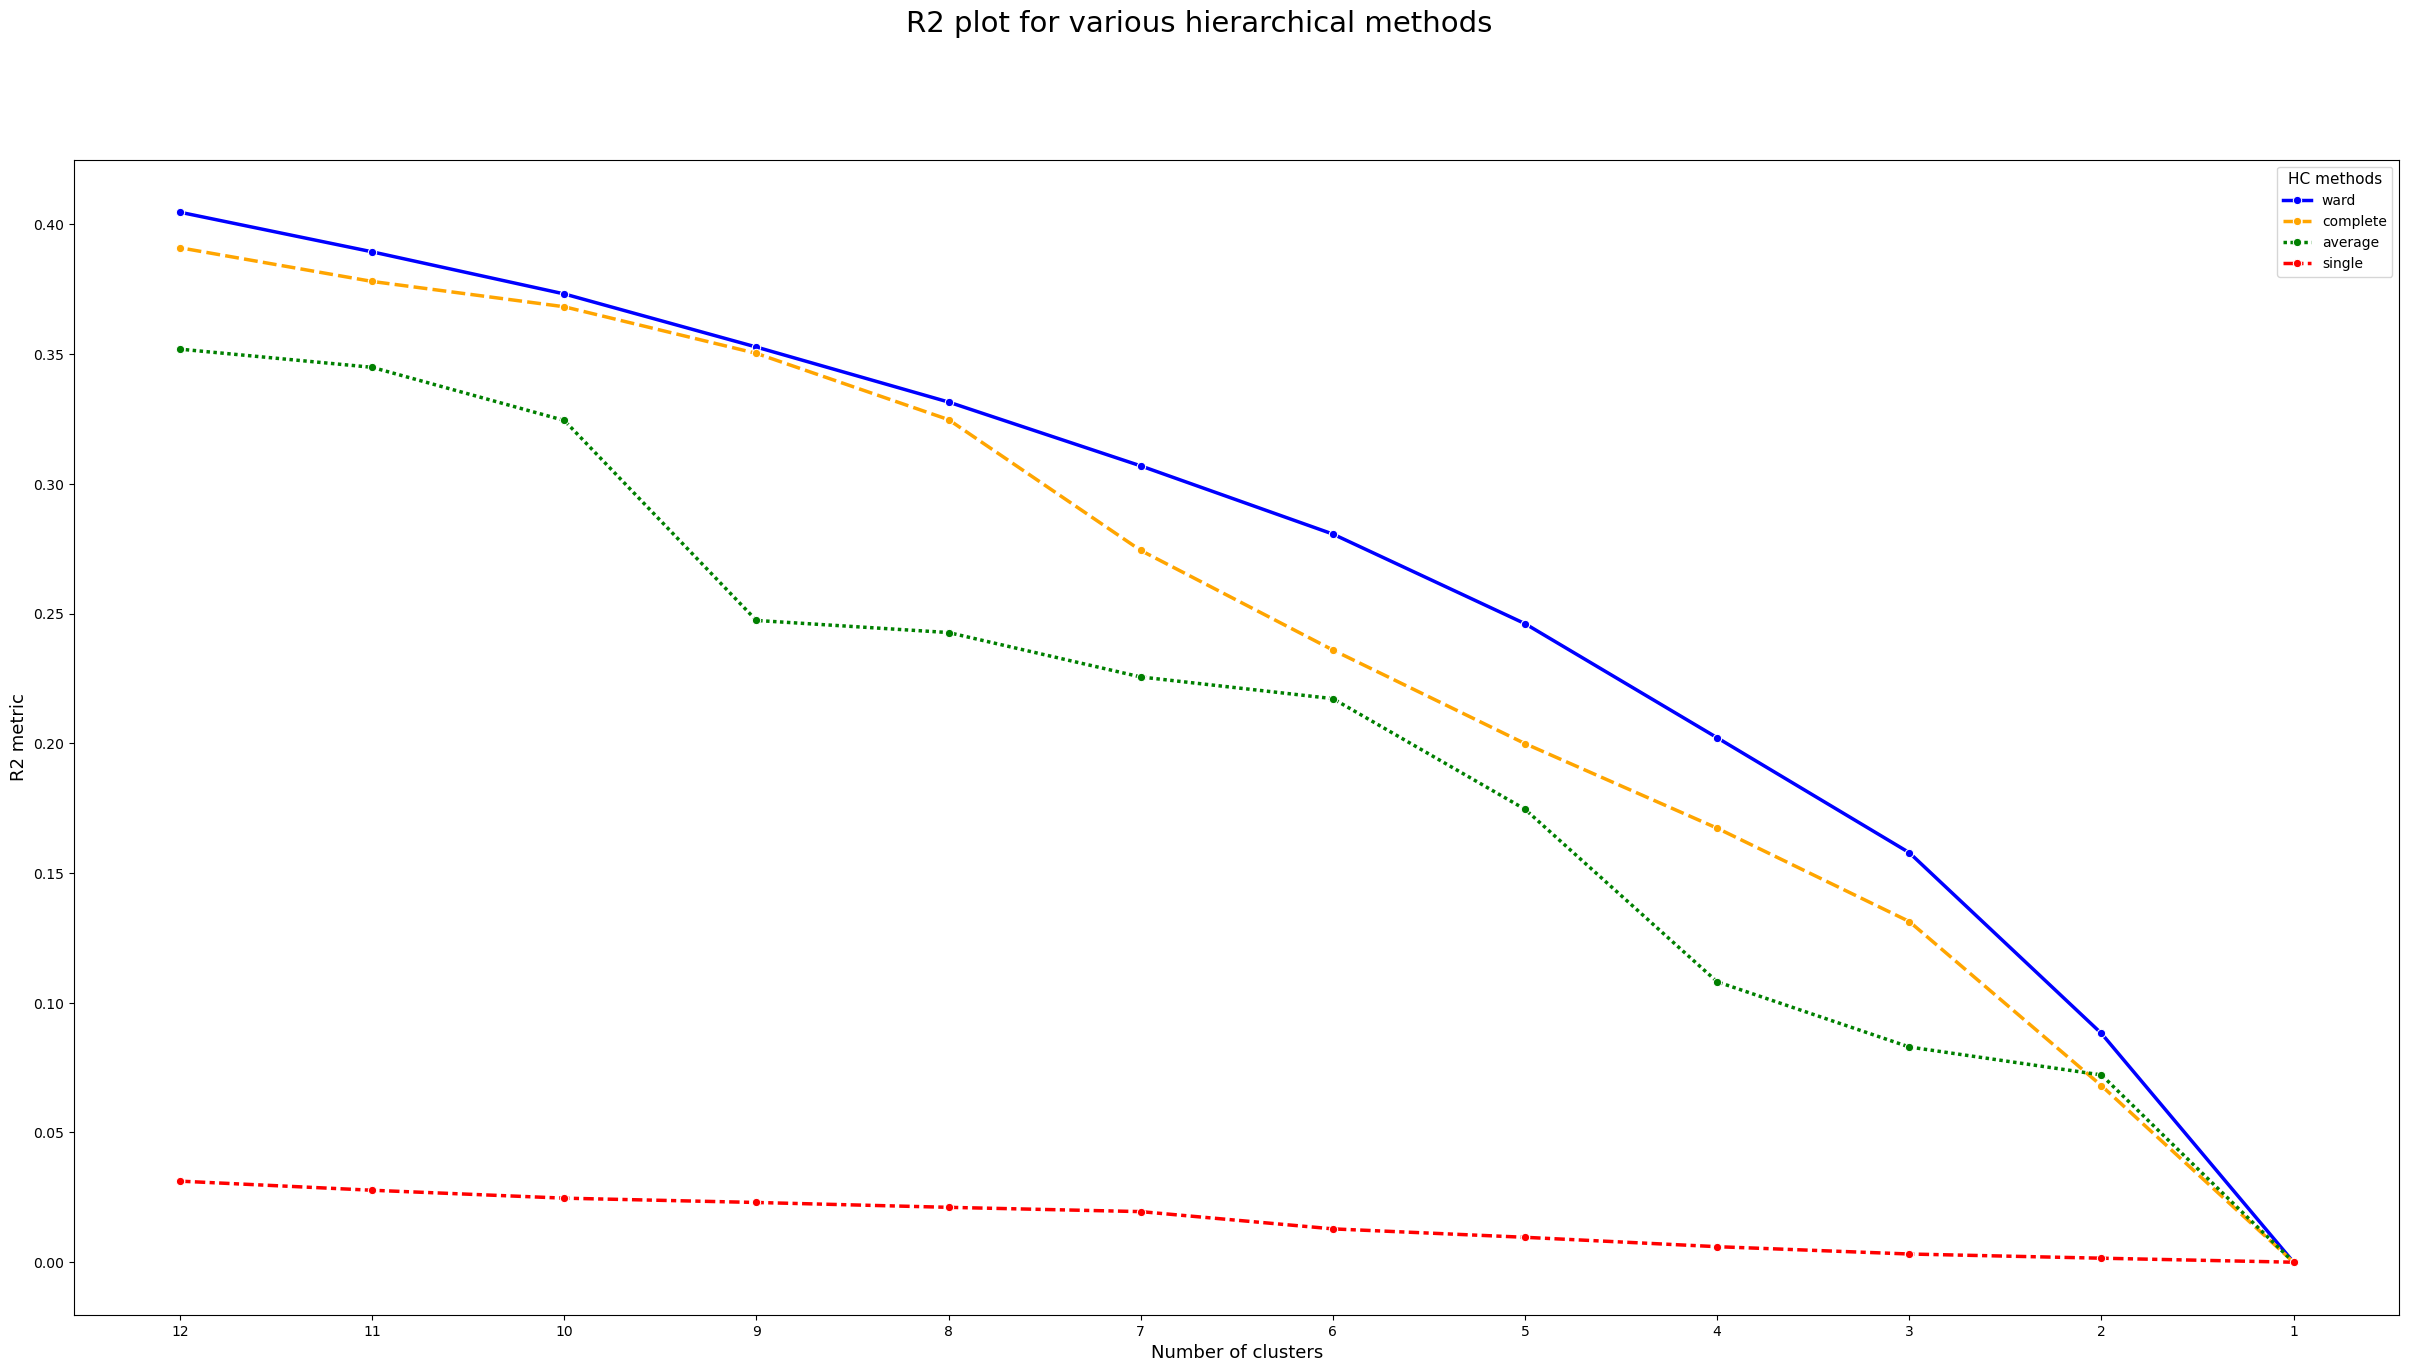

In [120]:
plot_r2_hc(worker_mm_scl, max_nclus=12)

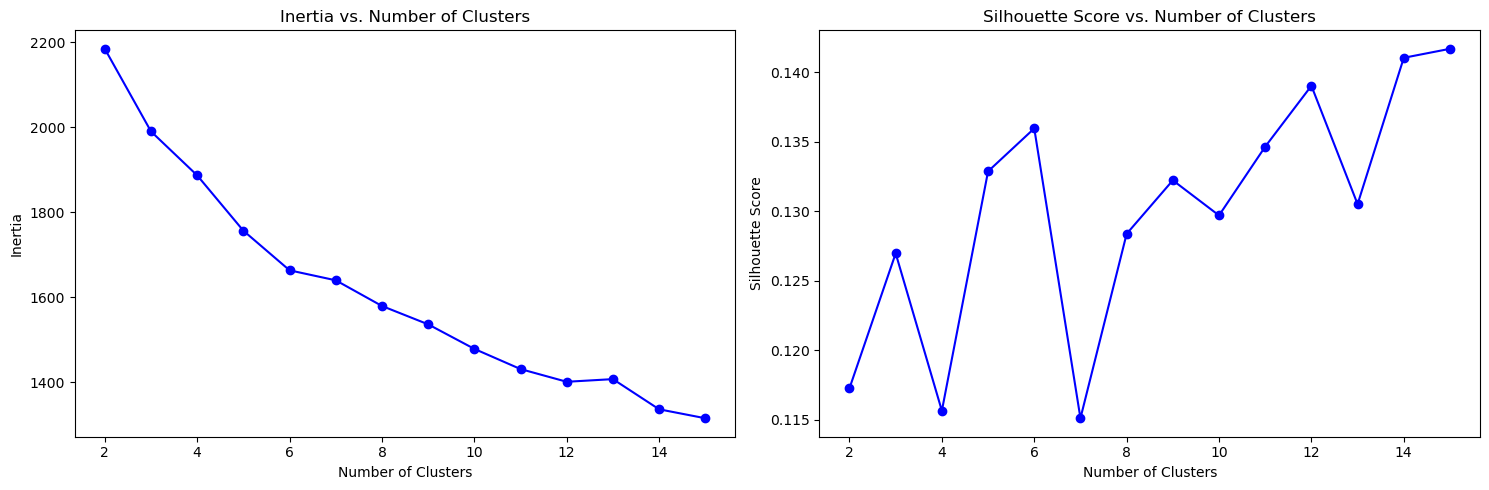

In [121]:
visualize_inertia_silhouette(worker_mm_scl)

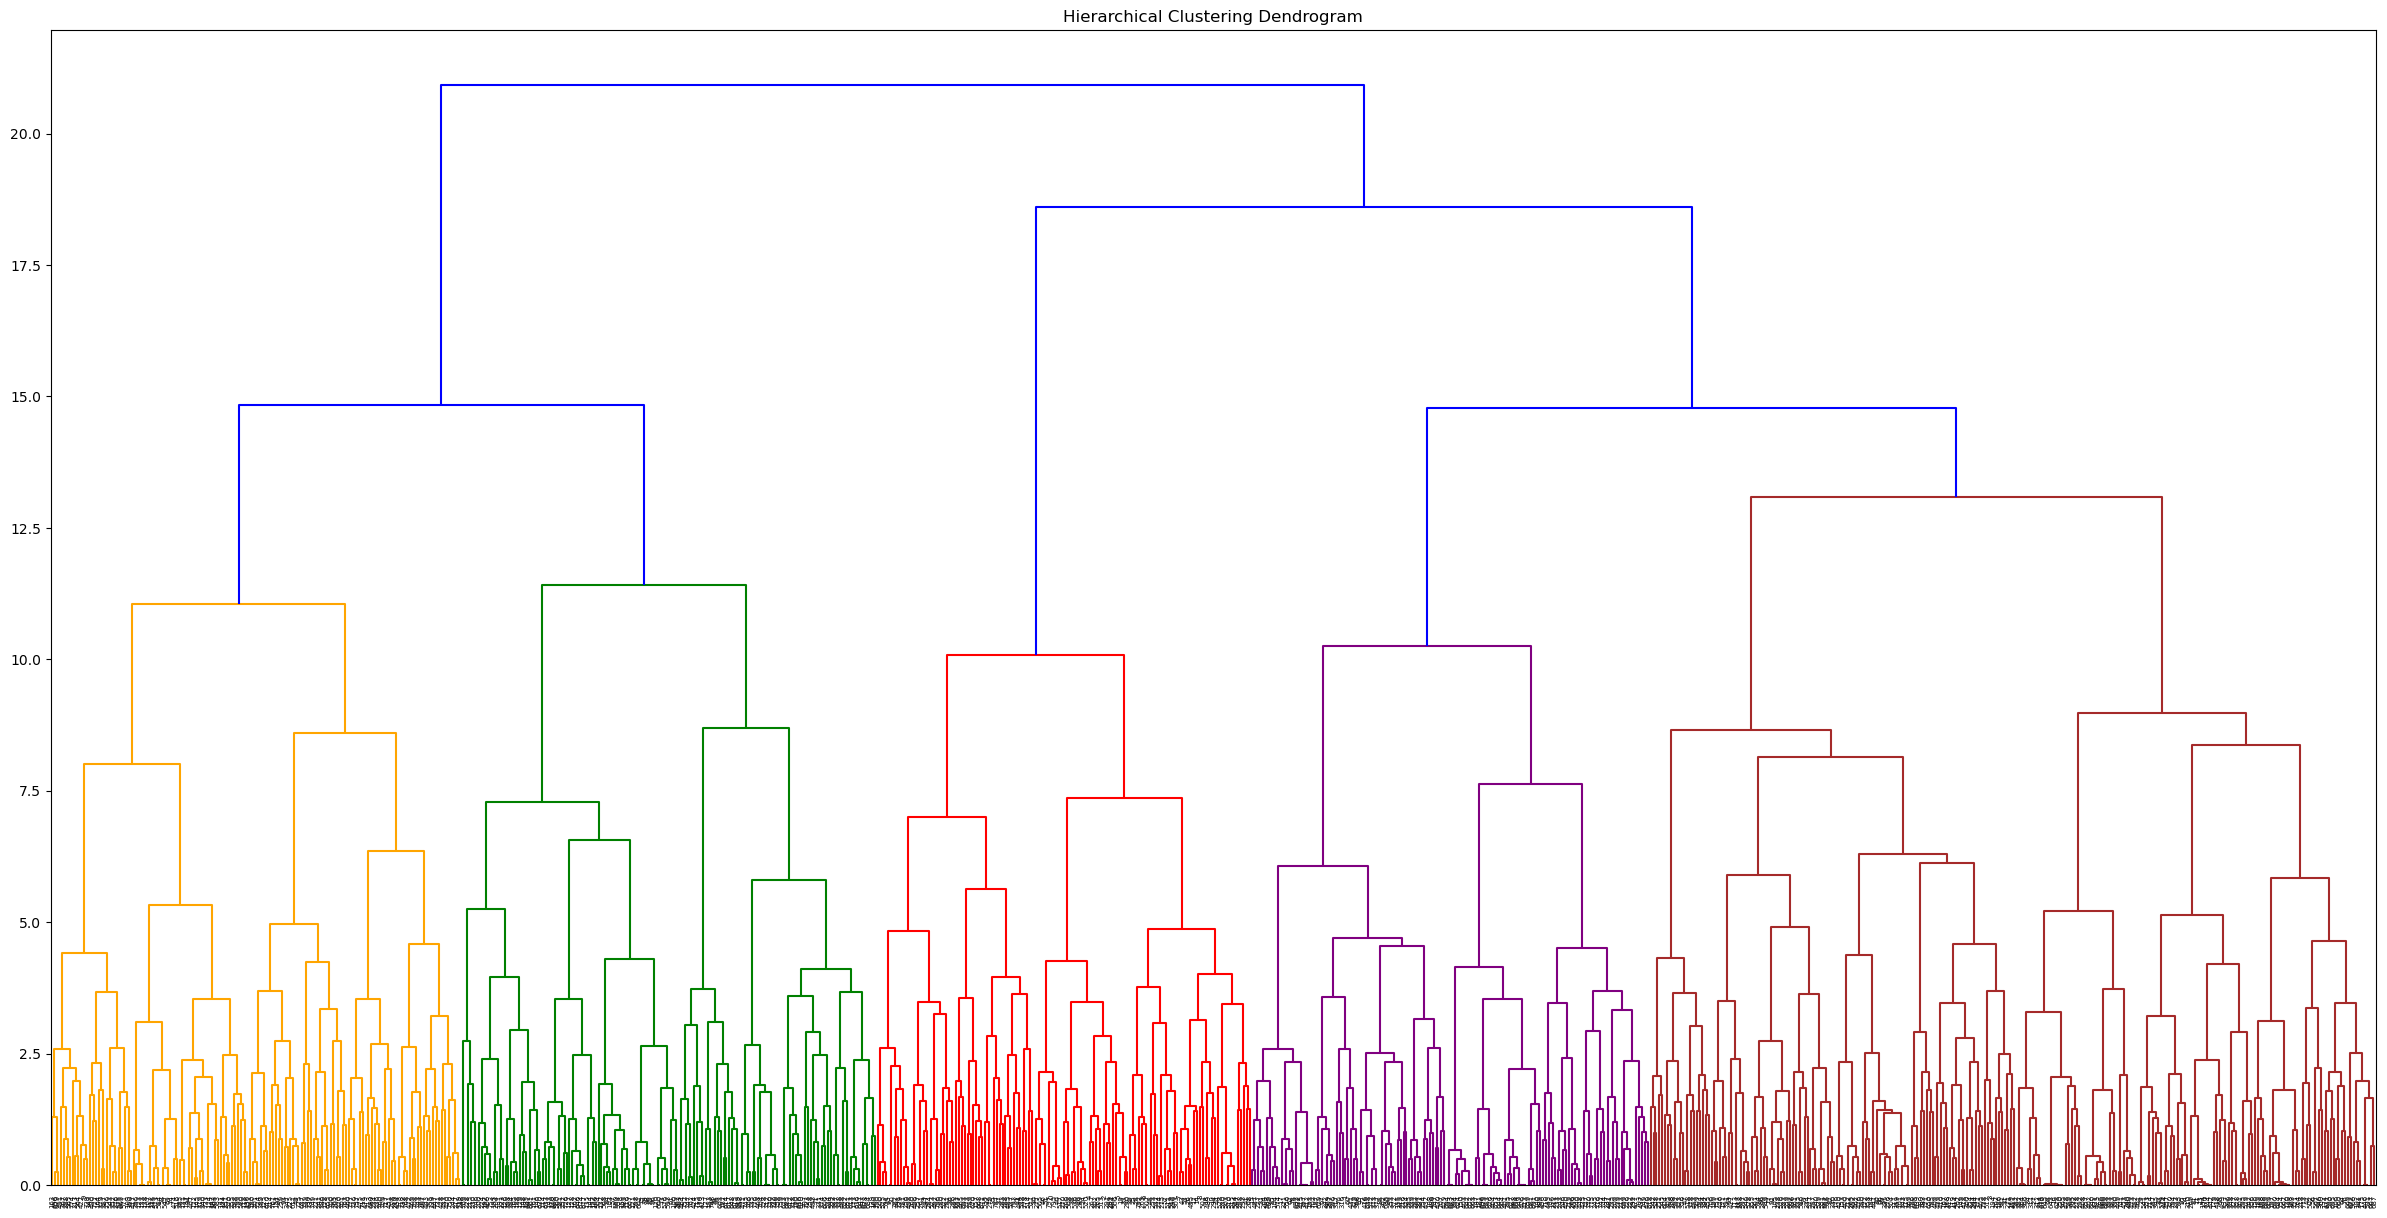

In [122]:
create_dendrogram(worker_mm_scl, 'ward')

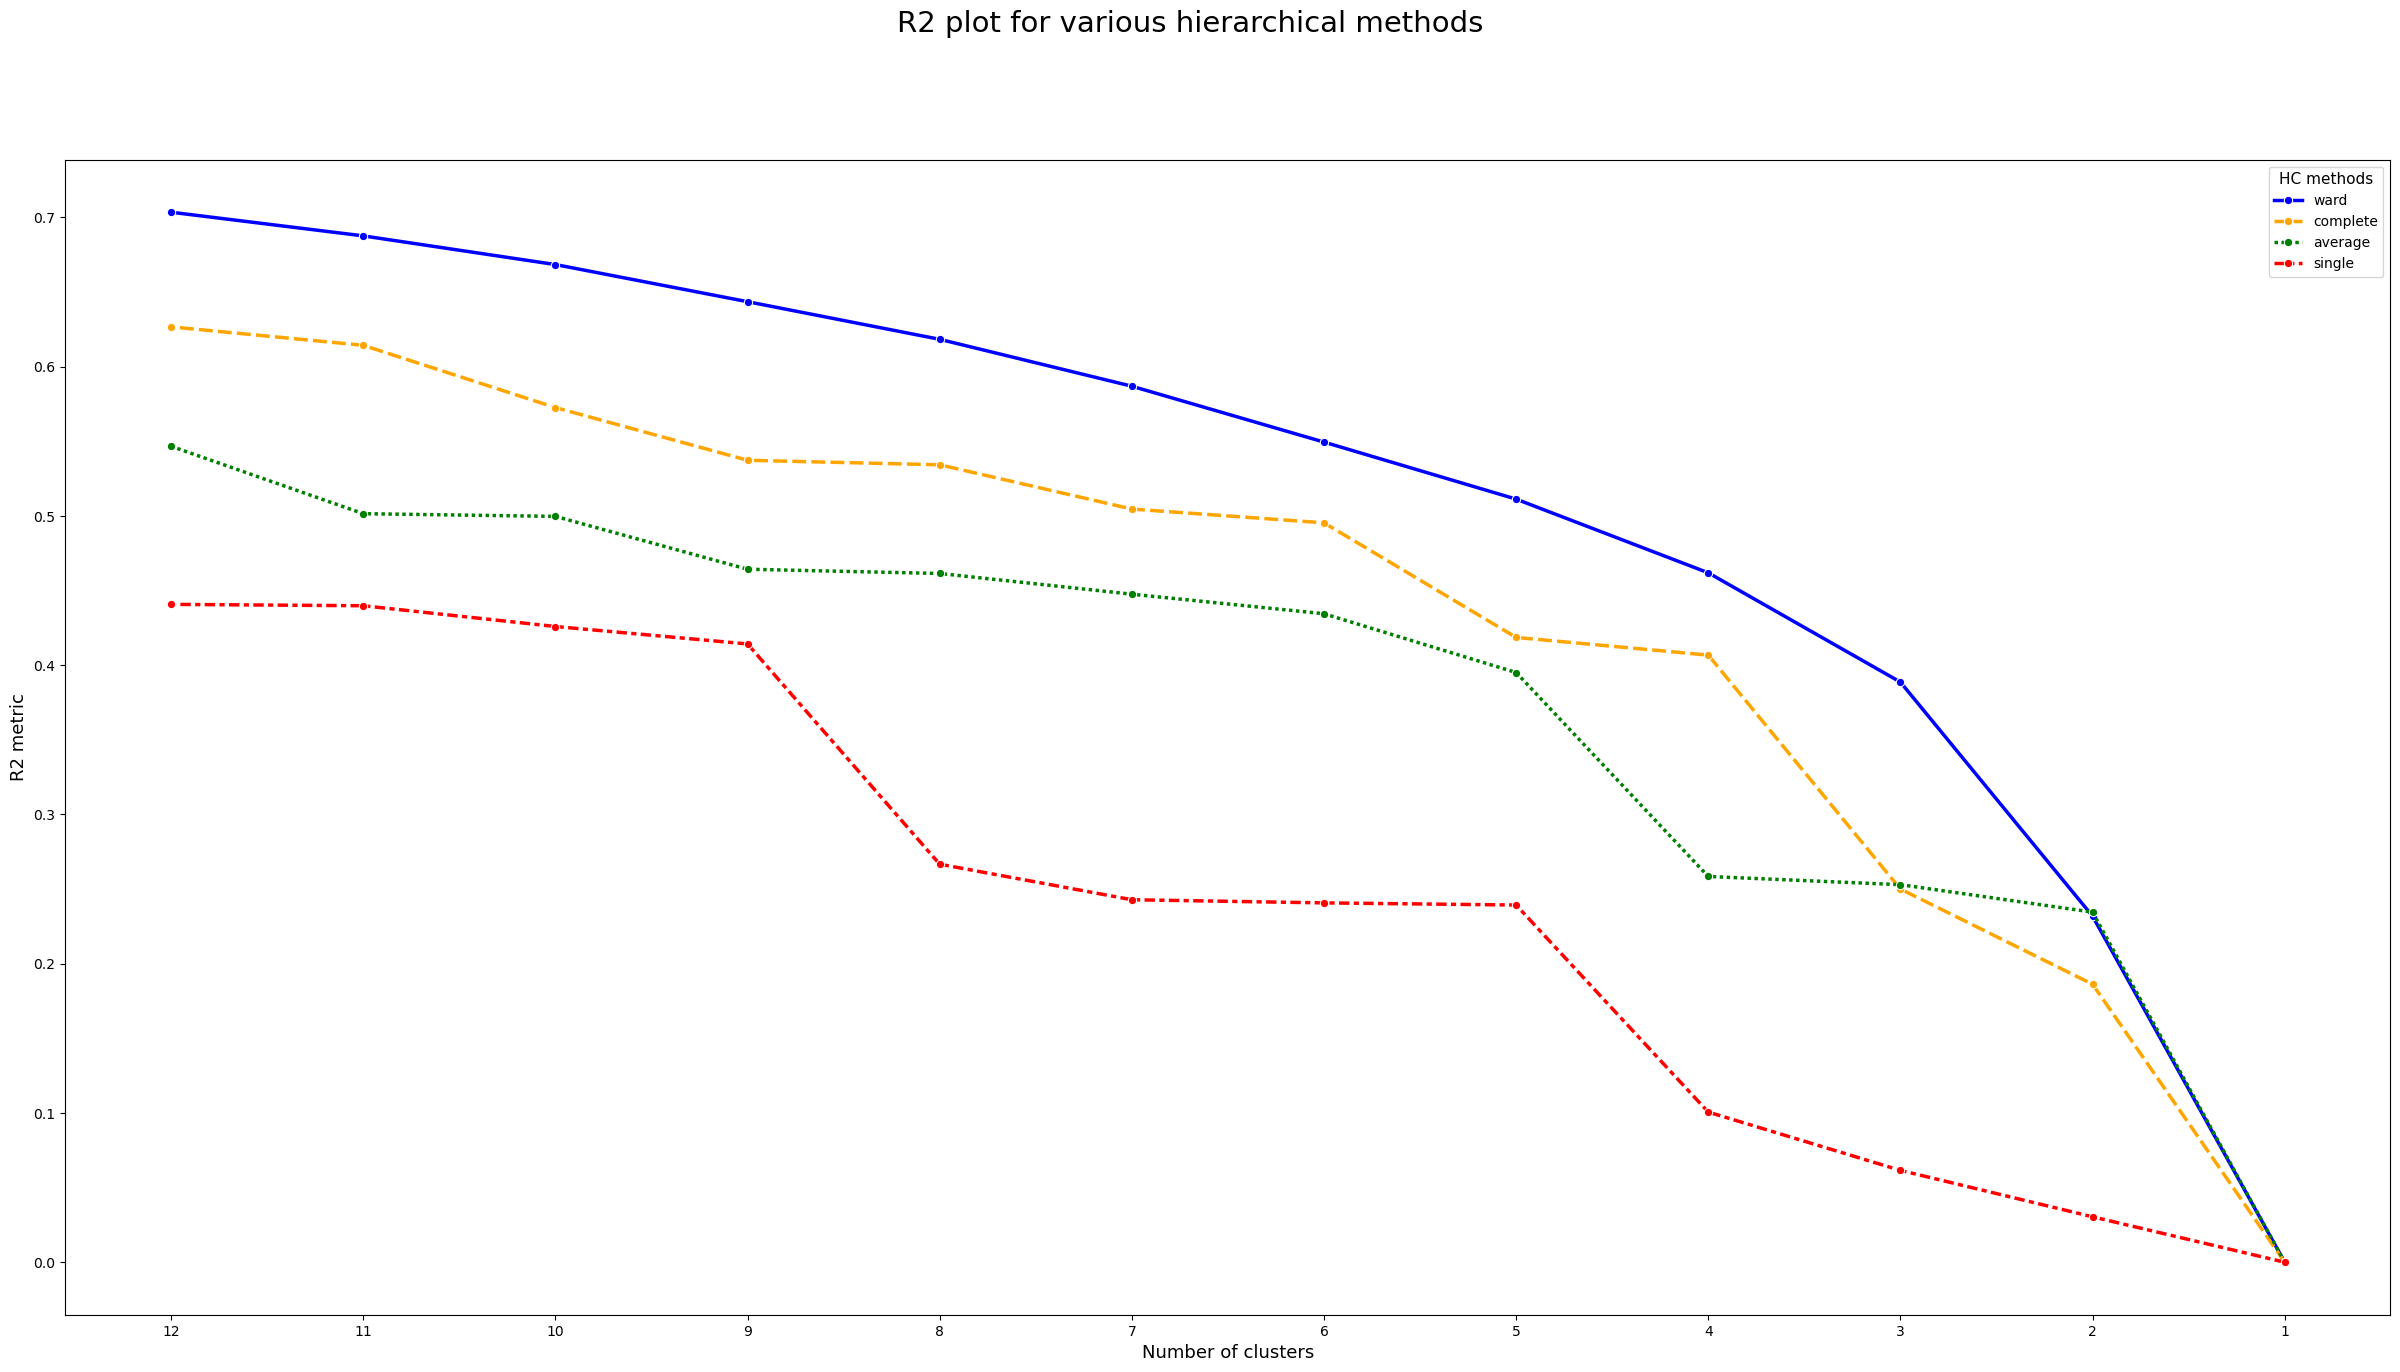

In [123]:
plot_r2_hc(worker_rb_scl, max_nclus=12)

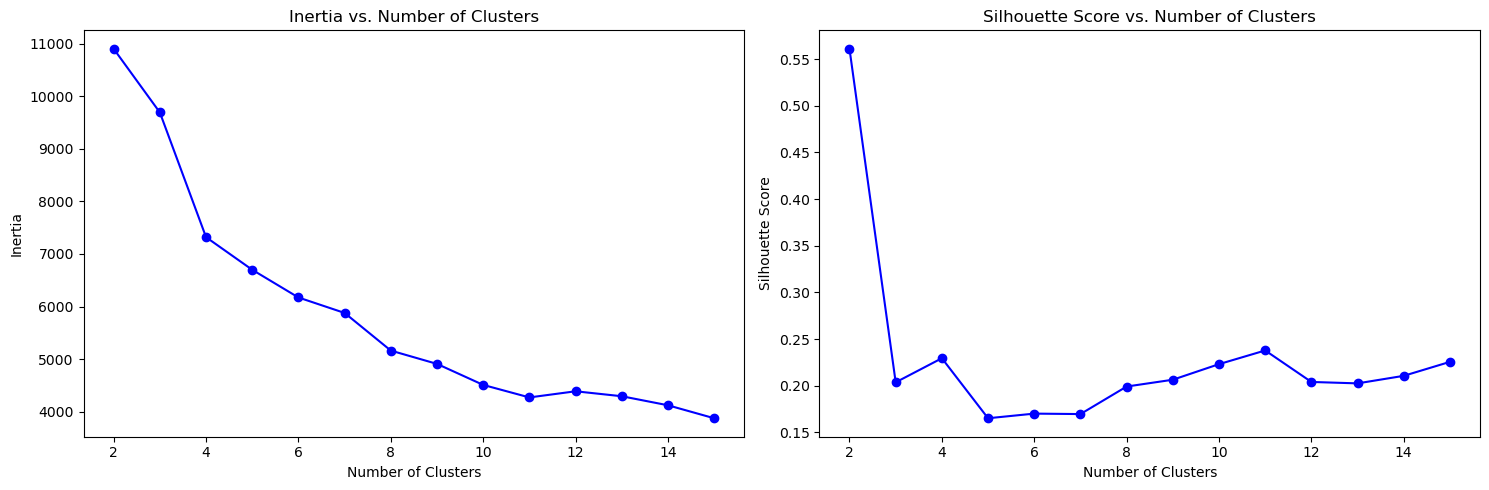

In [124]:
visualize_inertia_silhouette(worker_rb_scl)

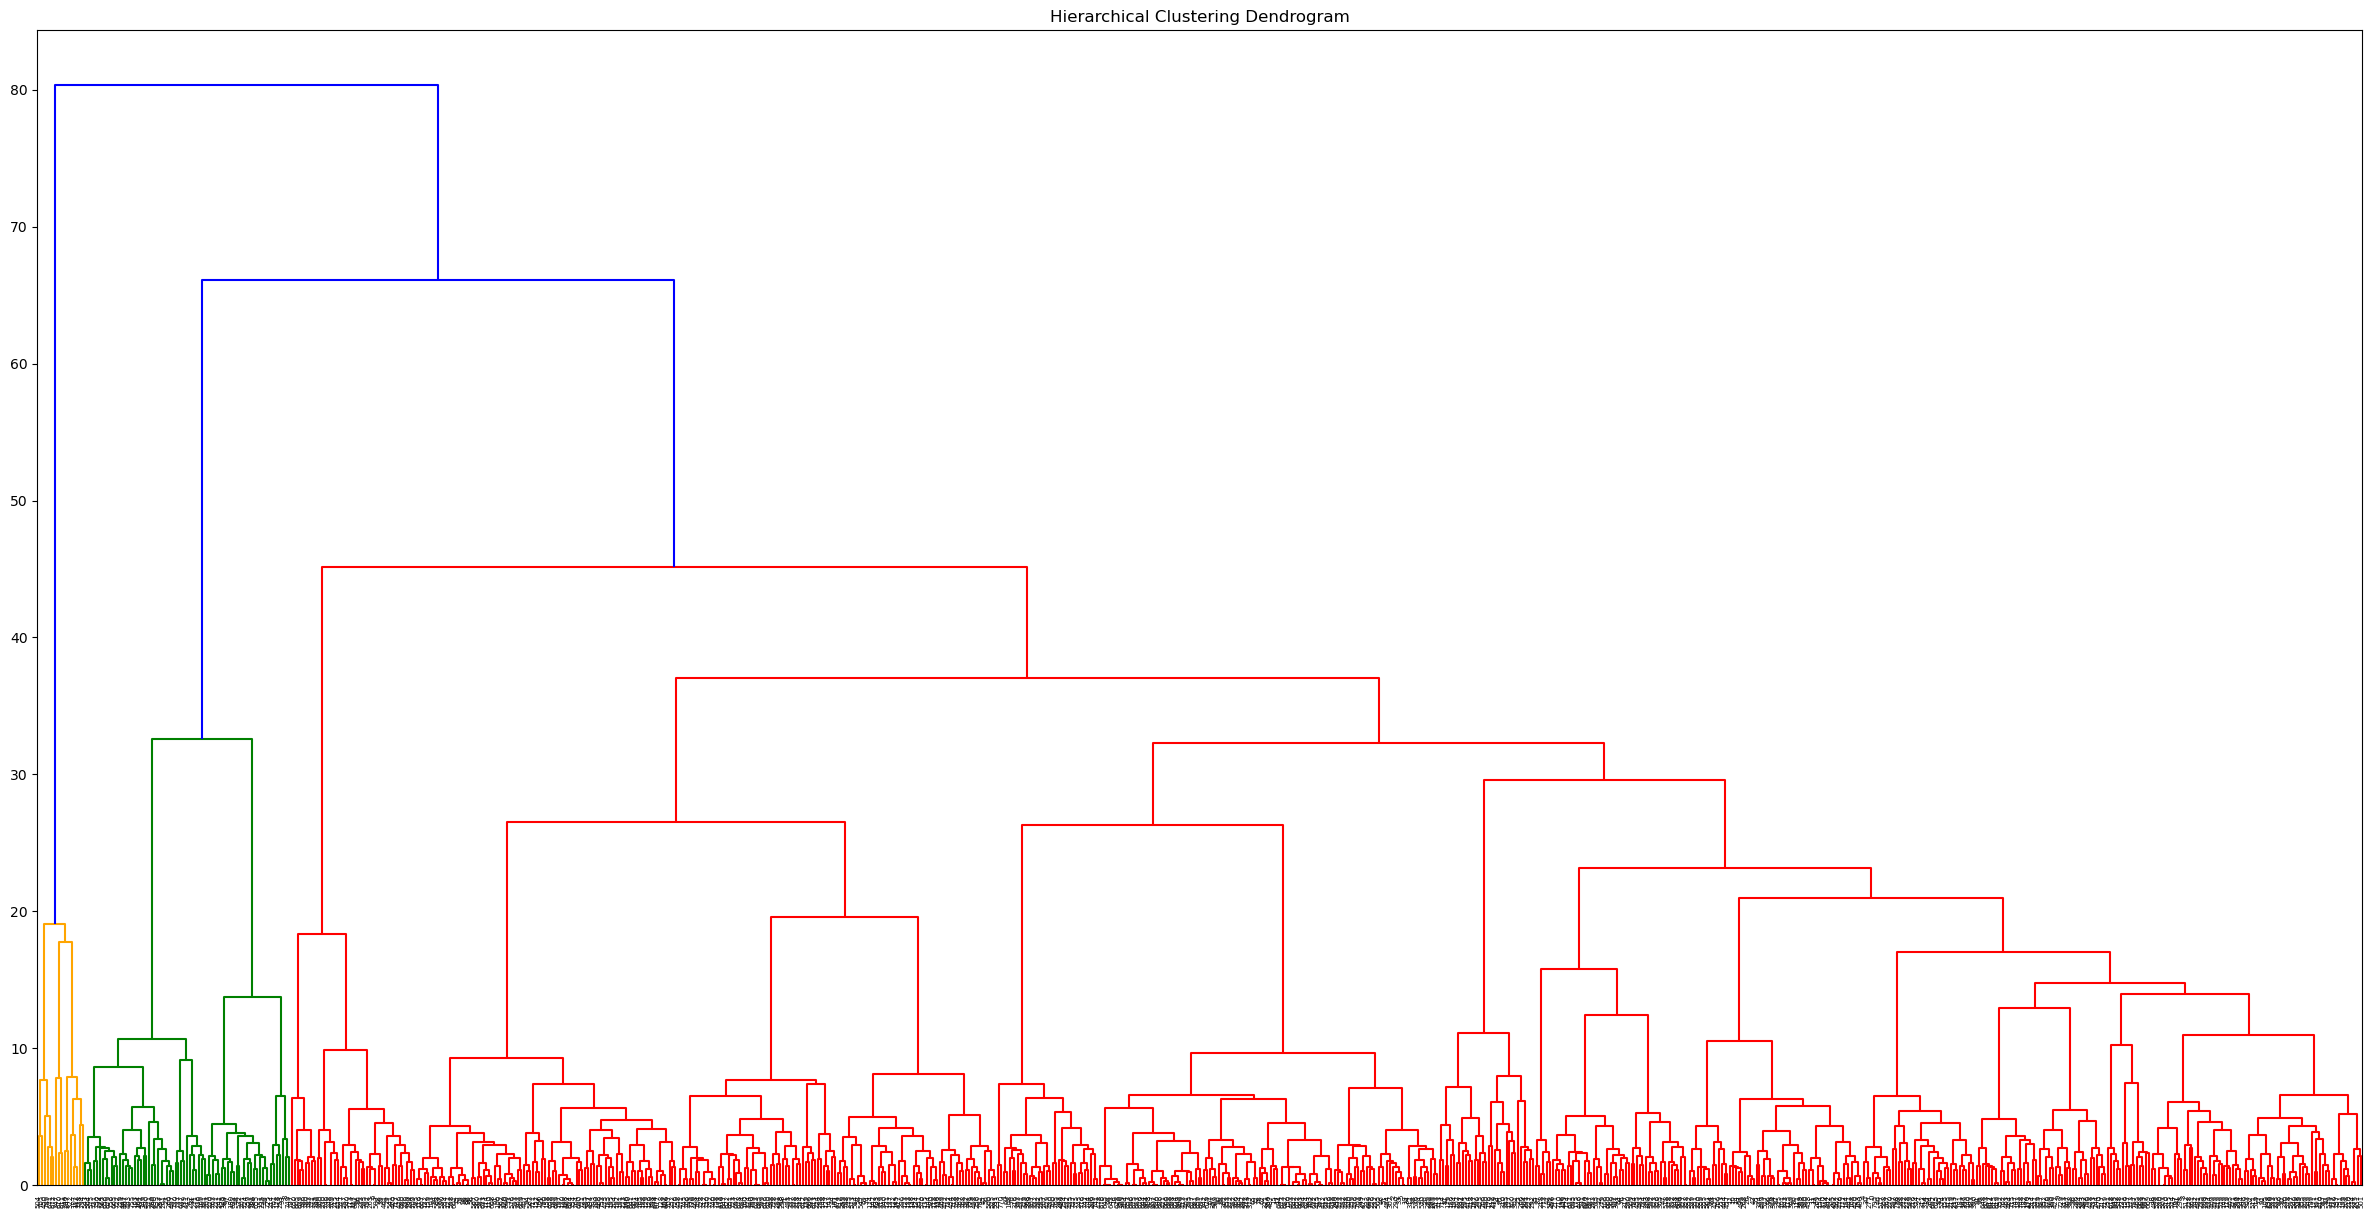

In [125]:
create_dendrogram(worker_rb_scl, 'ward')

In [126]:
worker['rb_ward9'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 9
    ).fit_predict(worker_rb_scl)

In [127]:
worker['rb_ward10'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 10
    ).fit_predict(worker_rb_scl)

In [128]:
worker['rb_ward11'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters = 11
    ).fit_predict(worker_rb_scl)

In [129]:
calculate_group_means(worker, 'rb_ward10')

rb_ward10,0,1,2,3,4,5,6,7,8,9
Age,39.568421,41.562500,33.309091,30.325581,38.000000,29.571429,34.000000,37.333333,28.444444,49.771429
Transportation expense,262.052632,193.812500,148.818182,334.697674,179.000000,261.857143,155.000000,256.545455,221.800000,118.000000
Distance from Residence to Work,29.326316,16.750000,19.018182,50.372093,51.000000,17.380952,12.000000,32.939394,26.266667,13.114286
Service time,13.543860,13.750000,9.372727,4.348837,18.000000,6.714286,14.000000,13.848485,9.355556,18.342857
Years until retirement,25.484211,23.437500,31.690909,34.674419,27.000000,34.190476,31.000000,27.666667,36.555556,15.228571
Disciplinary failure,0.094737,0.000000,0.000000,0.069767,0.017094,0.095238,0.000000,0.000000,0.022222,0.171429
Number of children,1.814035,1.437500,0.000000,1.186047,0.000000,0.190476,2.000000,1.303030,1.088889,1.057143
Social drinker,0.670175,0.562500,0.000000,0.813953,1.000000,0.261905,1.000000,0.939394,0.000000,1.000000
Social smoker,0.122807,0.062500,0.000000,0.186047,0.000000,0.166667,0.000000,0.090909,0.000000,0.057143
Number of pets,0.631579,0.437500,0.000000,4.837209,0.000000,0.190476,0.000000,0.393939,2.000000,0.000000


0. **Mid-Age Stable Employees**

1. **Employees with Chronic Absenteeism**

2. **Young Low-Burned Preformers**

3. **Pet Lovers Employees**

4. **Long-Distance Commuters with Pet Constraints**

5. **Early-Career Unstable Workers**

6. **Physically Strained Operational Staff**

7. **Socially Driven High-Absence Group**

8. **Healthy Young Reliable Employees**

9. **Veteran Reliable Workforce**

In [130]:
umap_object = umap.UMAP(n_neighbors = 30, min_dist = 0.15, random_state = 42)

In [131]:
umap_embedding = umap_object.fit_transform(worker_rb_scl)

/Users/franciscogomes/anaconda3/envs/data_mining/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



/Users/franciscogomes/Desktop/Faculdade/Master/Data Mining/Project/reasons_for_absenteeism/code/modeling_pipeline.py:180: UserWarning:

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.



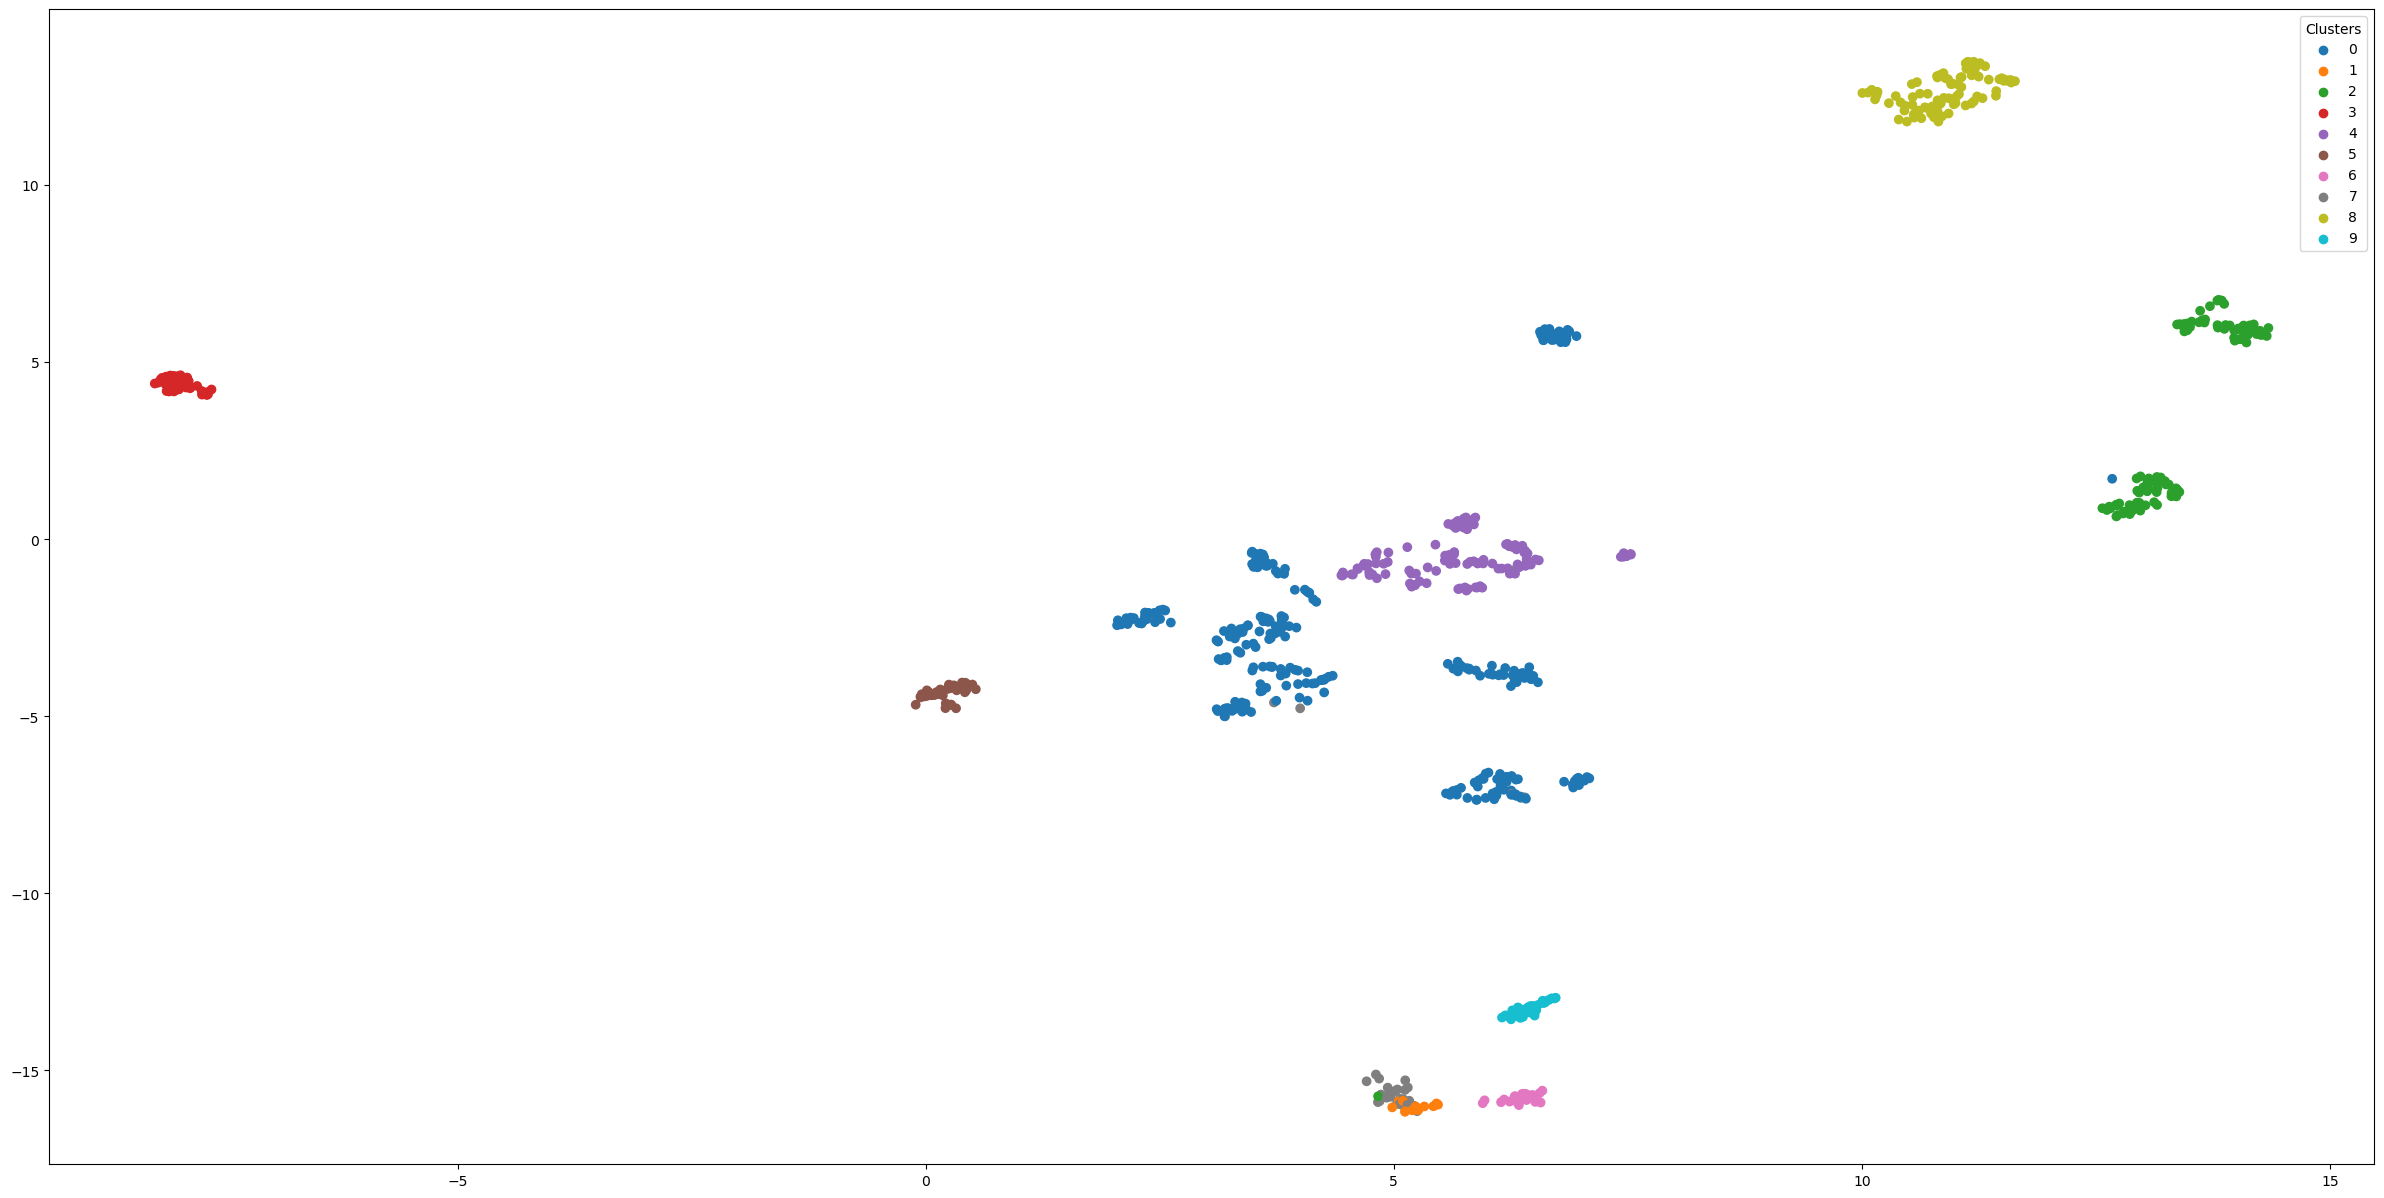

In [132]:
plot_dimensionality_reduction_results(umap_embedding, worker['rb_ward10'])

In [133]:
clusters_mapping = {
    0: "Mid-Age Stable Employees",
    1: "Employees with Chronic Absenteeism",
    2: "Young Low-Burden Performers",
    3: "Pet Lovers Employees",
    4: "Long-Distance Commuters with Pet Constraints",
    5: "Early-Career Unstable Workers",
    6: "Physically Strained Operational Staff",
    7: "Socially Driven High-Absence Group",
    8: "Healthy Young Reliable Employees",
    9: "Veteran Reliable Workforce"
}

In [134]:
# Create the final solution column
worker['final_solution'] = worker['rb_ward10']
# Map the cluster numbers to names
worker['Final_Cluster'] = [clusters_mapping[value] for value in worker['final_solution']]

In [135]:
worker[['Final_Cluster']].value_counts()

Final_Cluster                               
Mid-Age Stable Employees                        285
Long-Distance Commuters with Pet Constraints    117
Young Low-Burden Performers                     110
Healthy Young Reliable Employees                 90
Pet Lovers Employees                             43
Early-Career Unstable Workers                    42
Veteran Reliable Workforce                       35
Socially Driven High-Absence Group               33
Physically Strained Operational Staff            29
Employees with Chronic Absenteeism               16
Name: count, dtype: int64

In [142]:
cluster_colors = {
    0: 'blue',          
    1: 'orange',      
    2: 'green',      
    3: 'red',       
    4: 'purple',      
    5: 'brown',    
    6: 'pink',      
    7: 'grey',  
    8: 'yellow',  
    9: 'deepskyblue'   
}

  0%|          | 0/36 [00:00<?, ?it/s]

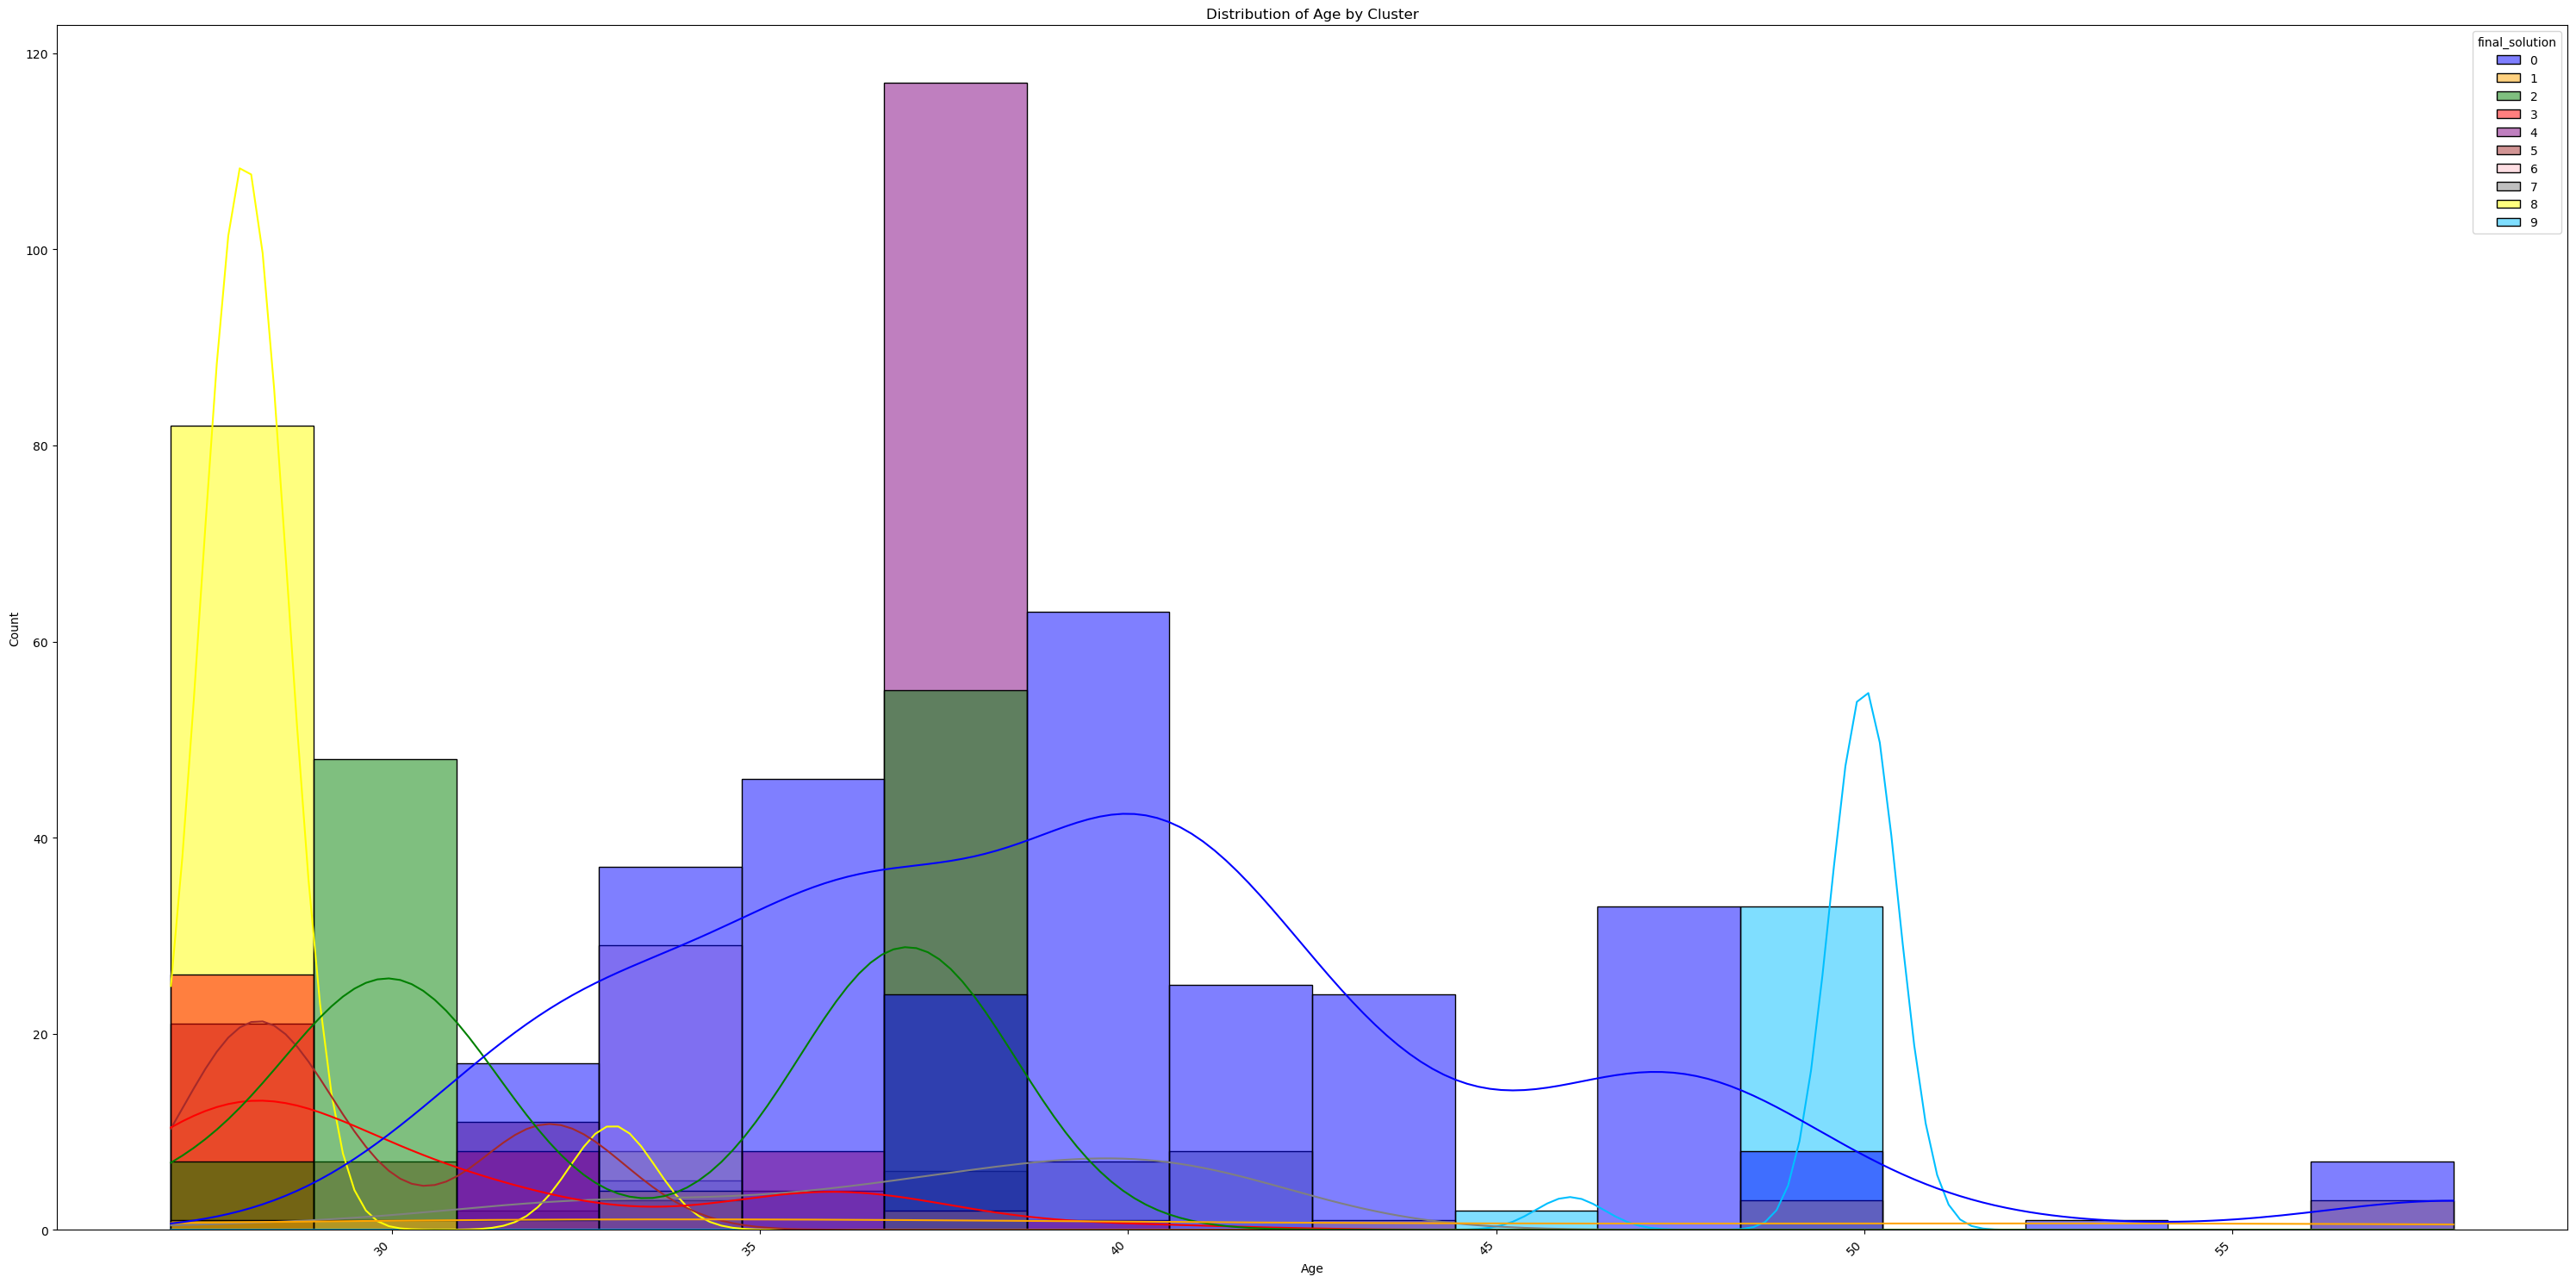

  3%|▎         | 1/36 [00:00<00:15,  2.22it/s]

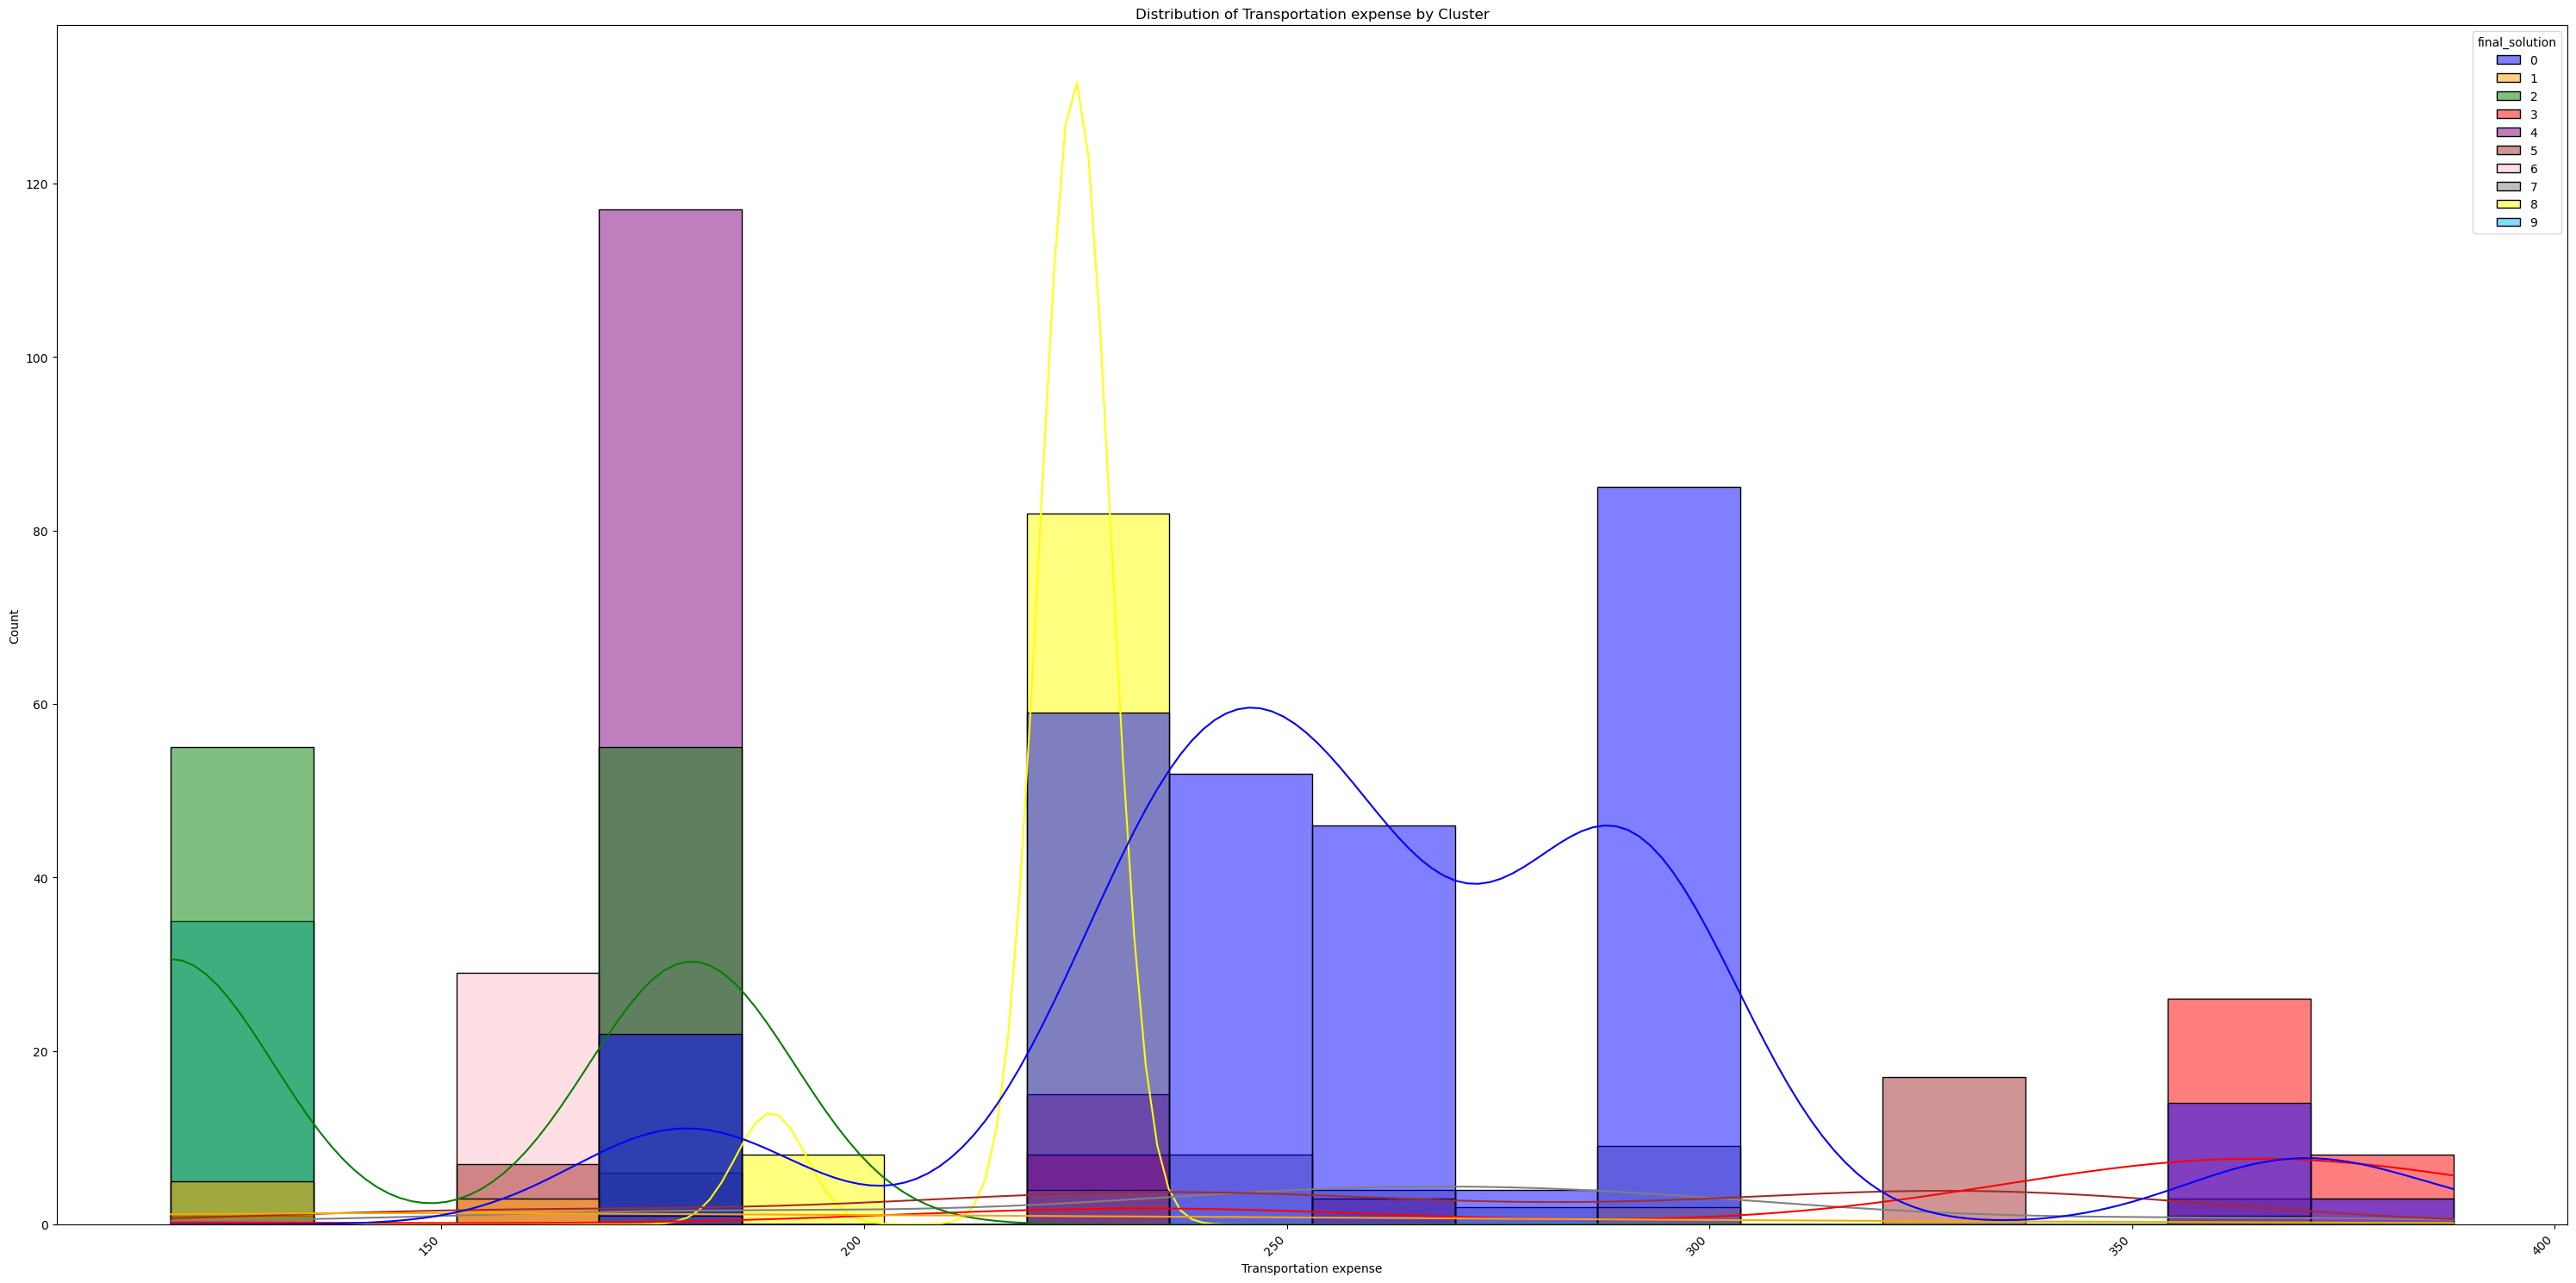

  6%|▌         | 2/36 [00:00<00:11,  2.85it/s]

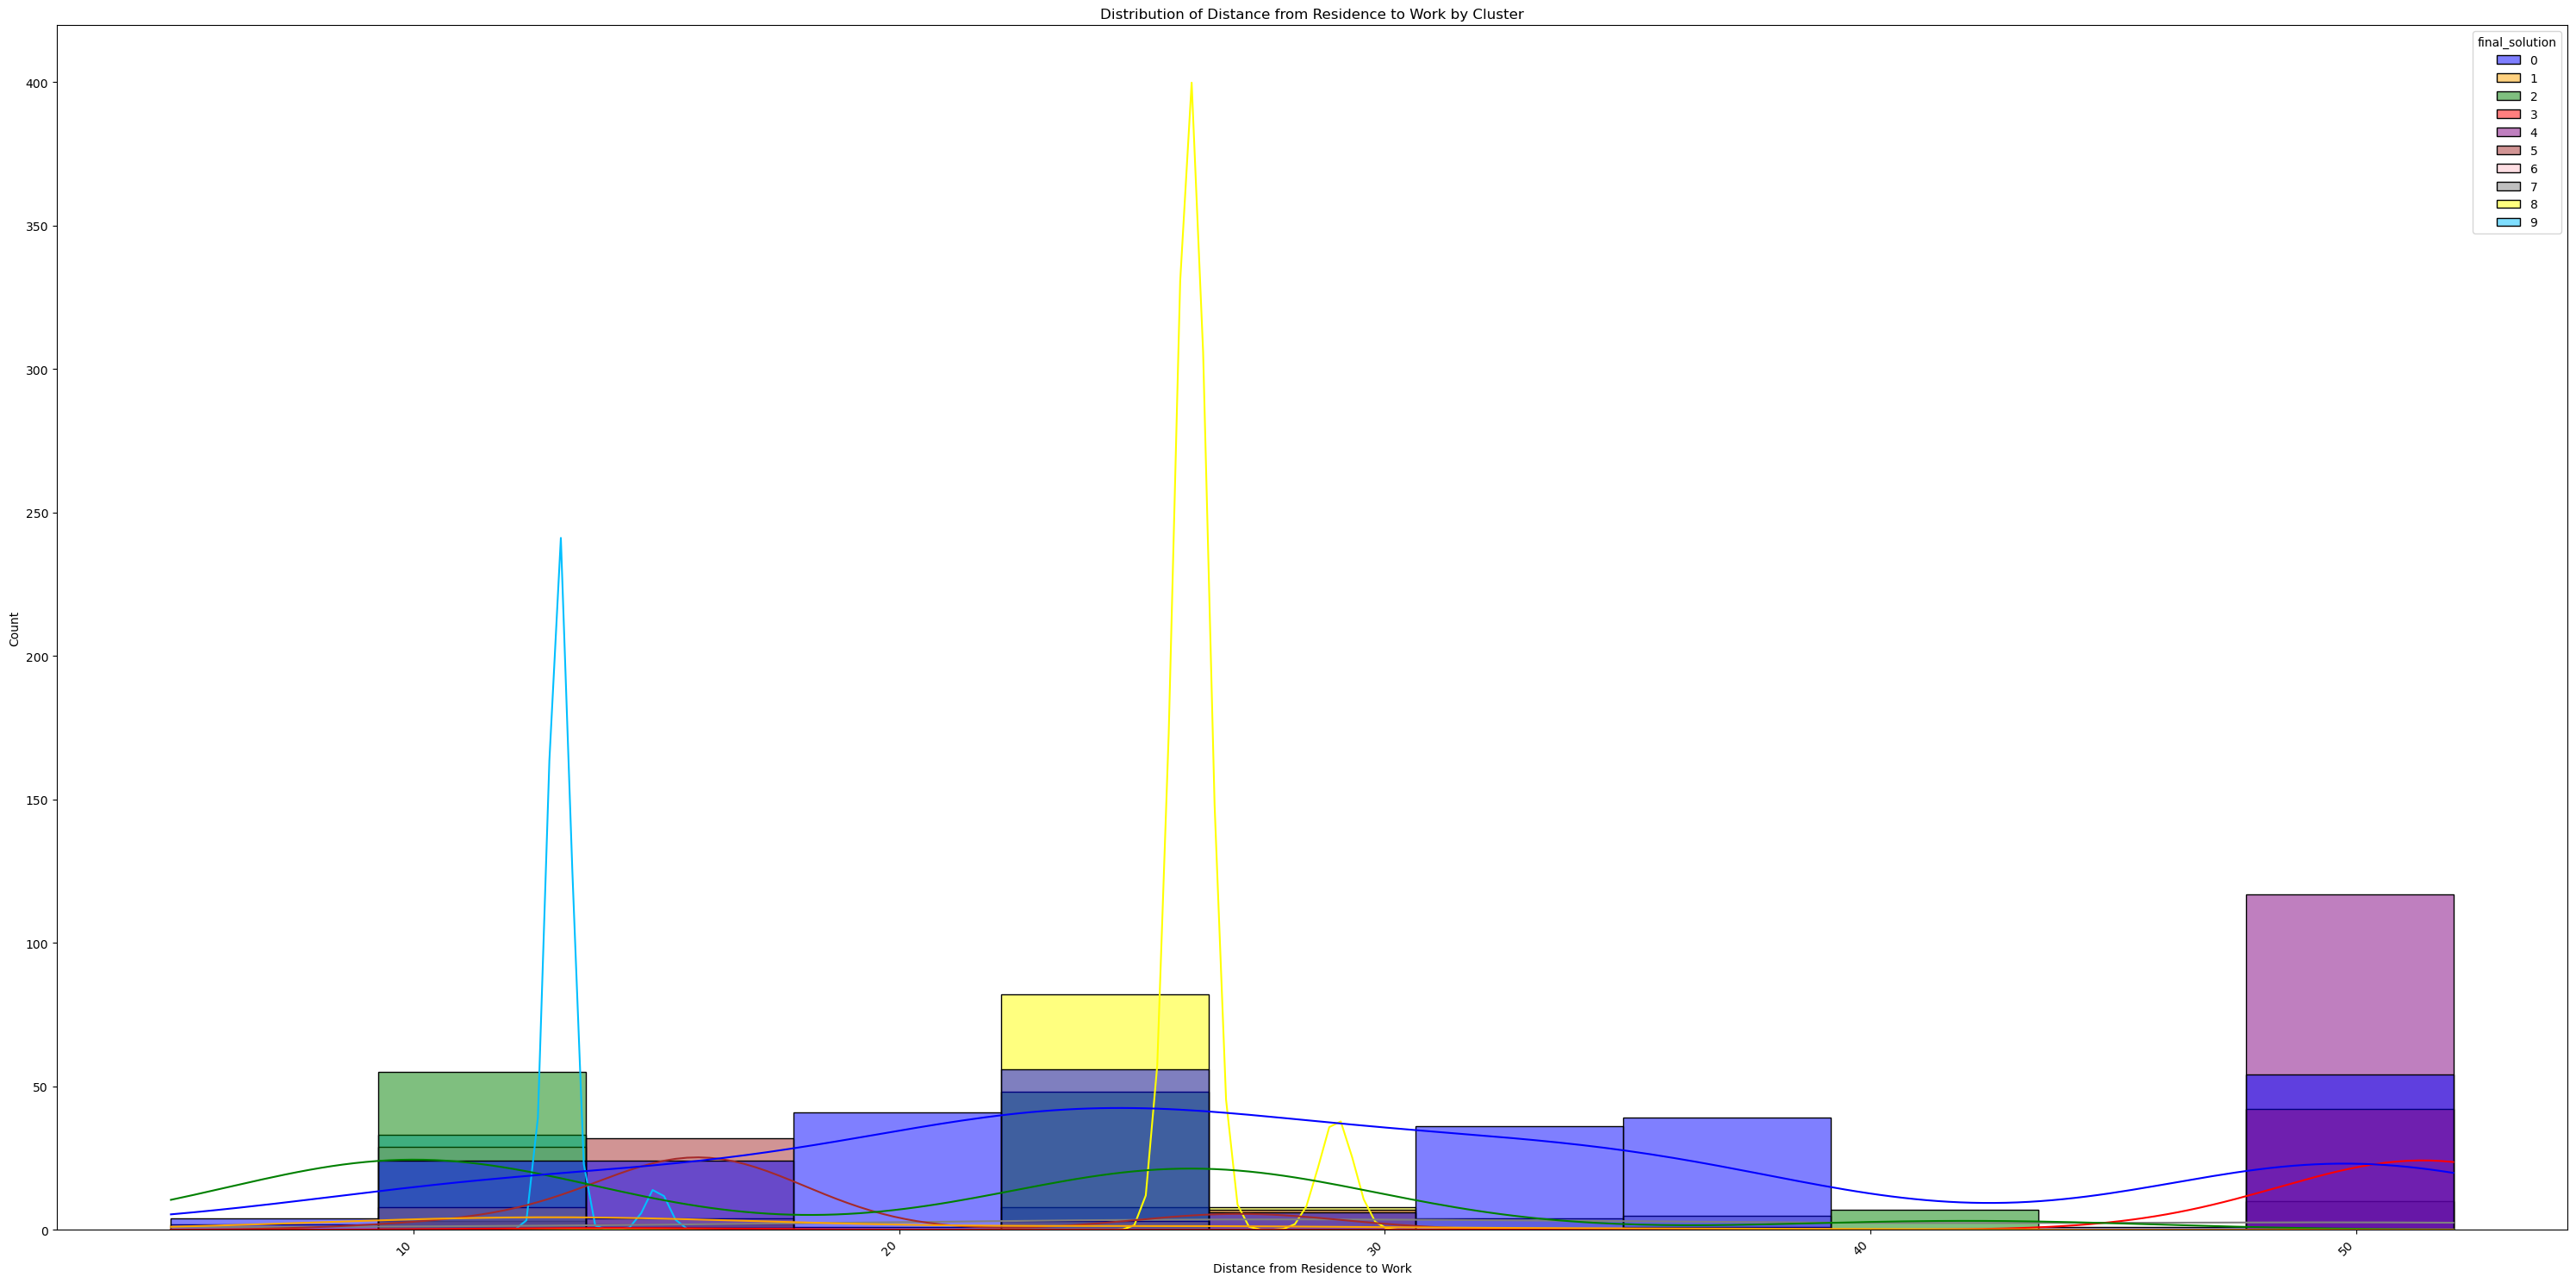

  8%|▊         | 3/36 [00:01<00:10,  3.02it/s]

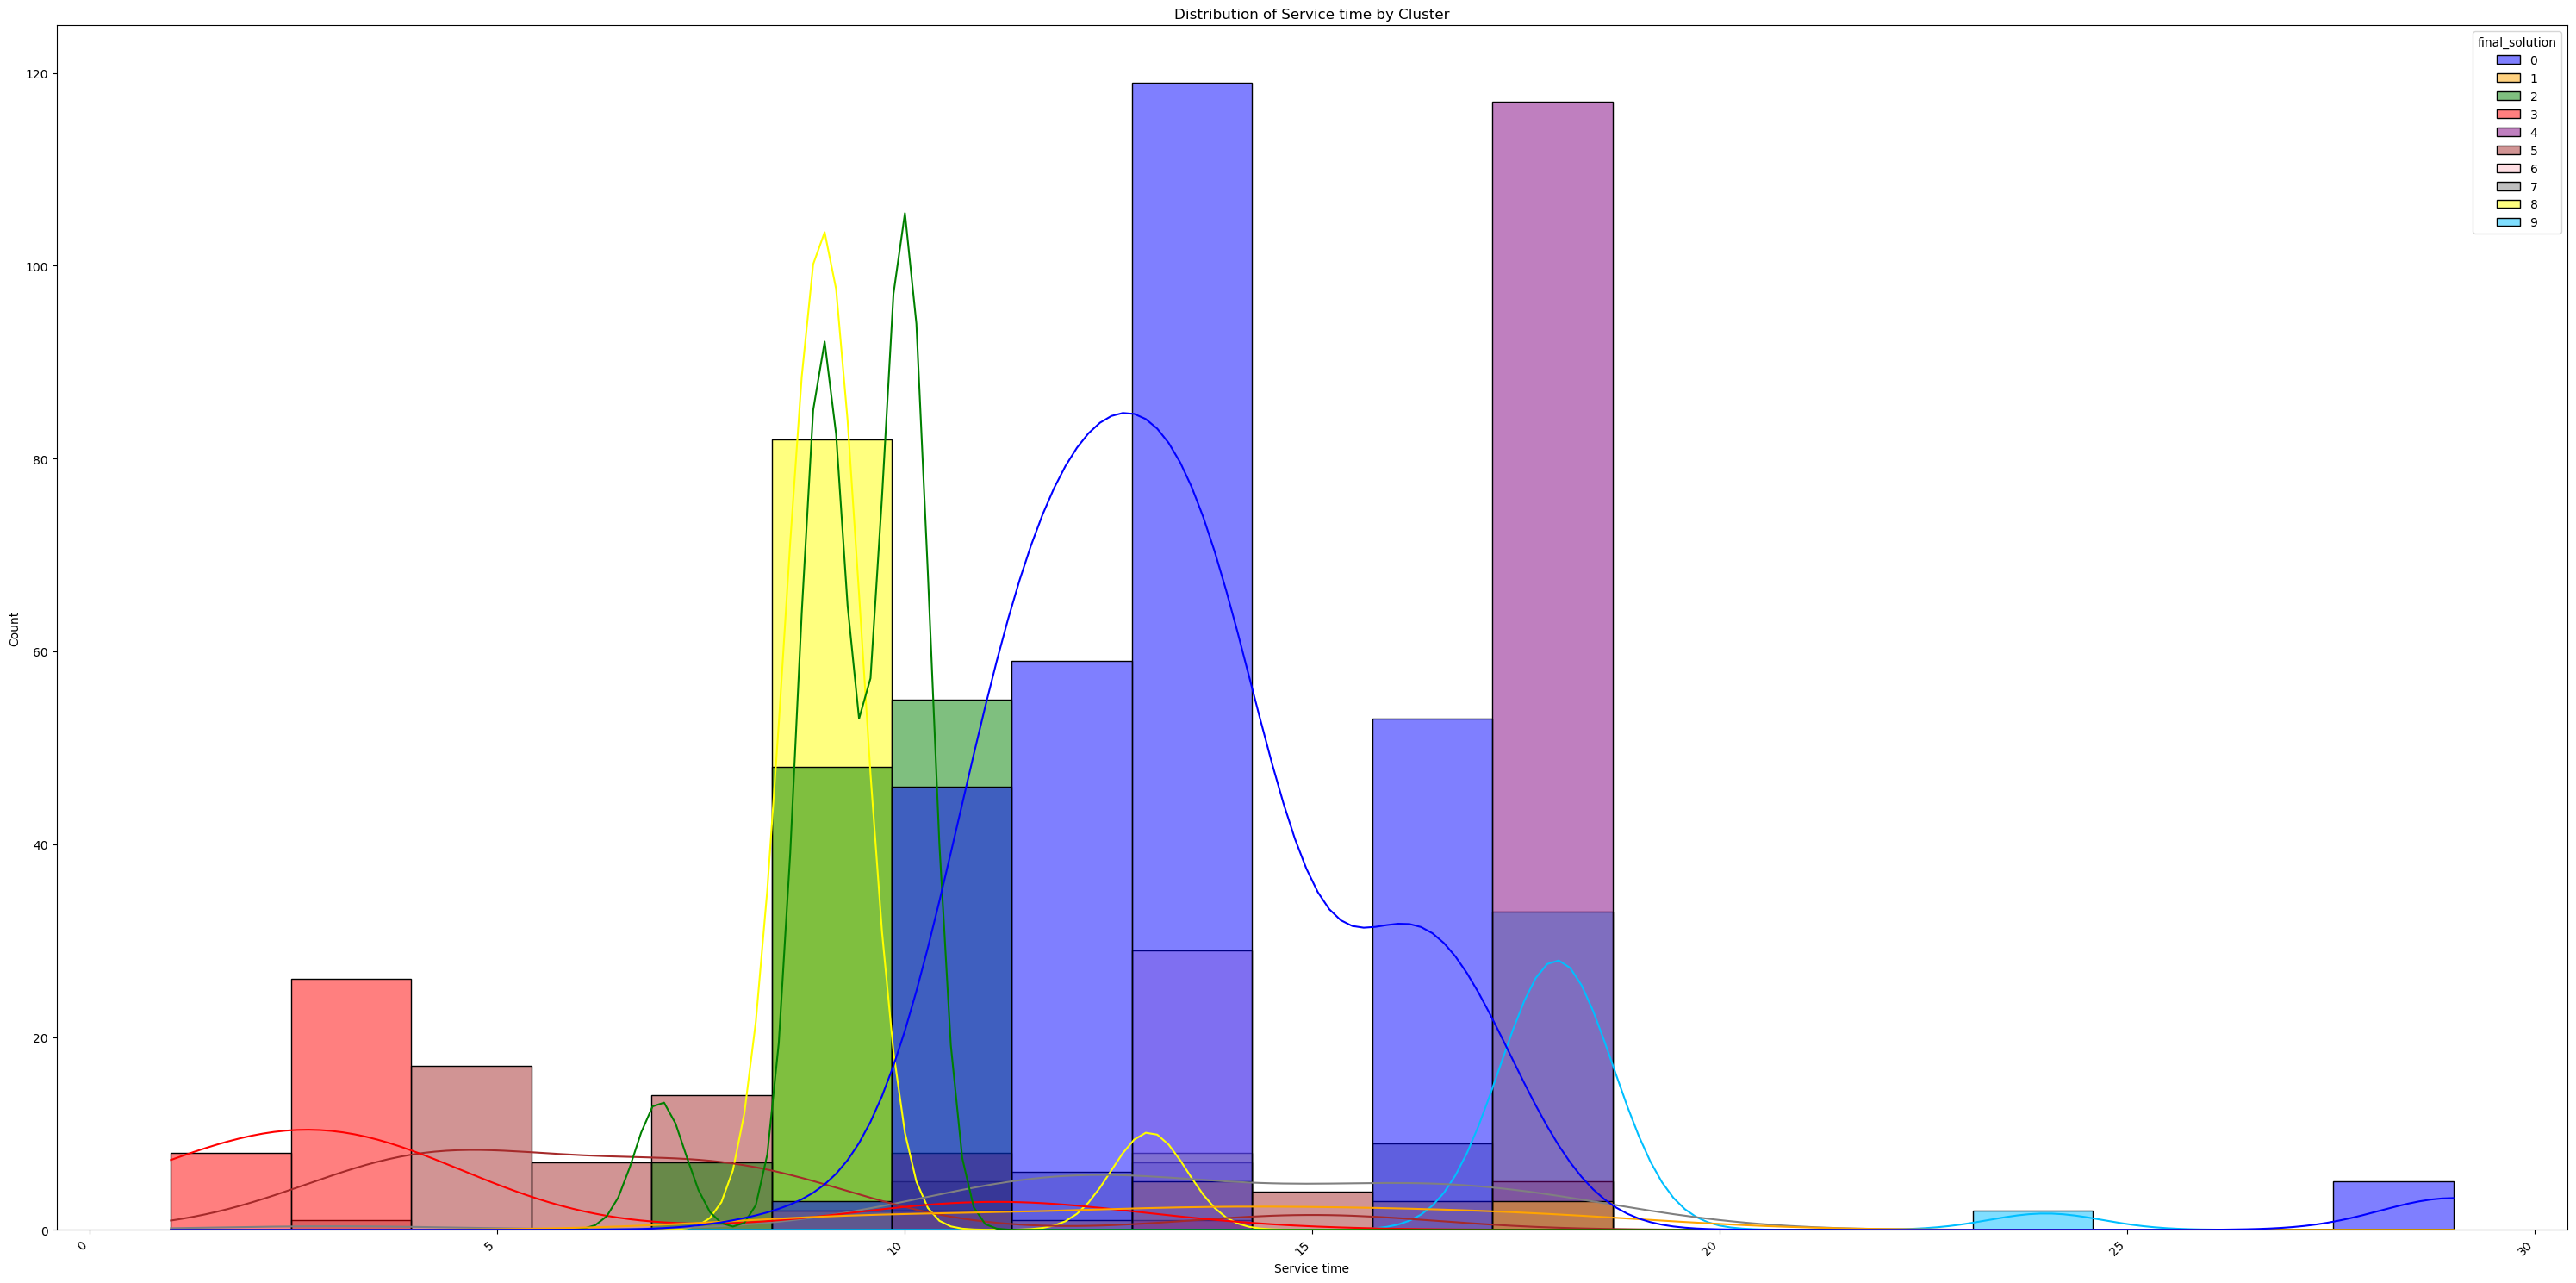

 11%|█         | 4/36 [00:01<00:11,  2.86it/s]

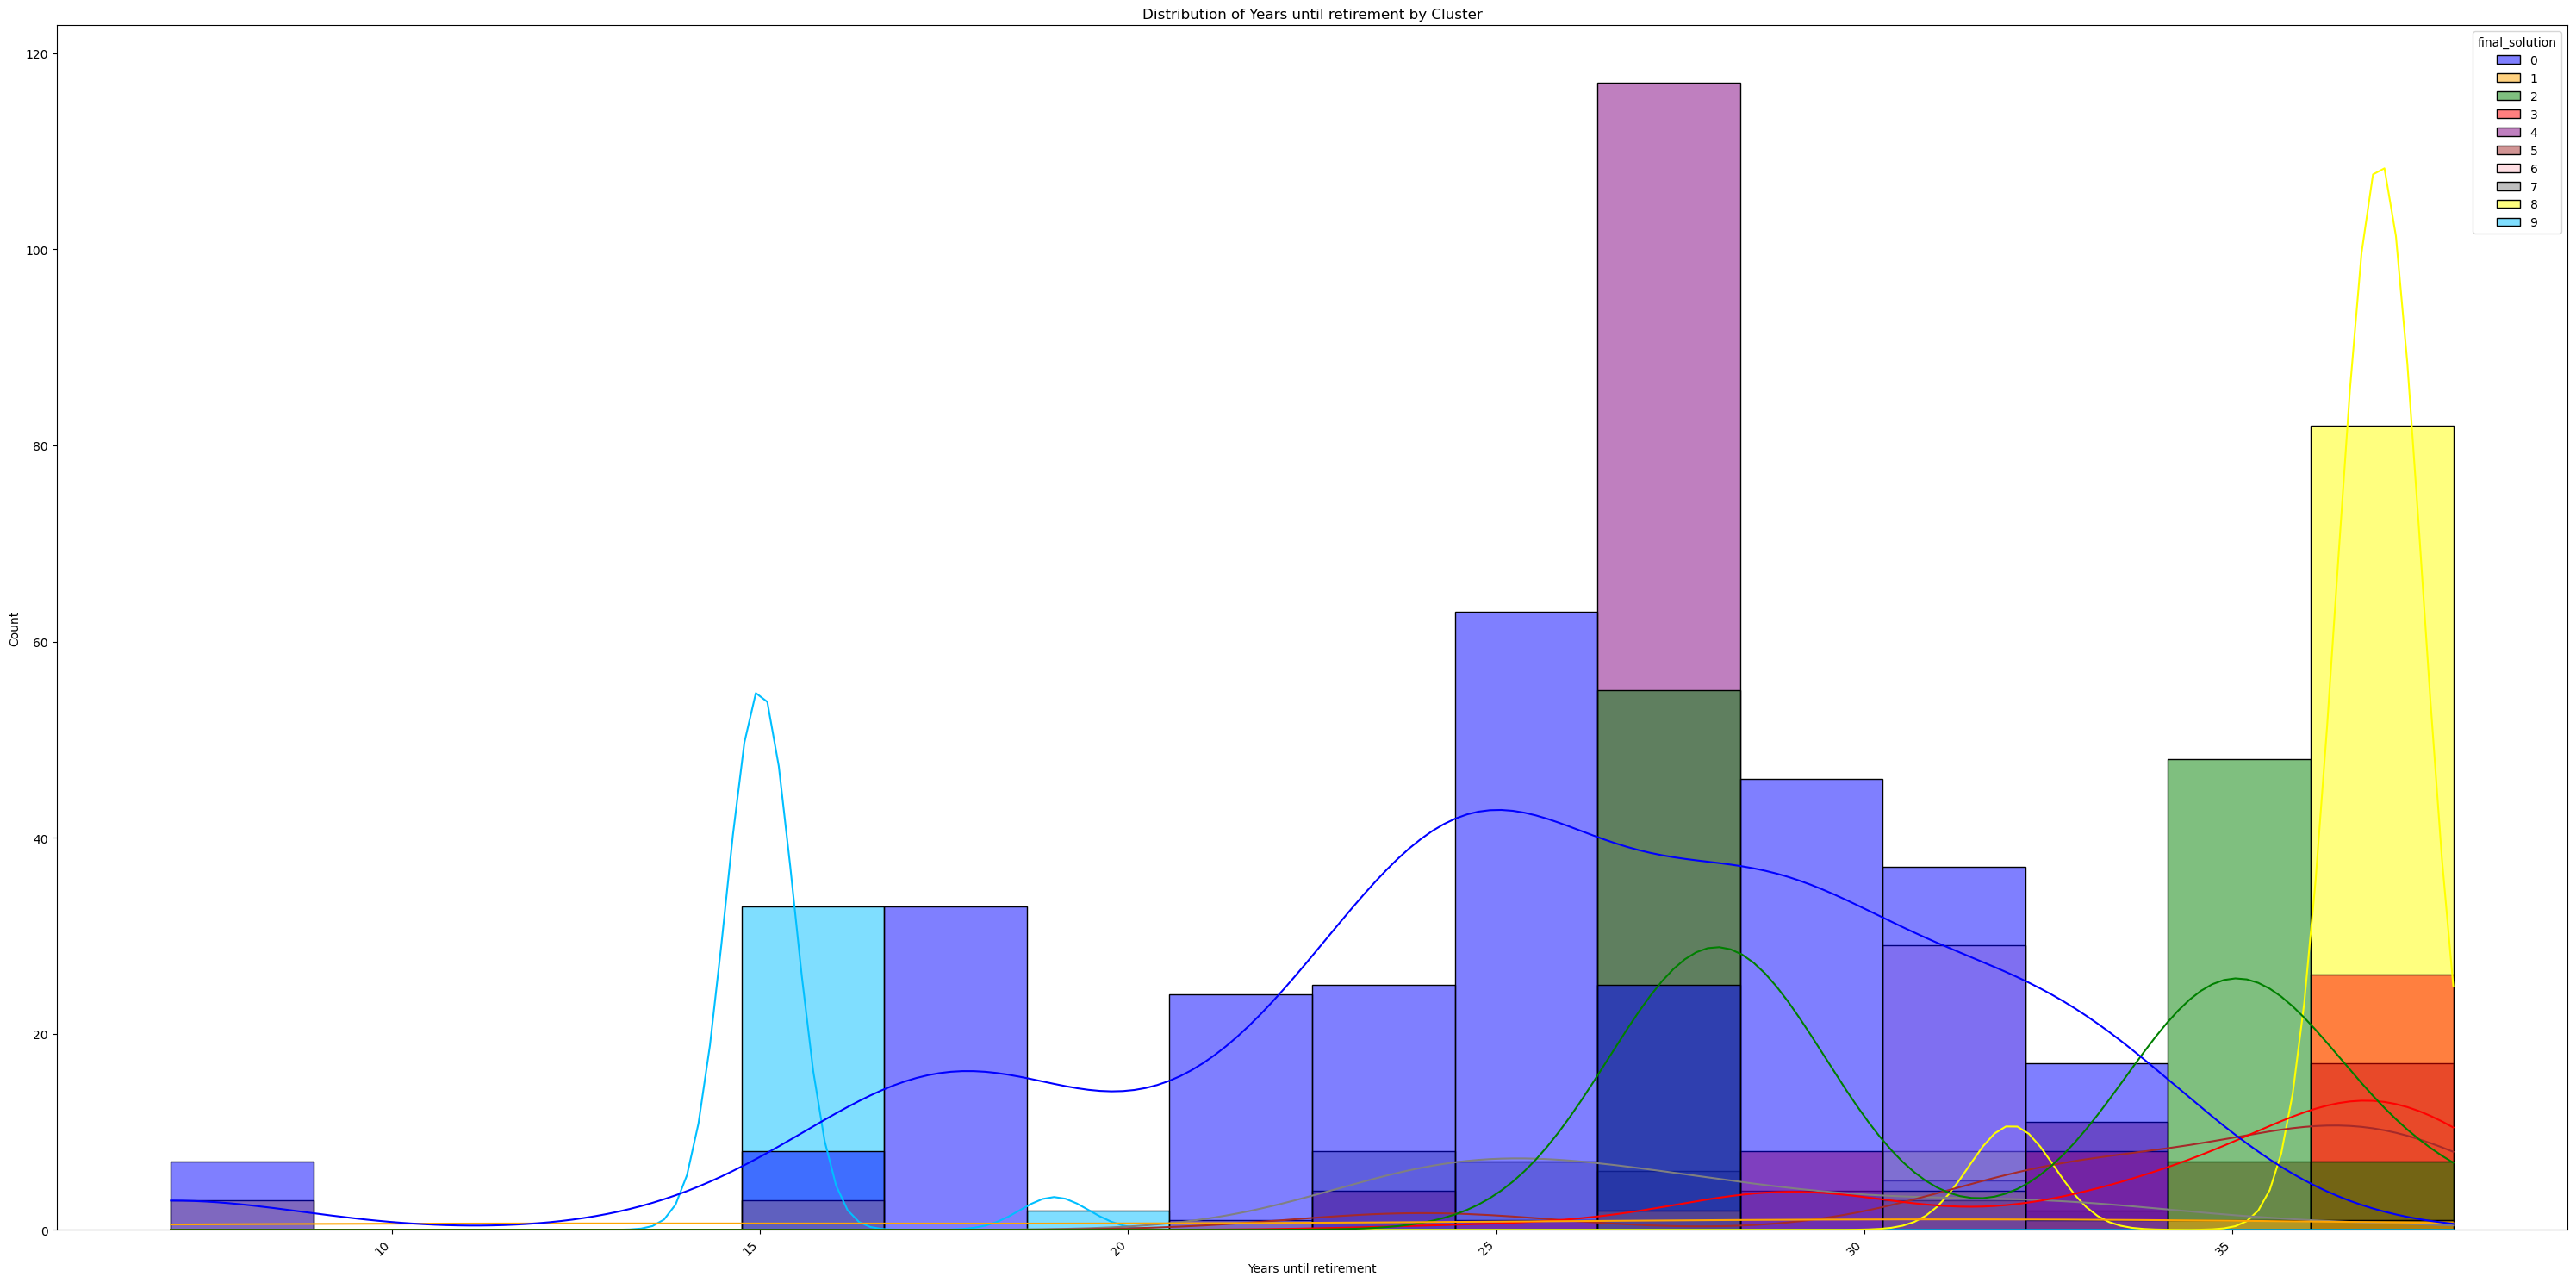

 14%|█▍        | 5/36 [00:01<00:10,  3.00it/s]

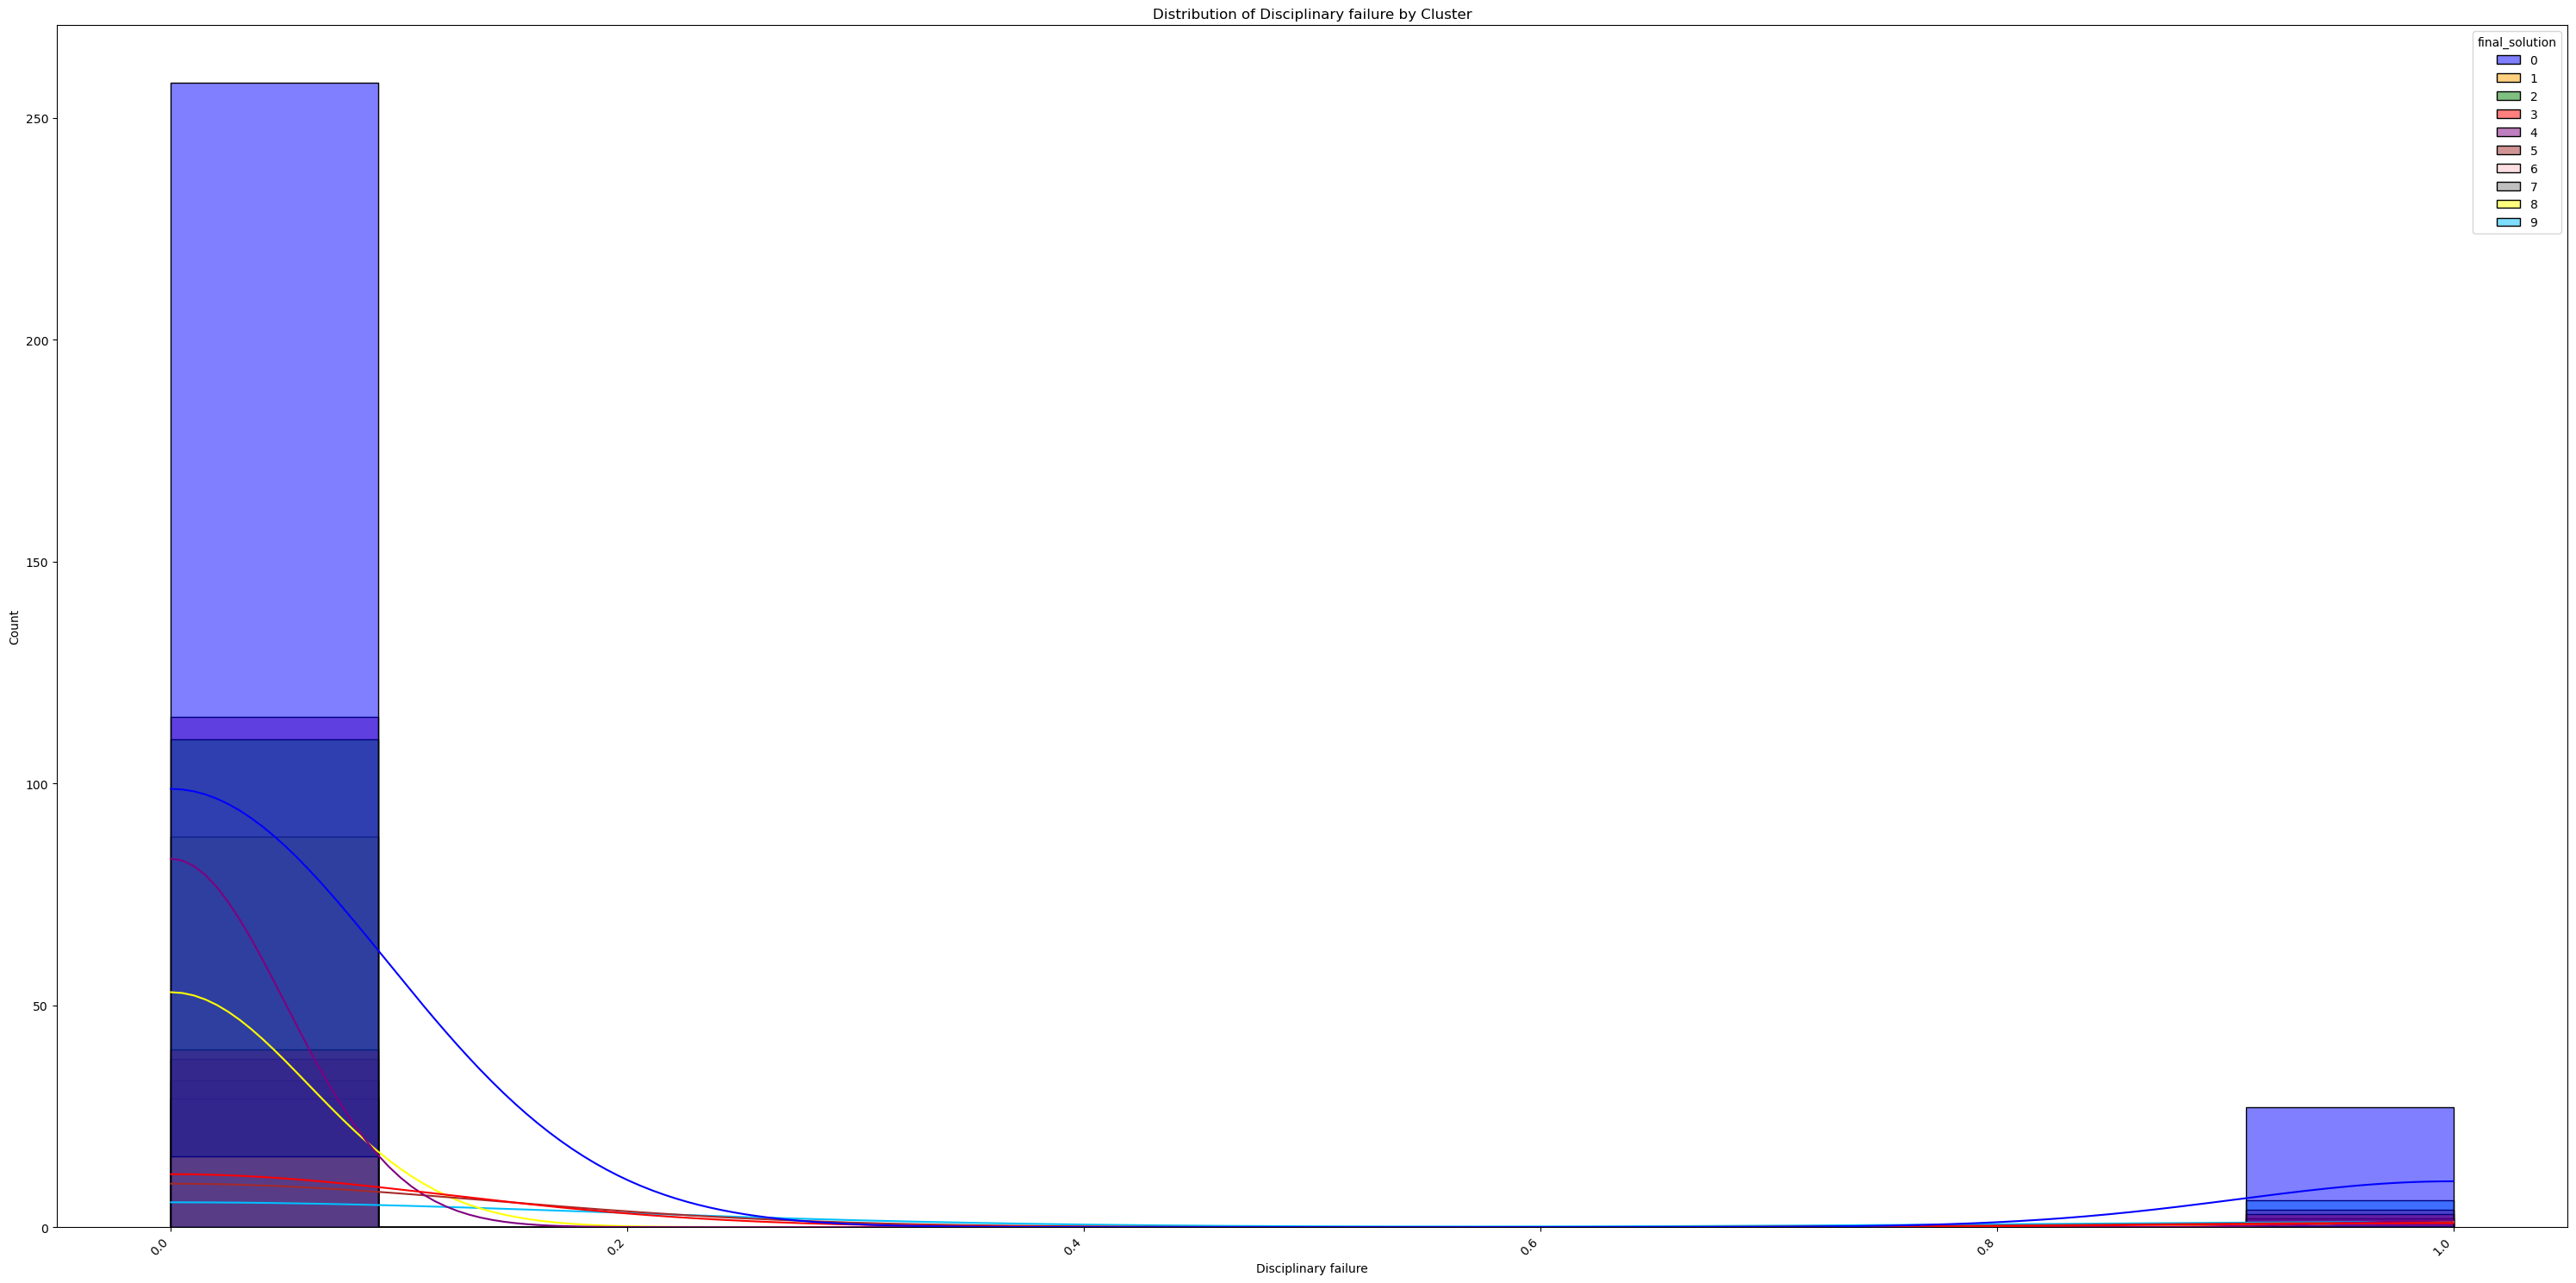

 17%|█▋        | 6/36 [00:02<00:09,  3.09it/s]

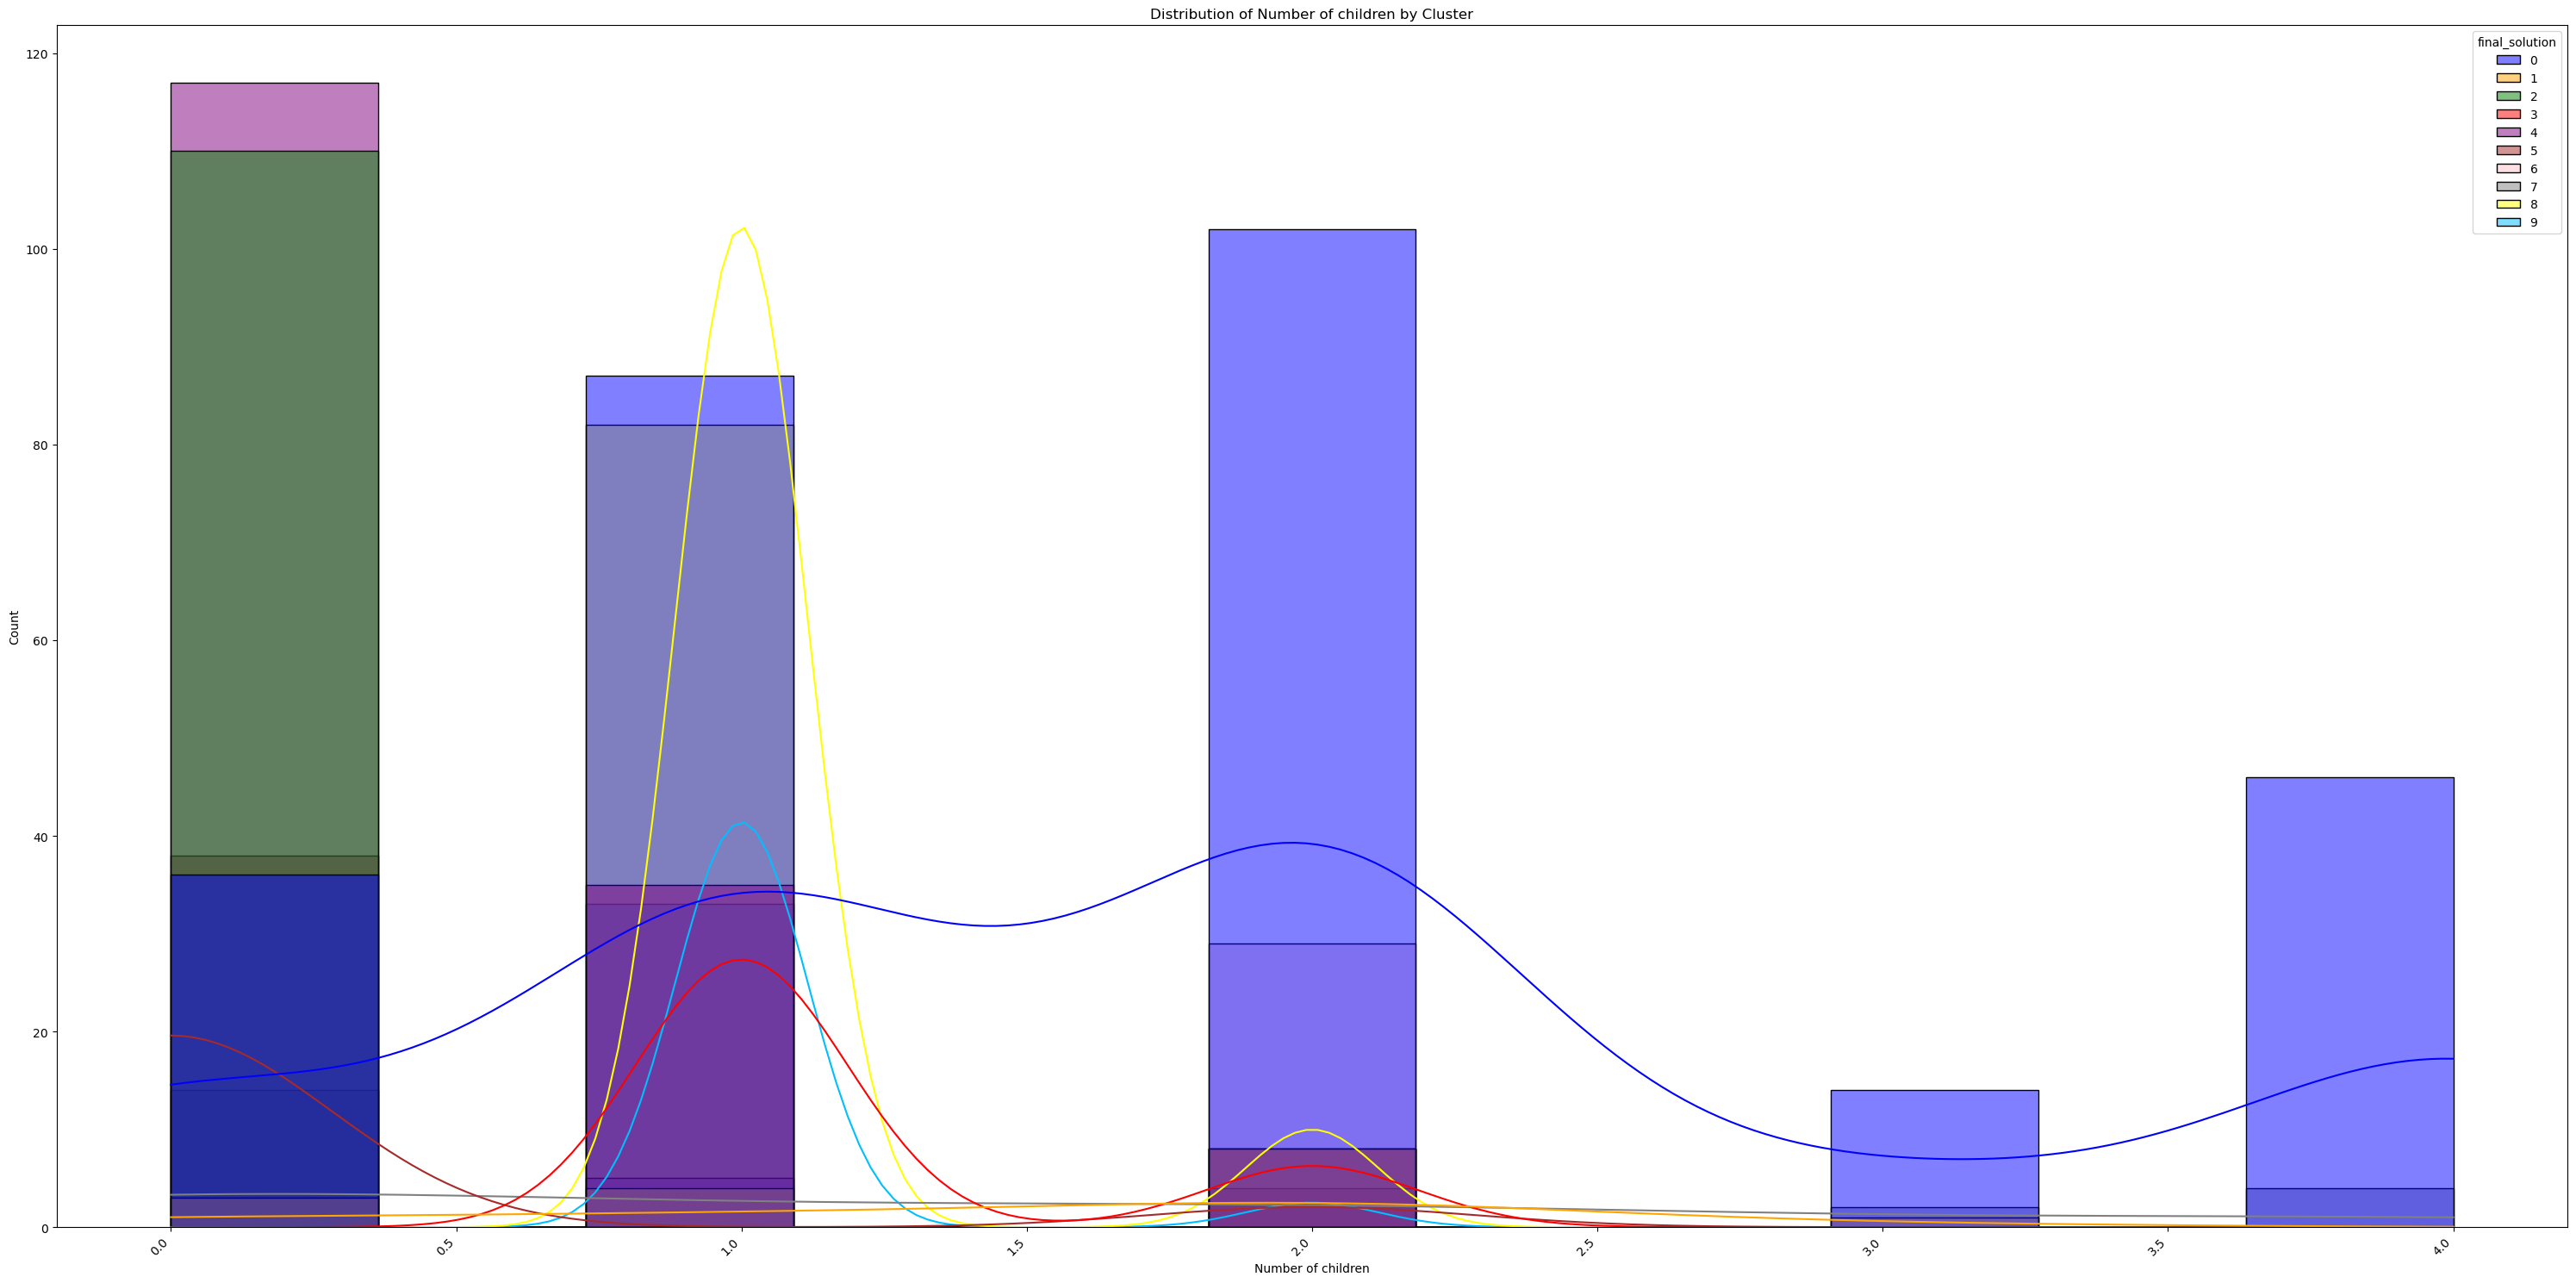

 19%|█▉        | 7/36 [00:02<00:08,  3.31it/s]

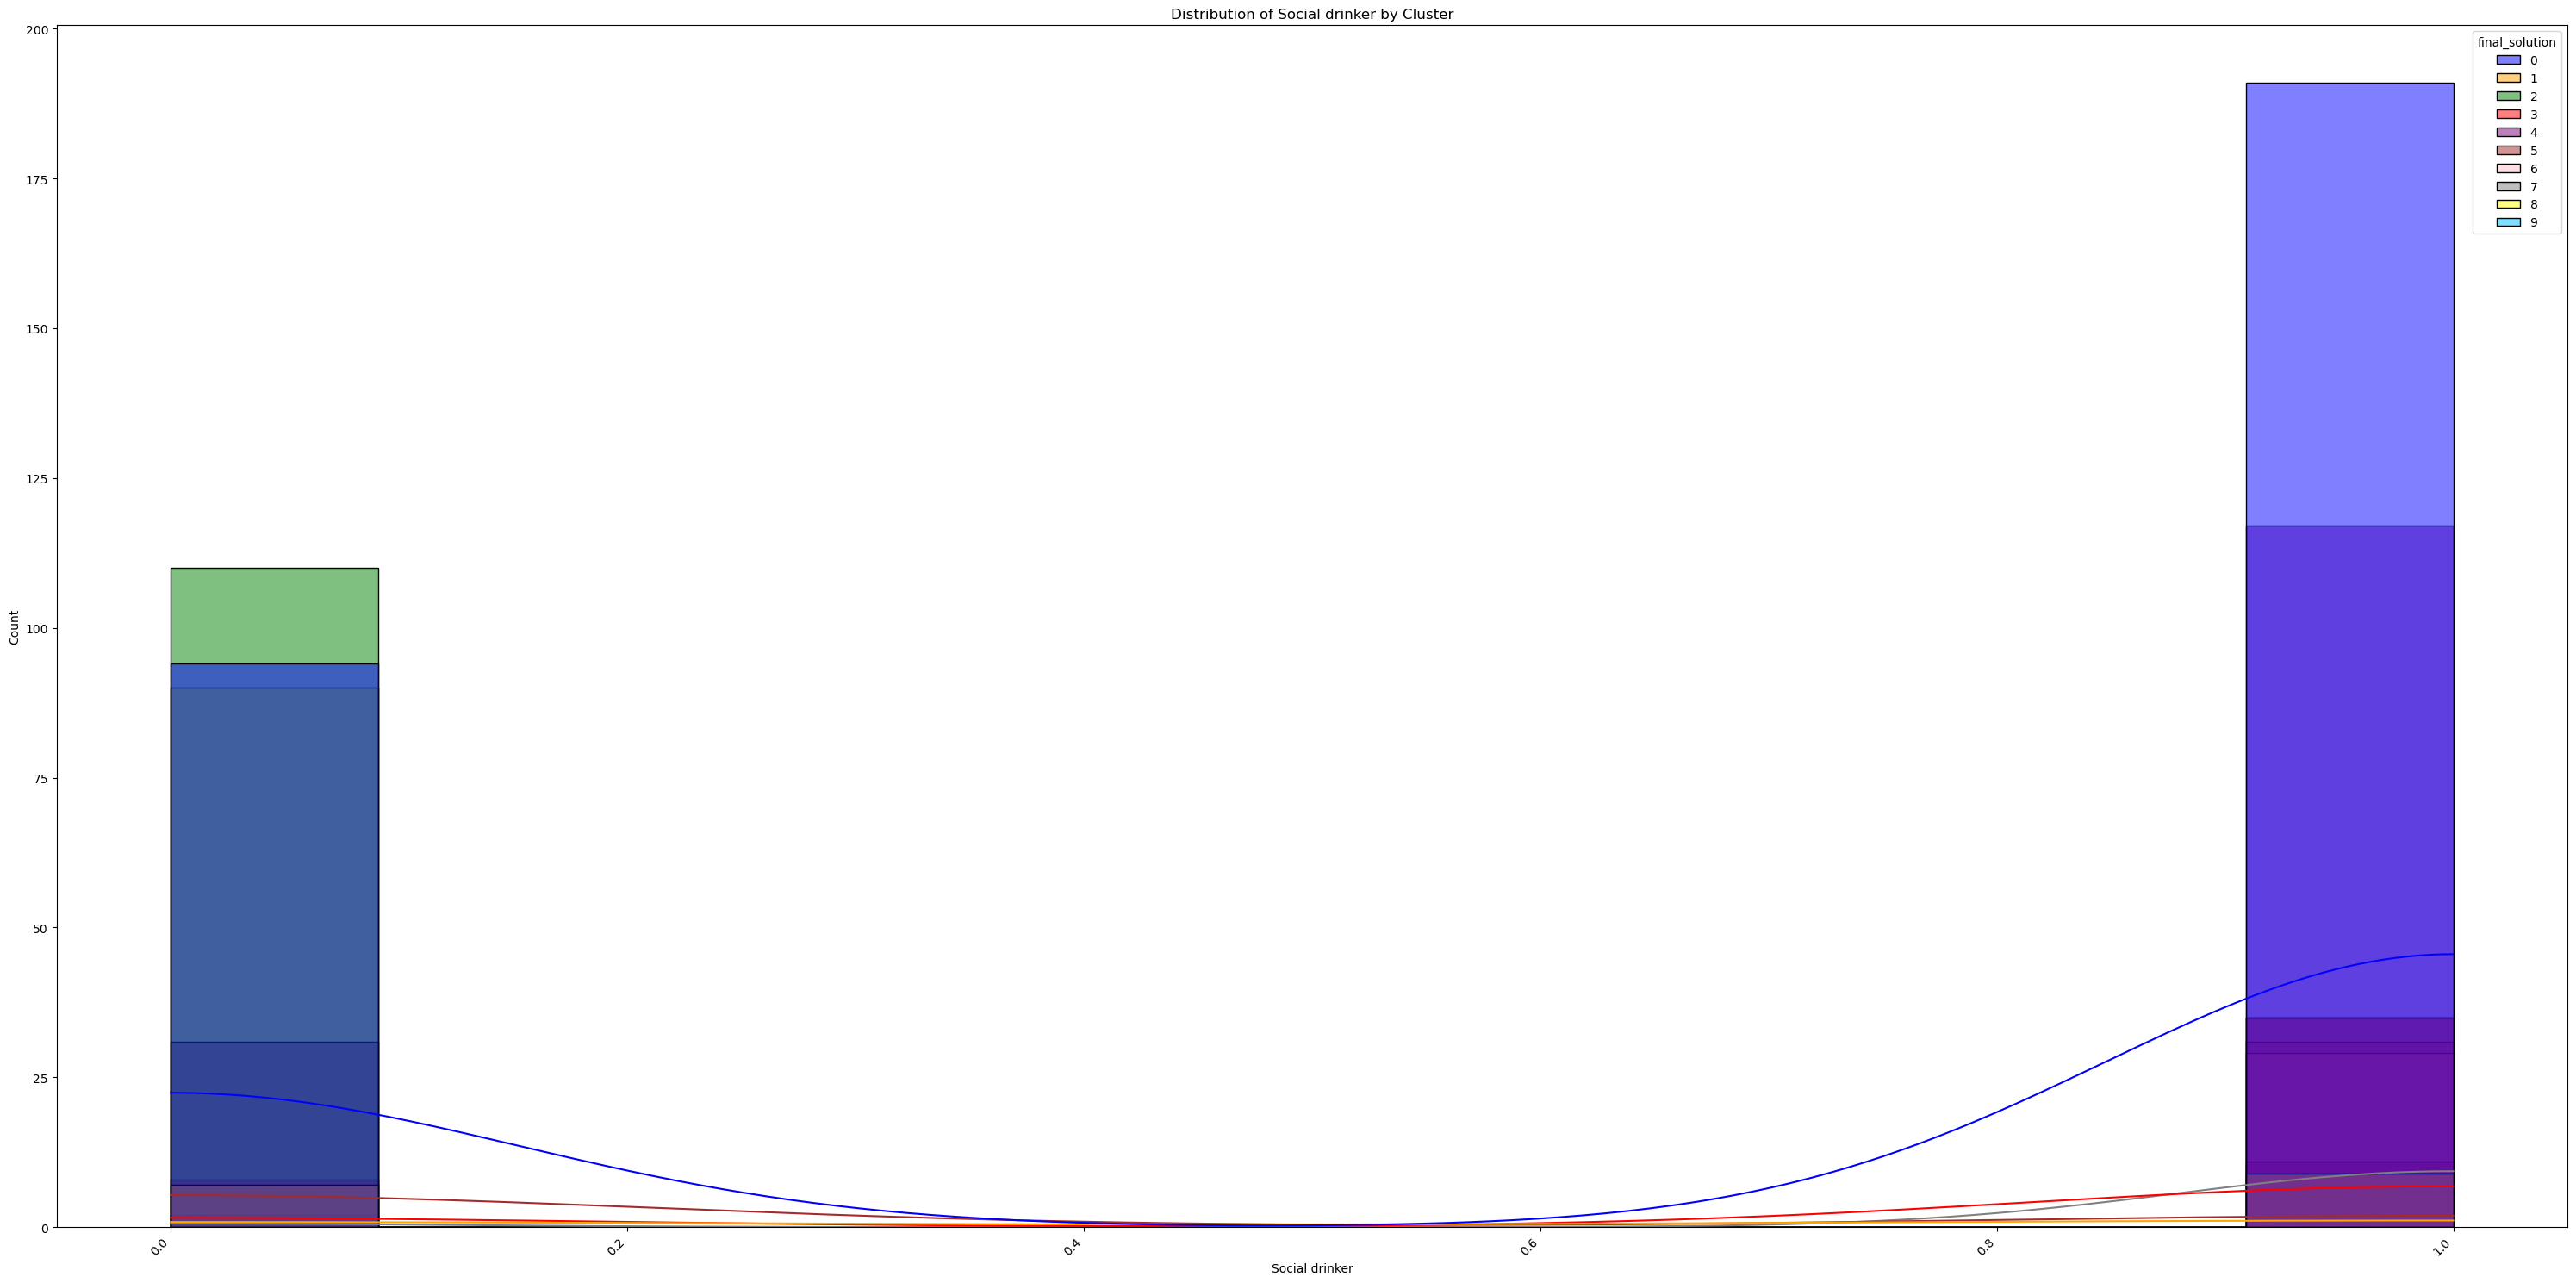

 22%|██▏       | 8/36 [00:02<00:07,  3.57it/s]

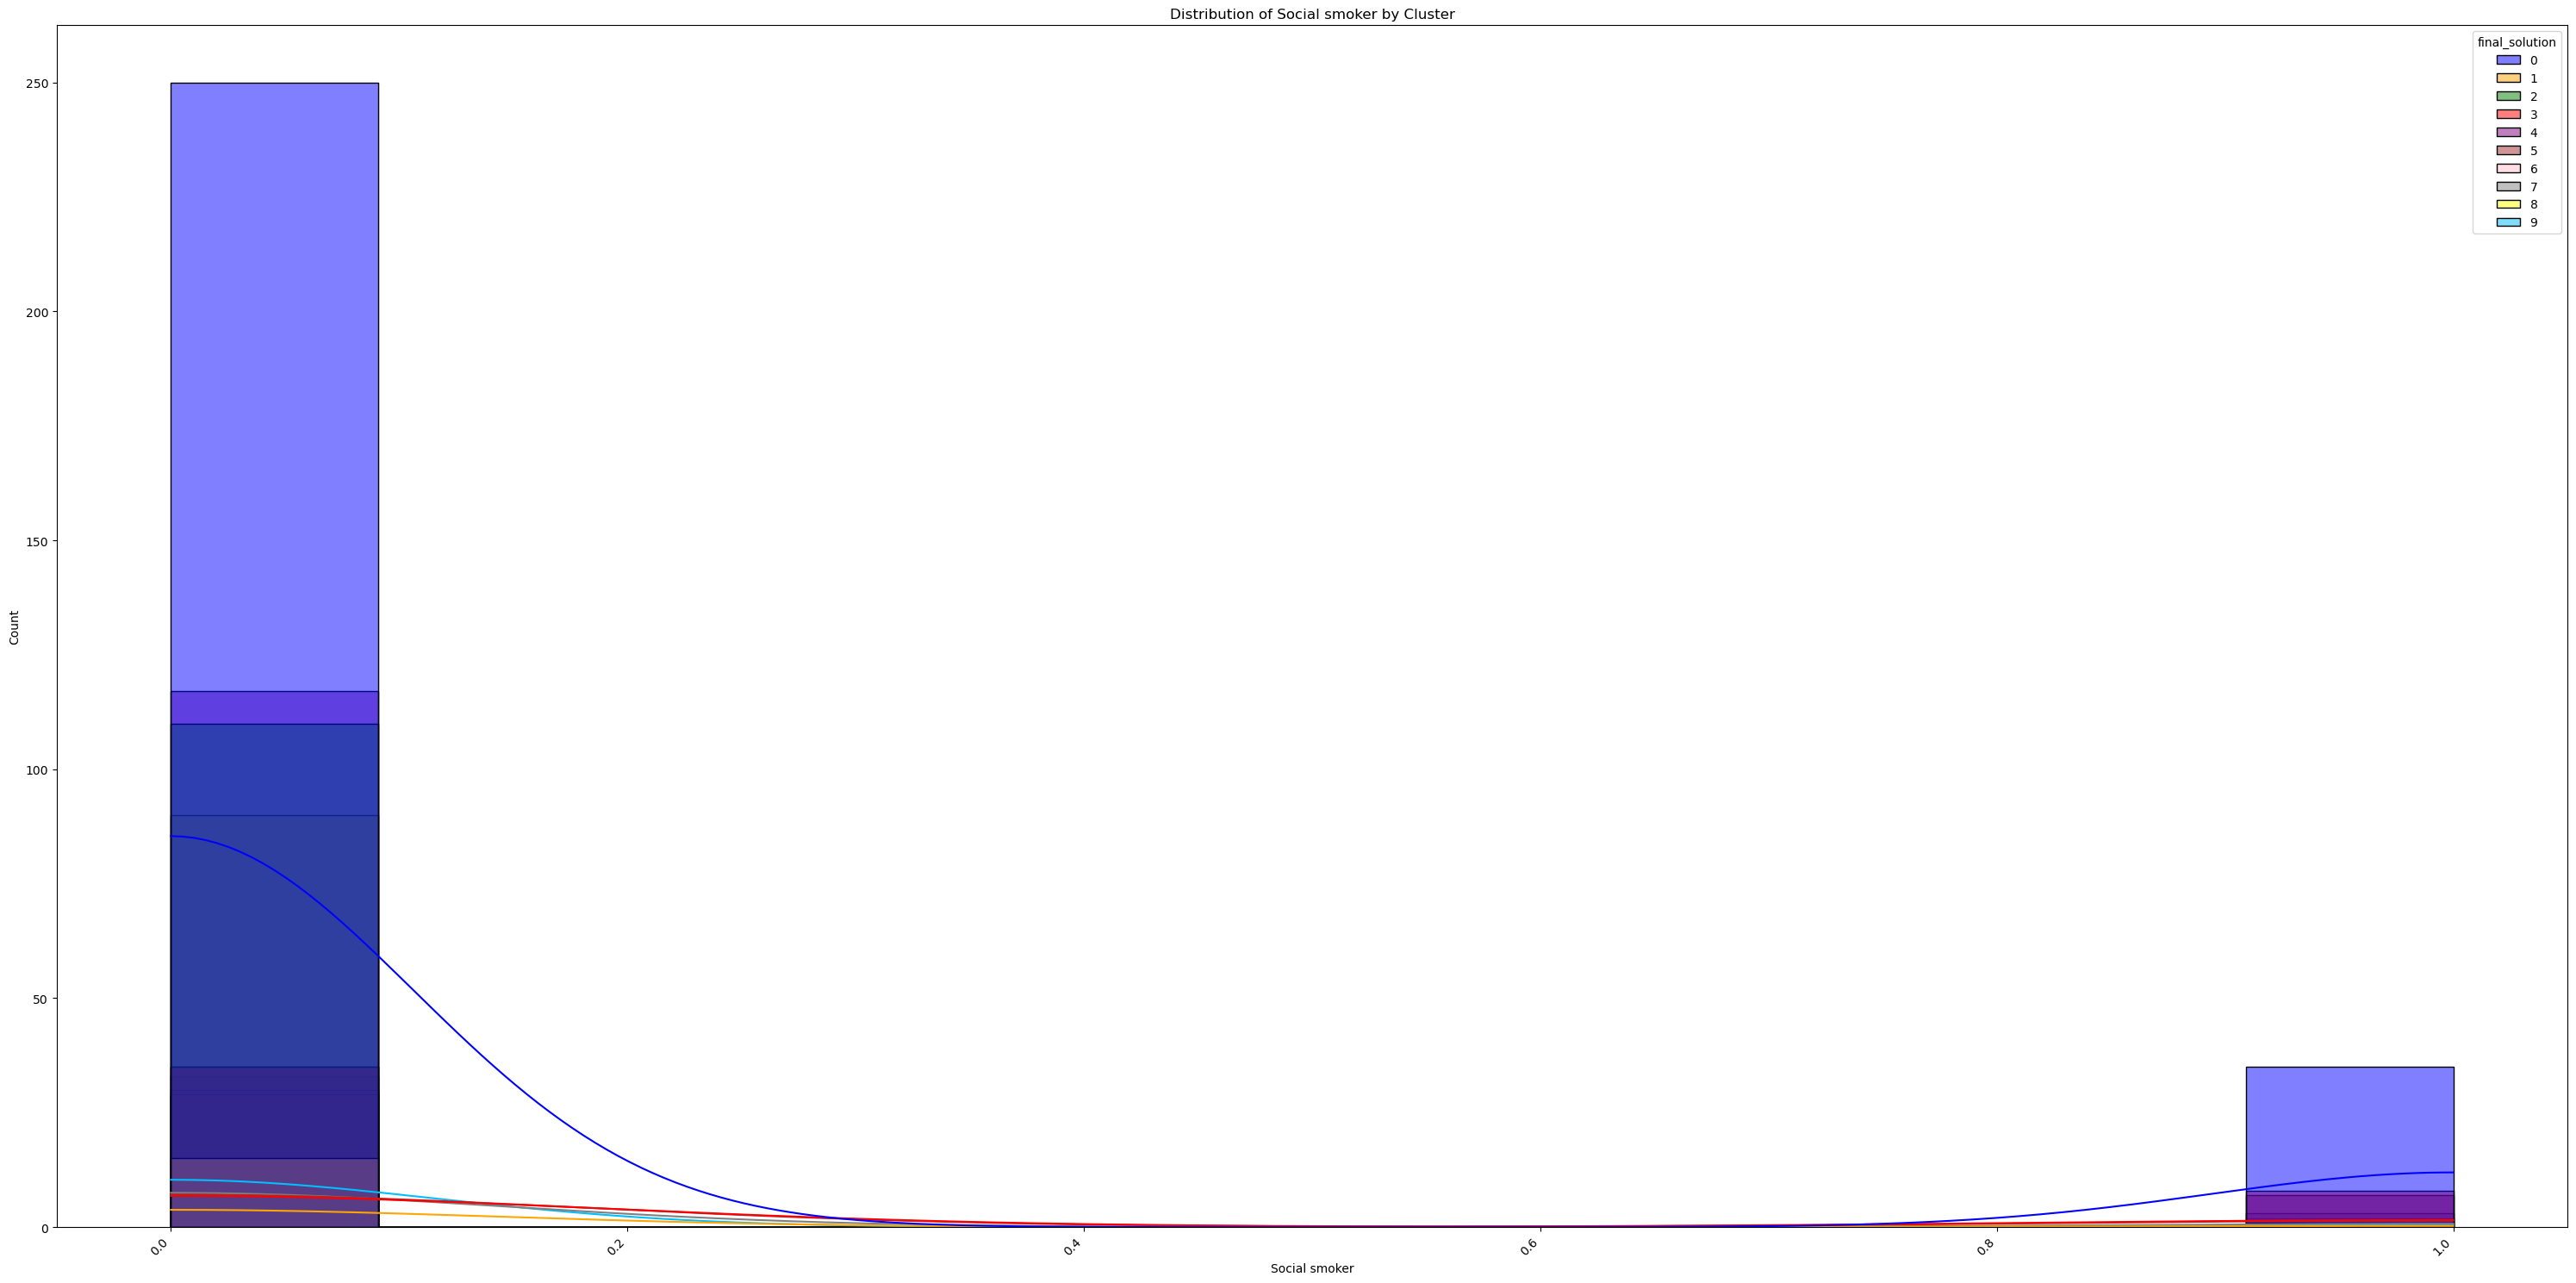

 25%|██▌       | 9/36 [00:02<00:07,  3.69it/s]

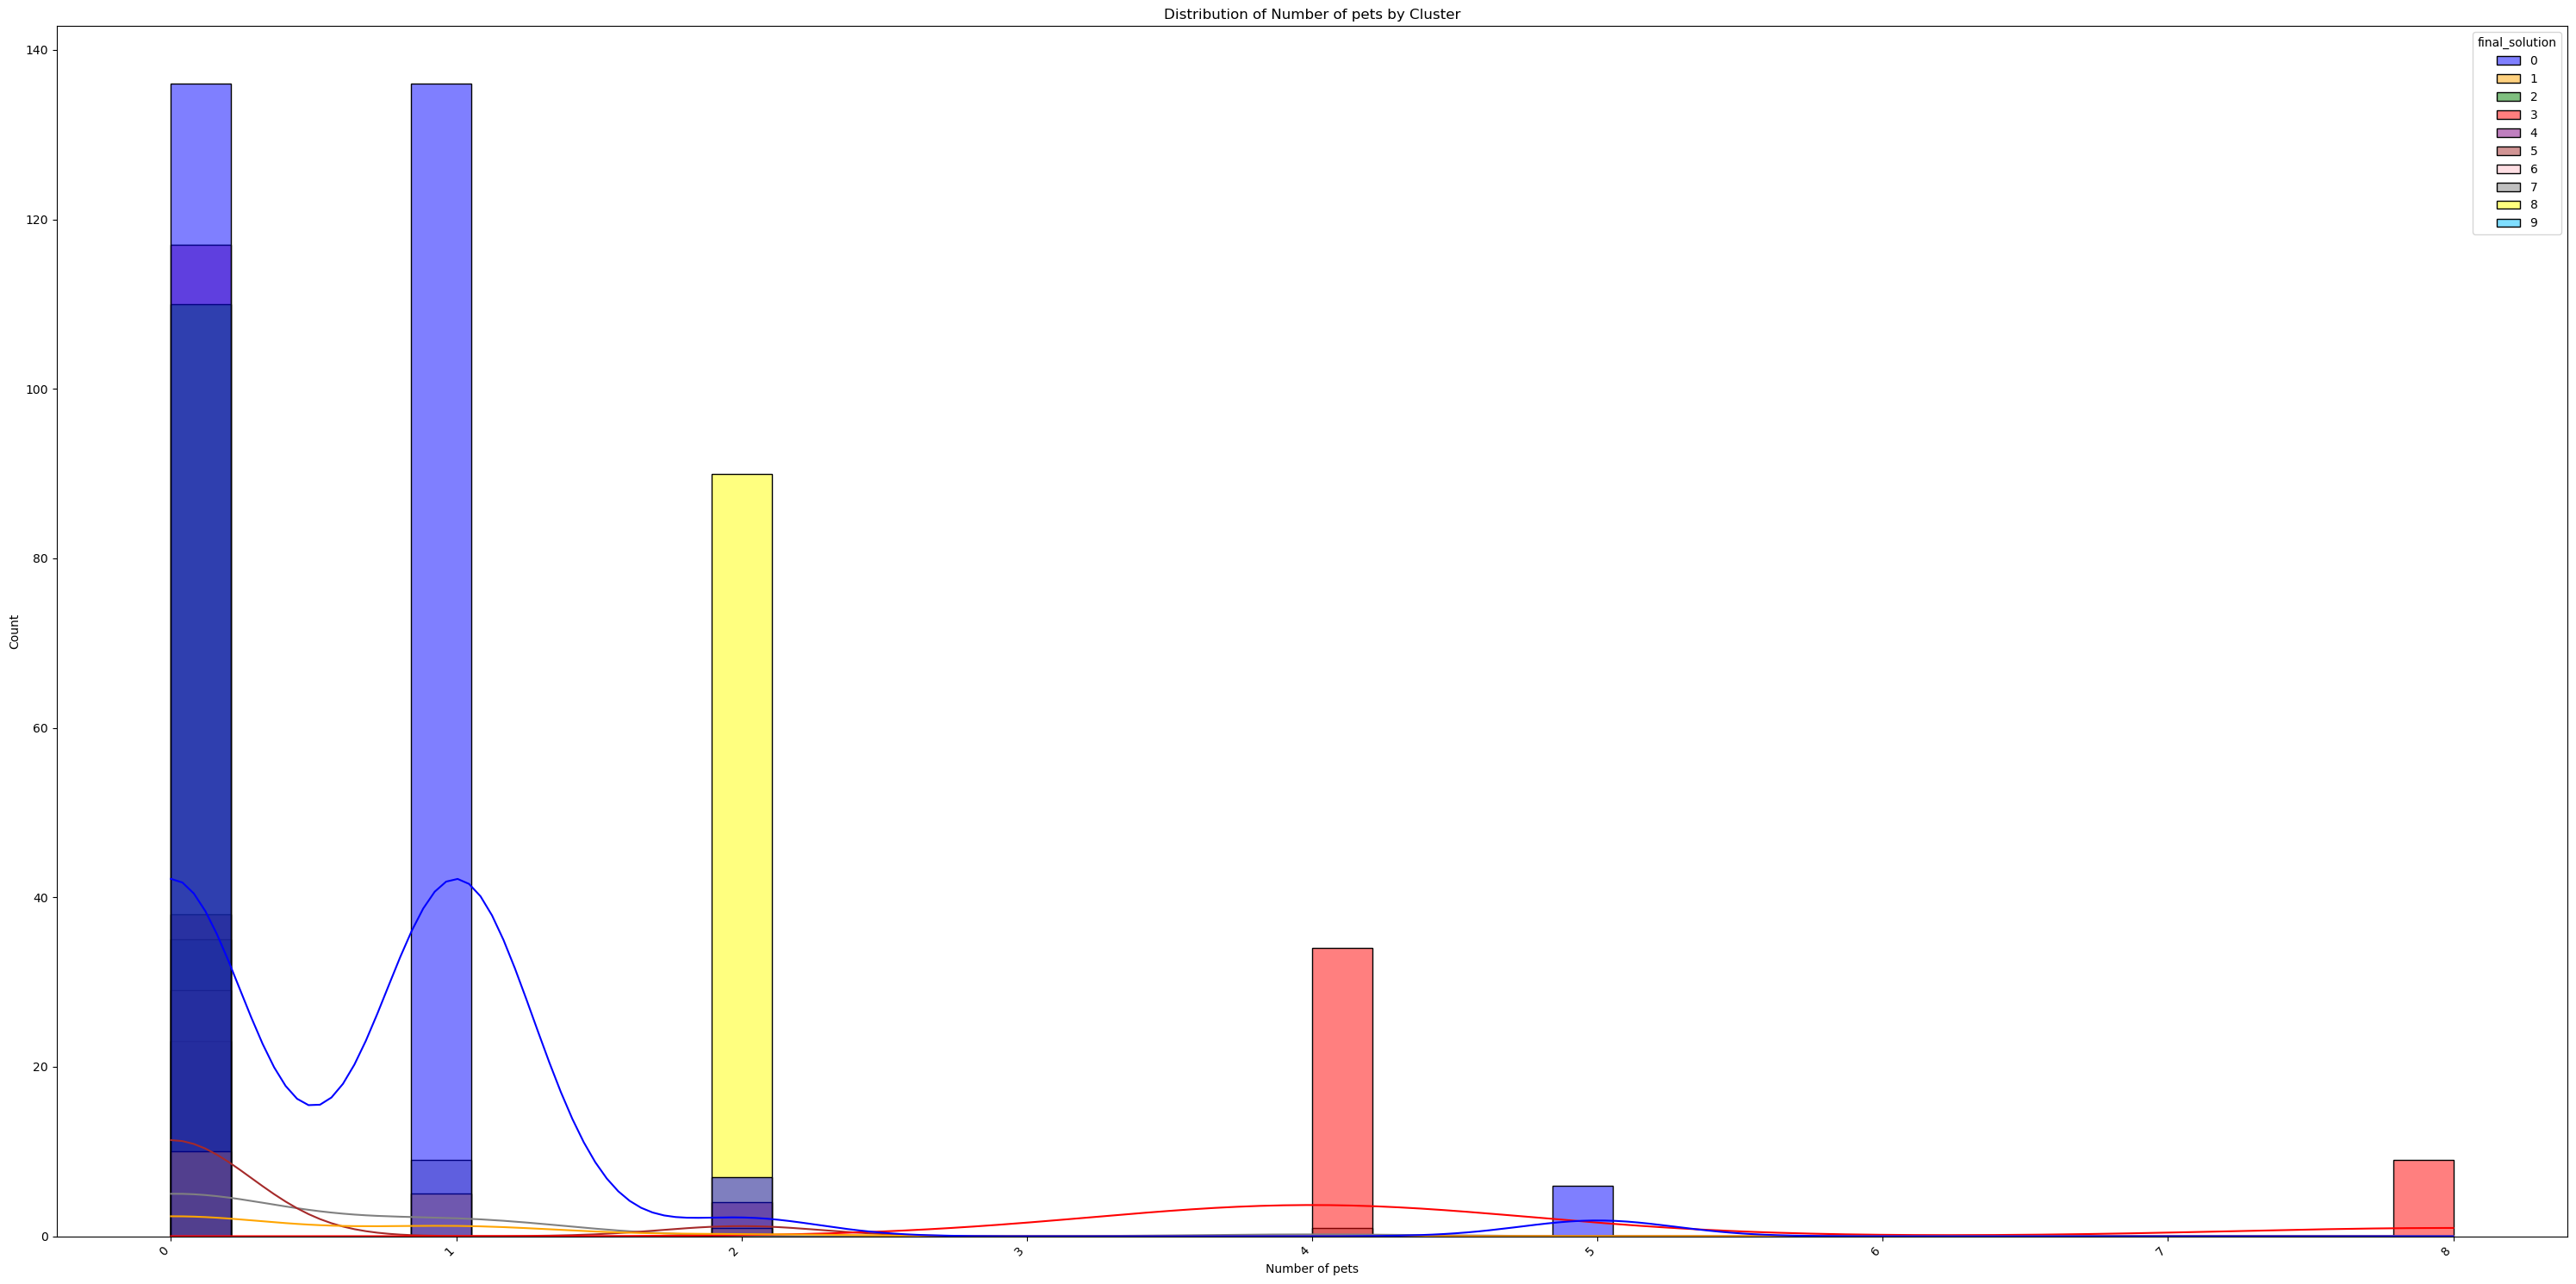

 28%|██▊       | 10/36 [00:03<00:11,  2.33it/s]

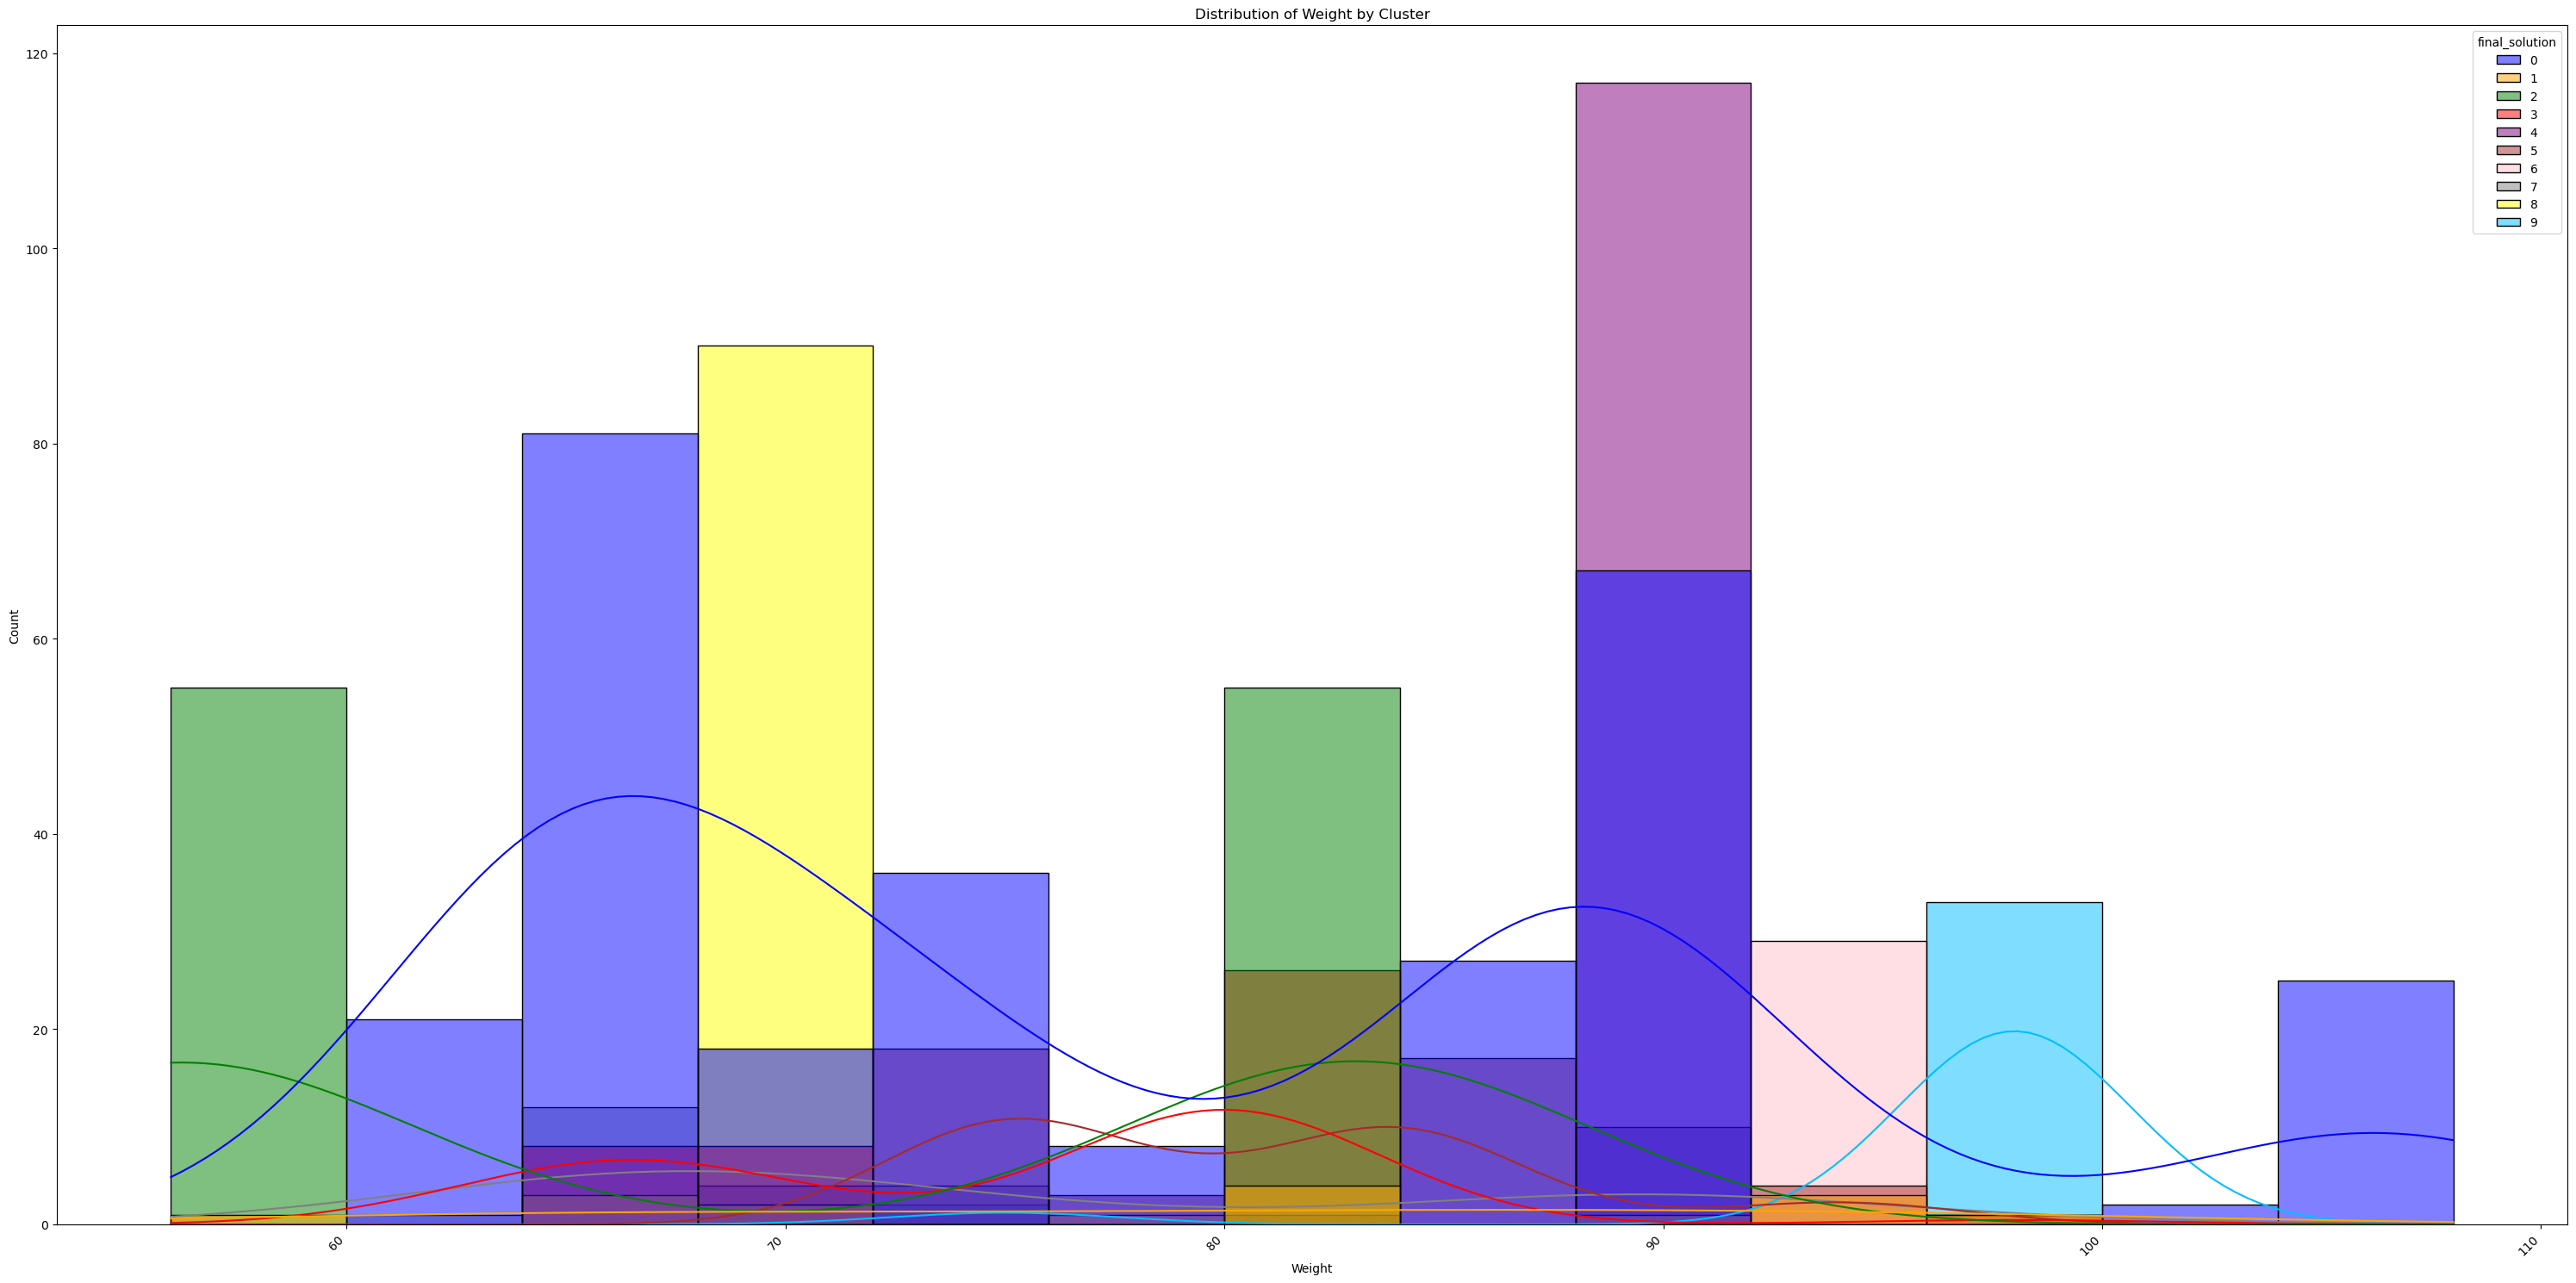

 31%|███       | 11/36 [00:03<00:09,  2.70it/s]

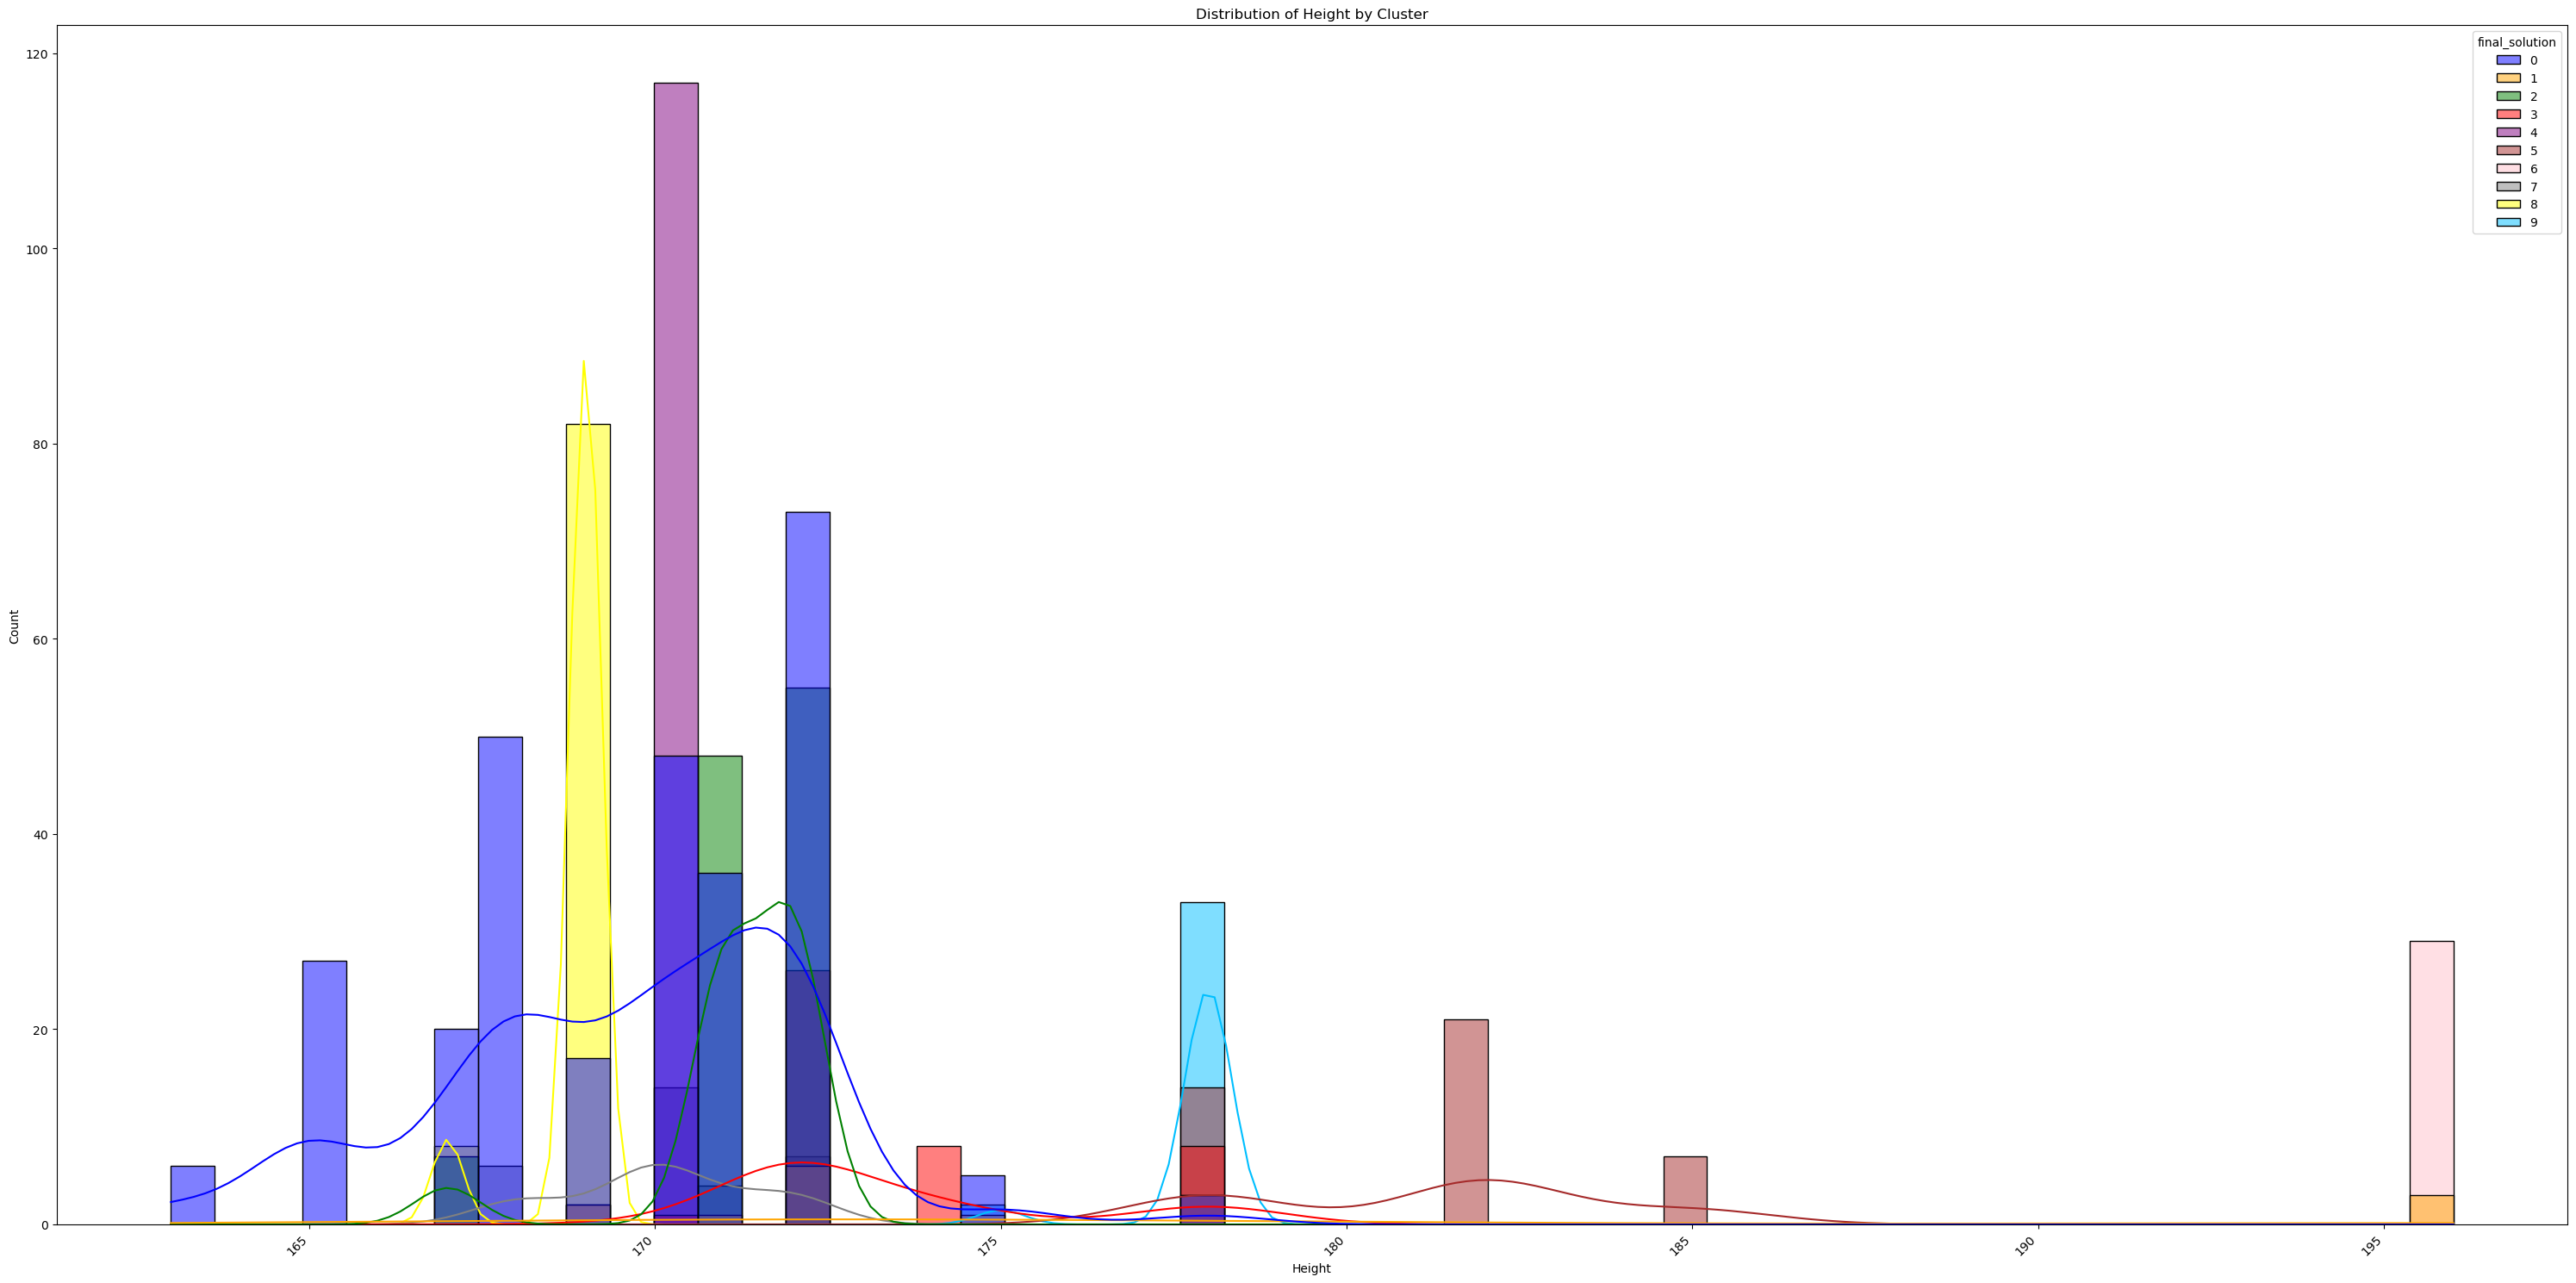

 33%|███▎      | 12/36 [00:04<00:09,  2.57it/s]

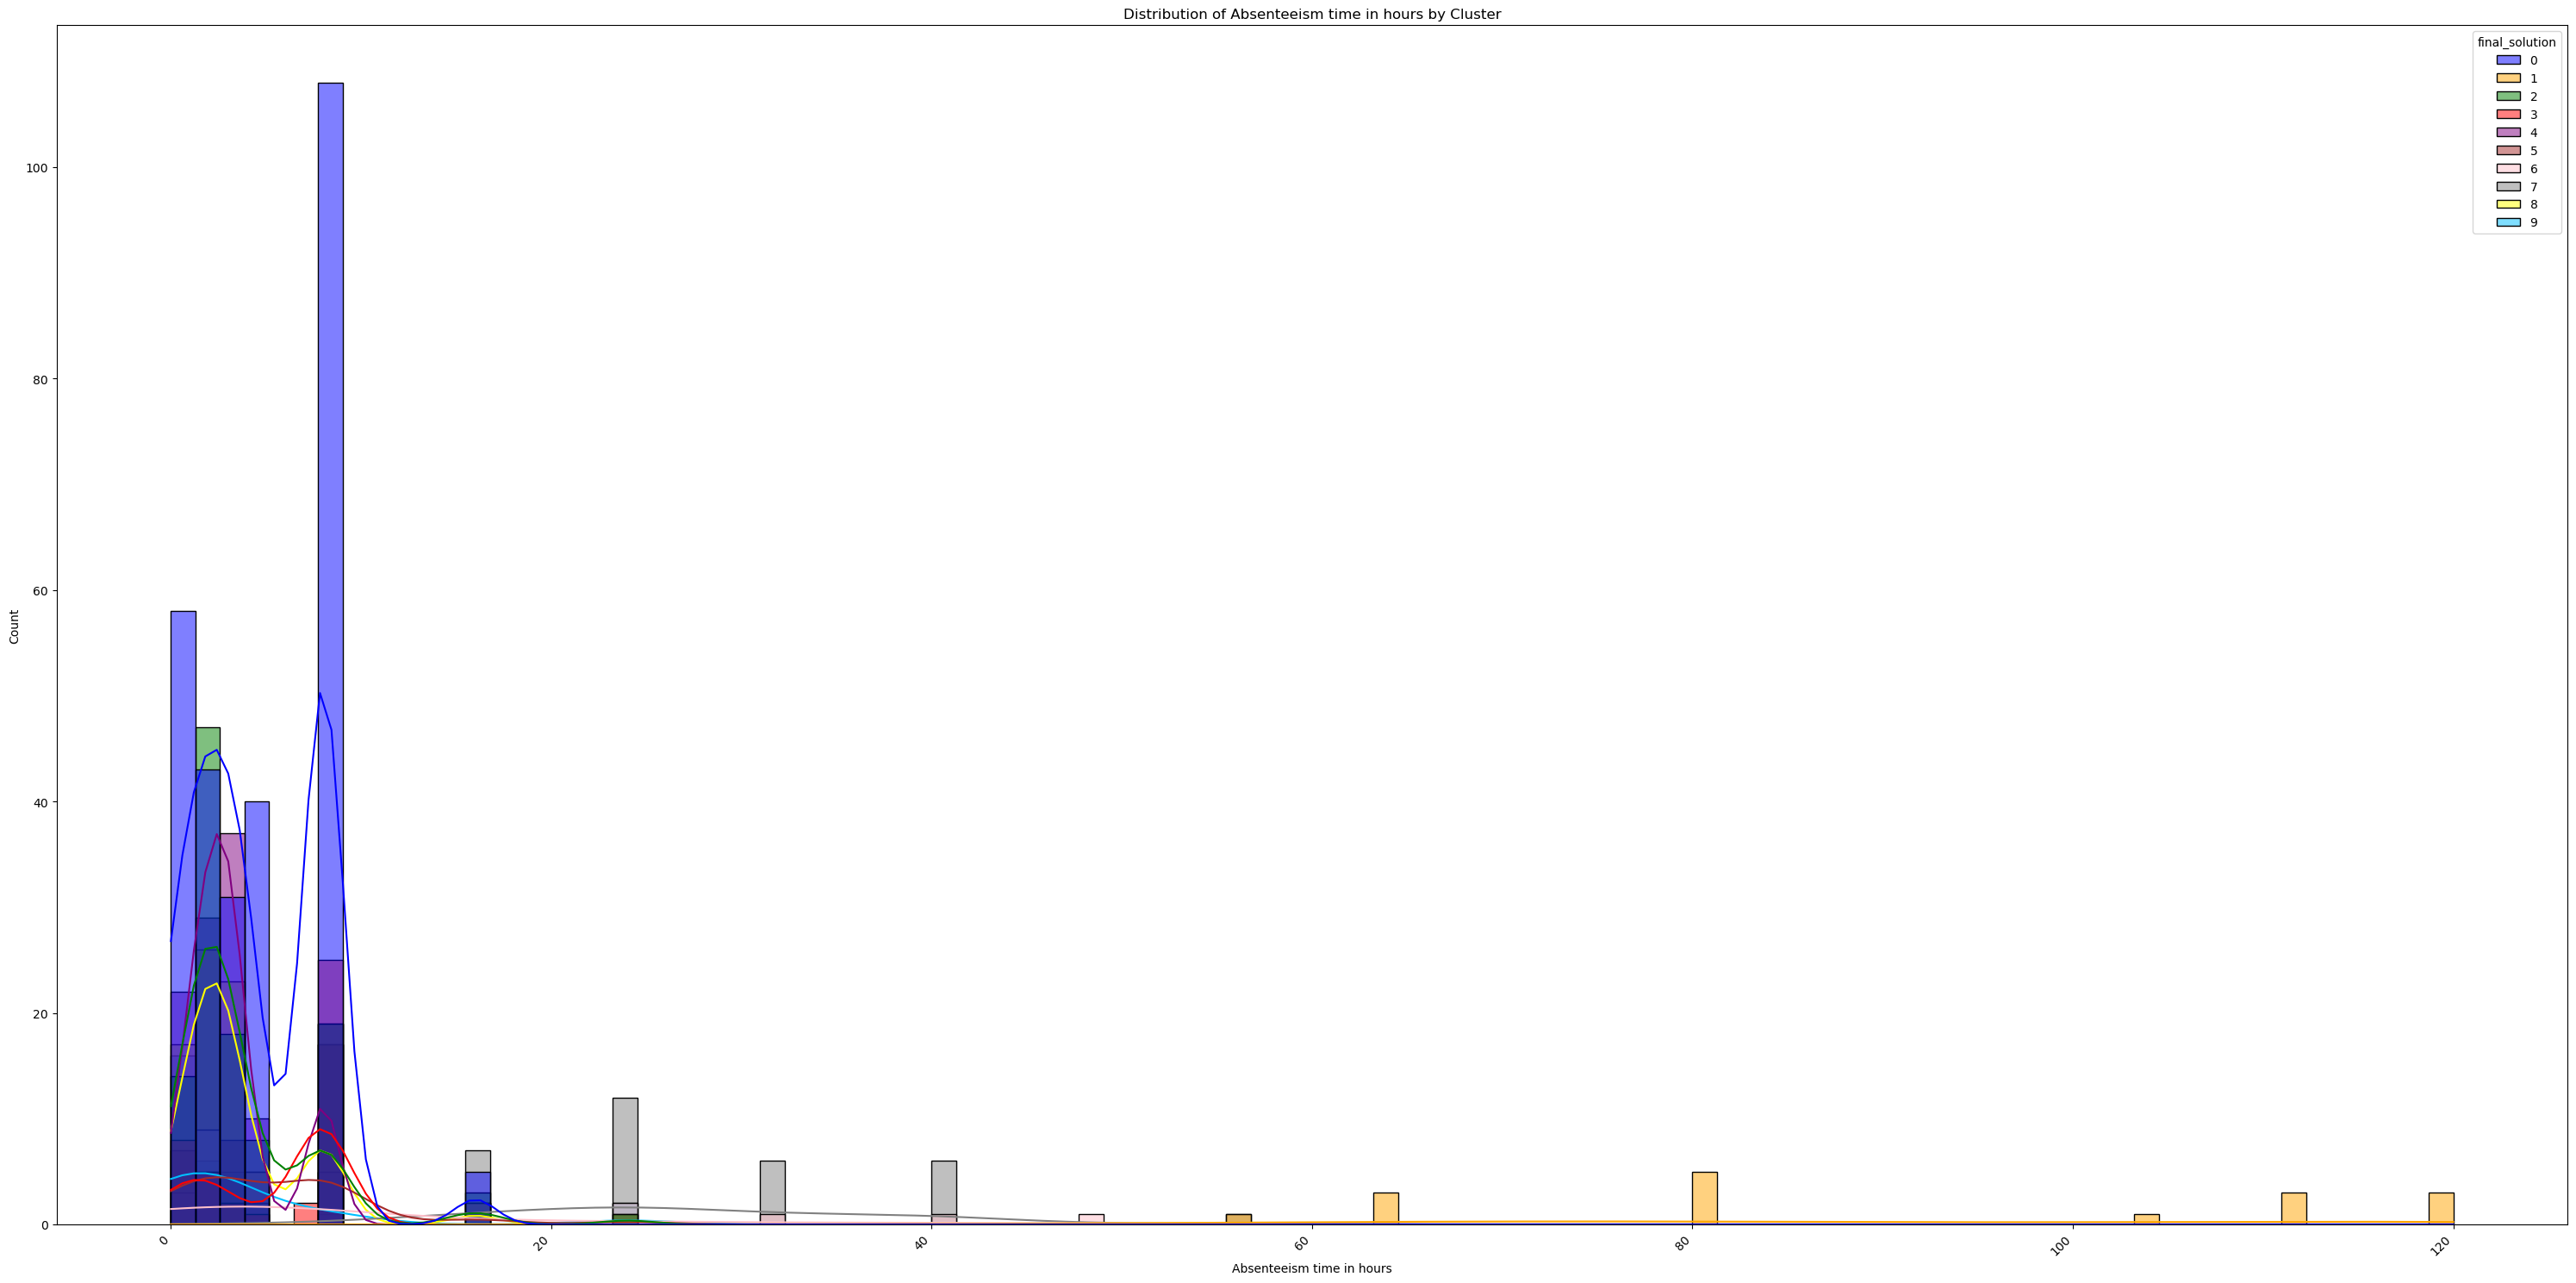

 36%|███▌      | 13/36 [00:04<00:10,  2.10it/s]

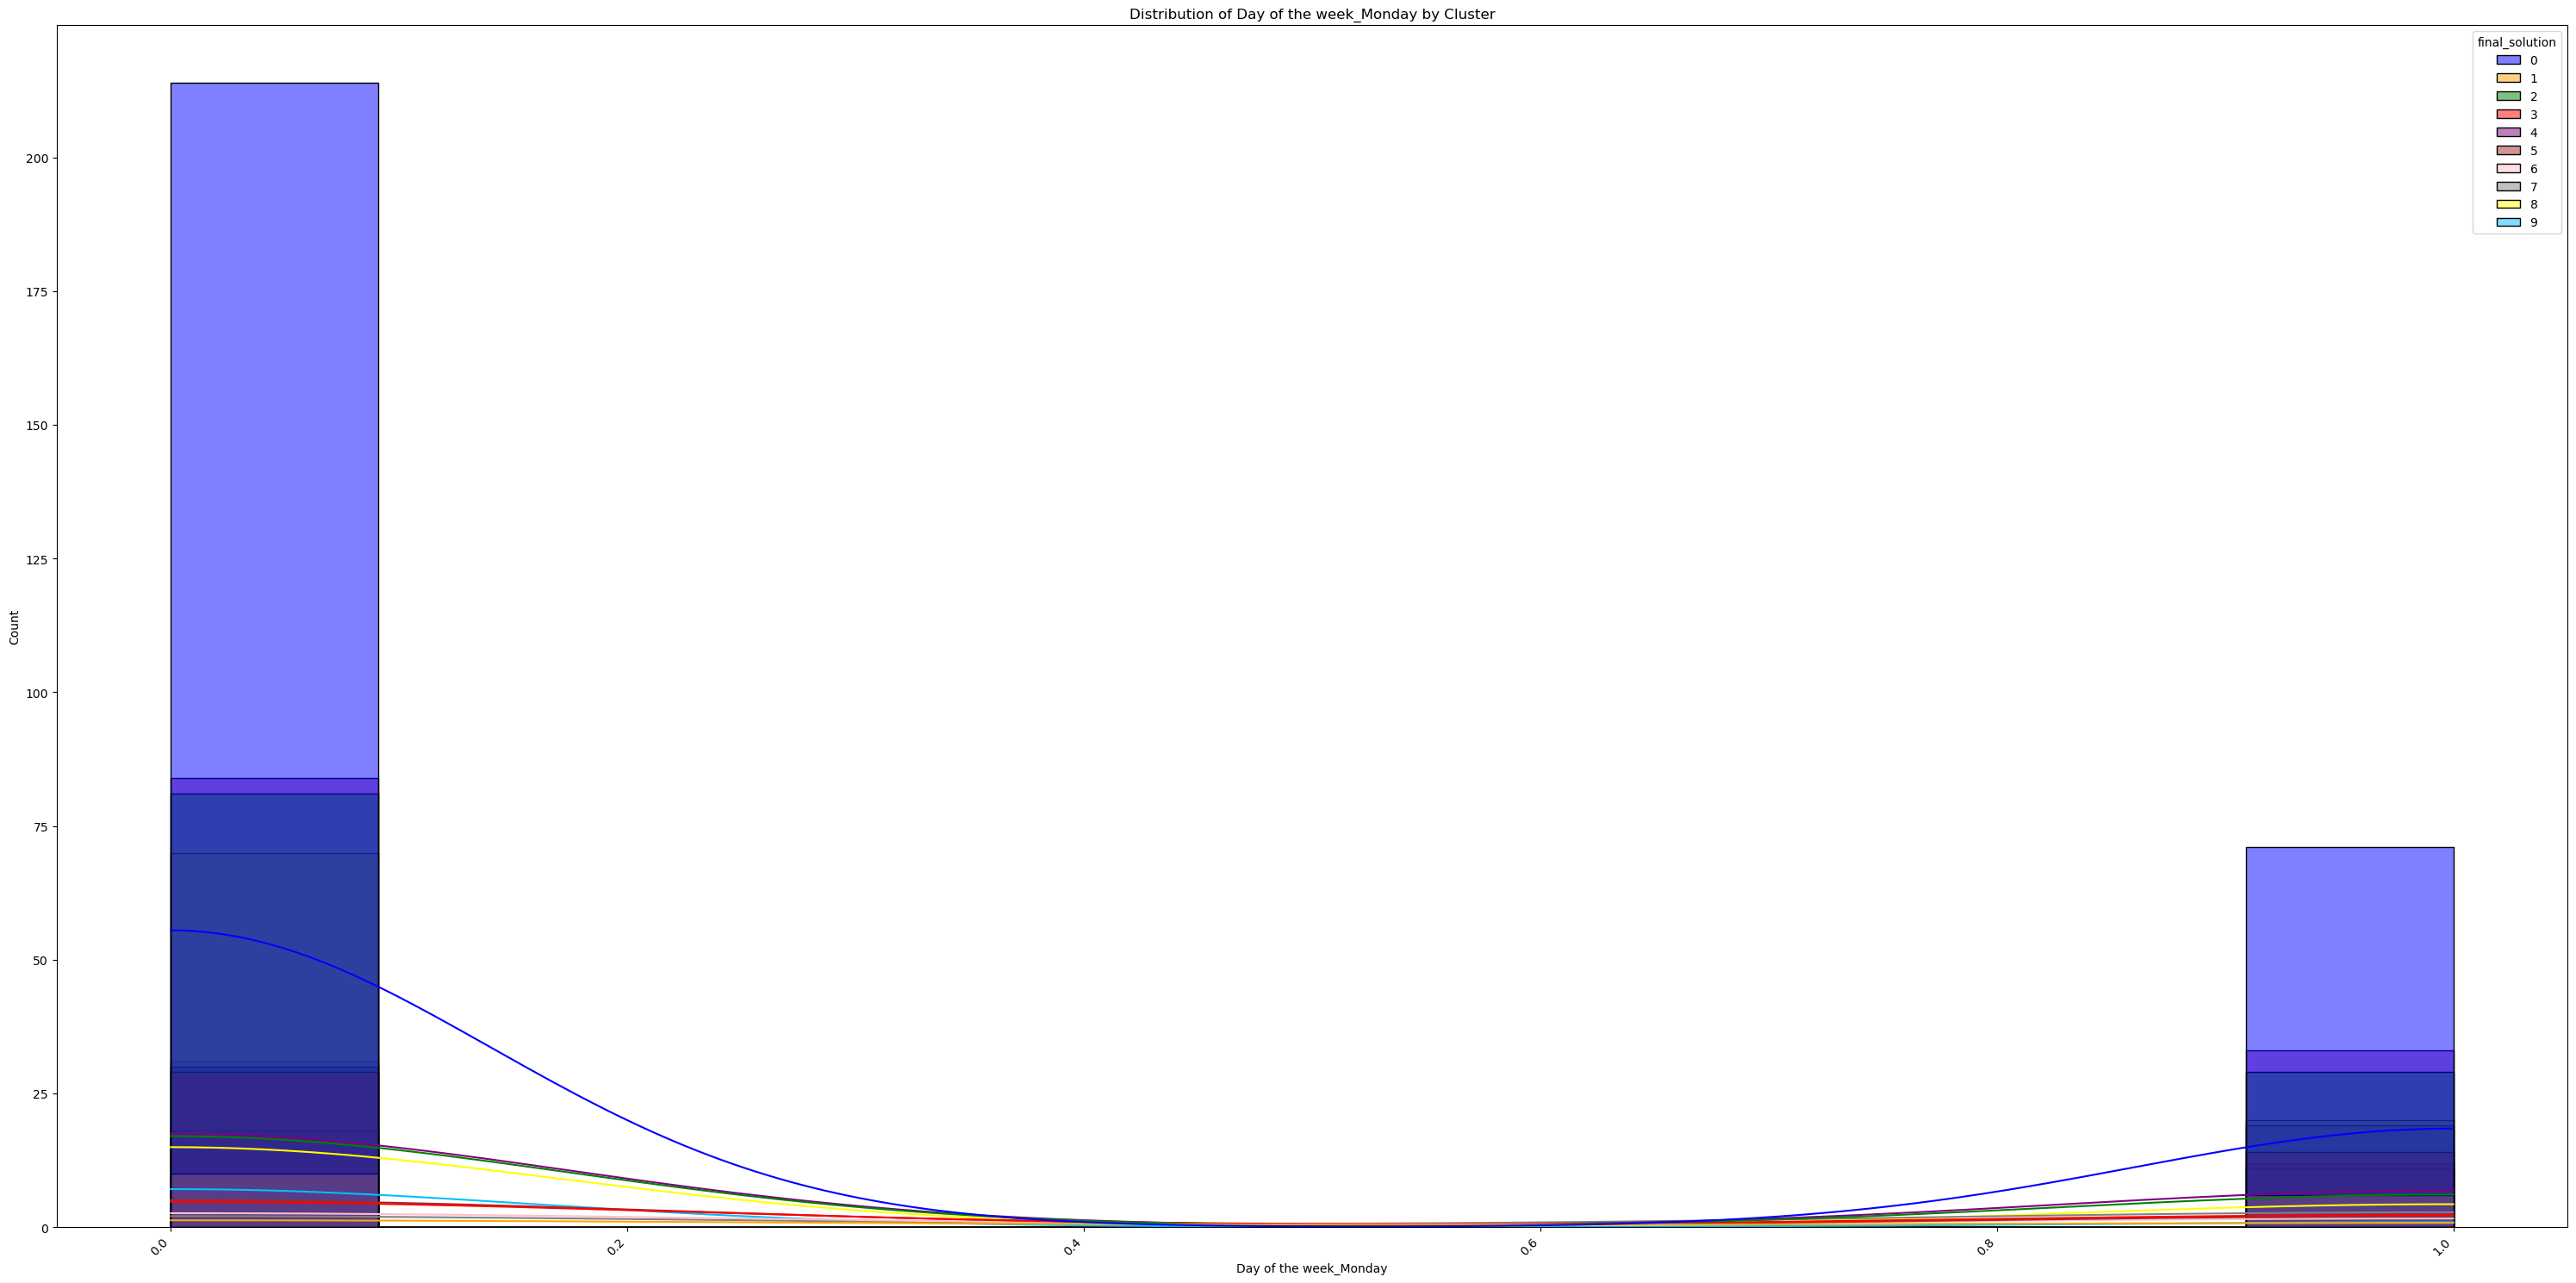

 39%|███▉      | 14/36 [00:05<00:09,  2.25it/s]

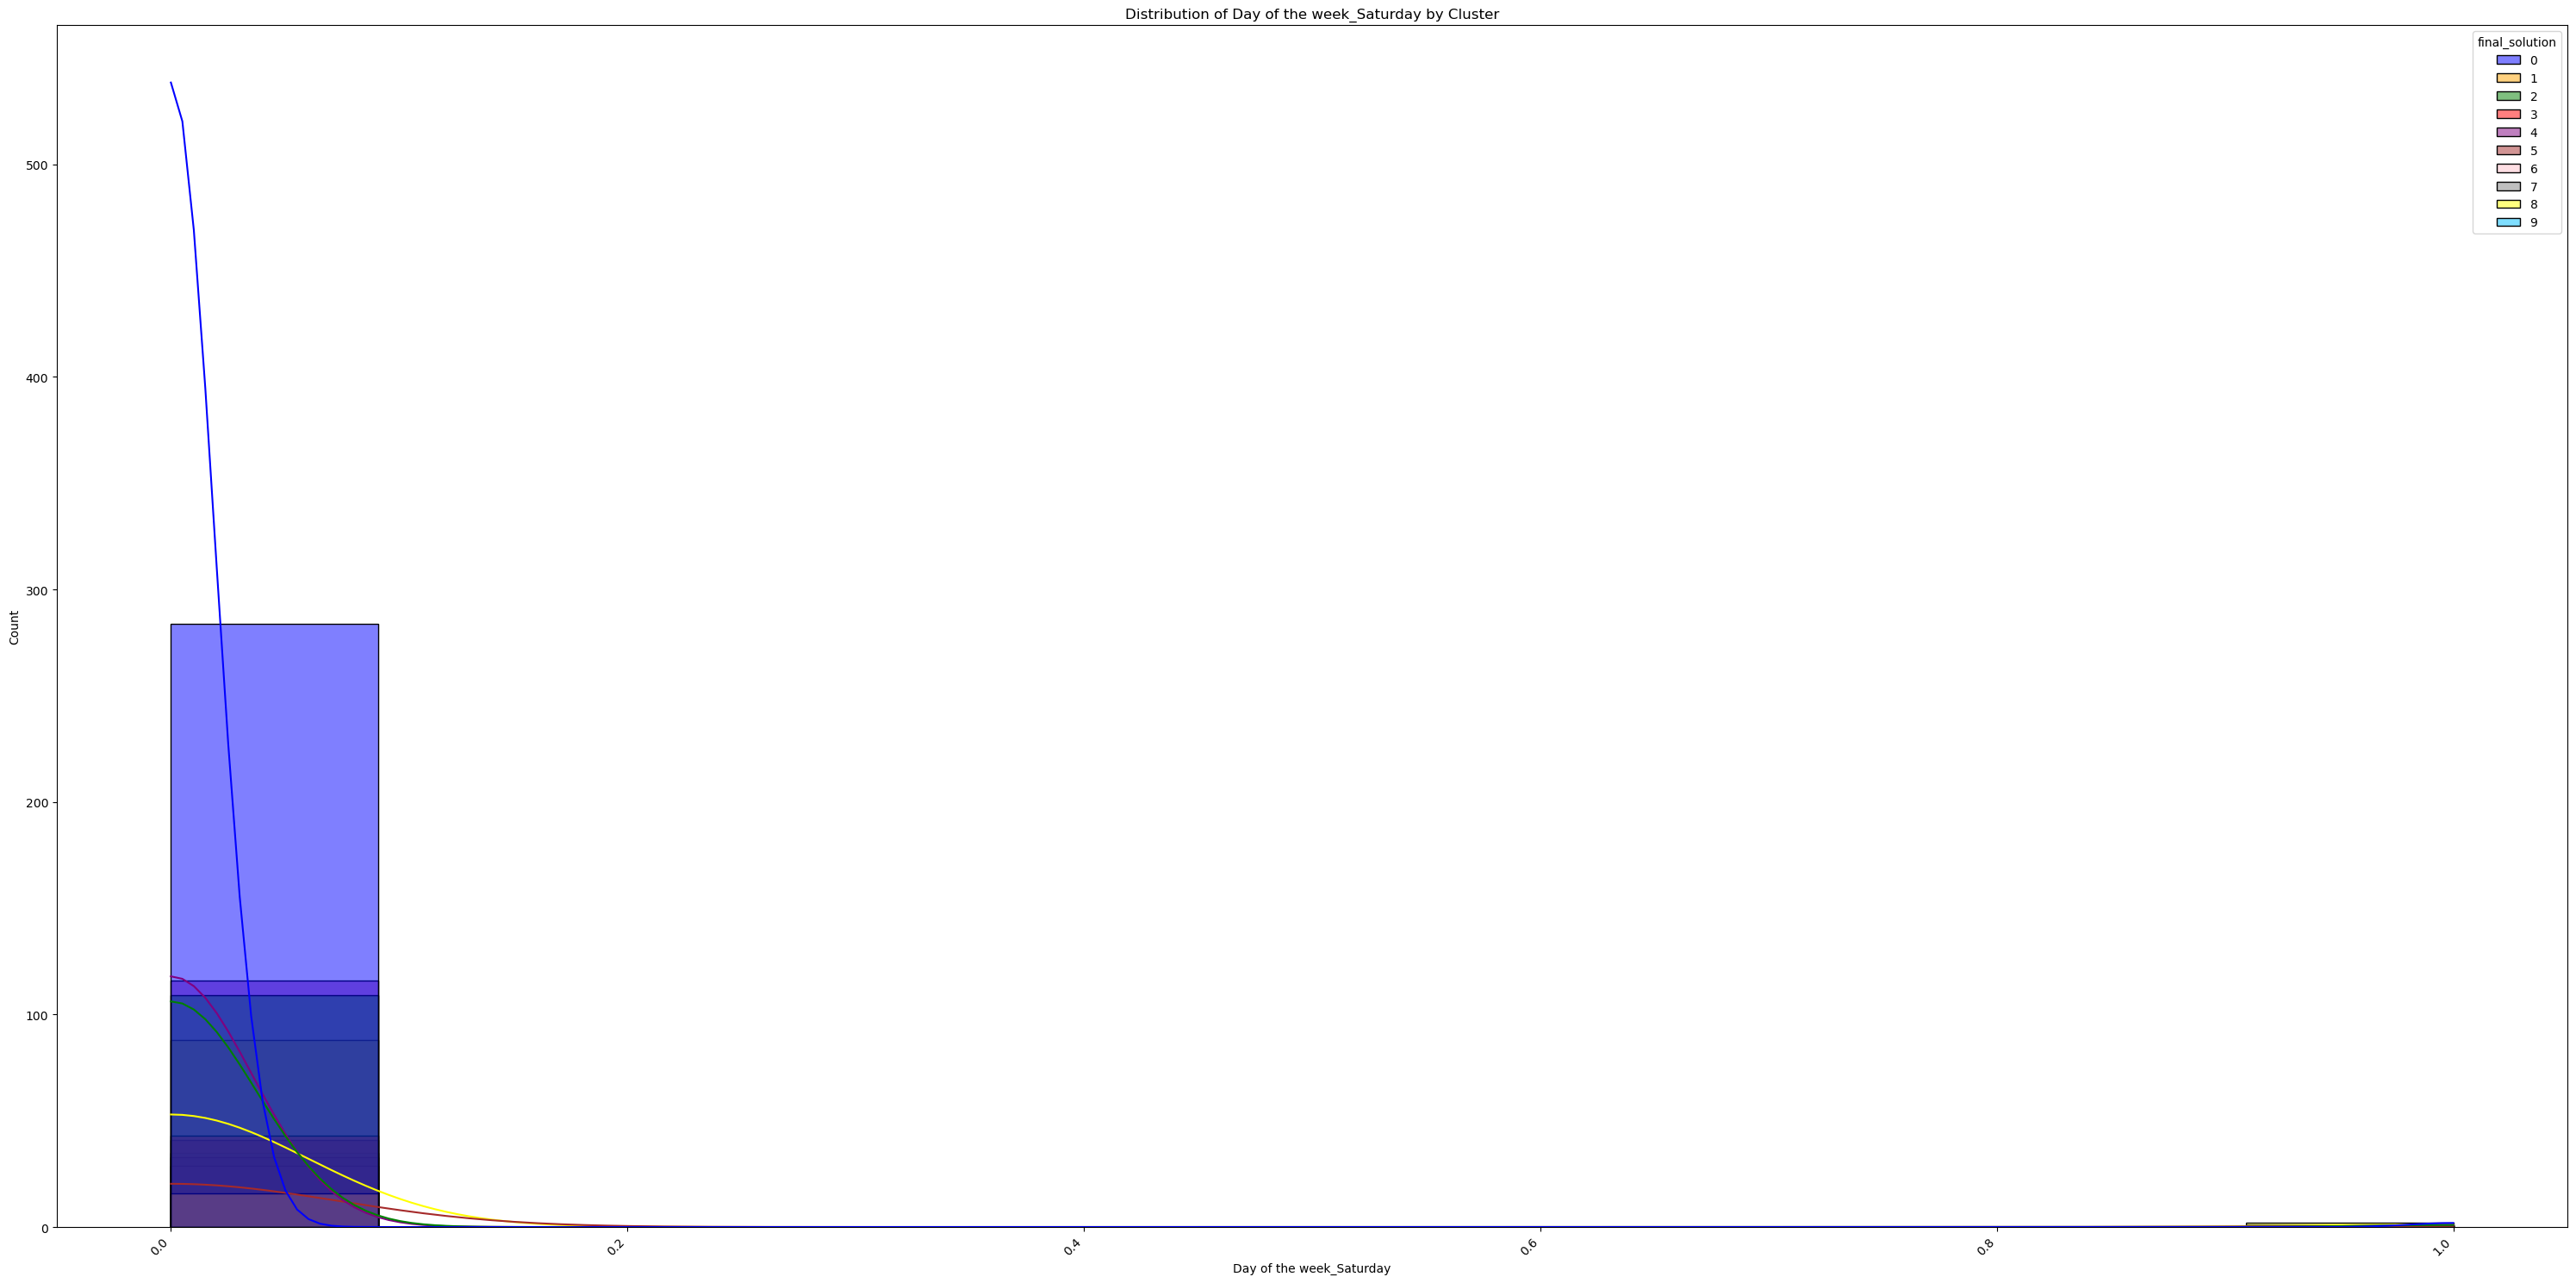

 42%|████▏     | 15/36 [00:05<00:08,  2.55it/s]

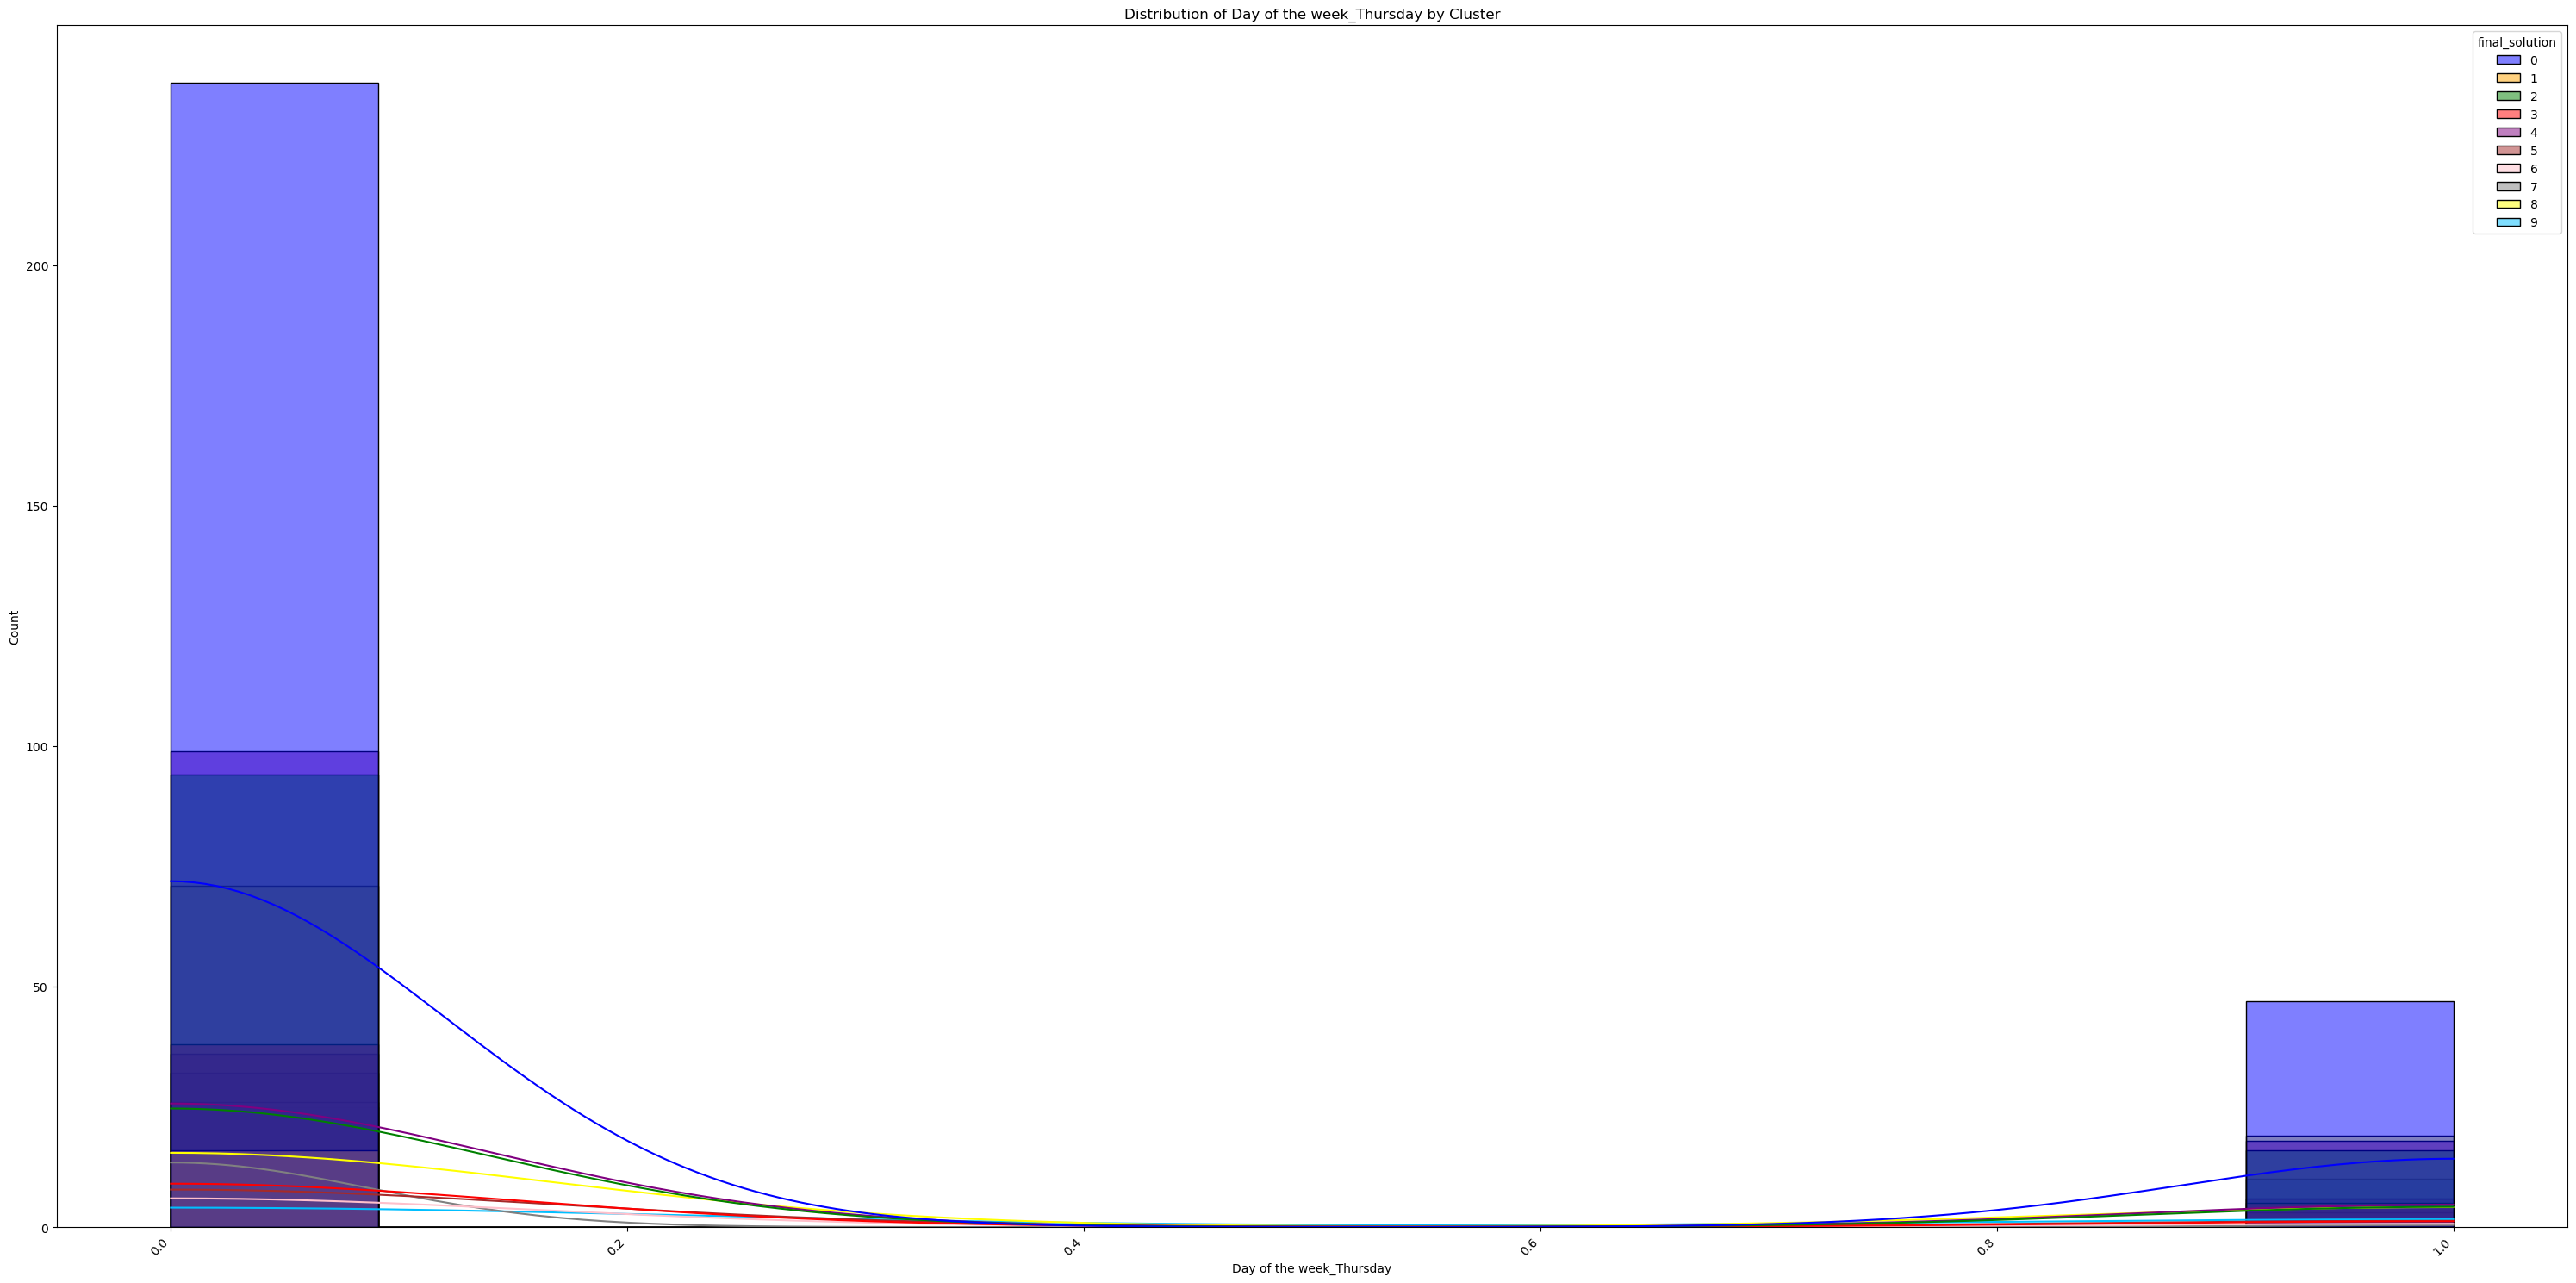

 44%|████▍     | 16/36 [00:05<00:06,  2.87it/s]

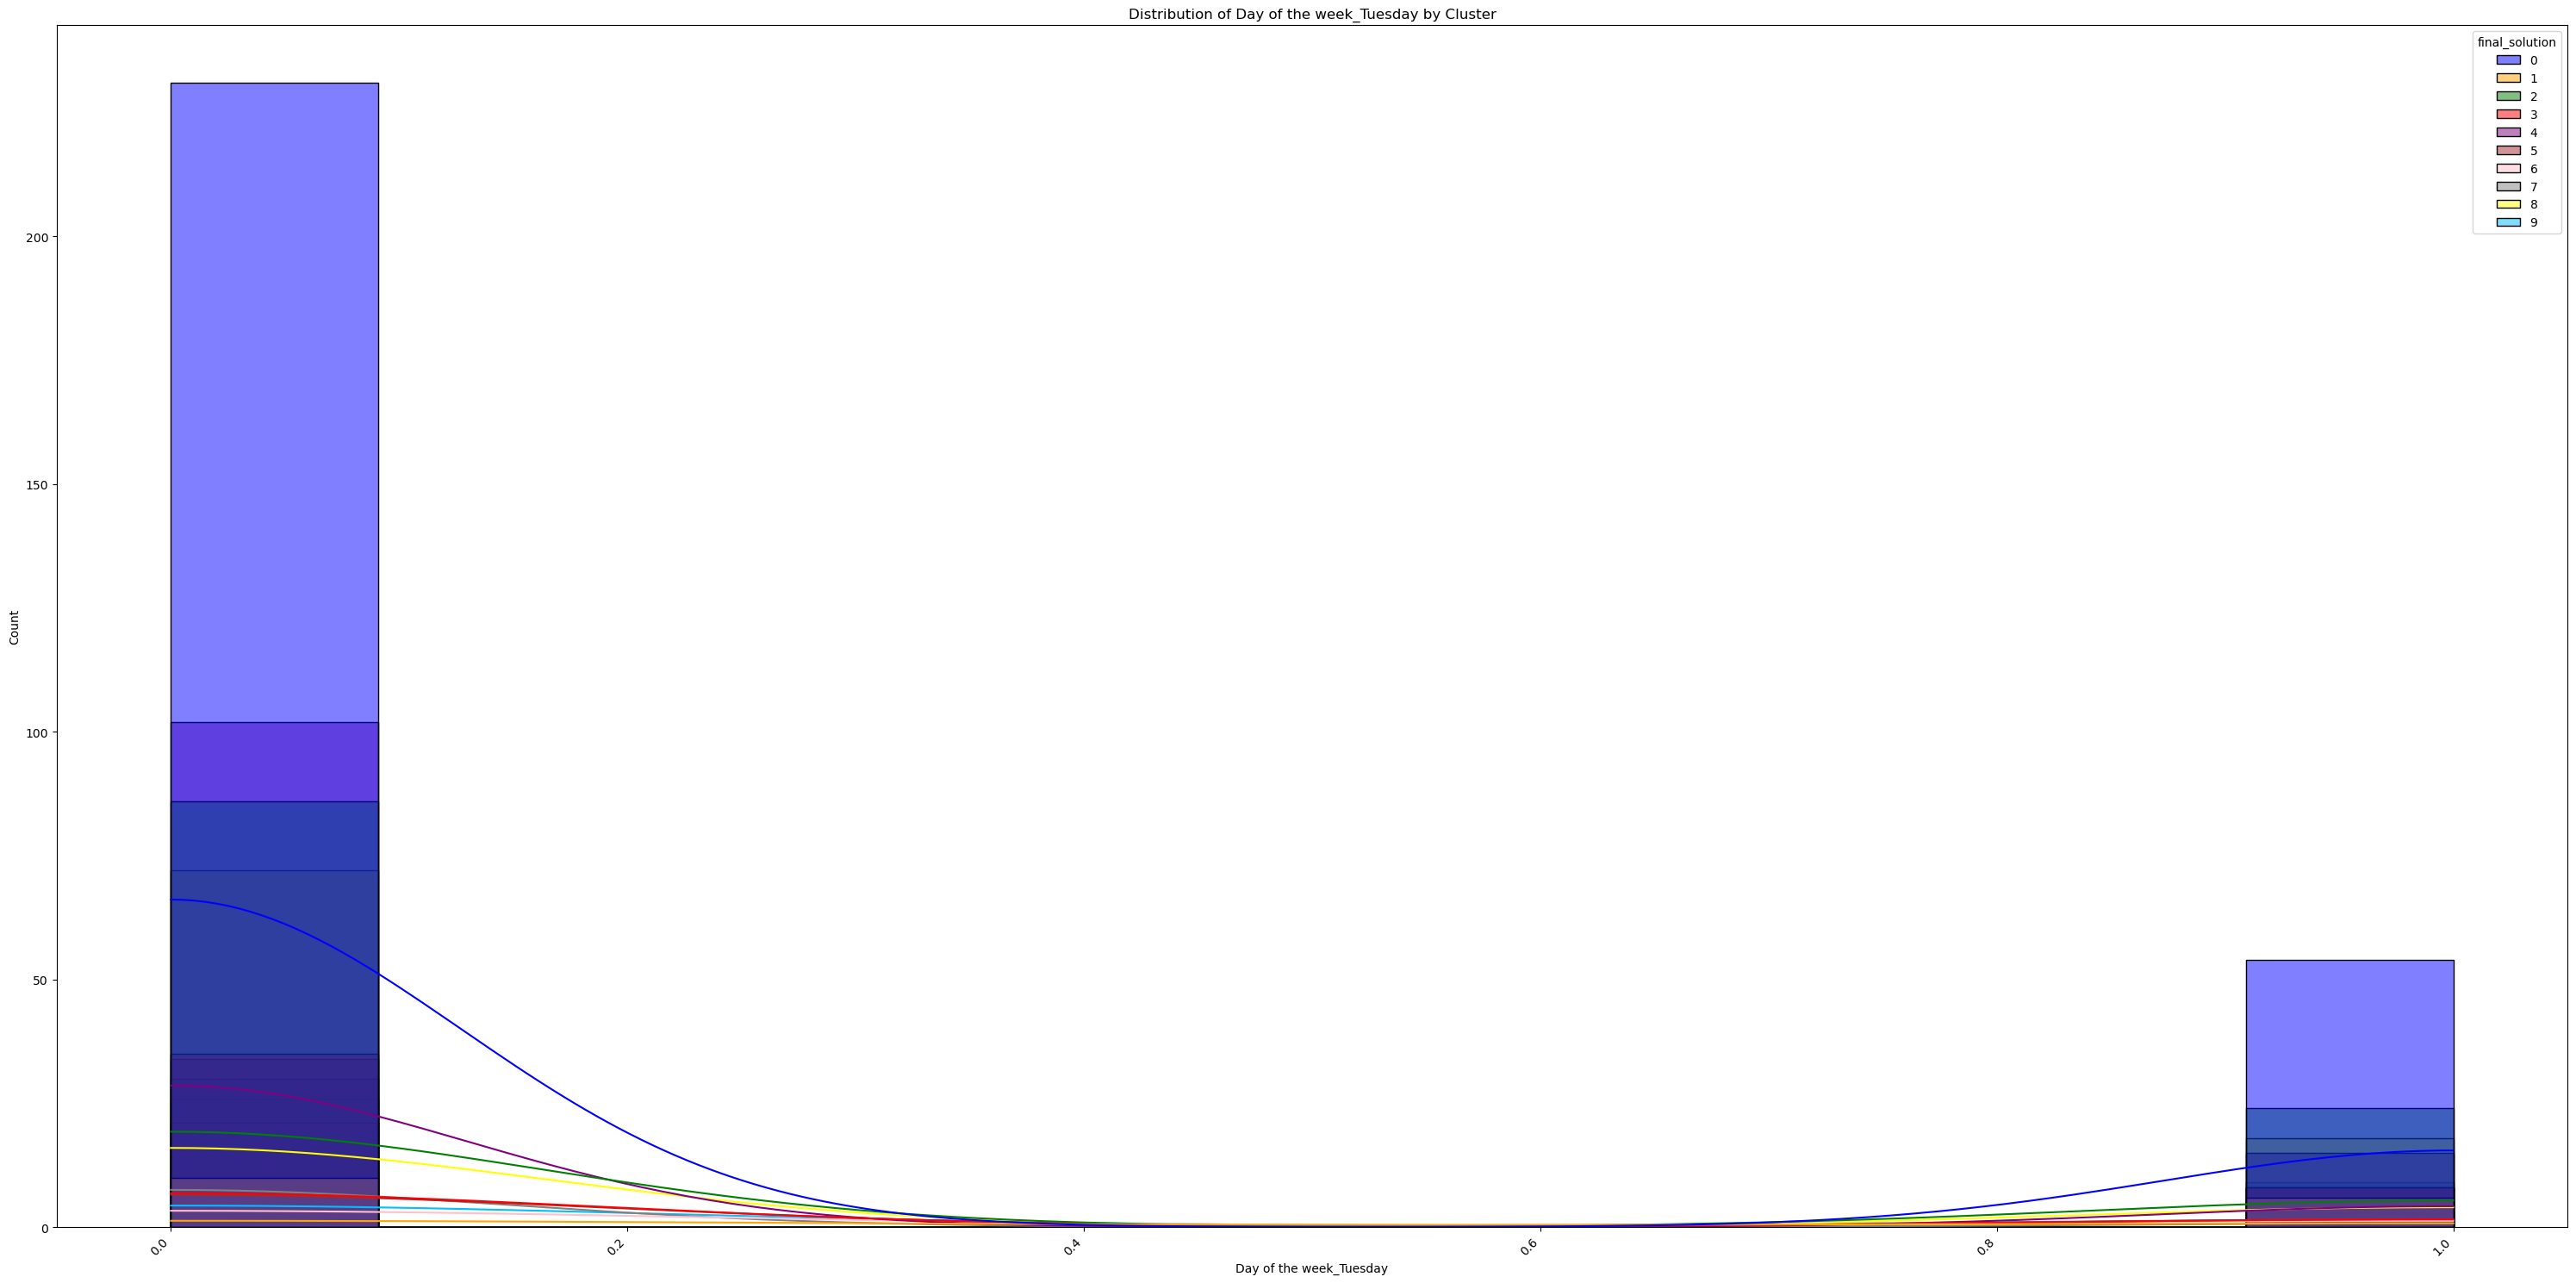

 47%|████▋     | 17/36 [00:06<00:07,  2.38it/s]

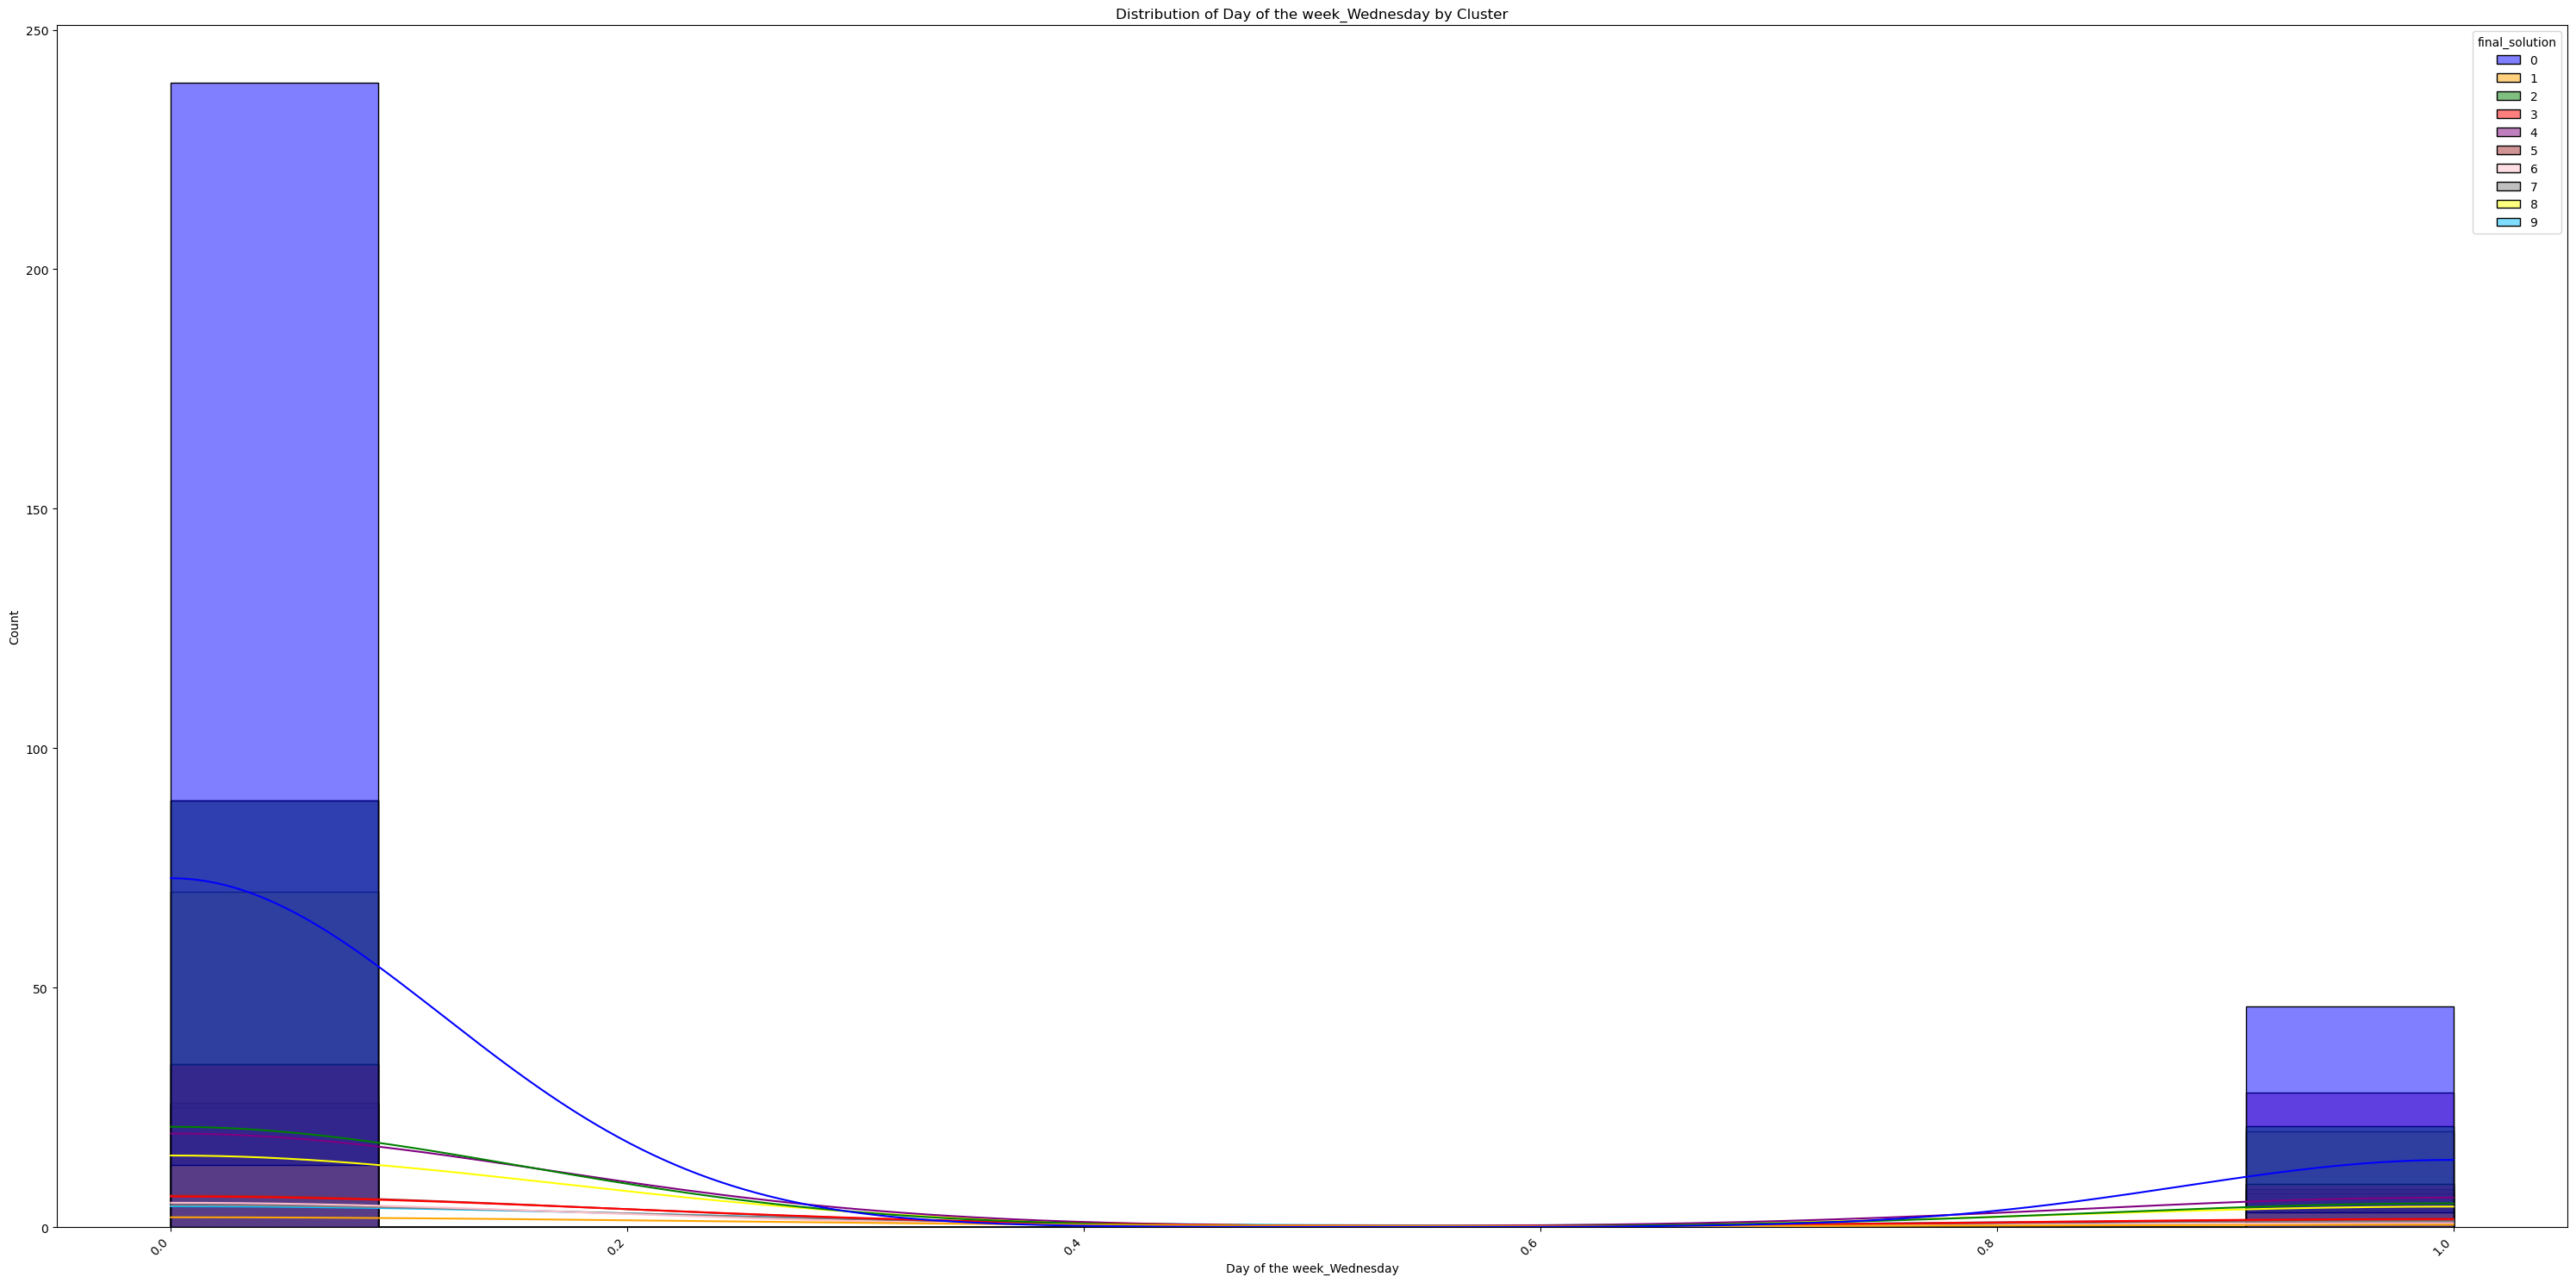

 50%|█████     | 18/36 [00:06<00:06,  2.74it/s]

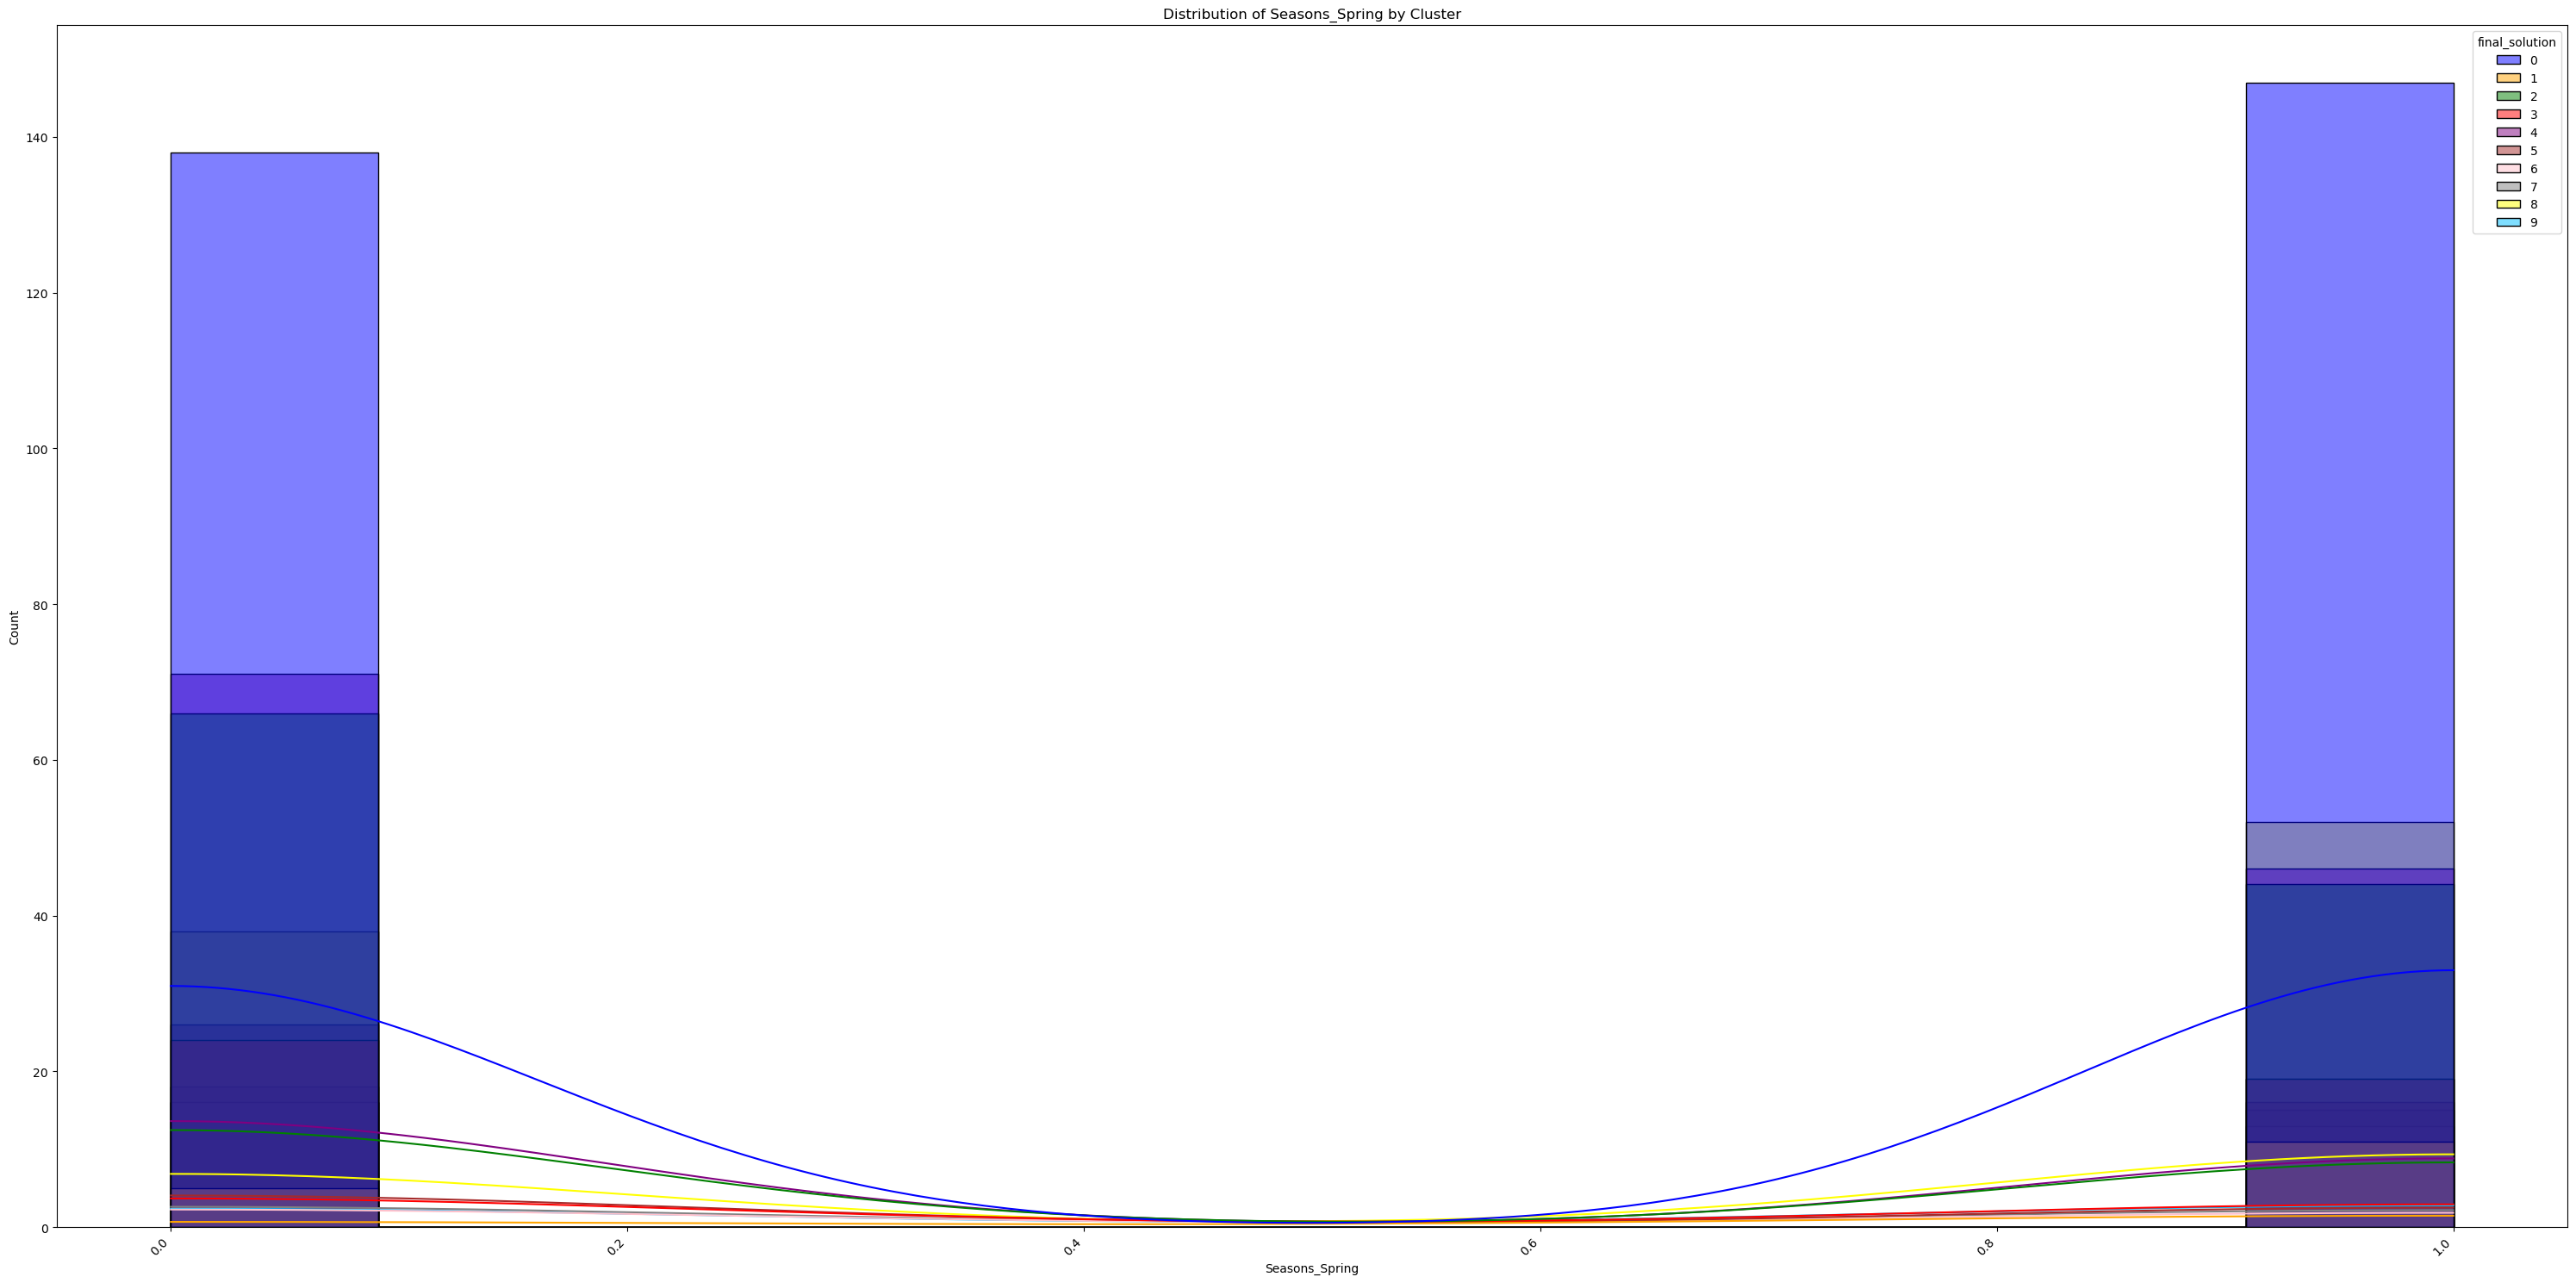

 53%|█████▎    | 19/36 [00:06<00:05,  3.03it/s]

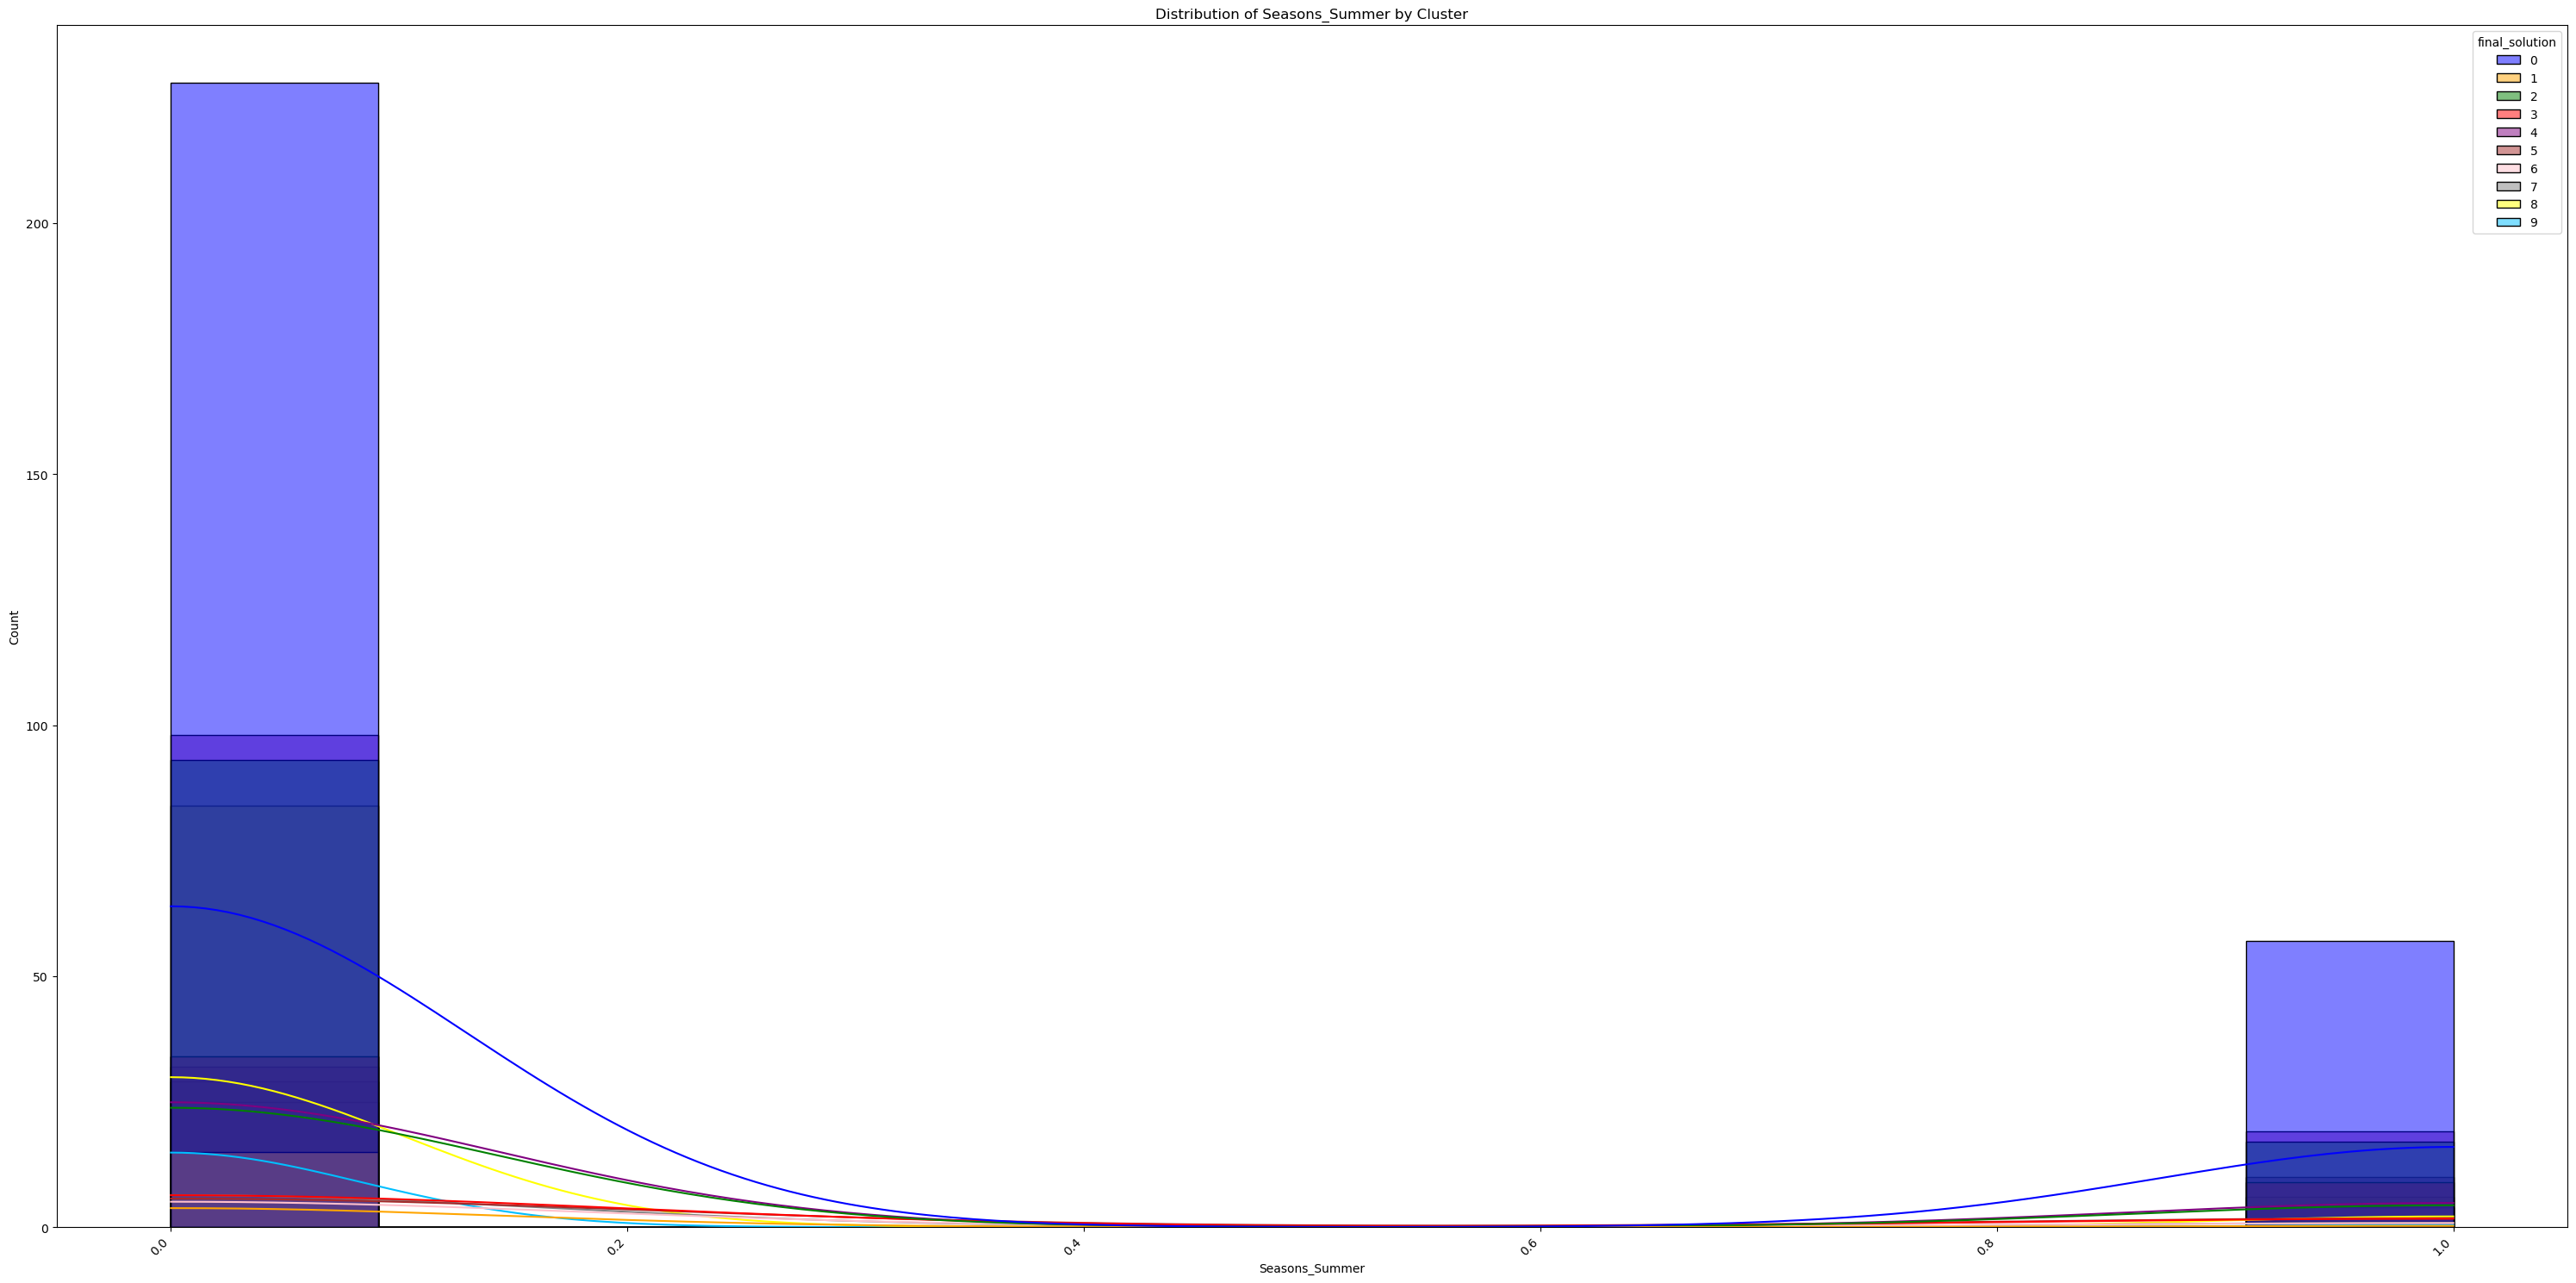

 56%|█████▌    | 20/36 [00:07<00:04,  3.29it/s]

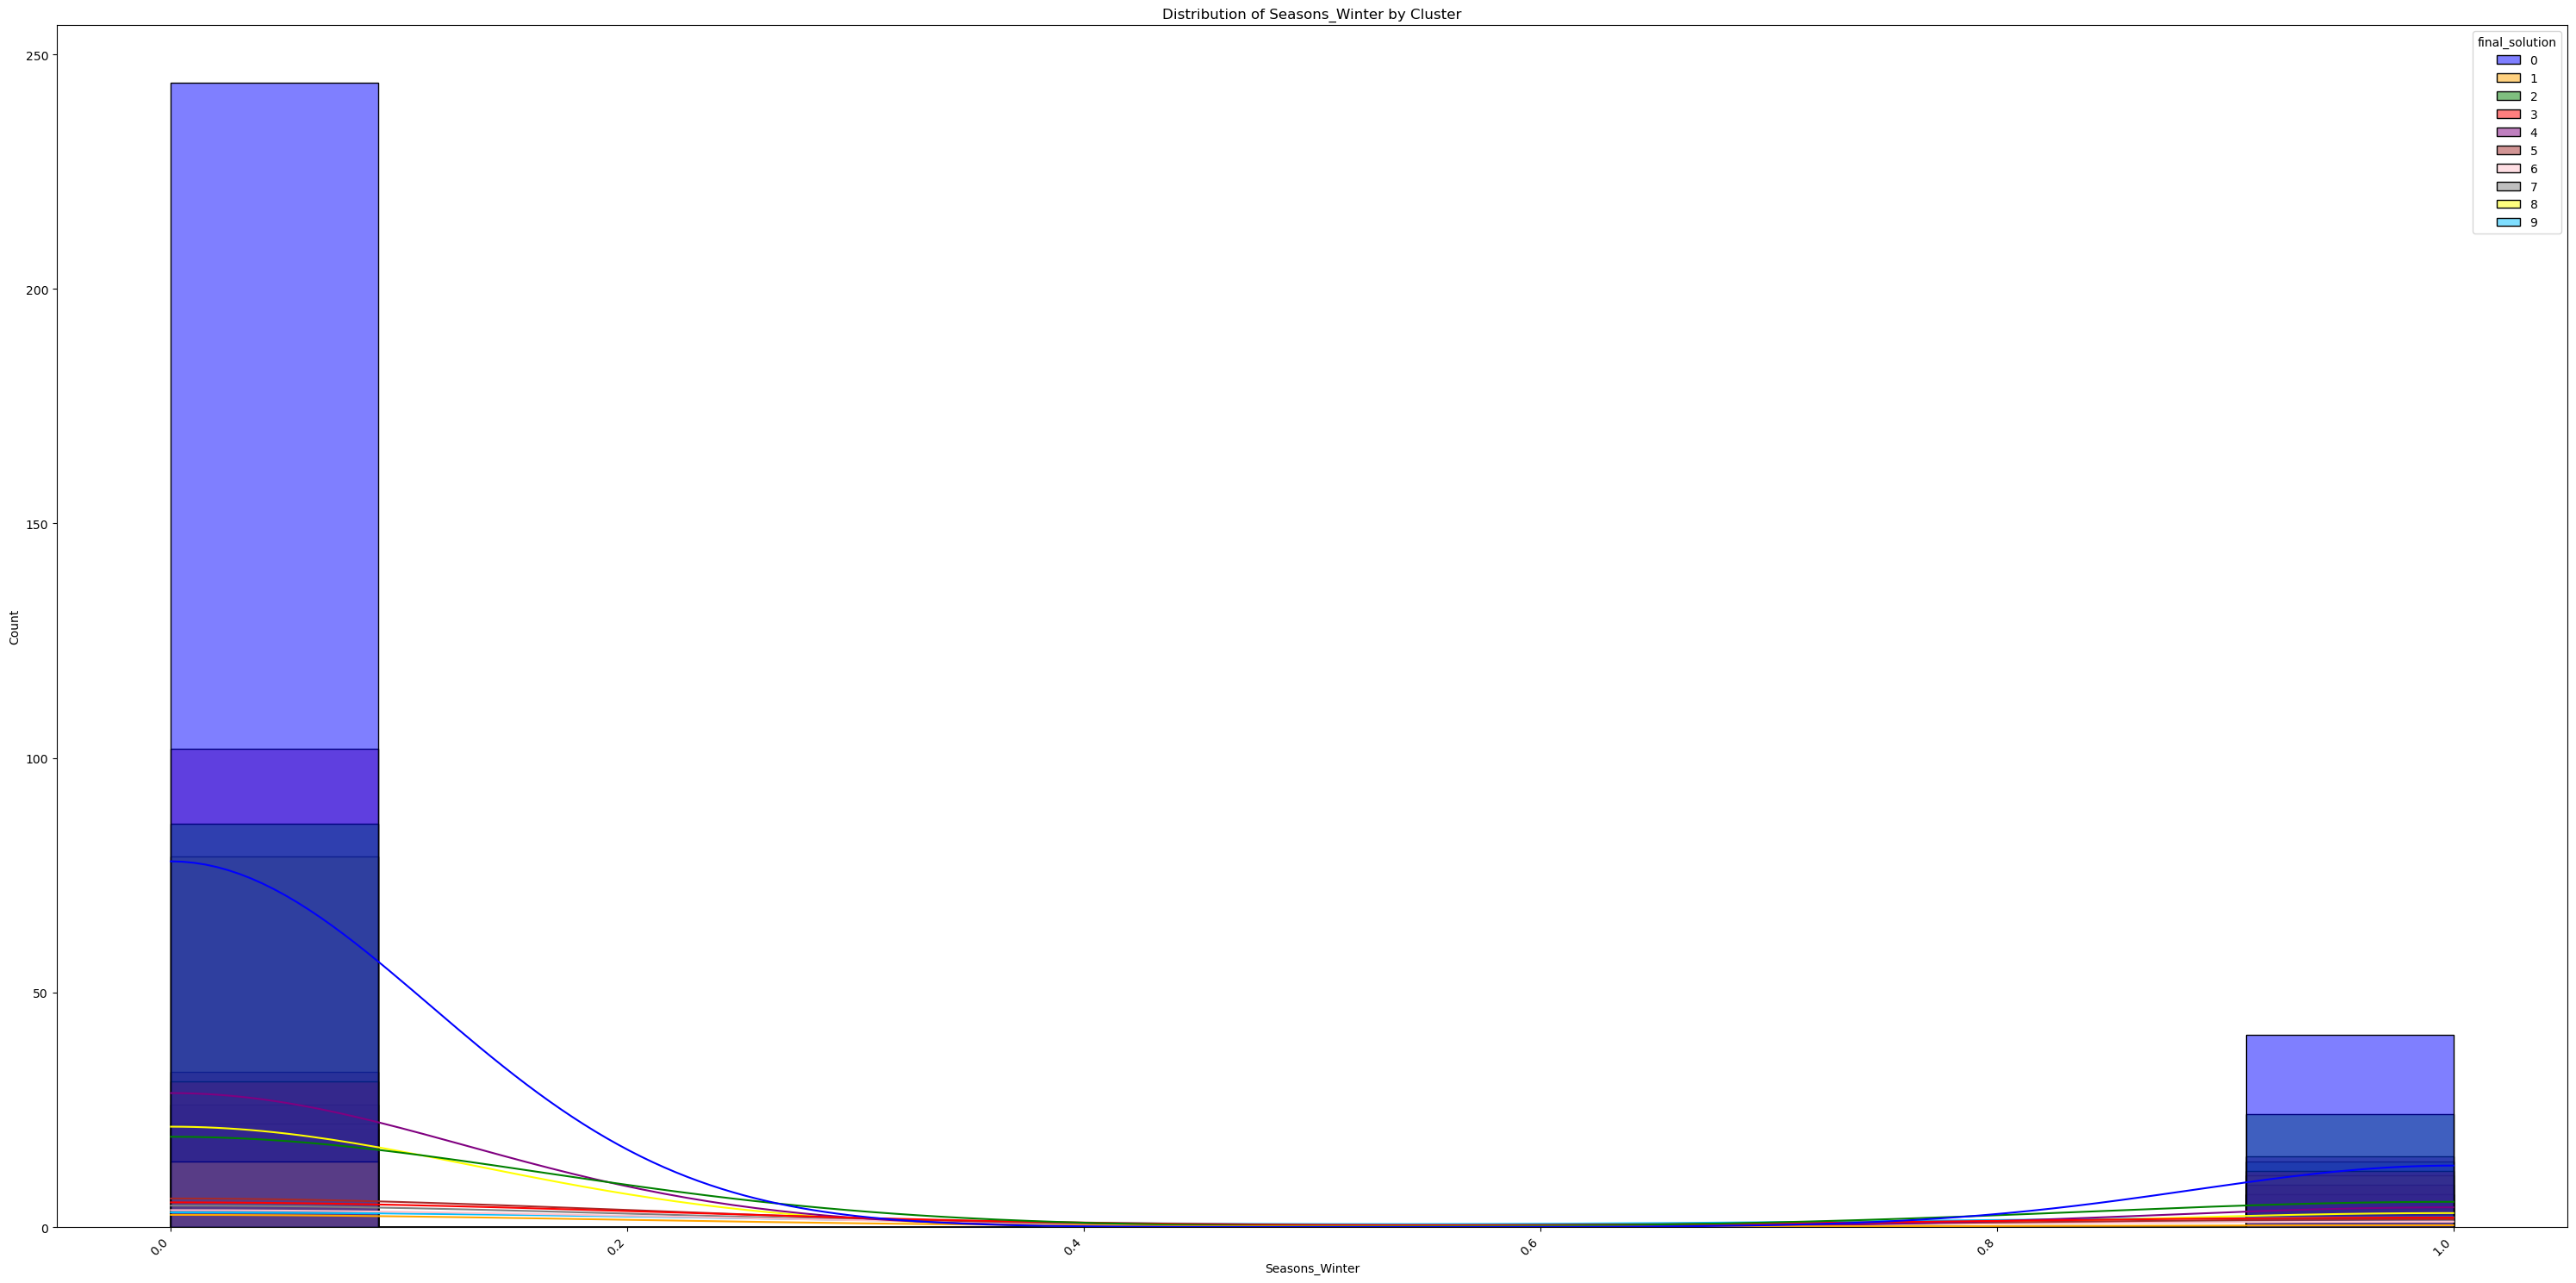

 58%|█████▊    | 21/36 [00:07<00:04,  3.33it/s]

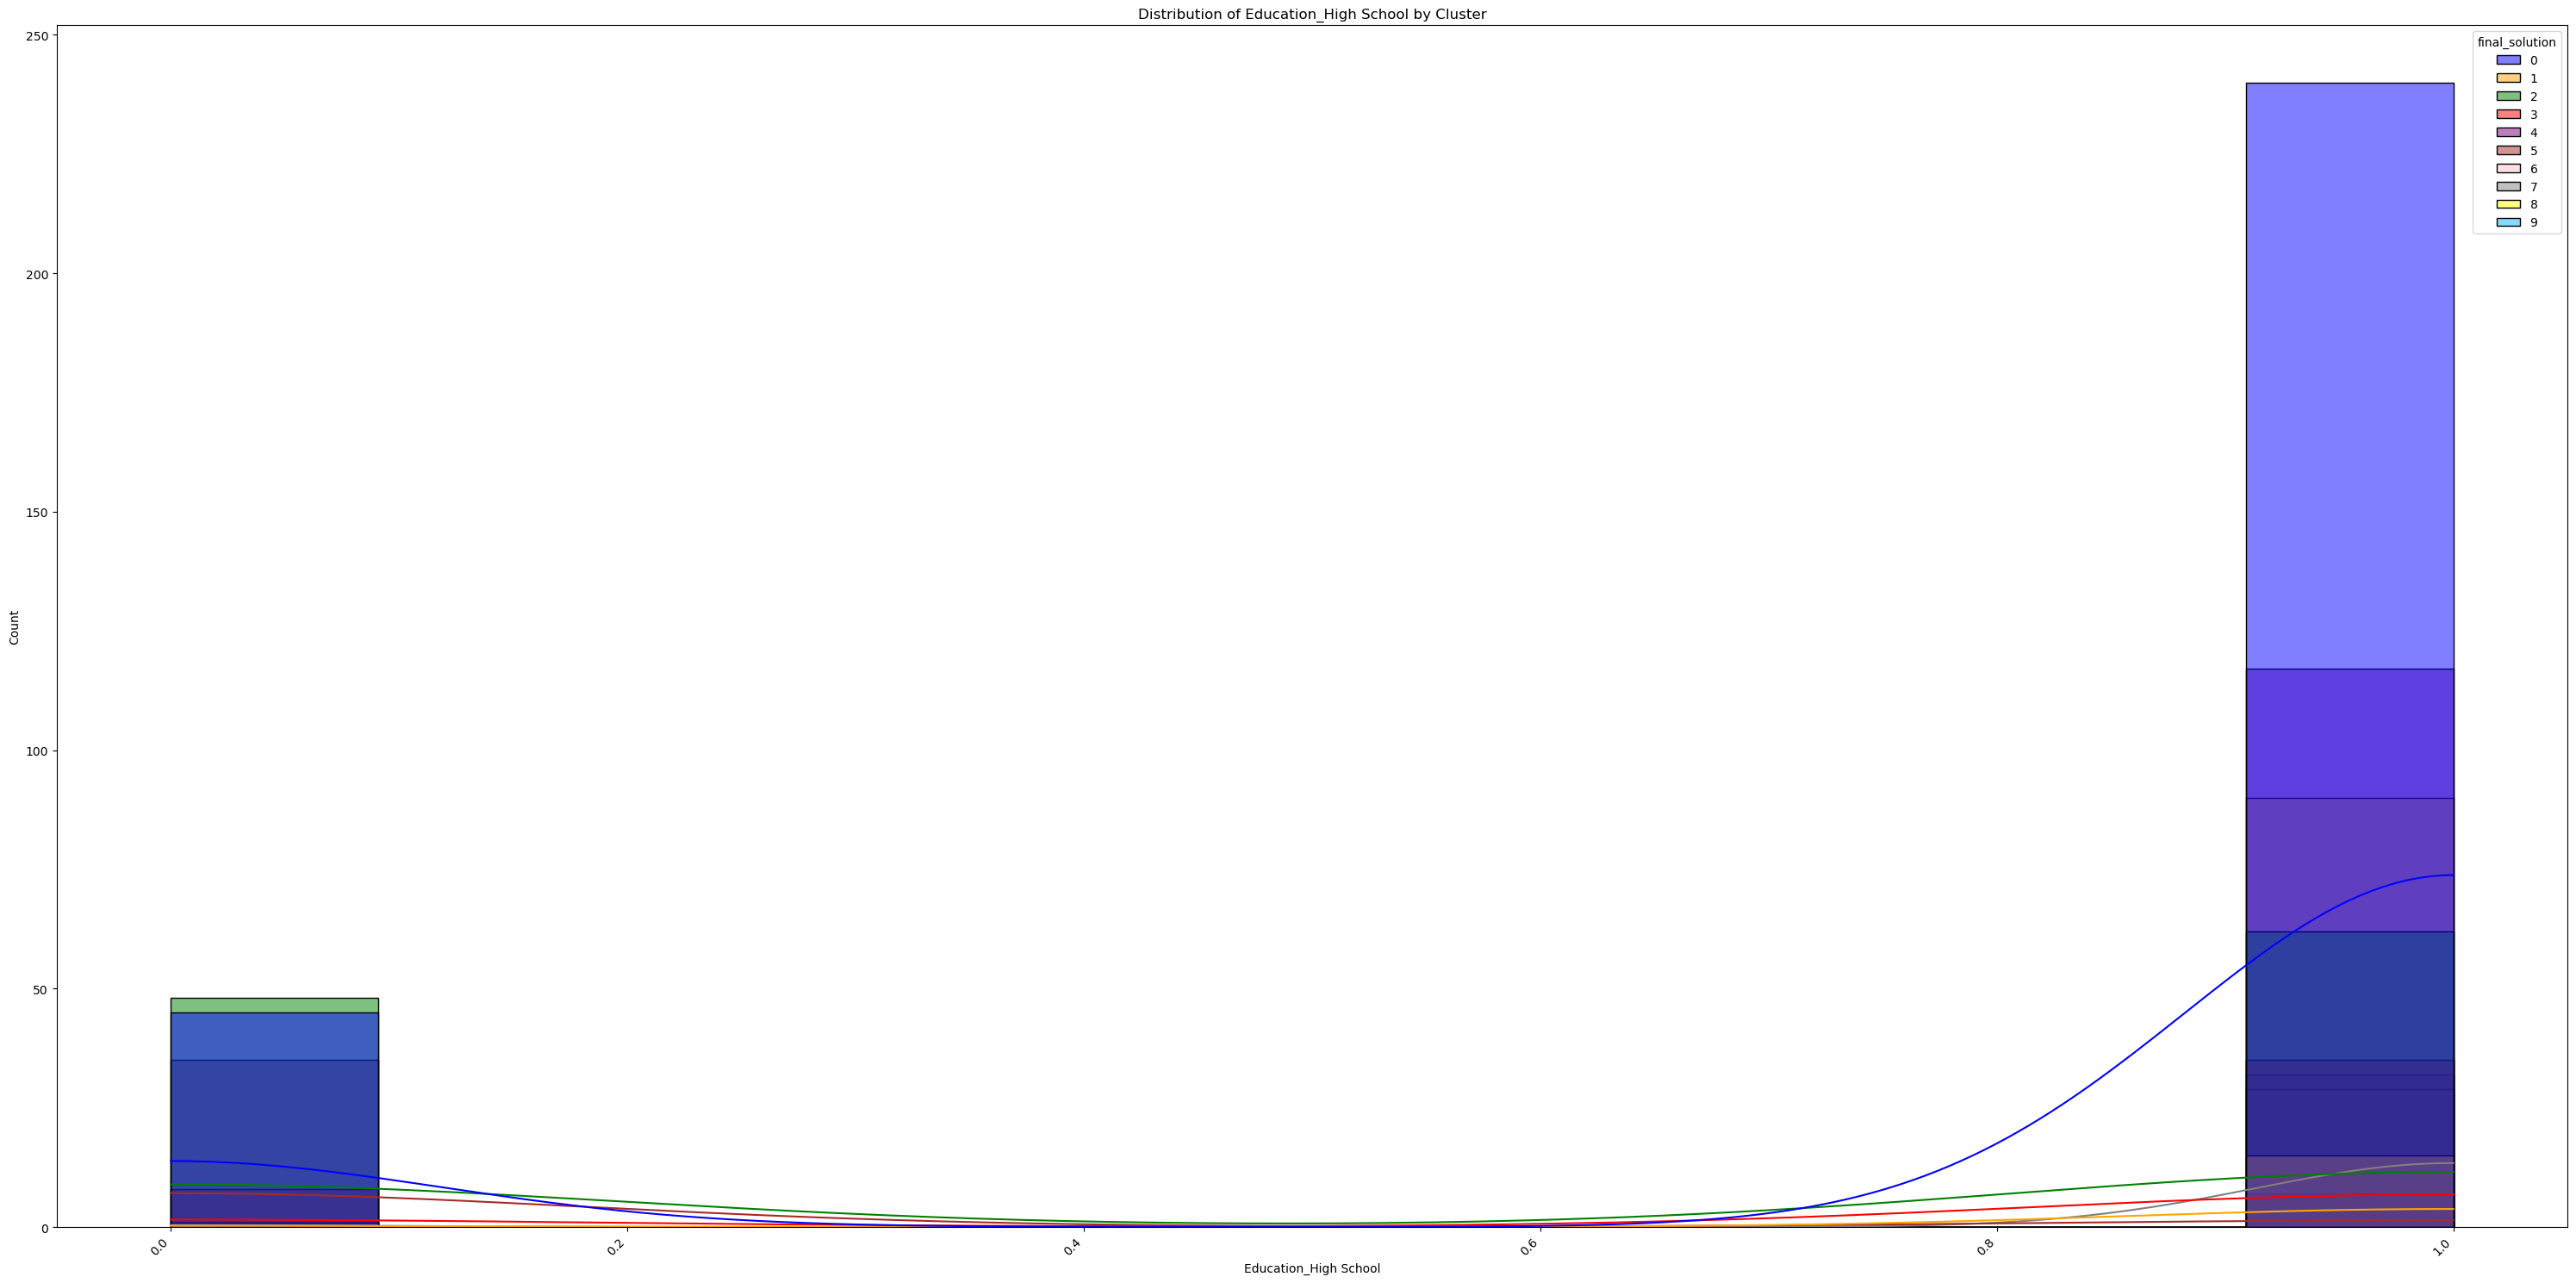

 61%|██████    | 22/36 [00:07<00:03,  3.55it/s]

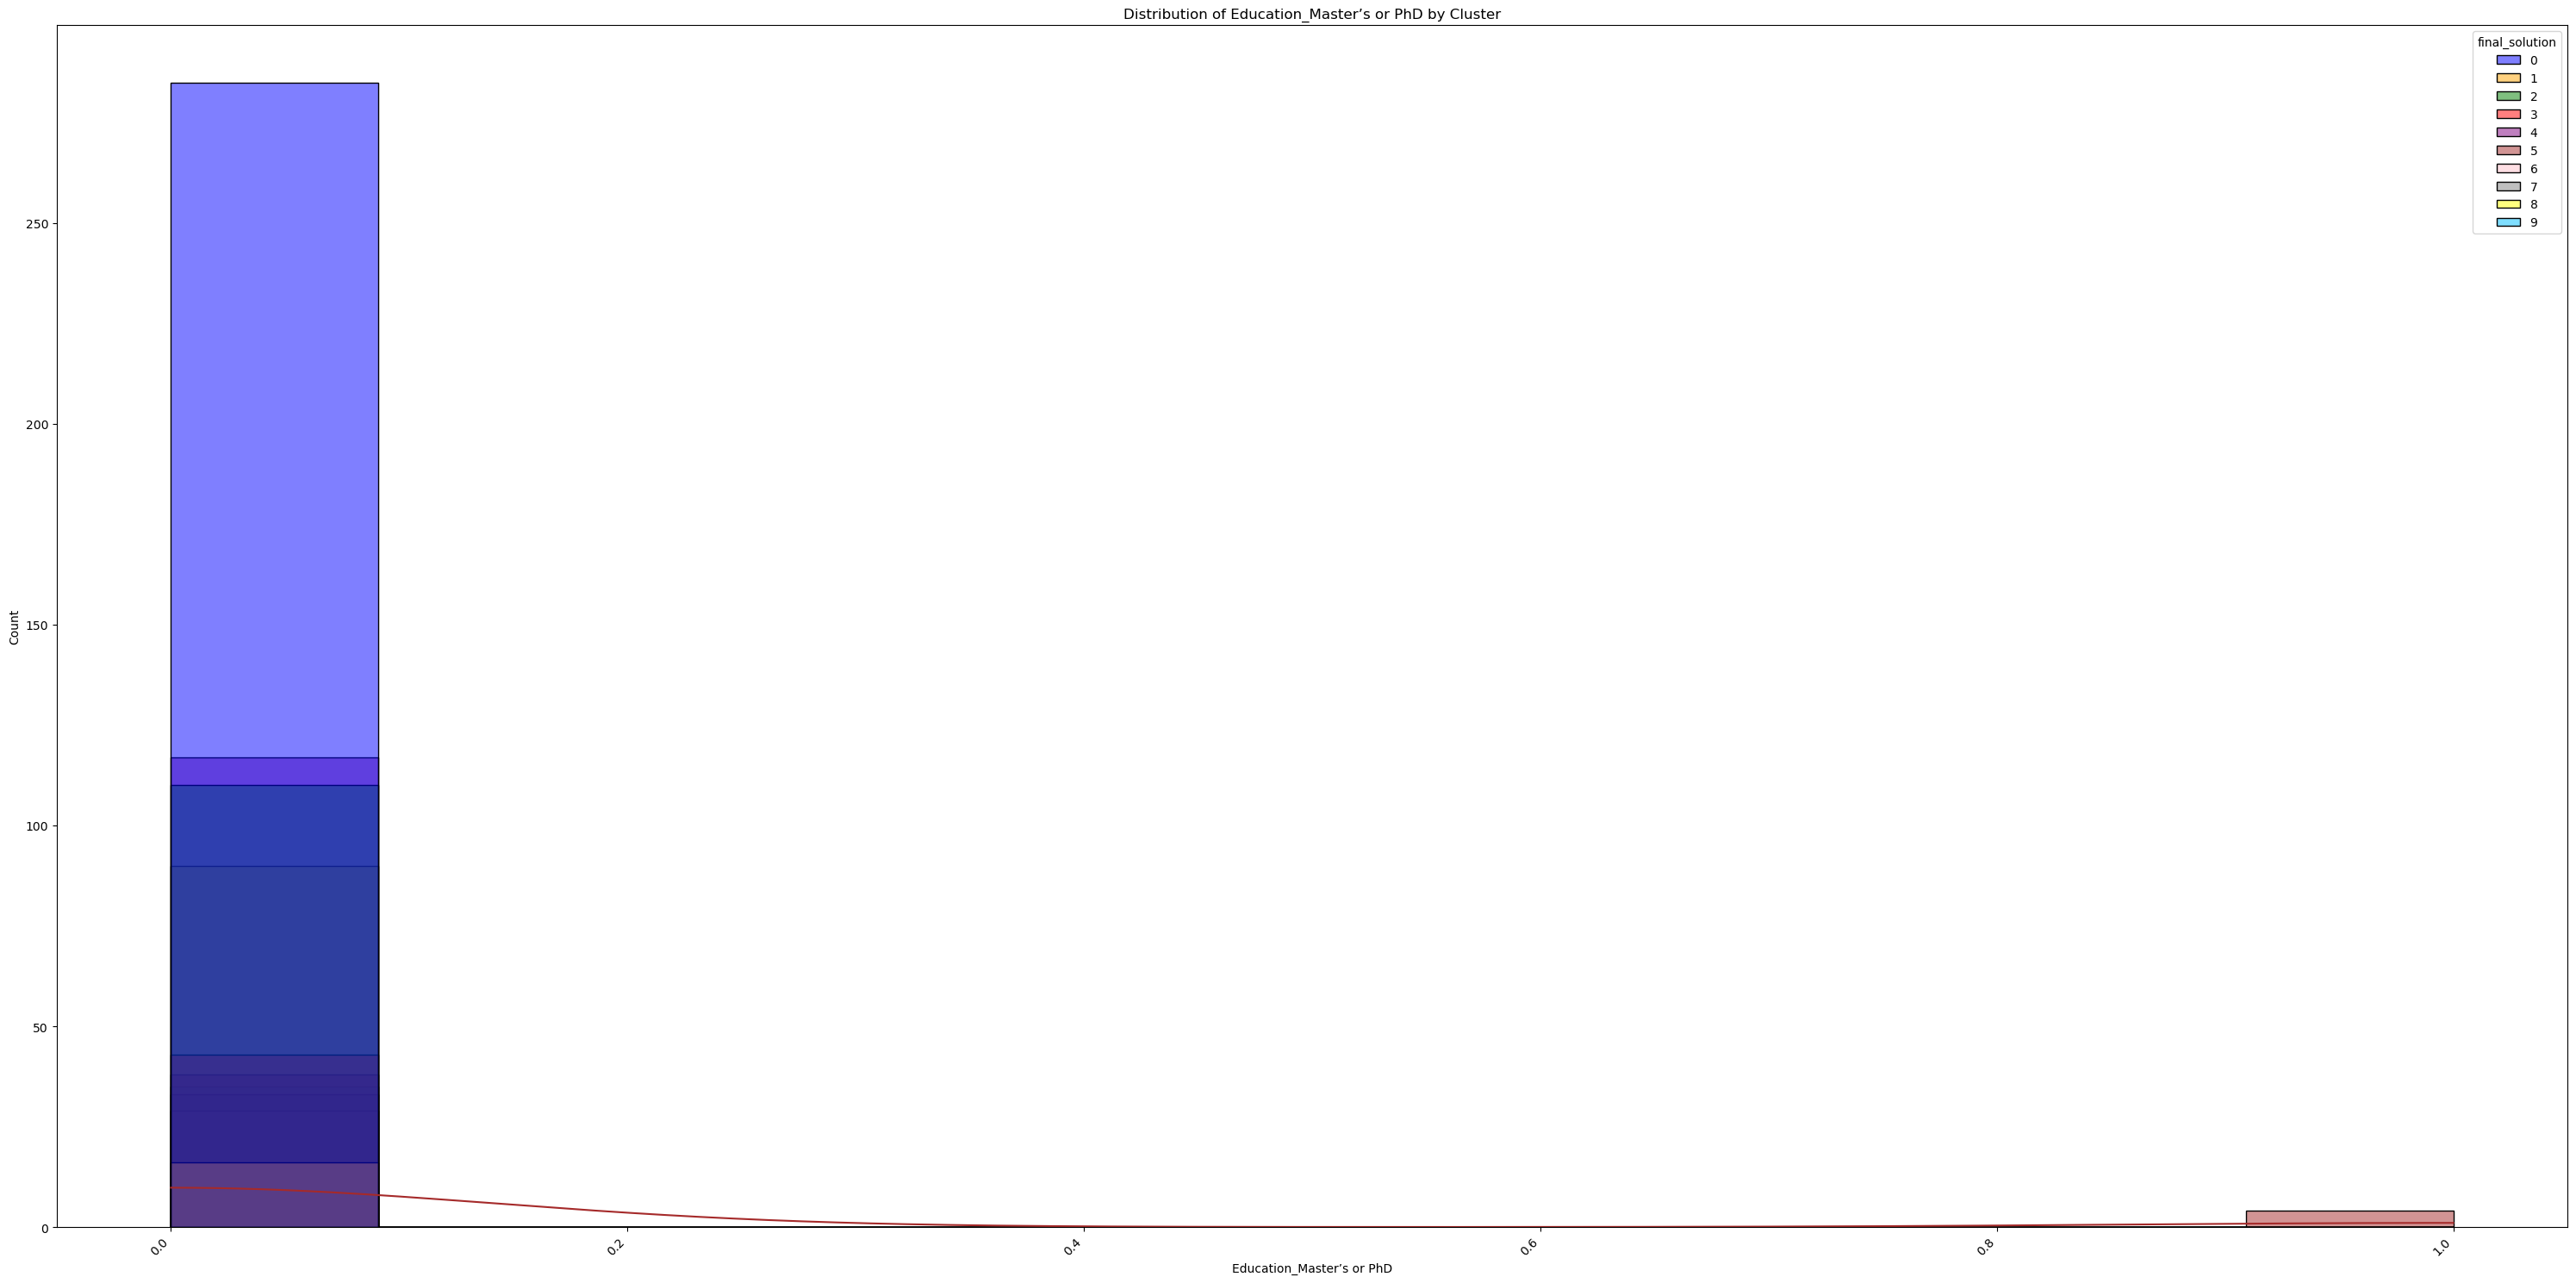

 64%|██████▍   | 23/36 [00:07<00:03,  3.77it/s]

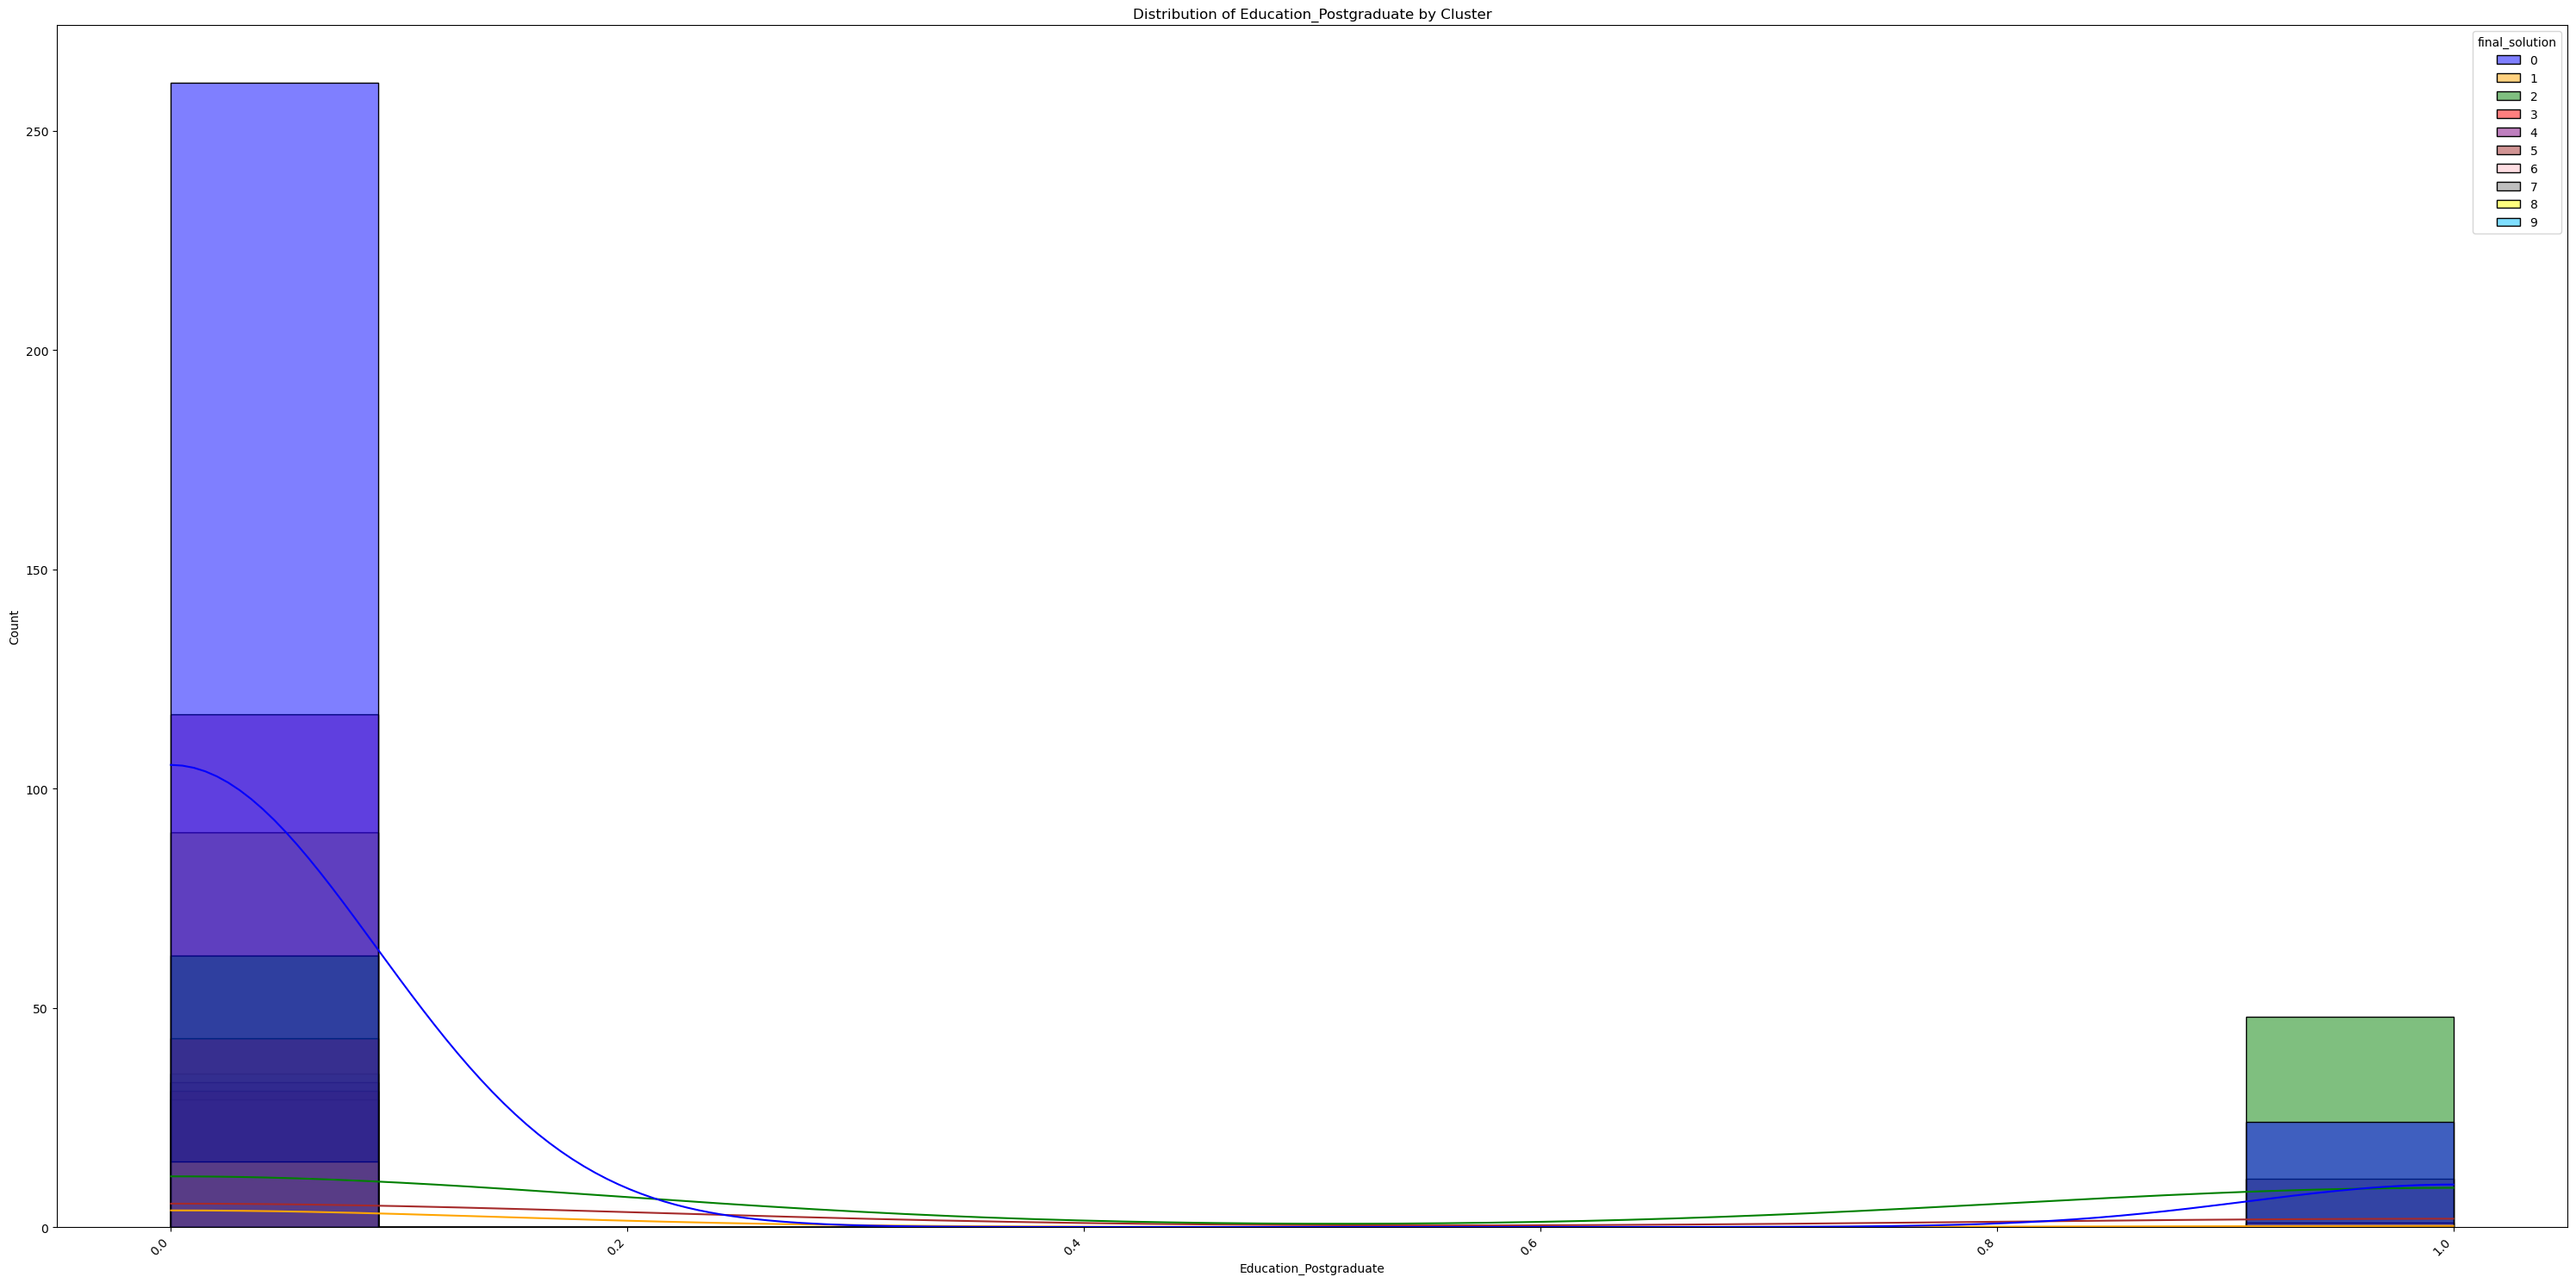

 67%|██████▋   | 24/36 [00:08<00:03,  3.92it/s]

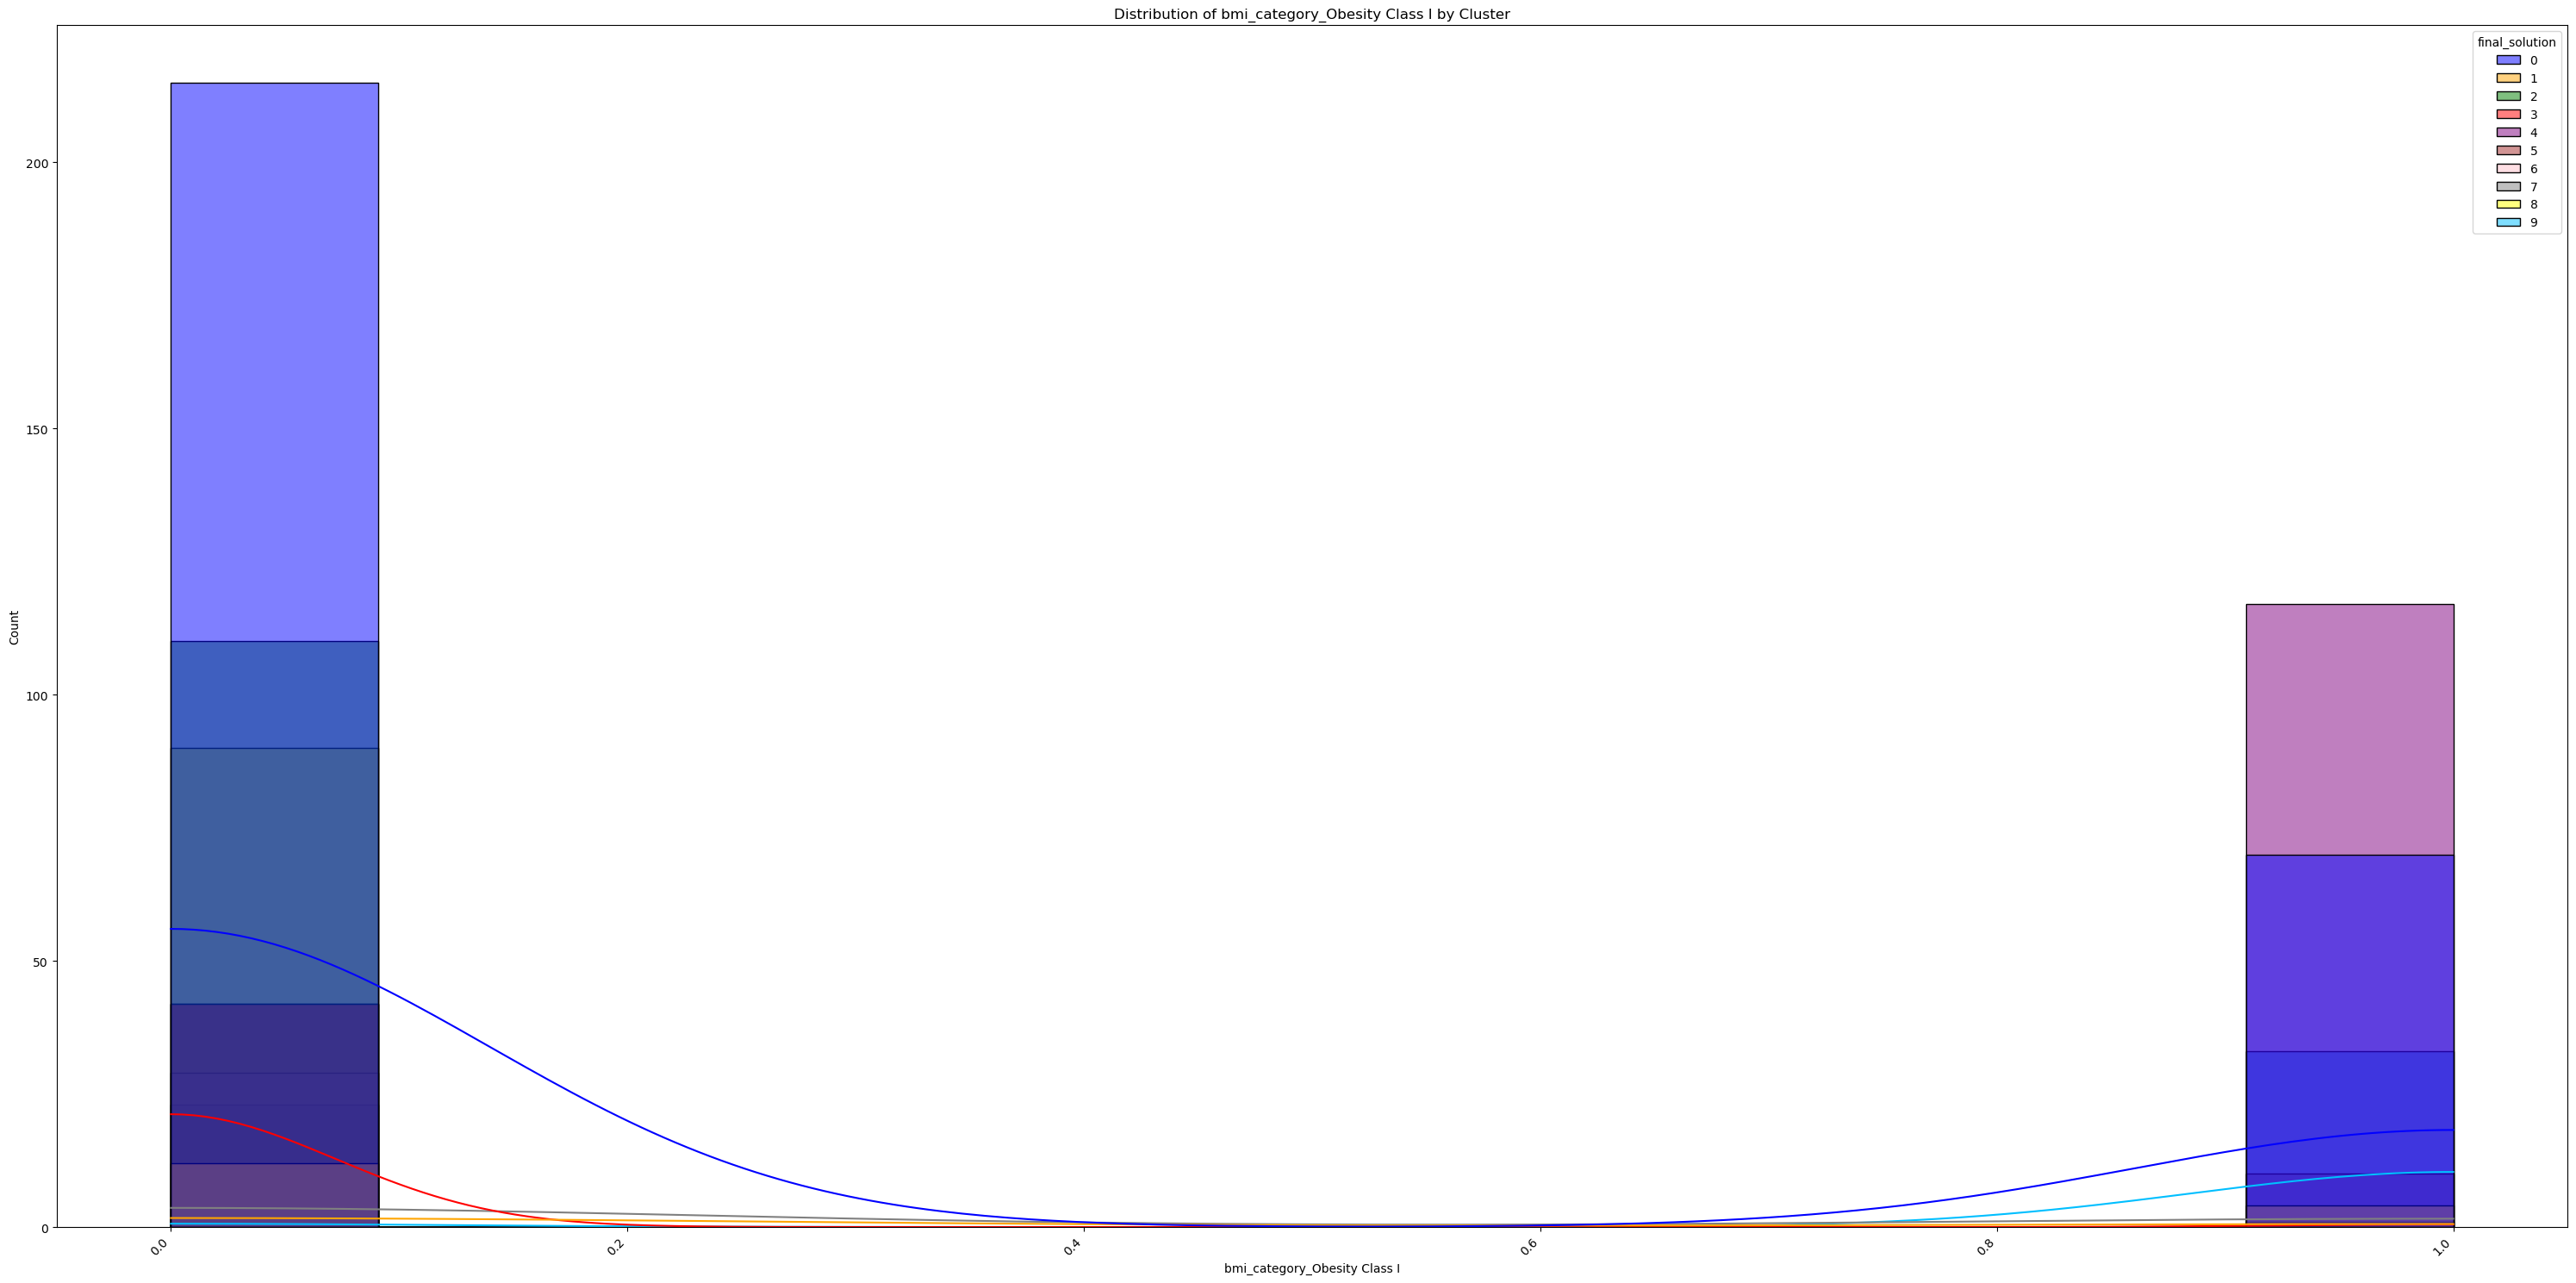

 69%|██████▉   | 25/36 [00:08<00:02,  4.05it/s]

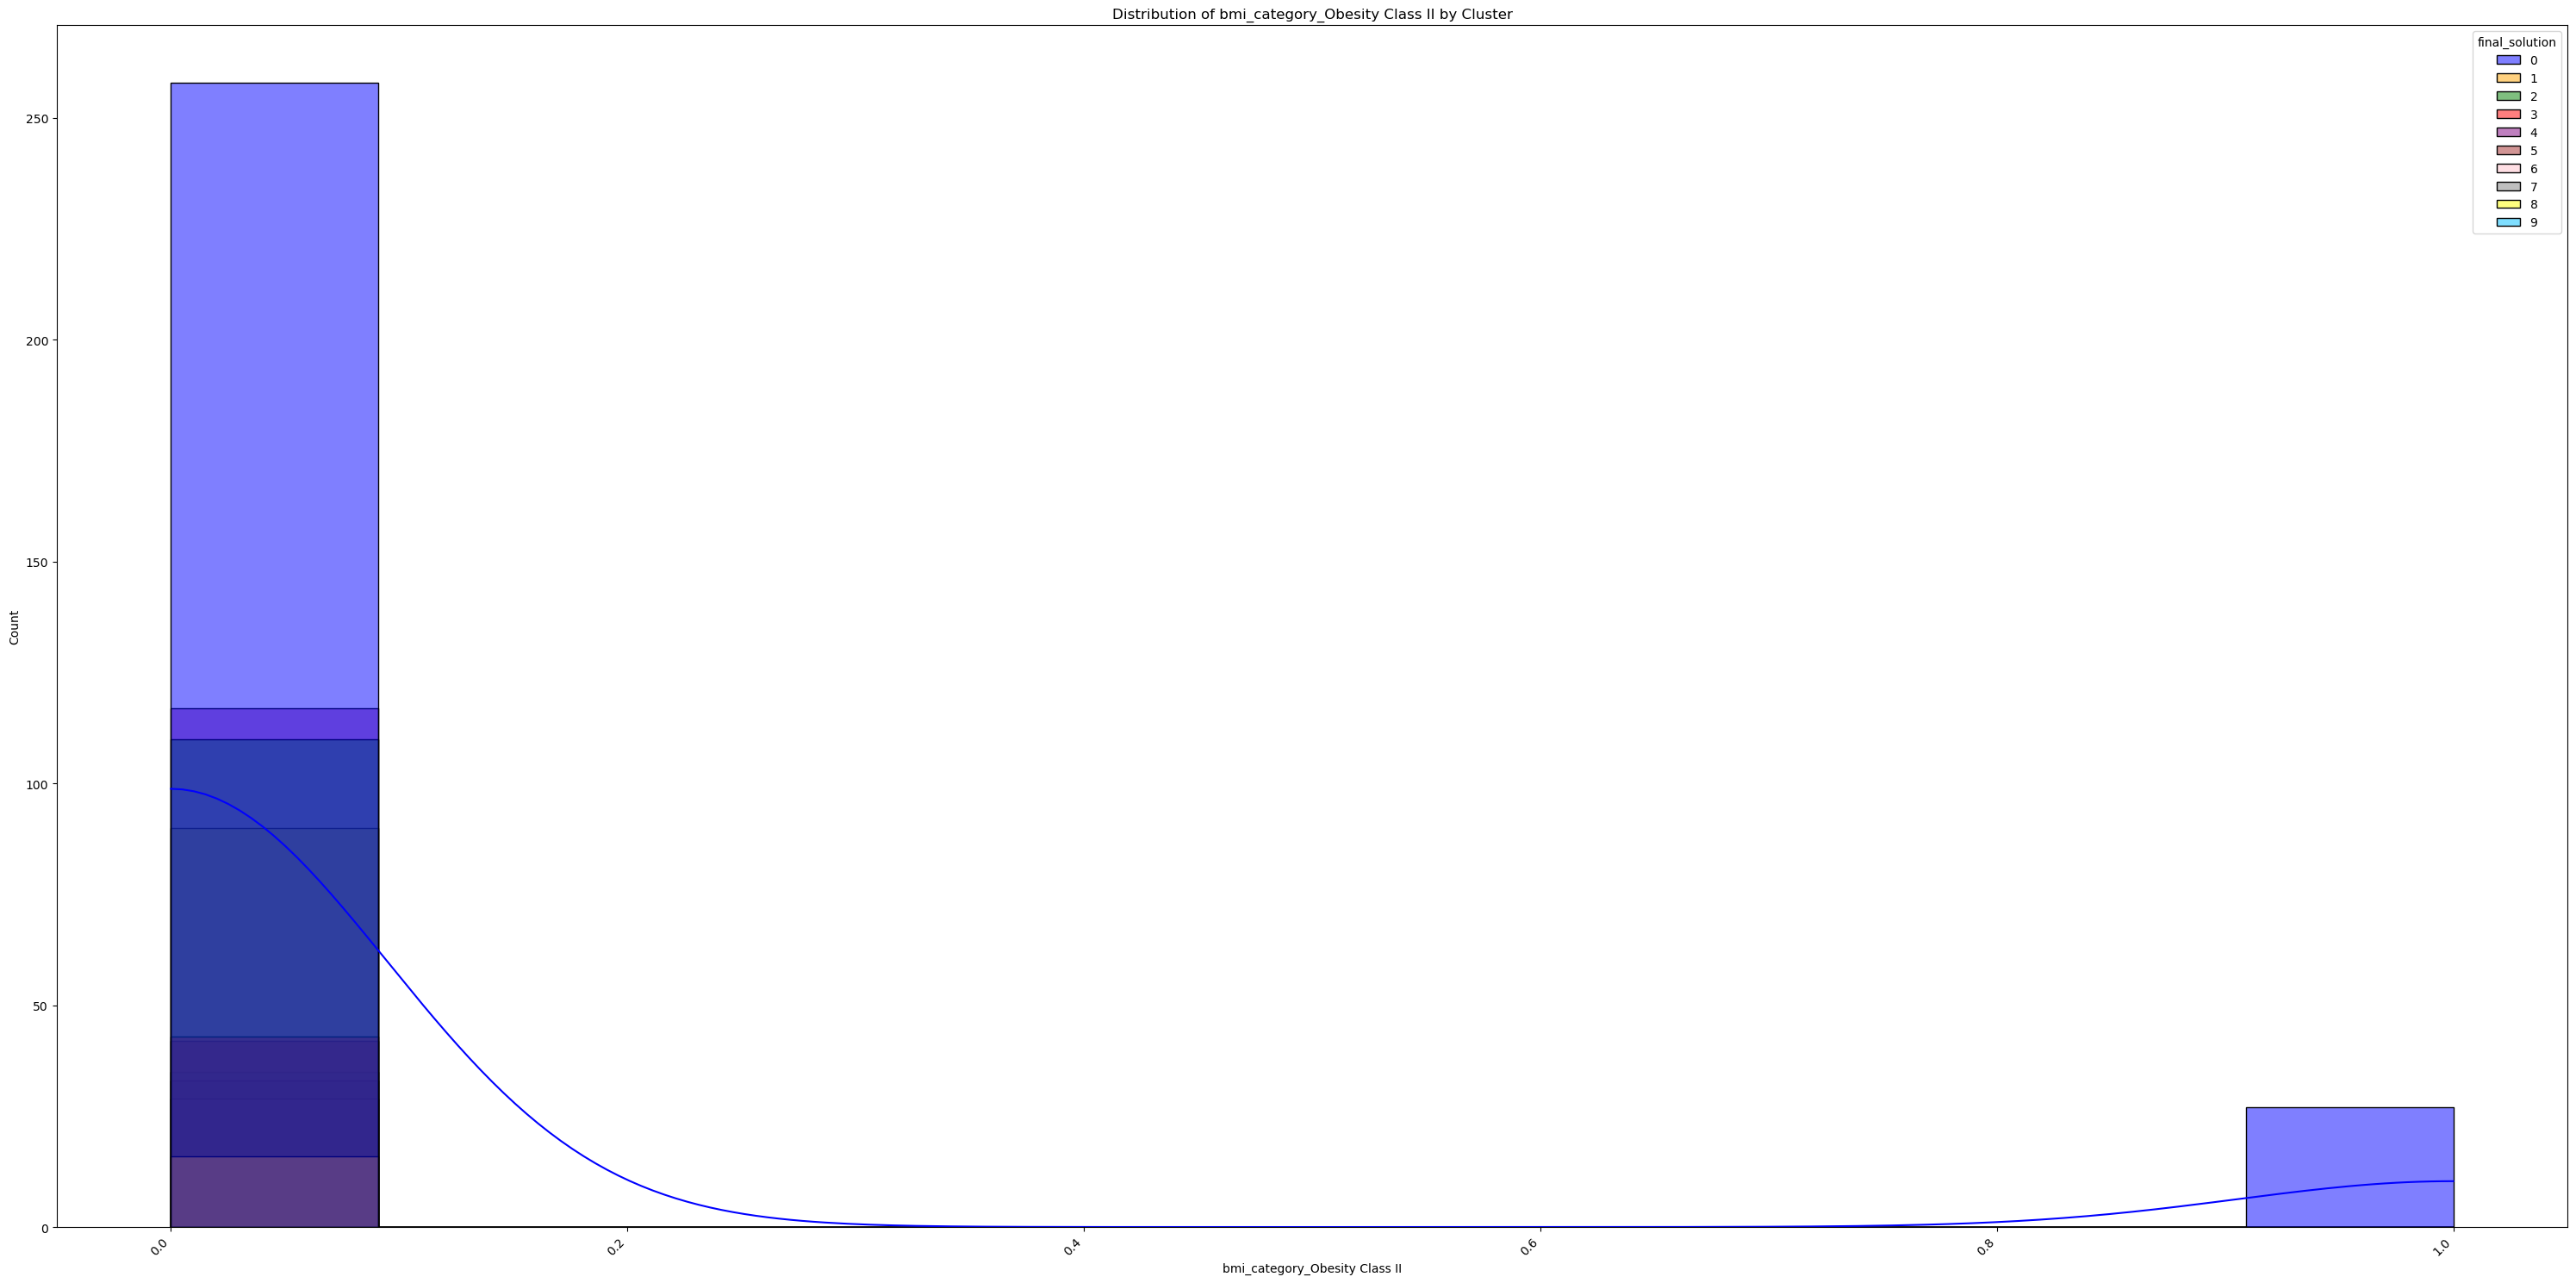

 72%|███████▏  | 26/36 [00:08<00:02,  3.58it/s]

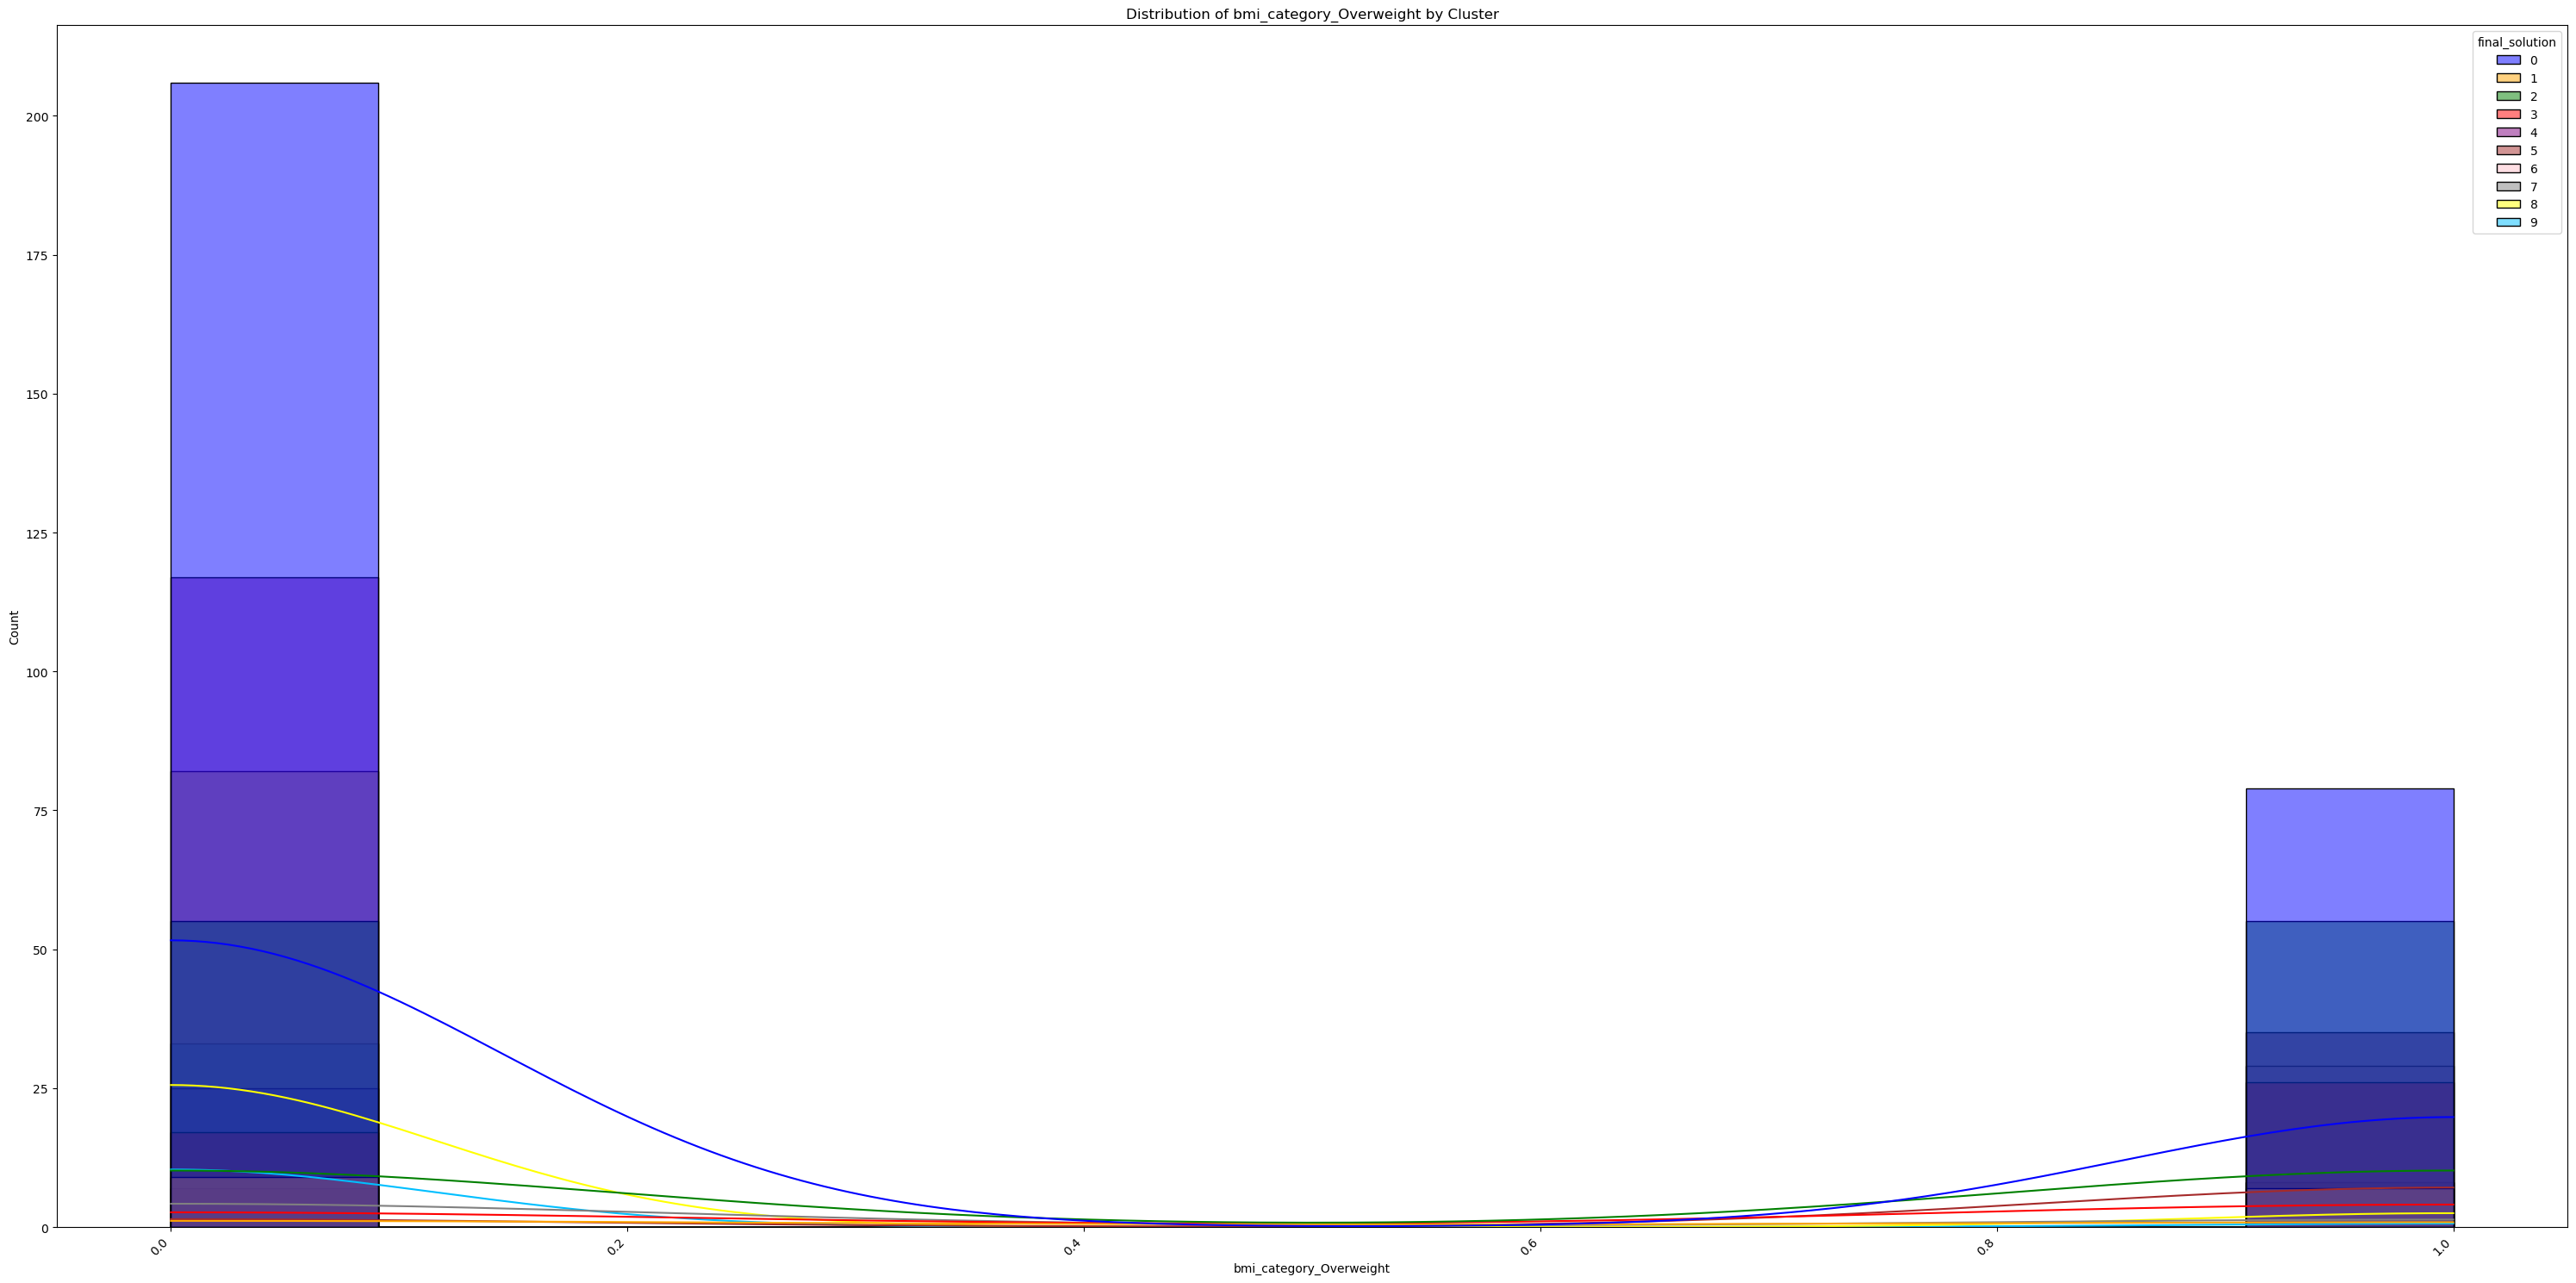

 75%|███████▌  | 27/36 [00:08<00:02,  3.69it/s]

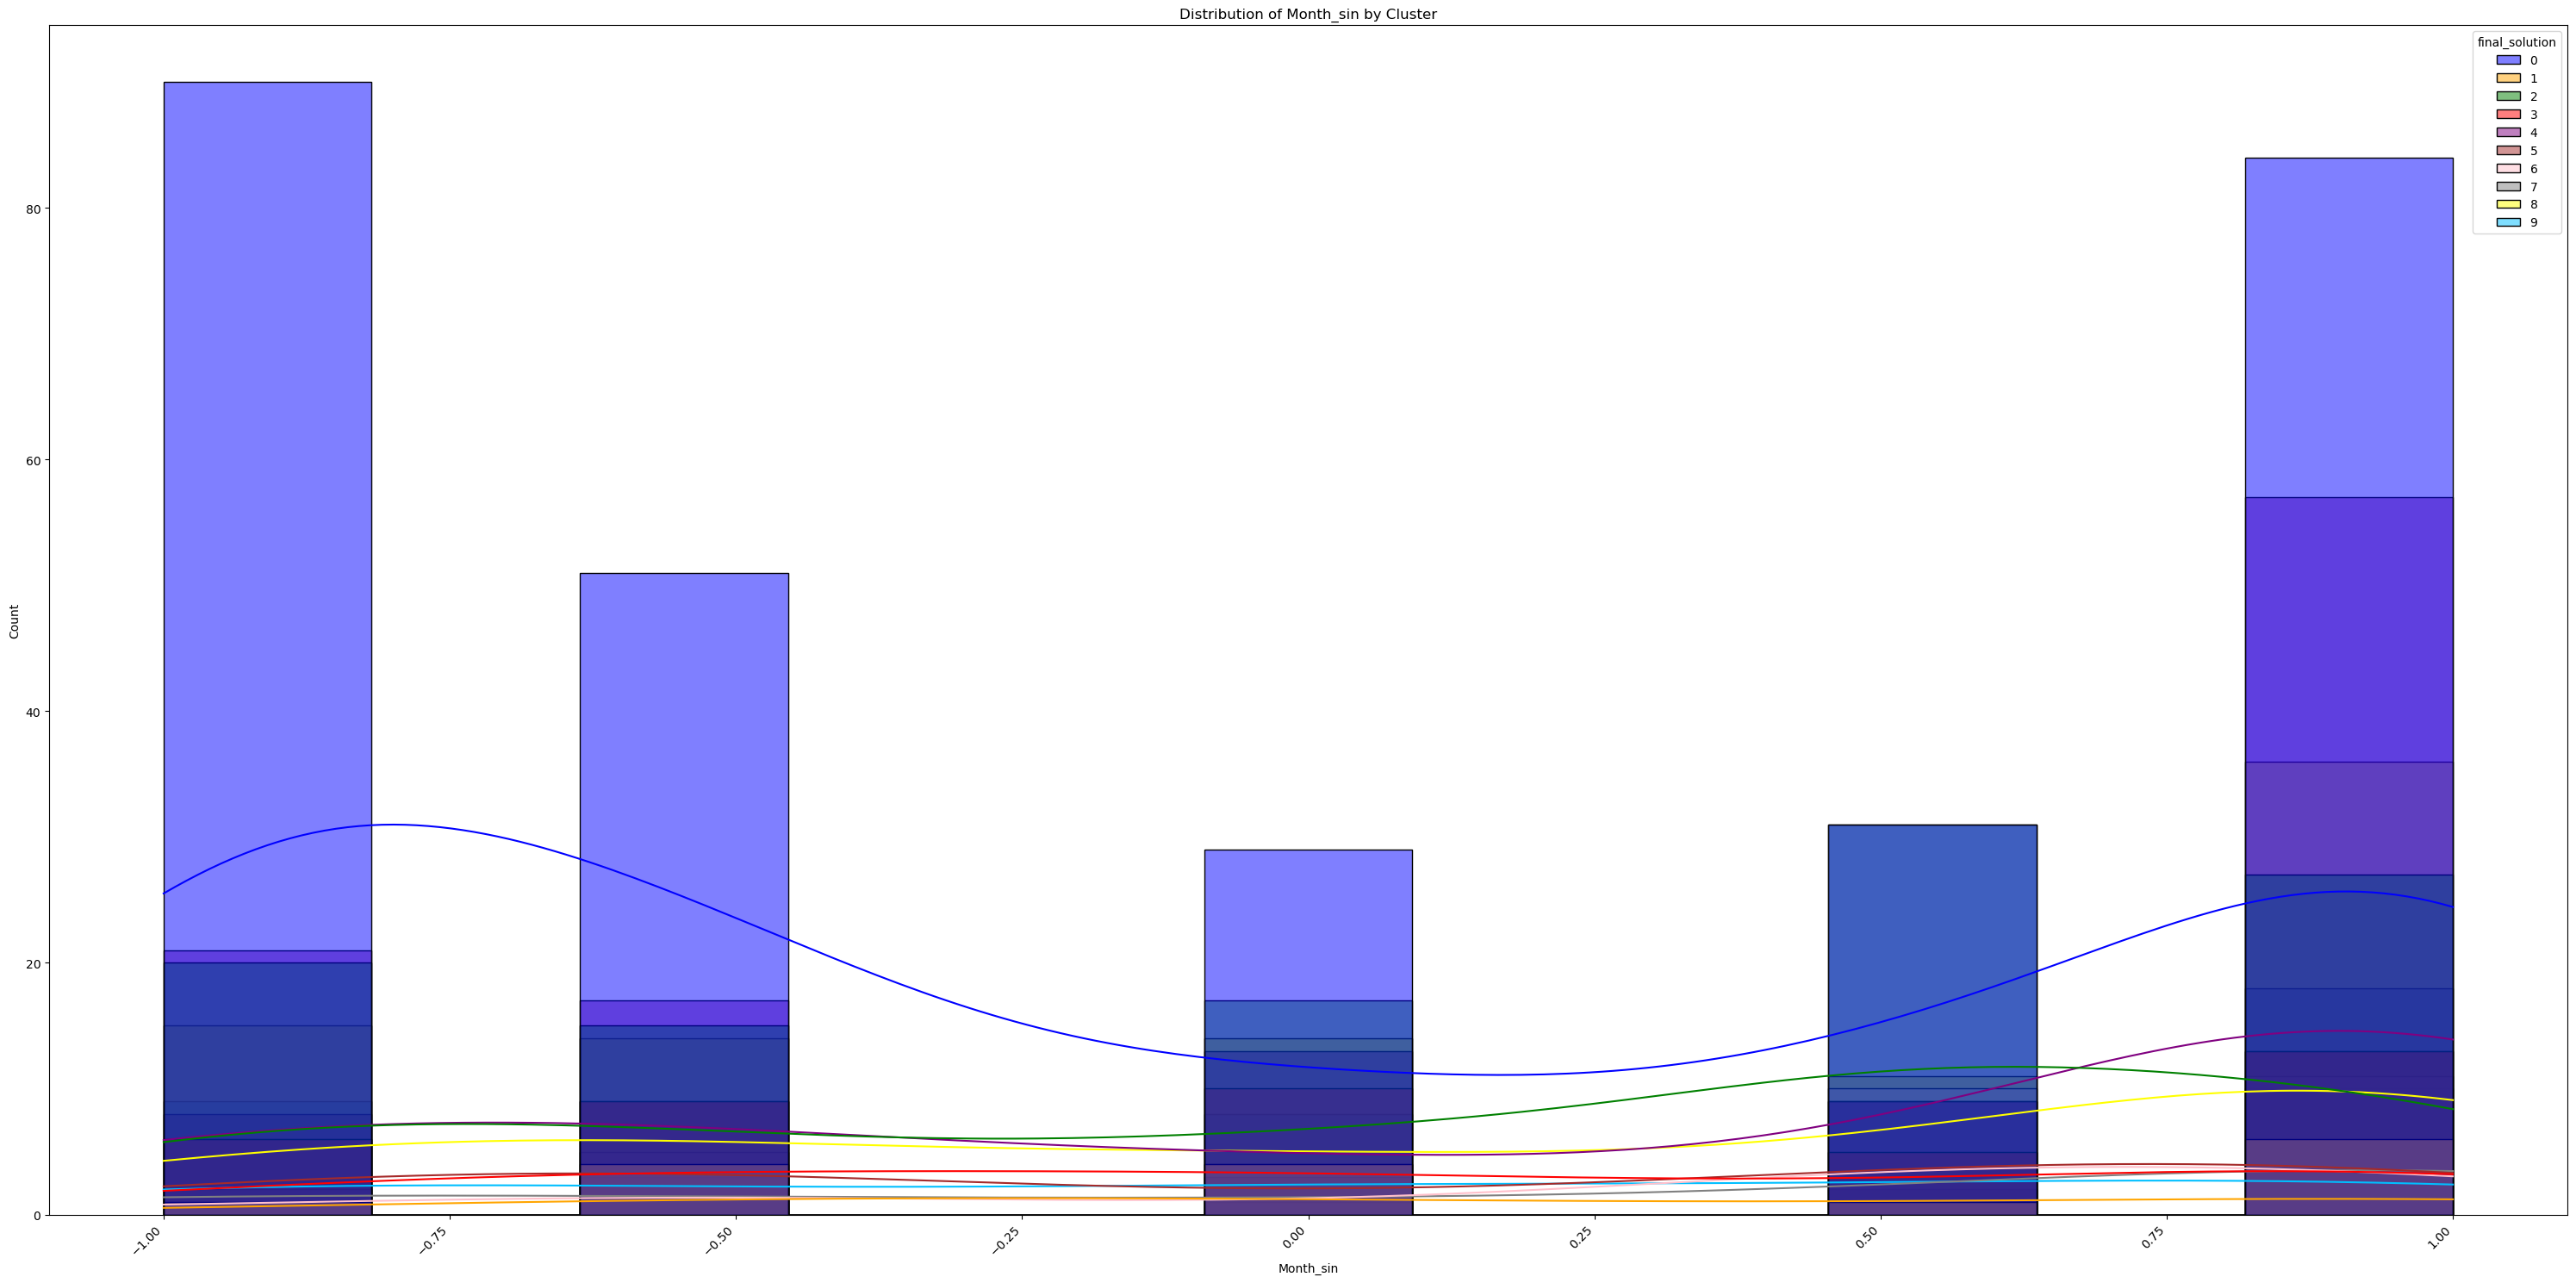

 78%|███████▊  | 28/36 [00:09<00:02,  3.69it/s]

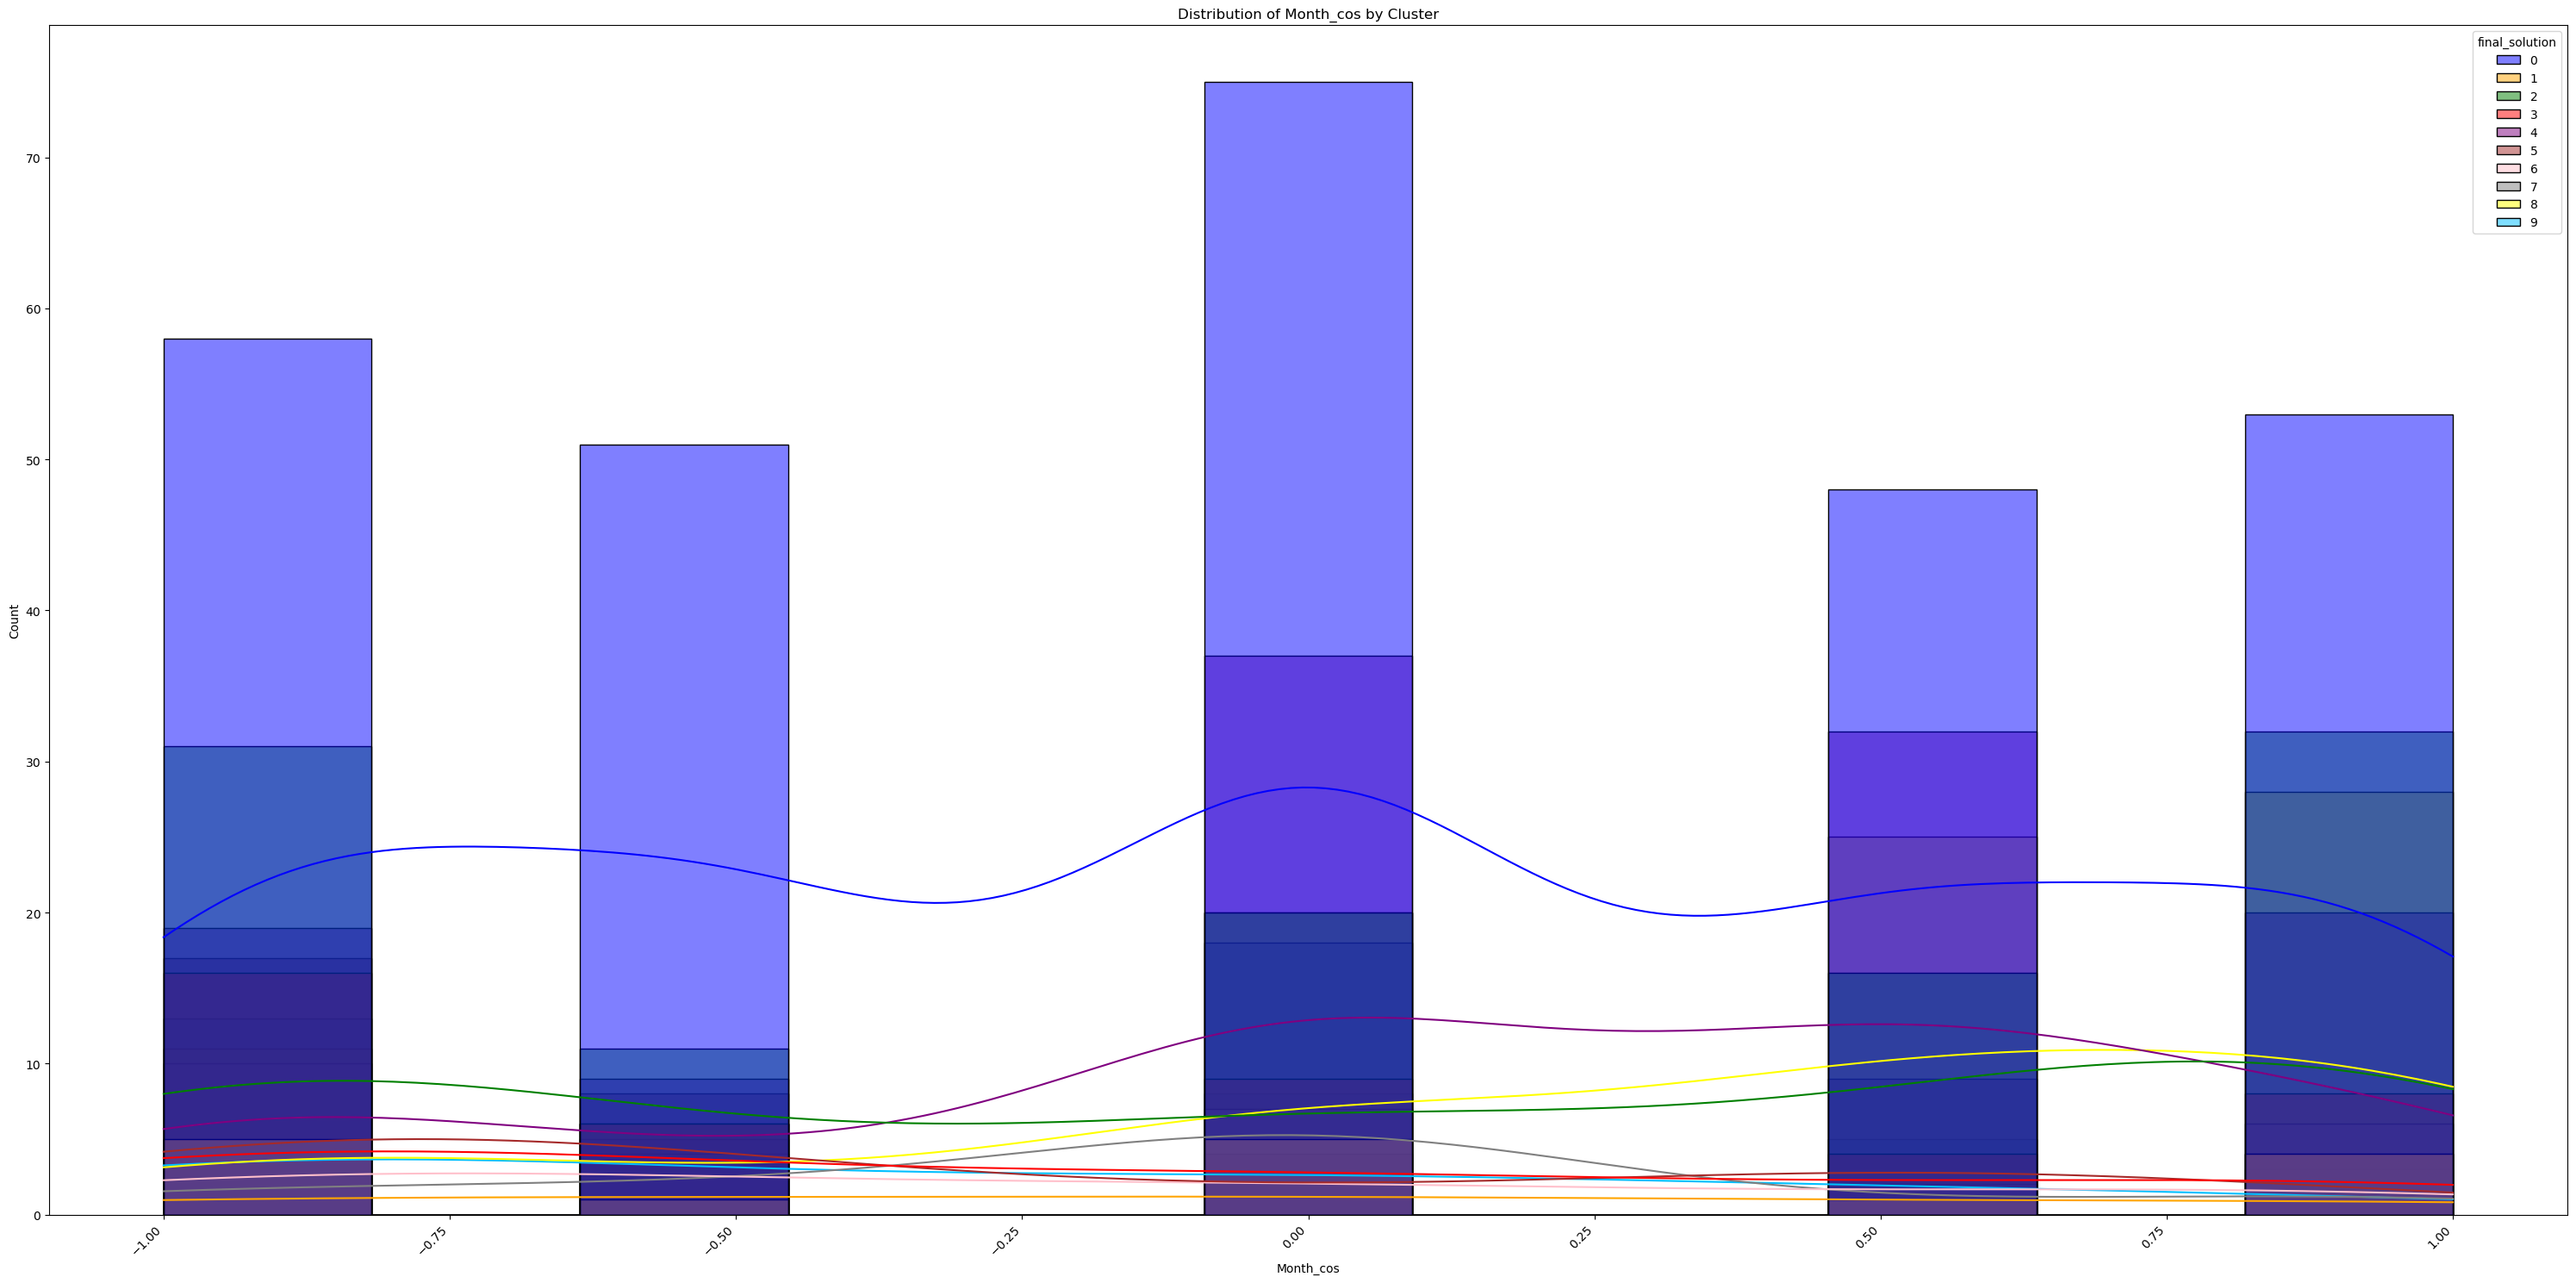

 81%|████████  | 29/36 [00:09<00:01,  3.69it/s]

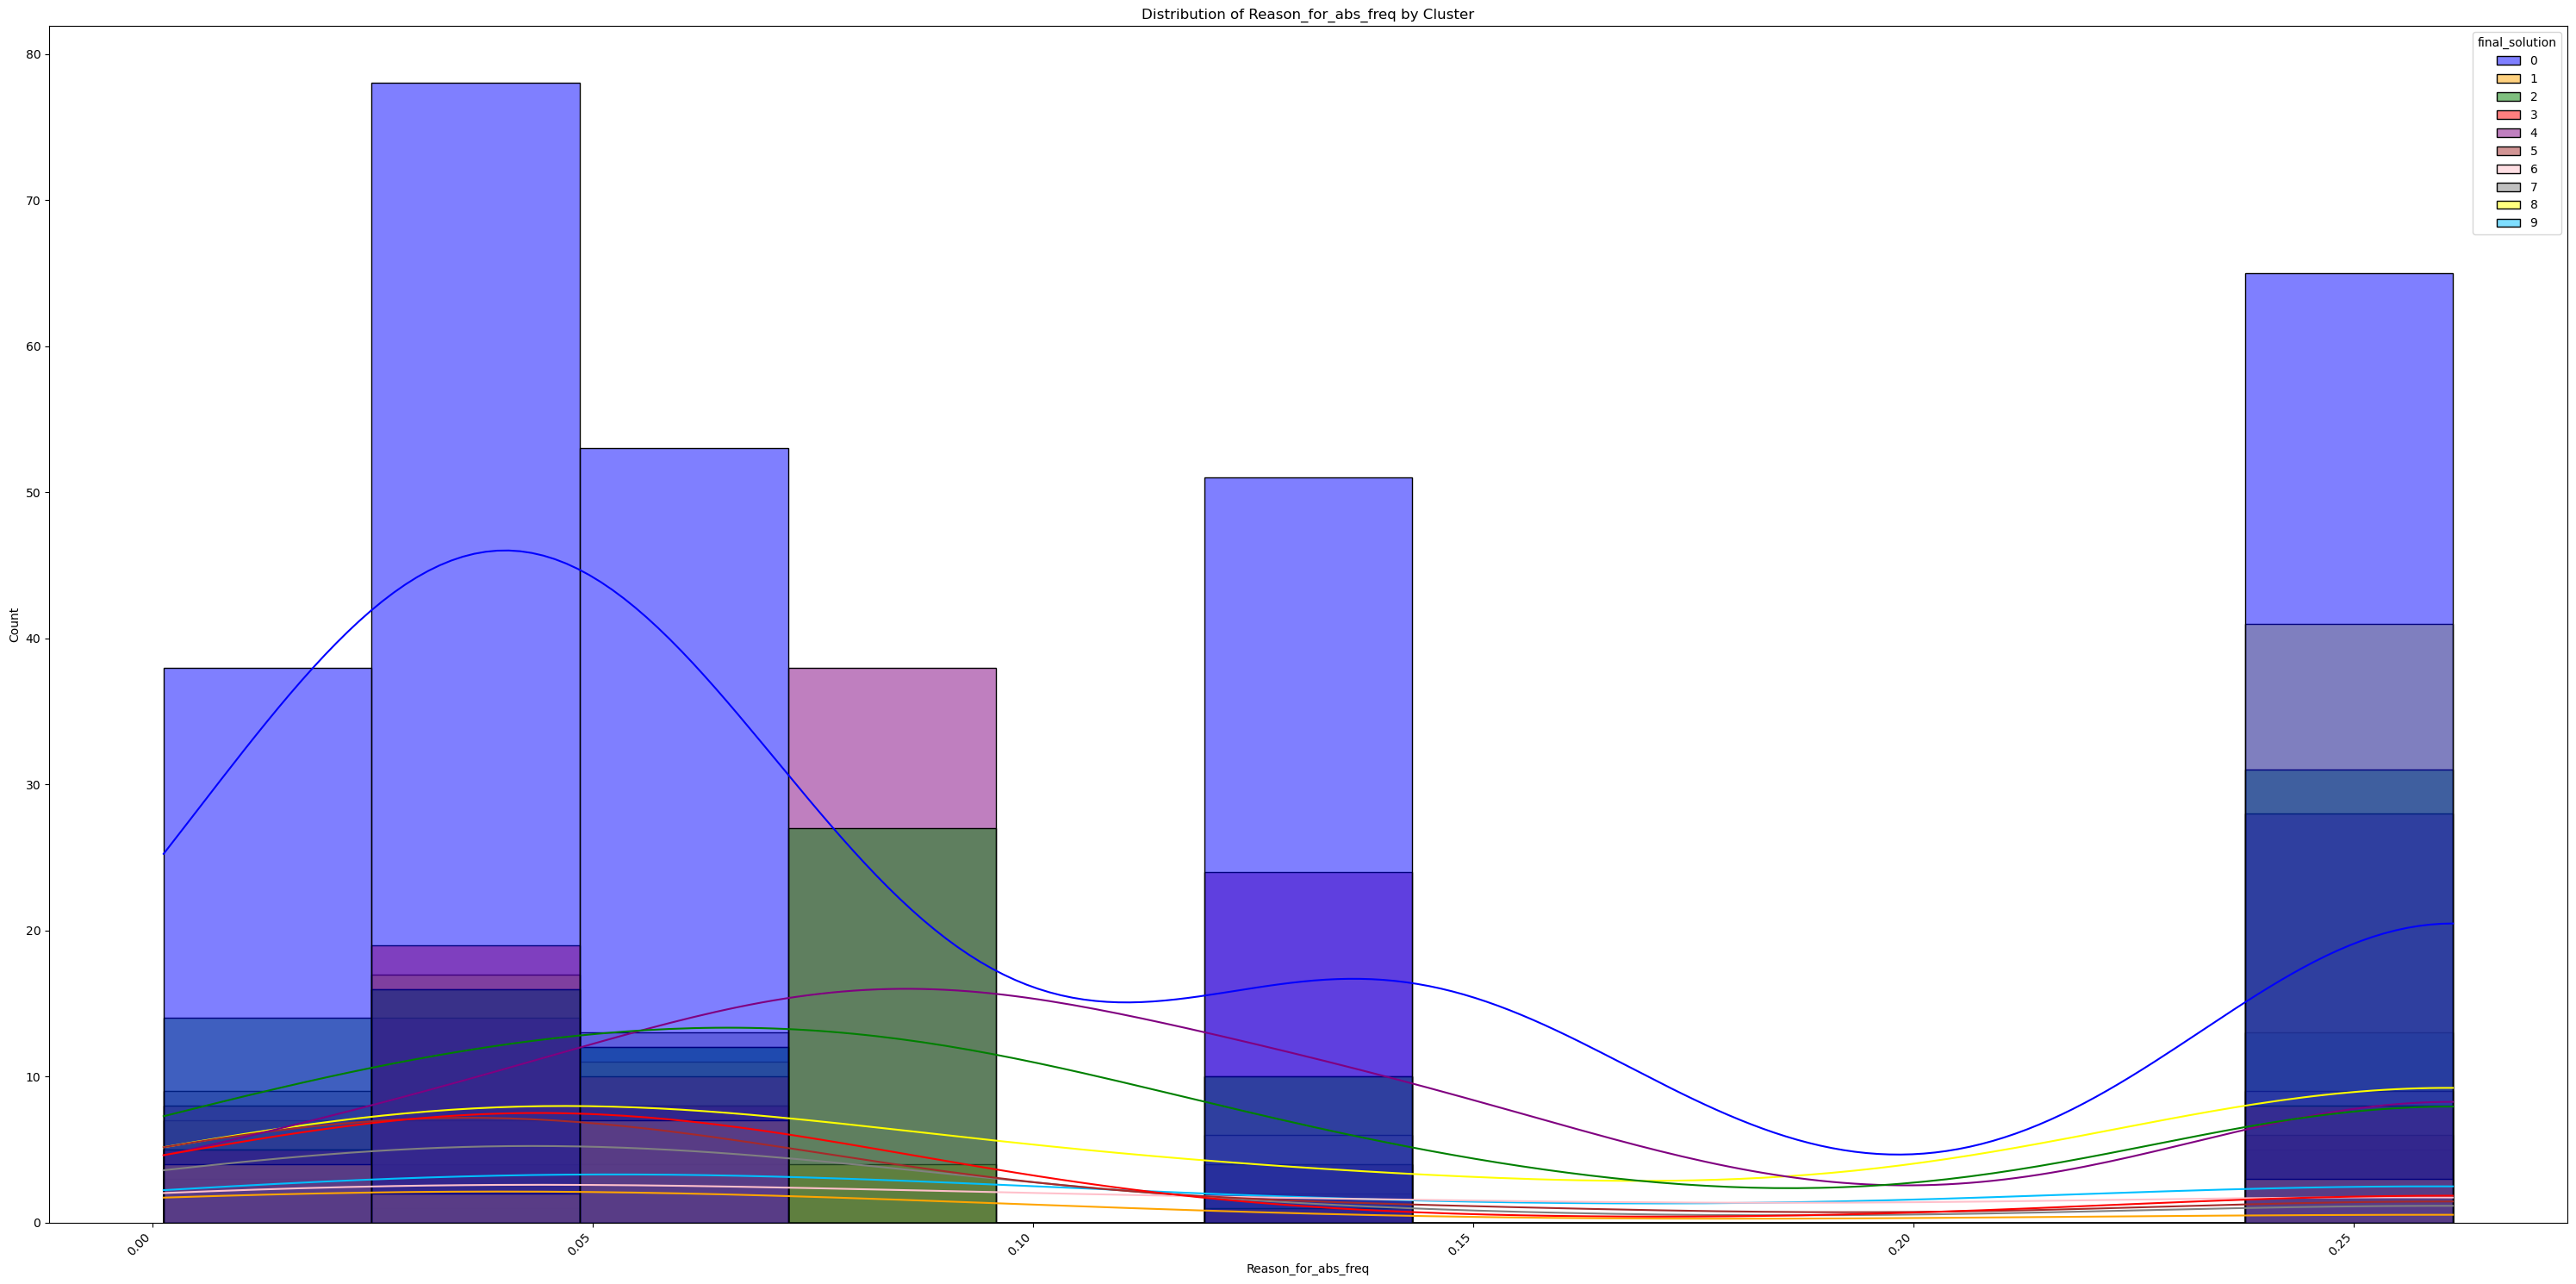

 83%|████████▎ | 30/36 [00:09<00:01,  3.42it/s]

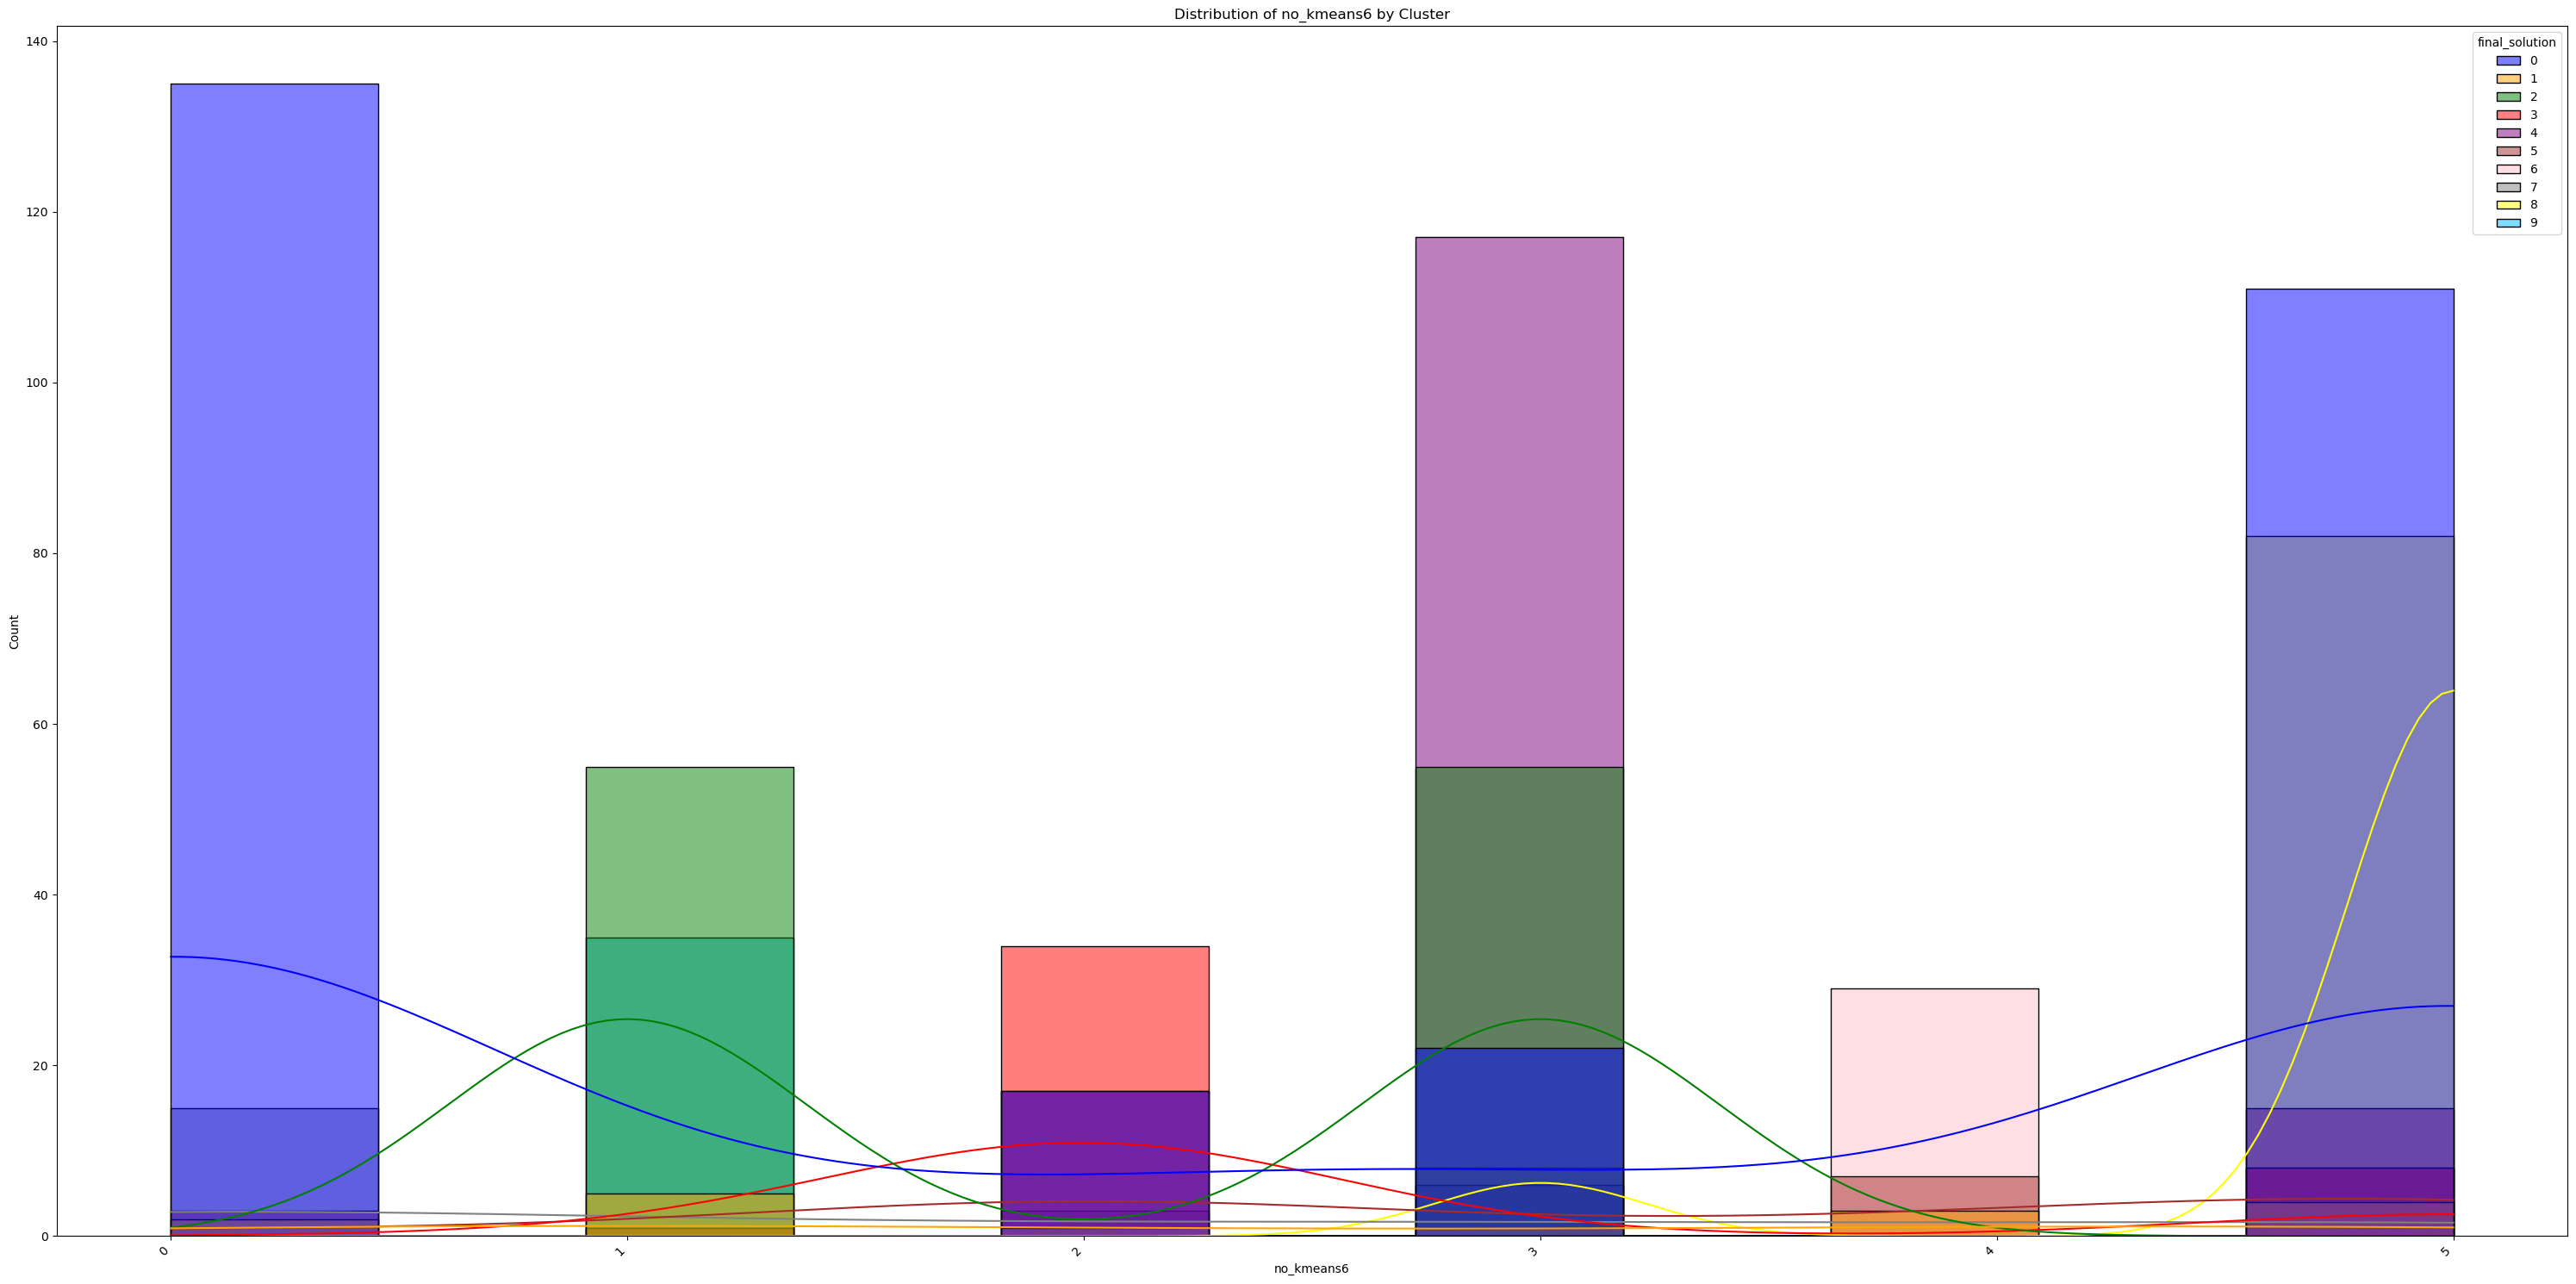

 86%|████████▌ | 31/36 [00:10<00:01,  3.55it/s]

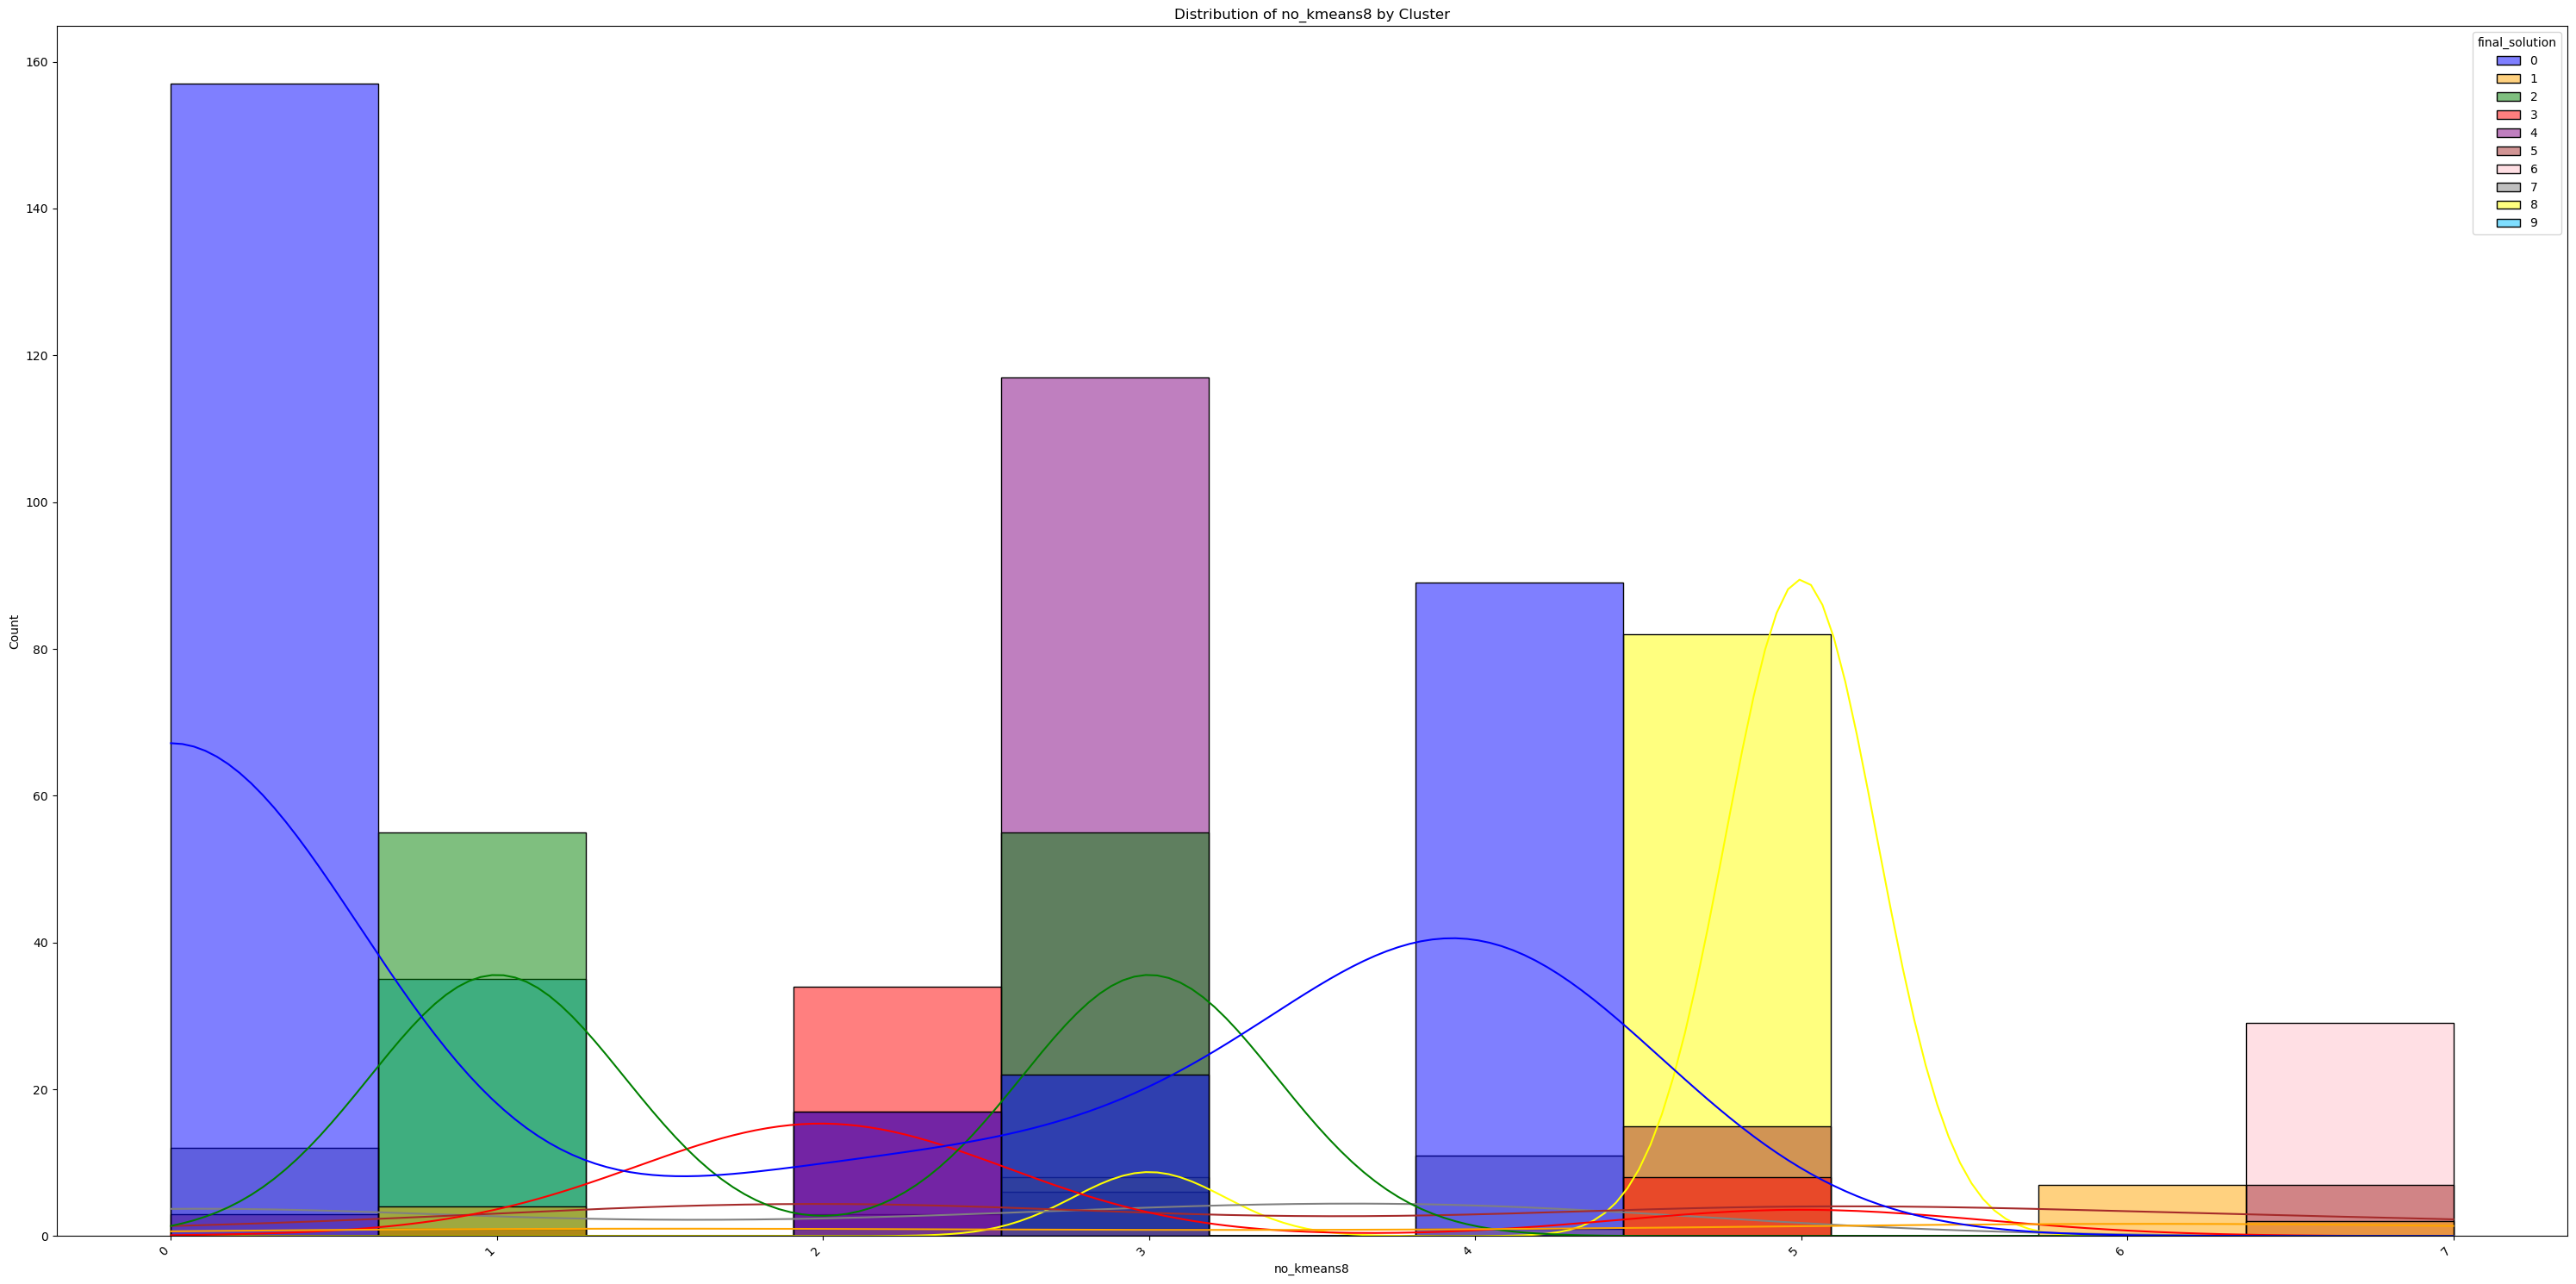

 89%|████████▉ | 32/36 [00:10<00:01,  2.61it/s]

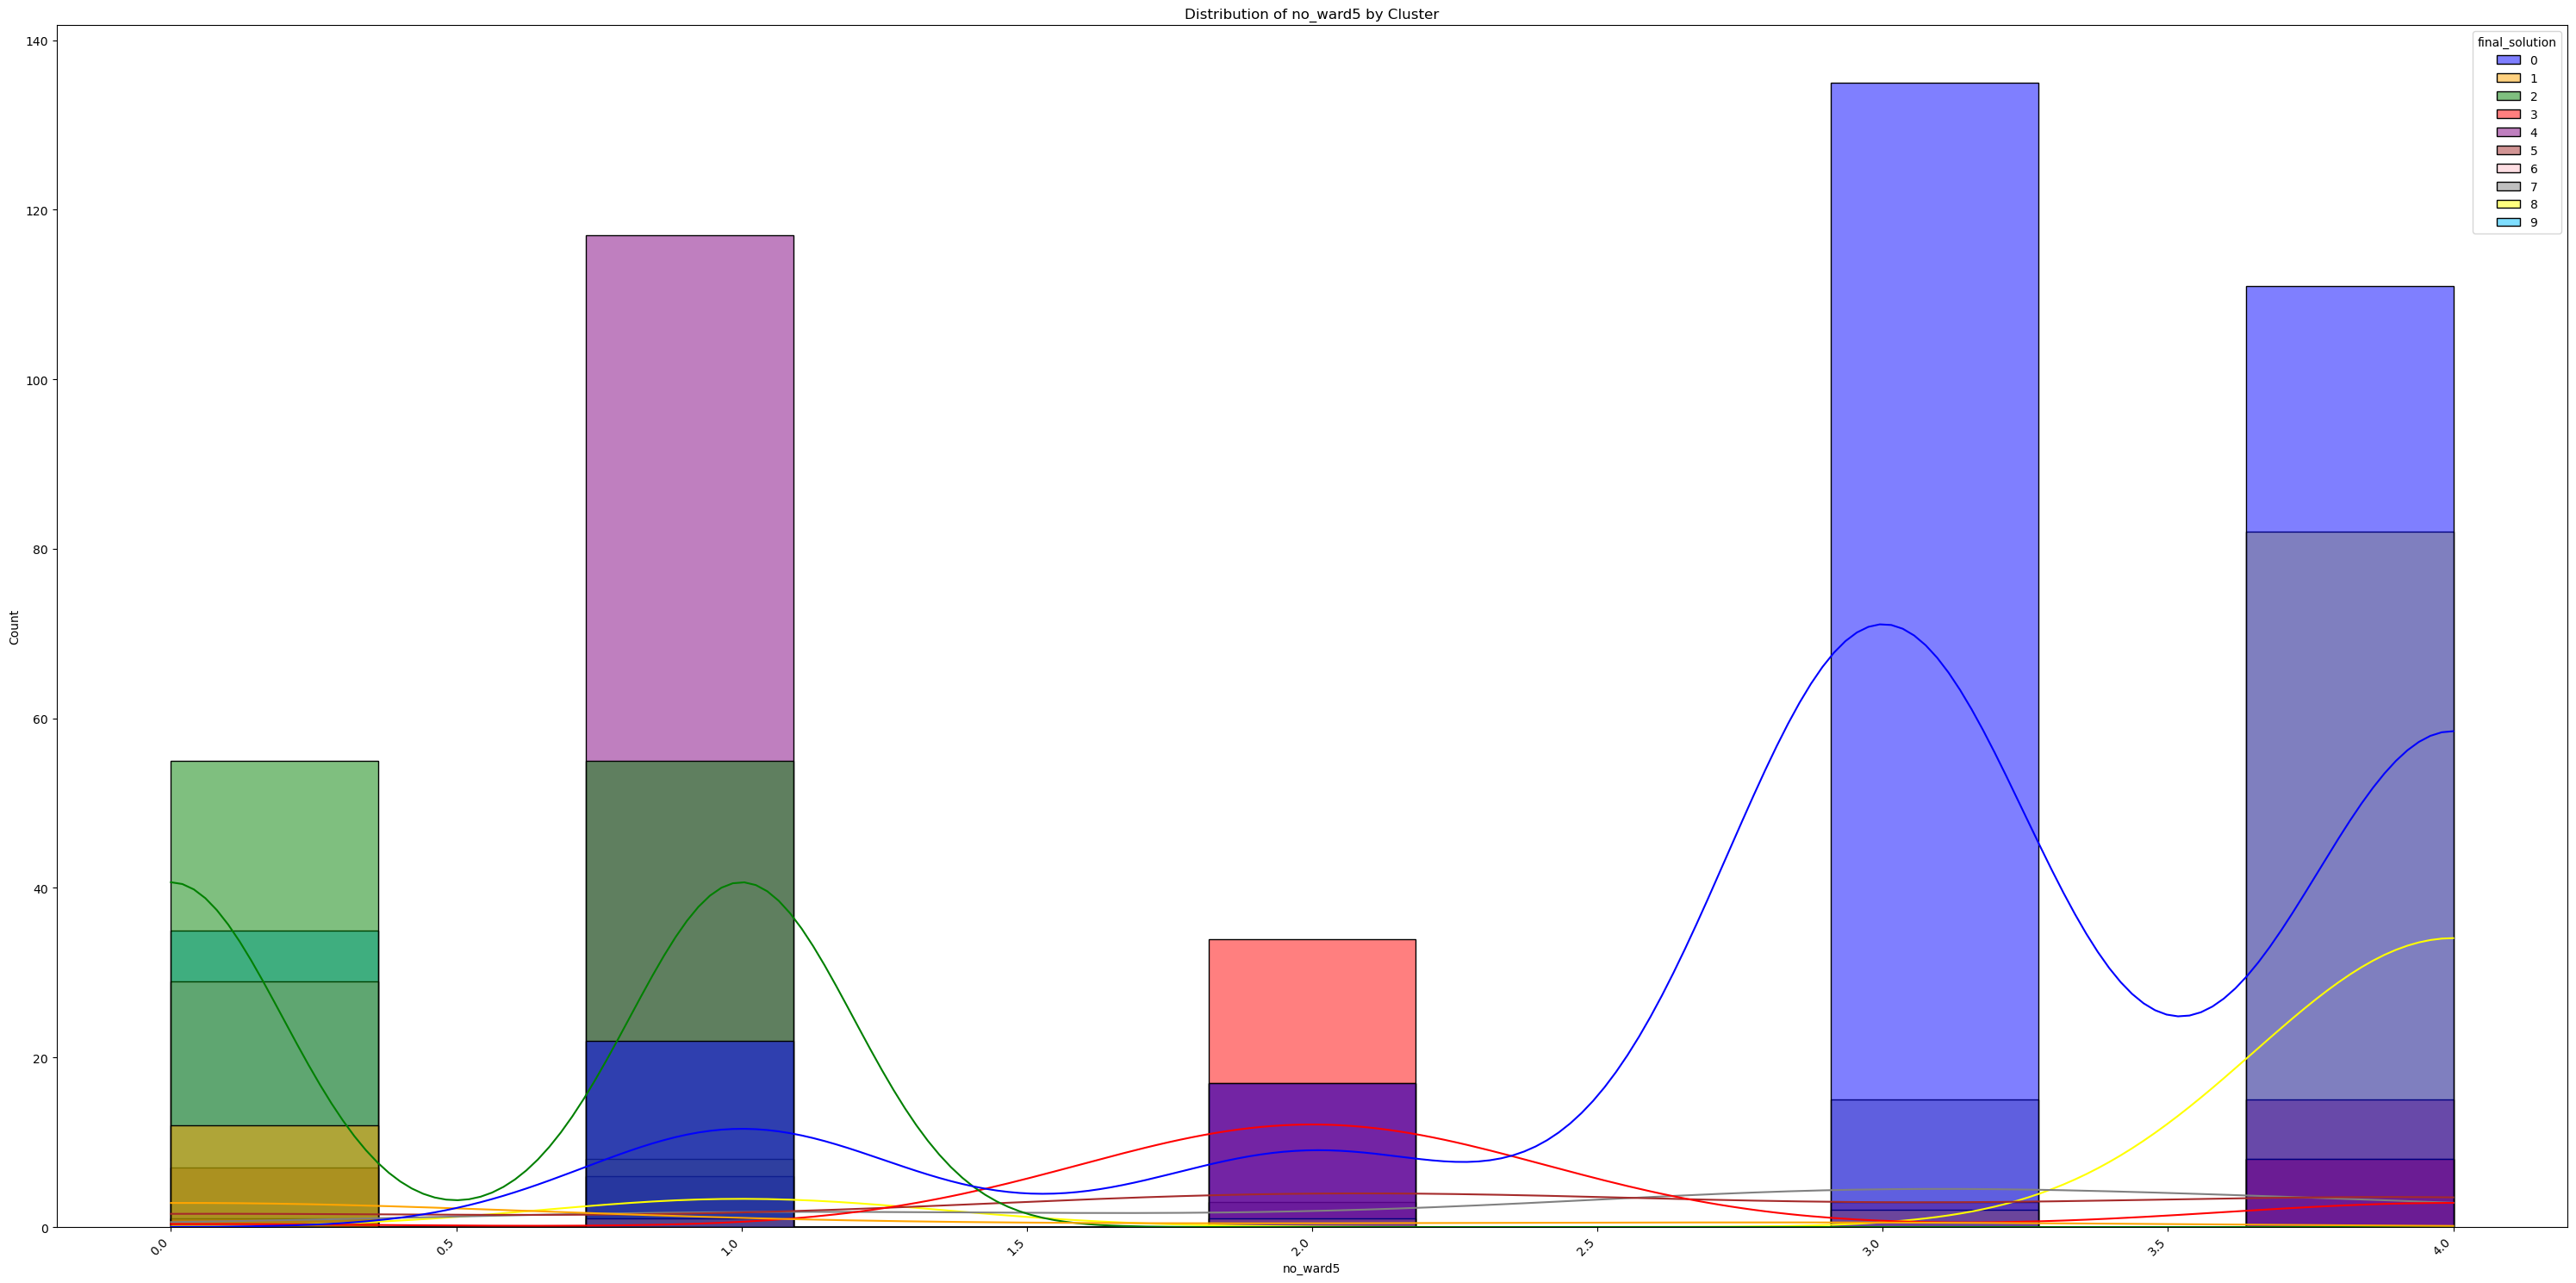

 92%|█████████▏| 33/36 [00:10<00:01,  2.84it/s]

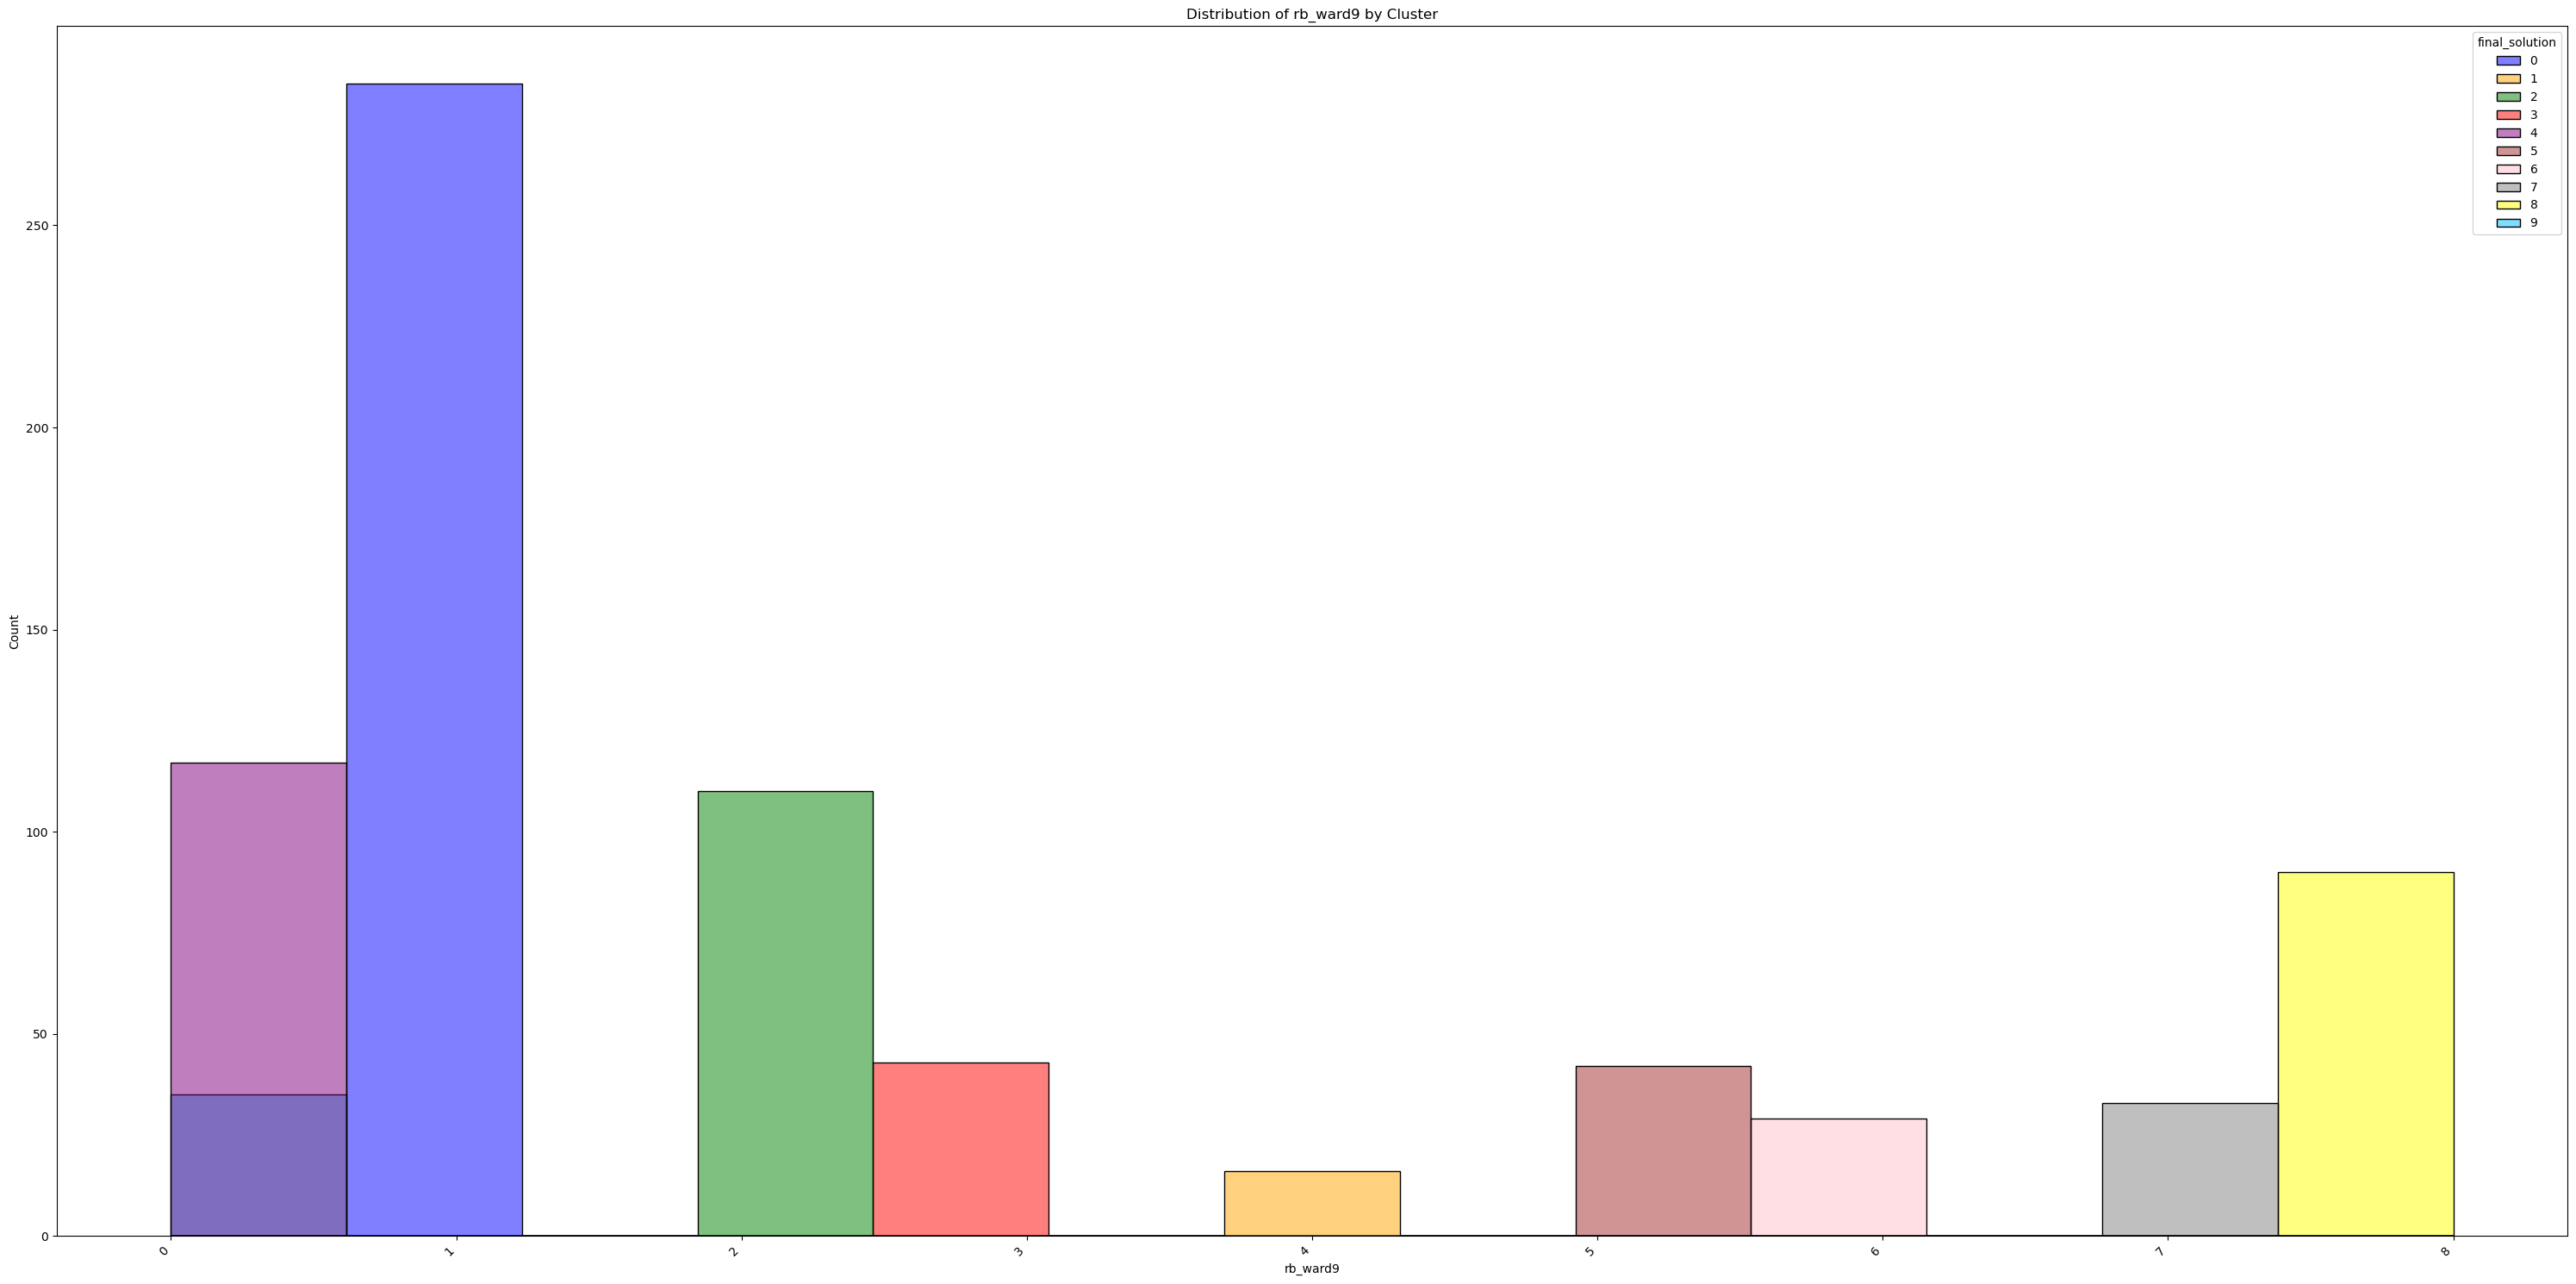

 94%|█████████▍| 34/36 [00:11<00:00,  2.98it/s]

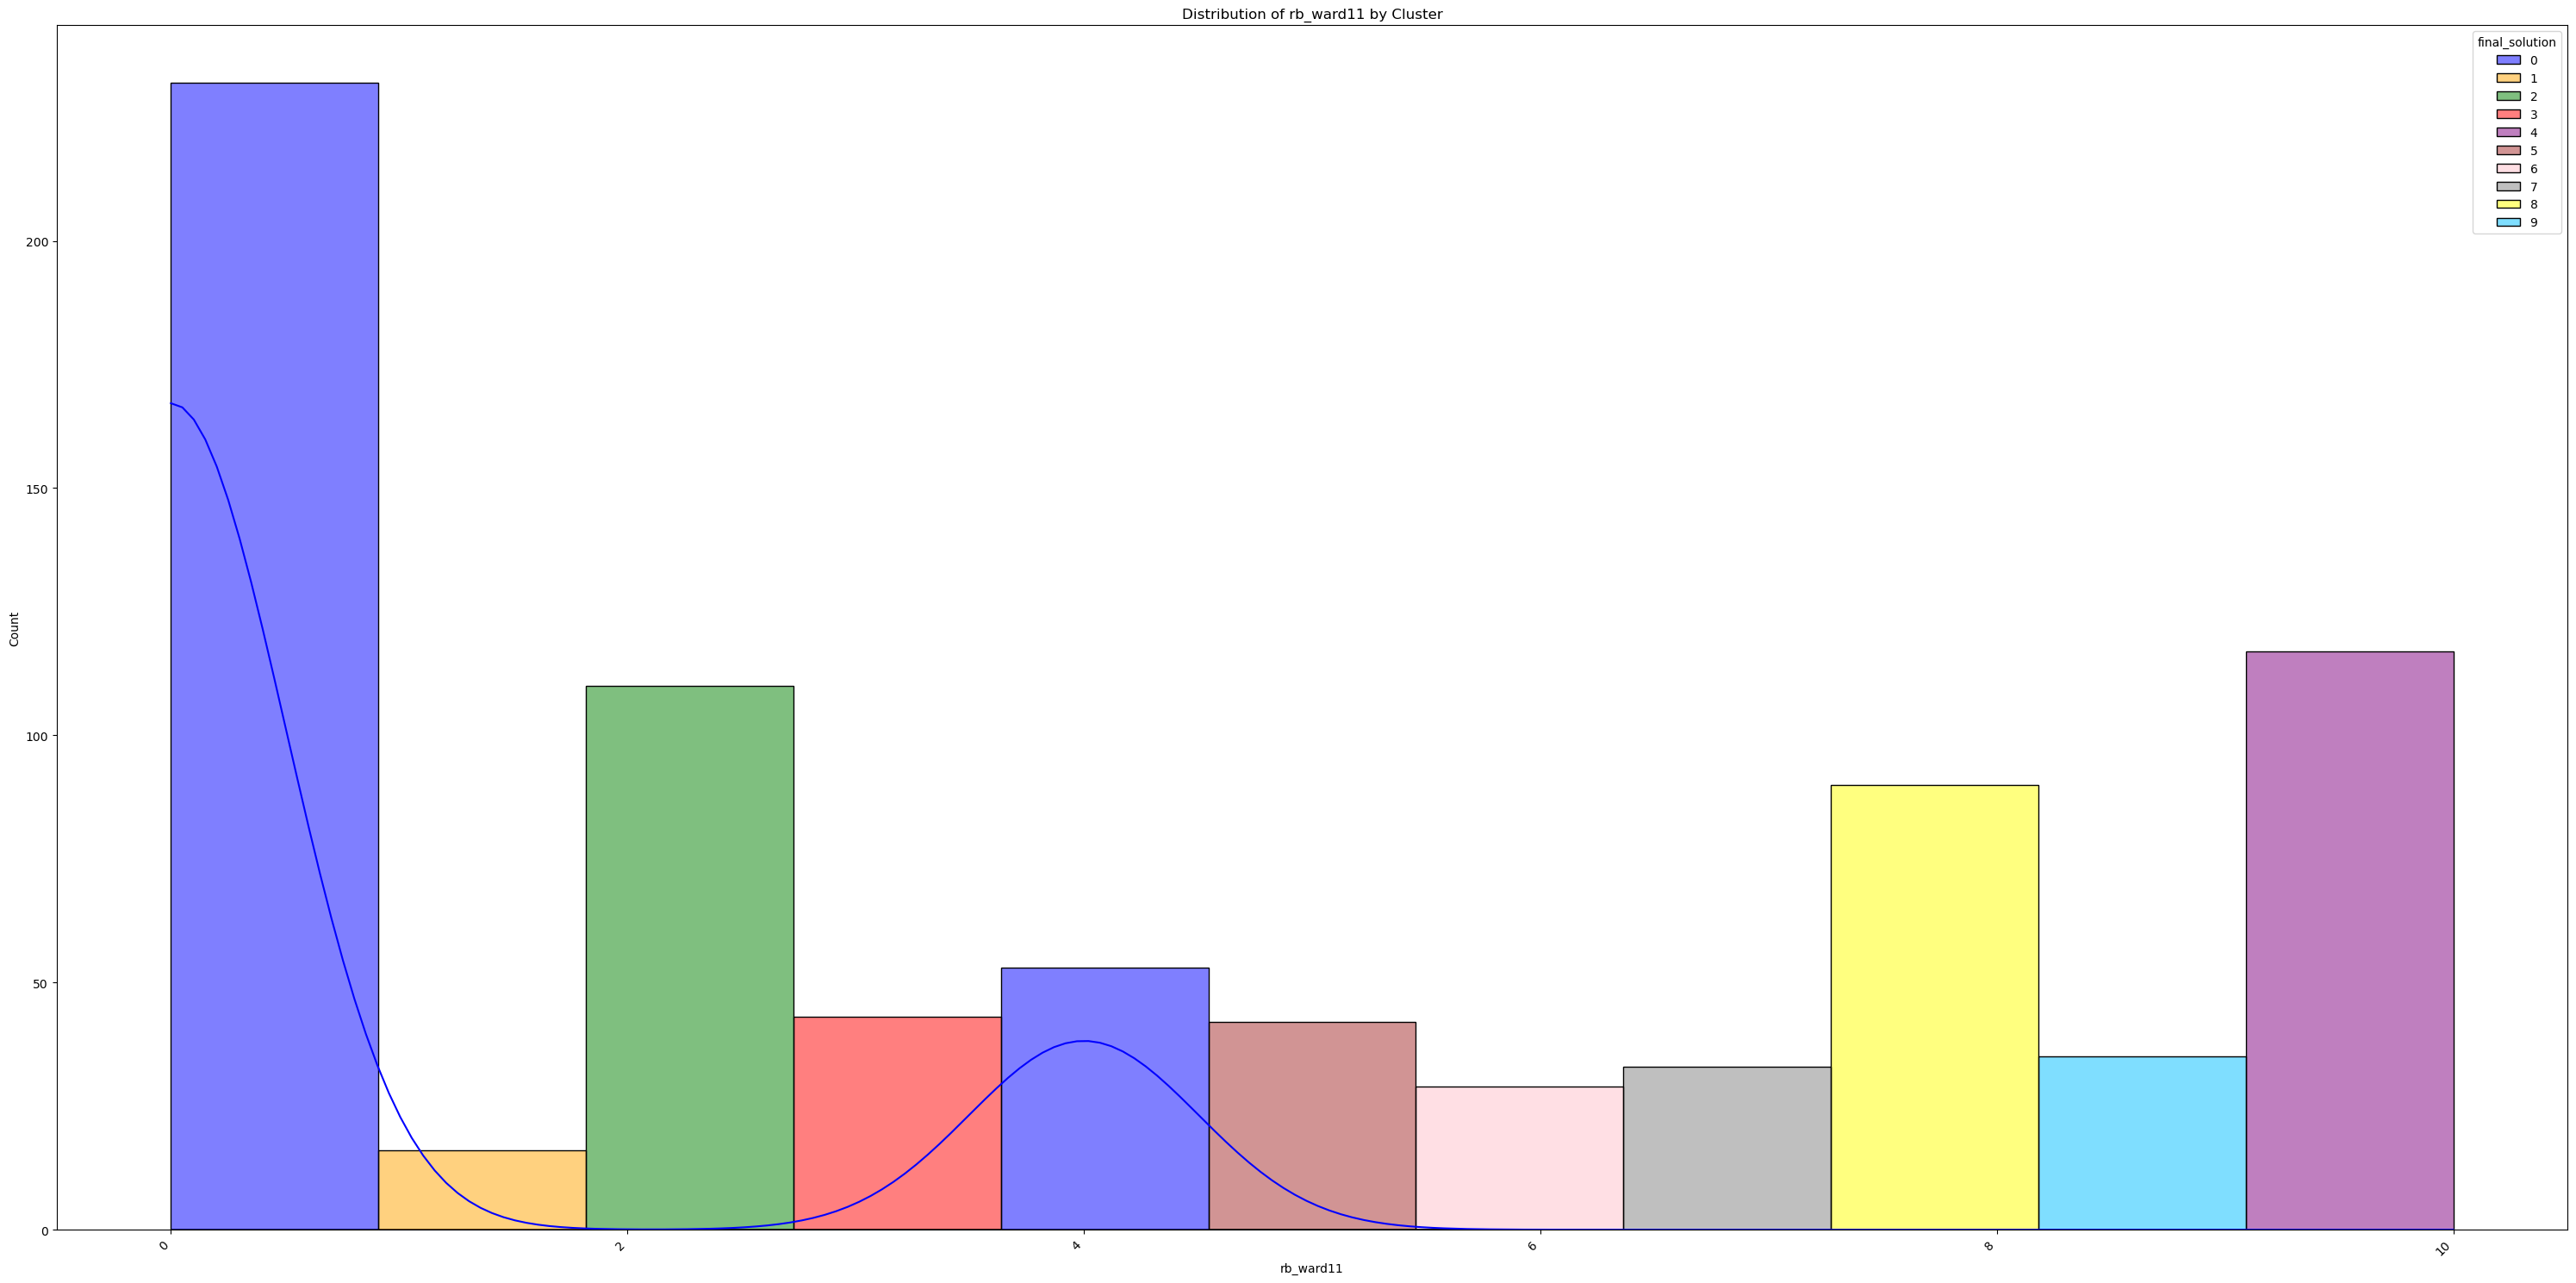

 97%|█████████▋| 35/36 [00:11<00:00,  3.26it/s]

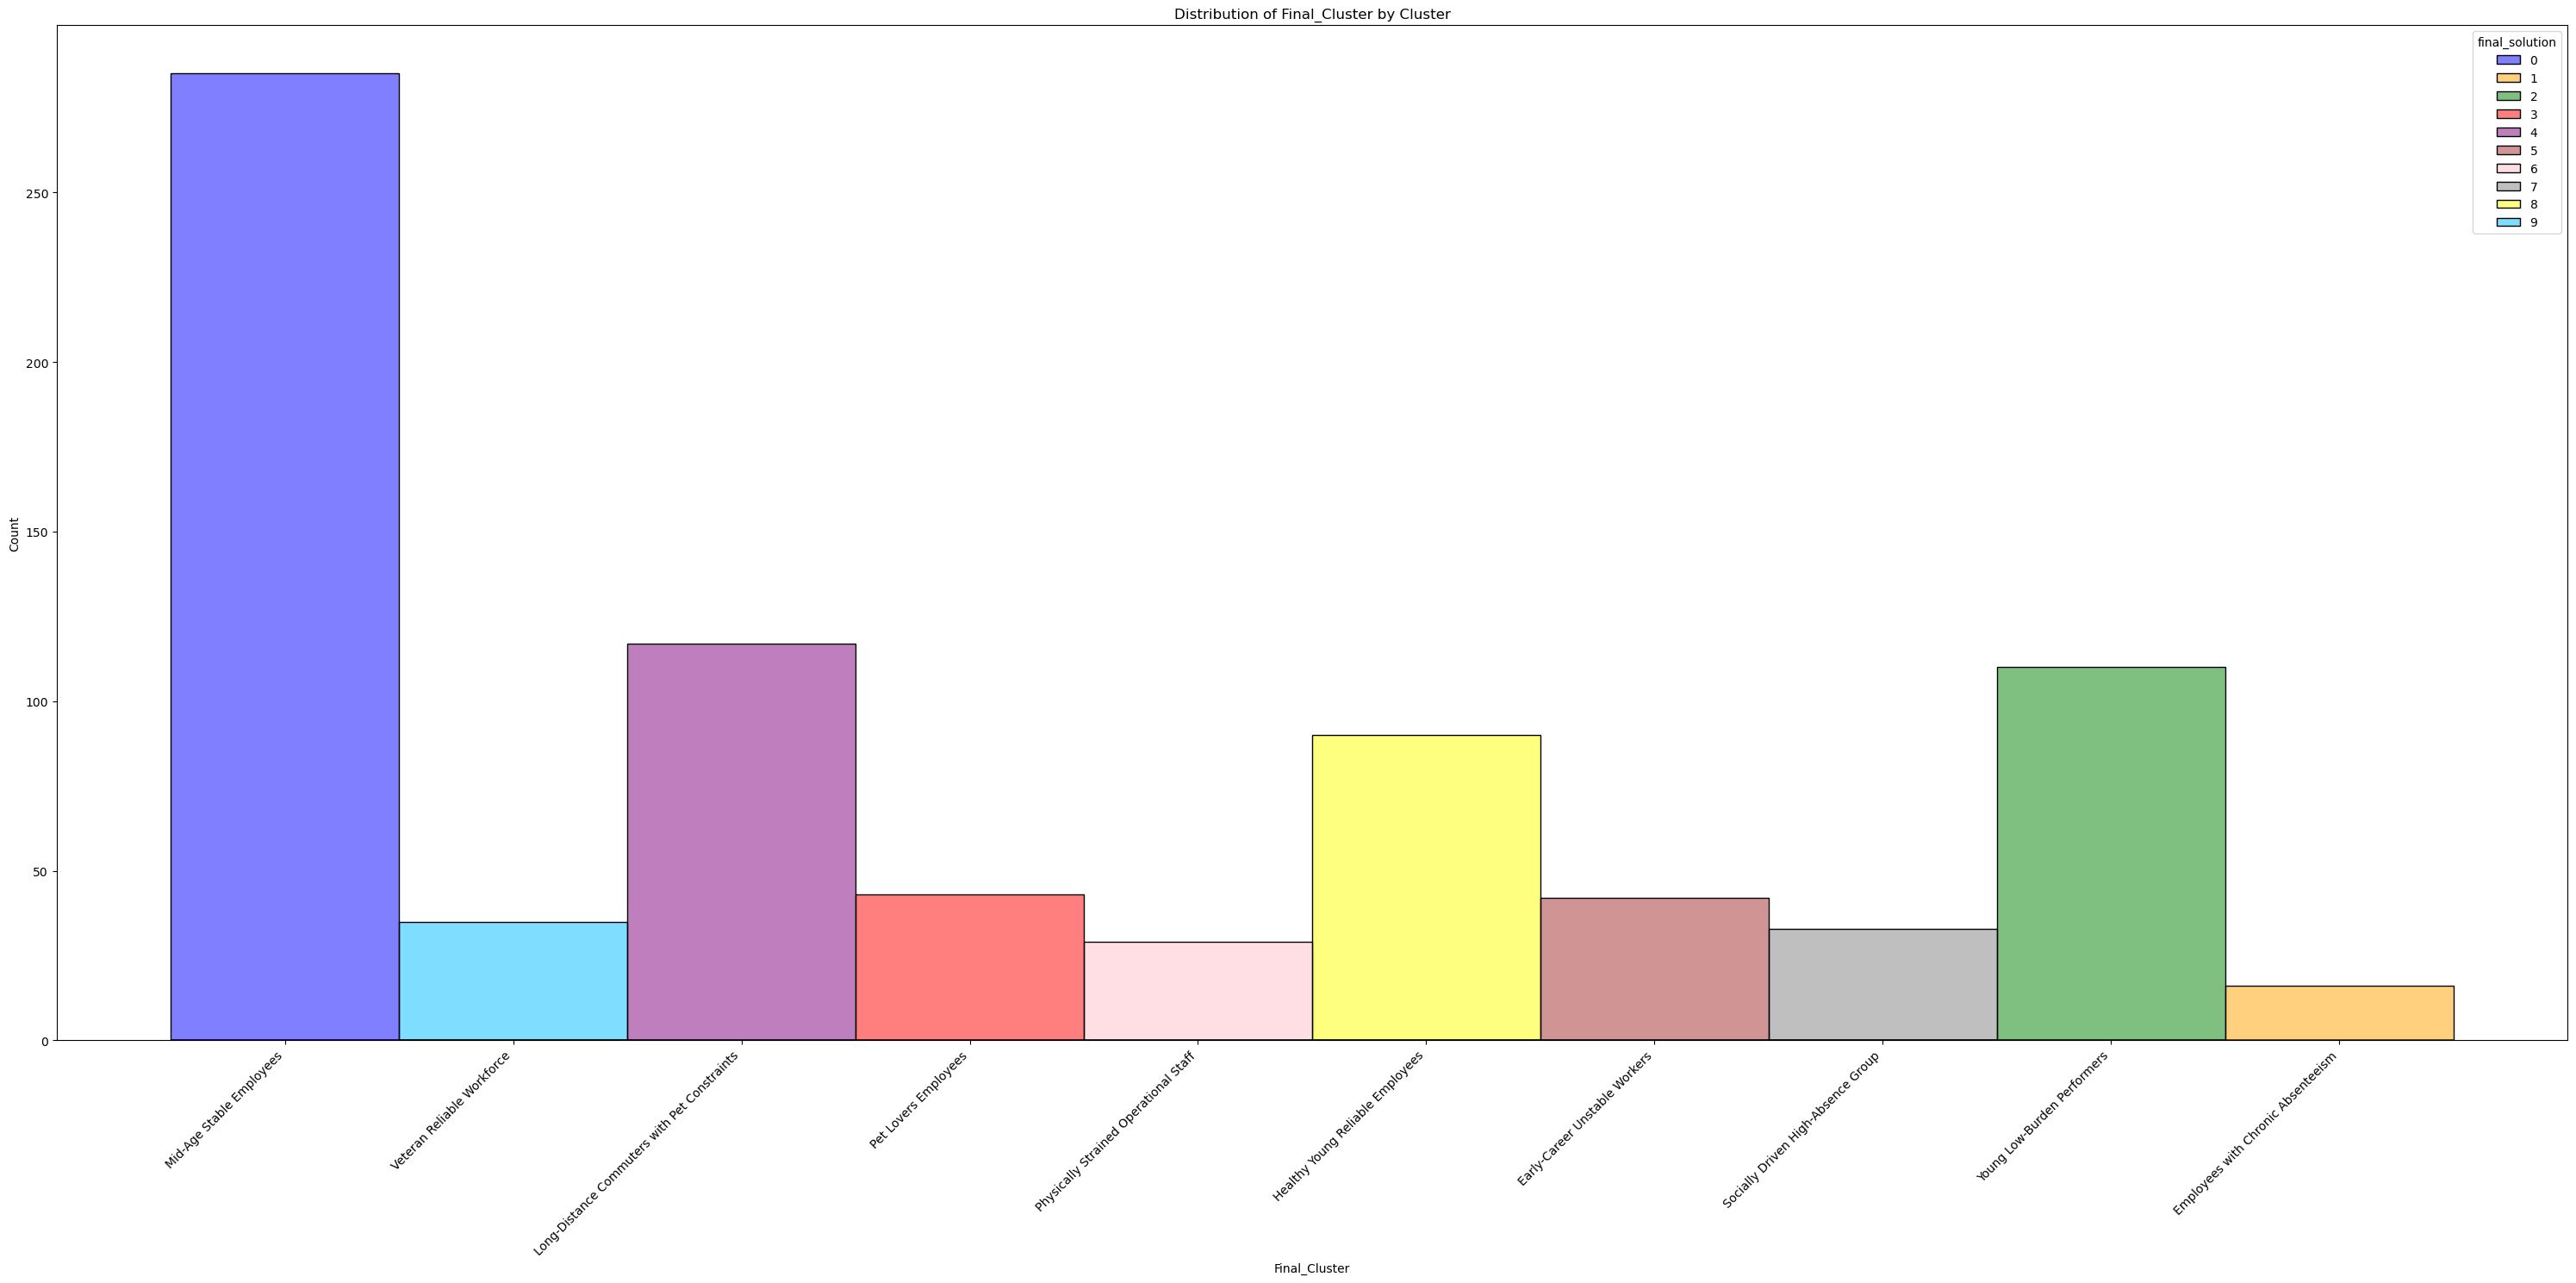

100%|██████████| 36/36 [00:11<00:00,  3.05it/s]


In [144]:
from tqdm.auto import tqdm
# Loop through all columns except numeric cluster labels
for col in tqdm(worker.drop(['final_solution', 'rb_ward10'], axis=1).columns):
    sns.histplot(
        data=worker.dropna(subset=[col]),
        x=col,
        hue='final_solution',
        kde=True,
        palette=cluster_colors,
        hue_order=sorted(cluster_colors.keys()),
        legend=True
    )

    plt.title(f"Distribution of {col} by Cluster")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()